## Testing

In [1]:
# General opf simulation function
import pandas as pd
import numpy as np


def simulate_department(
    daily_demand,
    hourly_profile,
    staff,
    rooms,
    service_time_mins,
    operating_hours=8
):
    """
    Simulate patient flow for one department/service.

    Parameters
    ----------
    daily_demand : float
        Forecast number of patients for the day.

    hourly_profile : dict
        Proportion of daily arrivals occurring in each
        operating hour. Values should sum to 1.

    staff : int
        Number of available staff.

    rooms : int
        Number of available service rooms.

    service_time_mins : int
        Assumed service time per patient.

    operating_hours : int
        Number of operating hours.

    Returns
    -------
    dict
        Simulation performance metrics.
    """

    # Determine number of simultaneous service servers

    servers = min(staff, rooms)

    # Number of simulation steps
    # Example: 10-minute service = 6 steps/hour
    steps_per_hour = 60 / service_time_mins
    total_steps = int(operating_hours * steps_per_hour)

    # Generate expected arrivals

    arrivals = []

    for hour, proportion in hourly_profile.items():

        hourly_demand = daily_demand * proportion

        arrivals_per_step = (
            hourly_demand / steps_per_hour
        )

        for _ in range(int(steps_per_hour)):
            arrivals.append(arrivals_per_step)

    # Make sure the number of steps matches
    arrivals = arrivals[:total_steps]

    # Queue simulation

    queue = 0

    total_arrivals = 0
    total_served = 0
    total_waiting_patient_minutes = 0
    maximum_queue = 0

    for new_arrivals in arrivals:

        # Patients arrive
        queue += new_arrivals
        total_arrivals += new_arrivals

        # Patients that can be served during this step
        patients_served = min(
            queue,
            servers
        )

        # Remove served patients
        queue -= patients_served

        # Record service
        total_served += patients_served

        # Patients remaining in queue wait
        total_waiting_patient_minutes += (
            queue * service_time_mins
        )

        # Track maximum queue
        maximum_queue = max(
            maximum_queue,
            queue
        )

    # Final metrics

    patients_remaining = queue

    if total_arrivals > 0:
        average_wait = (
            total_waiting_patient_minutes
            / total_arrivals
        )
    else:
        average_wait = 0

    # Theoretical daily capacity
    daily_capacity = (
        servers
        * total_steps
    )

    capacity_utilization = (
        total_arrivals / daily_capacity
    ) * 100 if daily_capacity > 0 else 0

    # Congestion classification
    # Prototype classification only

    if patients_remaining > 0:
        congestion_status = "Critical"

    elif capacity_utilization > 100:
        congestion_status = "Overloaded"

    elif capacity_utilization >= 85:
        congestion_status = "High"

    elif capacity_utilization >= 70:
        congestion_status = "Moderate"

    else:
        congestion_status = "Low"

    # Return results

    return {
        "forecast_demand": total_arrivals,
        "patients_served": total_served,
        "patients_remaining": patients_remaining,
        "maximum_queue": maximum_queue,
        "average_wait_mins": average_wait,
        "daily_capacity": daily_capacity,
        "capacity_utilization": capacity_utilization,
        "congestion_status": congestion_status
    }

In [2]:
# Test simmulation

general_opd_profile = {
    8: 0.200215,
    9: 0.219924,
    10: 0.161678,
    11: 0.140799,
    12: 0.104394,
    13: 0.068228,
    14: 0.056291,
    15: 0.048471
}

result = simulate_department(
    daily_demand=147.061396,
    hourly_profile=general_opd_profile,
    staff=8,
    rooms=6,
    service_time_mins=10,
    operating_hours=8
)

result

{'forecast_demand': 147.0613960000001,
 'patients_served': 147.0613960000001,
 'patients_remaining': 0.0,
 'maximum_queue': 0,
 'average_wait_mins': 0.0,
 'daily_capacity': 288,
 'capacity_utilization': 51.06298472222225,
 'congestion_status': 'Low'}

In [3]:
# CORRECTED PATIENT-LEVEL QUEUE SIMULATION

import numpy as np
import pandas as pd


def simulate_department_with_timeline(
    daily_demand,
    hourly_profile,
    staff,
    rooms,
    service_time_mins,
    operating_hours=8,
    simulation_date="2026-08-25",
    random_seed=42
):
    """
    Patient-level queue simulation with timeline.

    Patients are represented as whole units.
    Arrivals are distributed across service intervals.
    FIFO service is used.

    Returns:
        summary: dictionary of simulation results
        timeline: DataFrame showing the queue at each interval.
    """

    # ---------------------------------------------------
    # Basic capacity
    # ---------------------------------------------------

    servers = min(staff, rooms)

    if servers <= 0:
        raise ValueError(
            "Staff and rooms must provide at least one server."
        )

    steps_per_hour = int(60 / service_time_mins)
    total_steps = operating_hours * steps_per_hour

    # ---------------------------------------------------
    # Simulation start time
    # ---------------------------------------------------

    start_time = pd.Timestamp(
        f"{simulation_date} 08:00:00"
    )

    # ---------------------------------------------------
    # Generate fractional expected arrivals
    # ---------------------------------------------------

    expected_arrivals = []

    for hour, proportion in hourly_profile.items():

        hourly_demand = daily_demand * proportion

        arrivals_per_step = (
            hourly_demand / steps_per_hour
        )

        for _ in range(steps_per_hour):
            expected_arrivals.append(arrivals_per_step)

    expected_arrivals = expected_arrivals[:total_steps]

    # ---------------------------------------------------
    # Convert expected arrivals to whole patients
    # ---------------------------------------------------

    rng = np.random.default_rng(random_seed)

    arrivals = [
        rng.poisson(max(rate, 0))
        for rate in expected_arrivals
    ]

    # ---------------------------------------------------
    # Queue
    # ---------------------------------------------------

    queue = []

    total_arrivals = 0
    total_served = 0
    total_waiting_patient_minutes = 0

    maximum_queue = 0

    timeline = []

    # ---------------------------------------------------
    # Simulation
    # ---------------------------------------------------

    for step, new_arrivals in enumerate(arrivals):

        # -----------------------------------------------
        # Add newly arriving patients
        # -----------------------------------------------

        for _ in range(new_arrivals):
            queue.append(step)

        total_arrivals += new_arrivals

        queue_before_service = len(queue)

        # -----------------------------------------------
        # Serve patients
        # -----------------------------------------------

        patients_to_serve = min(
            len(queue),
            servers
        )

        waiting_times = []

        for _ in range(patients_to_serve):

            arrival_step = queue.pop(0)

            waiting_steps = (
                step - arrival_step
            )

            waiting_minutes = (
                waiting_steps * service_time_mins
            )

            waiting_times.append(waiting_minutes)

            total_waiting_patient_minutes += (
                waiting_minutes
            )

            total_served += 1

        # -----------------------------------------------
        # Queue remaining after service
        # -----------------------------------------------

        queue_after_service = len(queue)

        maximum_queue = max(
            maximum_queue,
            queue_after_service
        )

        # -----------------------------------------------
        # Record timeline
        # -----------------------------------------------

        timeline.append({
            "step": step,

            "time": (
                start_time
                + pd.Timedelta(
                    minutes=step * service_time_mins
                )
            ),

            "expected_arrivals": expected_arrivals[step],

            "arrivals": new_arrivals,

            "queue_before_service": queue_before_service,

            "patients_served": patients_to_serve,

            "queue_after_service": queue_after_service,

            "average_wait_this_step": (
                np.mean(waiting_times)
                if waiting_times
                else 0
            )
        })

    # ---------------------------------------------------
    # Final metrics
    # ---------------------------------------------------

    patients_remaining = len(queue)

    if total_arrivals > 0:
        average_wait = (
            total_waiting_patient_minutes
            / total_arrivals
        )
    else:
        average_wait = 0

    daily_capacity = (
        servers * total_steps
    )

    capacity_utilization = (
        total_arrivals / daily_capacity
    ) * 100

    # ---------------------------------------------------
    # Congestion status
    # ---------------------------------------------------

    if patients_remaining > 0:
        congestion_status = "Critical"

    elif capacity_utilization > 100:
        congestion_status = "Overloaded"

    elif capacity_utilization >= 85:
        congestion_status = "High"

    elif capacity_utilization >= 70:
        congestion_status = "Moderate"

    else:
        congestion_status = "Low"

    # ---------------------------------------------------
    # Timeline DataFrame
    # ---------------------------------------------------

    timeline = pd.DataFrame(timeline)

    # ---------------------------------------------------
    # Summary
    # ---------------------------------------------------

    summary = {
        "forecast_demand": daily_demand,
        "simulated_arrivals": total_arrivals,
        "patients_served": total_served,
        "patients_remaining": patients_remaining,
        "maximum_queue": maximum_queue,
        "average_wait_mins": average_wait,
        "daily_capacity": daily_capacity,
        "capacity_utilization": capacity_utilization,
        "congestion_status": congestion_status
    }

    return summary, timeline


# -------------------------------------------------------
# GENERAL OPD HISTORICAL HOURLY PROFILE
# -------------------------------------------------------

general_opd_profile = {
    8: 0.200215,
    9: 0.219924,
    10: 0.161678,
    11: 0.140799,
    12: 0.104394,
    13: 0.068228,
    14: 0.056291,
    15: 0.048471
}


# -------------------------------------------------------
# RUN SIMULATION — 3 SERVERS
# -------------------------------------------------------

summary, queue_timeline = simulate_department_with_timeline(
    daily_demand=147.061396,
    hourly_profile=general_opd_profile,
    staff=3,
    rooms=3,
    service_time_mins=10,
    operating_hours=8,
    simulation_date="2026-08-25",
    random_seed=42
)

summary

{'forecast_demand': 147.061396,
 'simulated_arrivals': 151,
 'patients_served': 144,
 'patients_remaining': 7,
 'maximum_queue': 43,
 'average_wait_mins': 86.09271523178808,
 'daily_capacity': 144,
 'capacity_utilization': 104.86111111111111,
 'congestion_status': 'Critical'}

In [4]:
# -------------------------------------------------------
# GENERAL OPD HISTORICAL HOURLY PROFILE
# -------------------------------------------------------

general_opd_profile = {
    8: 0.200215,
    9: 0.219924,
    10: 0.161678,
    11: 0.140799,
    12: 0.104394,
    13: 0.068228,
    14: 0.056291,
    15: 0.048471
}


# -------------------------------------------------------
# RUN SIMULATION — 3 SERVERS
# -------------------------------------------------------

summary, queue_timeline = simulate_department_with_timeline(
    daily_demand=147.061396,
    hourly_profile=general_opd_profile,
    staff=3,
    rooms=3,
    service_time_mins=10,
    operating_hours=8,
    simulation_date="2026-08-25",
    random_seed=42
)

summary

{'forecast_demand': 147.061396,
 'simulated_arrivals': 151,
 'patients_served': 144,
 'patients_remaining': 7,
 'maximum_queue': 43,
 'average_wait_mins': 86.09271523178808,
 'daily_capacity': 144,
 'capacity_utilization': 104.86111111111111,
 'congestion_status': 'Critical'}

In [5]:
queue_timeline.head(10)

,step,time,expected_arrivals,arrivals,queue_before_service,patients_served,queue_after_service,average_wait_this_step
0,0,2026-08-25 08:00:00,4.907316,8,8,3,5,0.000000
1,1,2026-08-25 08:10:00,4.907316,7,12,3,9,10.000000
2,2,2026-08-25 08:20:00,4.907316,7,16,3,13,16.666667
3,3,2026-08-25 08:30:00,4.907316,2,15,3,12,20.000000
4,4,2026-08-25 08:40:00,4.907316,6,18,3,15,30.000000
5,5,2026-08-25 08:50:00,4.907316,3,18,3,15,30.000000
6,6,2026-08-25 09:00:00,5.390388,8,23,3,20,40.000000
7,7,2026-08-25 09:10:00,5.390388,3,23,3,20,43.333333
8,8,2026-08-25 09:20:00,5.390388,7,27,3,24,40.000000
9,9,2026-08-25 09:30:00,5.390388,8,32,3,29,50.000000


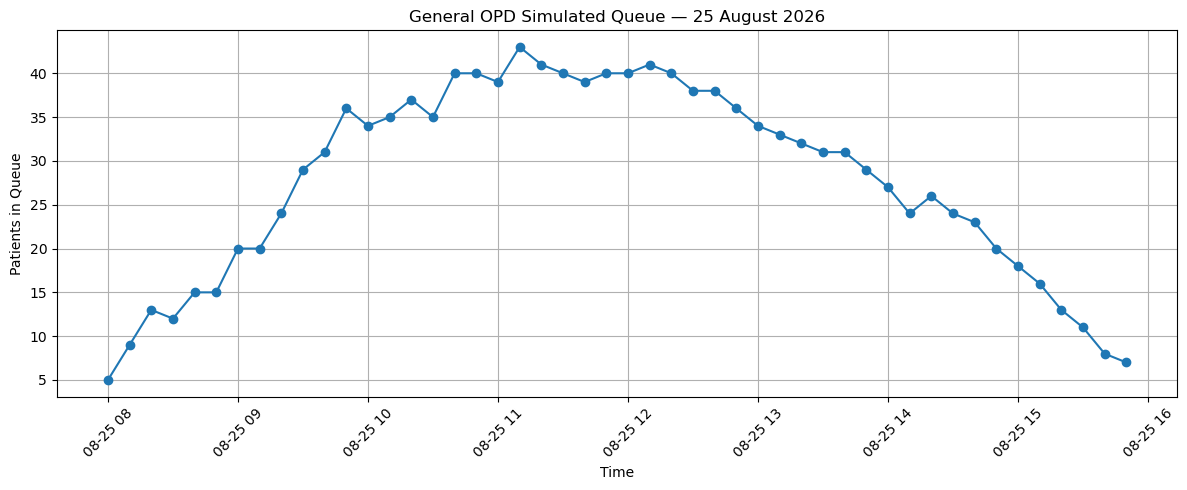

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    queue_timeline["time"],
    queue_timeline["queue_after_service"],
    marker="o"
)

plt.xlabel("Time")
plt.ylabel("Patients in Queue")
plt.title(
    "General OPD Simulated Queue — 25 August 2026"
)

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

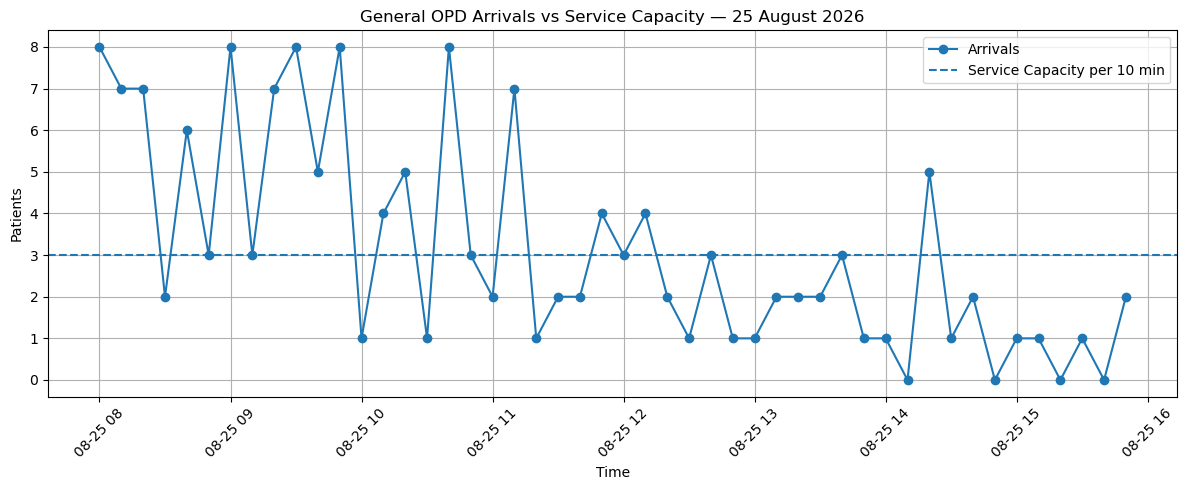

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(
    queue_timeline["time"],
    queue_timeline["arrivals"],
    marker="o",
    label="Arrivals"
)

plt.axhline(
    y=3,
    linestyle="--",
    label="Service Capacity per 10 min"
)

plt.xlabel("Time")
plt.ylabel("Patients")
plt.title(
    "General OPD Arrivals vs Service Capacity — 25 August 2026"
)

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 7-day General OPD forecast

In [8]:
forecast = pd.read_csv("daily_future_forecast2.csv")
forecast.head()

,date,QueuedTo,forecast_demand
0,2026-08-20,ADMISSION,50.315600
1,2026-08-20,ANAESTHESIA,0.910797
2,2026-08-20,Audiology,1.333275
3,2026-08-20,CARDIOLOGY,0.264110
4,2026-08-20,CASUALTY,4.029339


In [9]:
# -------------------------------------------------------
# 7-DAY GENERAL OPD FORECAST
# -------------------------------------------------------

general_opd_forecast_7d = (
    forecast[
        forecast["QueuedTo"] == "GENERAL OPD "
    ][
        ["date", "forecast_demand"]
    ]
    .copy()
)

general_opd_forecast_7d

,date,forecast_demand
12,2026-08-20,123.092936
53,2026-08-21,116.949296
94,2026-08-22,42.408198
135,2026-08-23,30.365127
176,2026-08-24,143.287097
217,2026-08-25,147.061396
258,2026-08-26,133.956492


In [10]:
# -------------------------------------------------------
# RUN 7-DAY GENERAL OPD SIMULATION
# -------------------------------------------------------

simulation_results = []

for _, row in general_opd_forecast_7d.iterrows():

    simulation_date = pd.to_datetime(
        row["date"]
    ).strftime("%Y-%m-%d")

    daily_demand = row["forecast_demand"]

    summary, timeline = simulate_department_with_timeline(
        daily_demand=daily_demand,
        hourly_profile=general_opd_profile,
        staff=8,
        rooms=6,
        service_time_mins=10,
        operating_hours=8,
        simulation_date=simulation_date,
        random_seed=42
    )

    summary["date"] = simulation_date

    simulation_results.append(summary)


general_opd_simulation = pd.DataFrame(
    simulation_results
)

general_opd_simulation

,forecast_demand,simulated_arrivals,patients_served,patients_remaining,maximum_queue,average_wait_mins,daily_capacity,capacity_utilization,congestion_status,date
0,123.092936,125,125,0,2,0.240000,288,43.402778,Low,2026-08-20
1,116.949296,118,118,0,1,0.169492,288,40.972222,Low,2026-08-21
2,42.408198,40,40,0,0,0.000000,288,13.888889,Low,2026-08-22
3,30.365127,37,37,0,0,0.000000,288,12.847222,Low,2026-08-23
4,143.287097,151,151,0,4,1.324503,288,52.430556,Low,2026-08-24
5,147.061396,151,151,0,4,1.589404,288,52.430556,Low,2026-08-25
6,133.956492,140,140,0,3,0.857143,288,48.611111,Low,2026-08-26


In [11]:
general_opd_simulation[
    [
        "date",
        "forecast_demand",
        "simulated_arrivals",
        "patients_served",
        "patients_remaining",
        "maximum_queue",
        "average_wait_mins",
        "daily_capacity",
        "capacity_utilization",
        "congestion_status"
    ]
]

,date,forecast_demand,simulated_arrivals,patients_served,patients_remaining,maximum_queue,average_wait_mins,daily_capacity,capacity_utilization,congestion_status
0,2026-08-20,123.092936,125,125,0,2,0.240000,288,43.402778,Low
1,2026-08-21,116.949296,118,118,0,1,0.169492,288,40.972222,Low
2,2026-08-22,42.408198,40,40,0,0,0.000000,288,13.888889,Low
3,2026-08-23,30.365127,37,37,0,0,0.000000,288,12.847222,Low
4,2026-08-24,143.287097,151,151,0,4,1.324503,288,52.430556,Low
5,2026-08-25,147.061396,151,151,0,4,1.589404,288,52.430556,Low
6,2026-08-26,133.956492,140,140,0,3,0.857143,288,48.611111,Low


In [12]:
forecast.shape

(287, 3)

In [13]:
display_table = general_opd_simulation.copy()

display_table["forecast_demand"] = (
    display_table["forecast_demand"].map("{:.2f}".format)
)

display_table["average_wait_mins"] = (
    display_table["average_wait_mins"].map("{:.2f}".format)
)

display_table["capacity_utilization"] = (
    display_table["capacity_utilization"].map("{:.2f}".format)
)

display_table

,forecast_demand,simulated_arrivals,patients_served,patients_remaining,maximum_queue,average_wait_mins,daily_capacity,capacity_utilization,congestion_status,date
0,123.09,125,125,0,2,0.24,288,43.40,Low,2026-08-20
1,116.95,118,118,0,1,0.17,288,40.97,Low,2026-08-21
2,42.41,40,40,0,0,0.00,288,13.89,Low,2026-08-22
3,30.37,37,37,0,0,0.00,288,12.85,Low,2026-08-23
4,143.29,151,151,0,4,1.32,288,52.43,Low,2026-08-24
5,147.06,151,151,0,4,1.59,288,52.43,Low,2026-08-25
6,133.96,140,140,0,3,0.86,288,48.61,Low,2026-08-26


In [14]:
# -------------------------------------------------------
# GENERAL OPD — 7-DAY CAPACITY SCENARIO ANALYSIS
# -------------------------------------------------------

capacity_scenarios = []

for servers in range(2, 7):

    for _, row in general_opd_forecast_7d.iterrows():

        simulation_date = pd.to_datetime(
            row["date"]
        ).strftime("%Y-%m-%d")

        daily_demand = row["forecast_demand"]

        summary, timeline = simulate_department_with_timeline(
            daily_demand=daily_demand,
            hourly_profile=general_opd_profile,
            staff=servers,
            rooms=servers,
            service_time_mins=10,
            operating_hours=8,
            simulation_date=simulation_date,
            random_seed=42
        )

        summary["date"] = simulation_date
        summary["servers"] = servers

        capacity_scenarios.append(summary)


general_opd_capacity_scenarios = pd.DataFrame(
    capacity_scenarios
)

In [15]:
general_opd_capacity_scenarios[
    [
        "date",
        "servers",
        "forecast_demand",
        "patients_remaining",
        "maximum_queue",
        "average_wait_mins",
        "daily_capacity",
        "capacity_utilization",
        "congestion_status"
    ]
]

,date,servers,forecast_demand,patients_remaining,maximum_queue,average_wait_mins,daily_capacity,capacity_utilization,congestion_status
0,2026-08-20,2,123.092936,29,43,96.000000,96,130.208333,Critical
1,2026-08-21,2,116.949296,22,42,101.186441,96,122.916667,Critical
2,2026-08-22,2,42.408198,0,2,2.000000,96,41.666667,Low
3,2026-08-23,2,30.365127,0,2,1.891892,96,38.541667,Low
4,2026-08-24,2,143.287097,55,67,98.476821,96,157.291667,Critical
5,2026-08-25,2,147.061396,55,67,98.741722,96,157.291667,Critical
6,2026-08-26,2,133.956492,44,55,97.142857,96,145.833333,Critical
7,2026-08-20,3,123.092936,0,21,36.880000,144,86.805556,High
8,2026-08-21,3,116.949296,0,21,38.474576,144,81.944444,Moderate
9,2026-08-22,3,42.408198,0,0,0.000000,144,27.777778,Low


In [16]:
capacity_summary = (
    general_opd_capacity_scenarios
    .pivot(
        index="date",
        columns="servers",
        values="average_wait_mins"
    )
    .round(2)
)

capacity_summary

servers,2,3,4,5,6
date,,,,,
2026-08-20,96.00,36.88,7.60,0.72,0.24
2026-08-21,101.19,38.47,7.54,0.76,0.17
2026-08-22,2.00,0.00,0.00,0.00,0.00
2026-08-23,1.89,0.00,0.00,0.00,0.00
2026-08-24,98.48,85.76,30.46,7.15,1.32
2026-08-25,98.74,86.09,30.79,7.42,1.59
2026-08-26,97.14,60.71,15.79,2.36,0.86


In [17]:
queue_summary = (
    general_opd_capacity_scenarios
    .pivot(
        index="date",
        columns="servers",
        values="maximum_queue"
    )
    .round(0)
)

queue_summary

servers,2,3,4,5,6
date,,,,,
2026-08-20,43,21,10,3,2
2026-08-21,42,21,10,3,1
2026-08-22,2,0,0,0,0
2026-08-23,2,0,0,0,0
2026-08-24,67,43,24,12,4
2026-08-25,67,43,24,12,4
2026-08-26,55,31,15,5,3


In [18]:
status_summary = (
    general_opd_capacity_scenarios
    .pivot(
        index="date",
        columns="servers",
        values="congestion_status"
    )
)

status_summary

servers,2,3,4,5,6
date,,,,,
2026-08-20,Critical,High,Low,Low,Low
2026-08-21,Critical,Moderate,Low,Low,Low
2026-08-22,Low,Low,Low,Low,Low
2026-08-23,Low,Low,Low,Low,Low
2026-08-24,Critical,Critical,Moderate,Low,Low
2026-08-25,Critical,Critical,Moderate,Low,Low
2026-08-26,Critical,High,Moderate,Low,Low


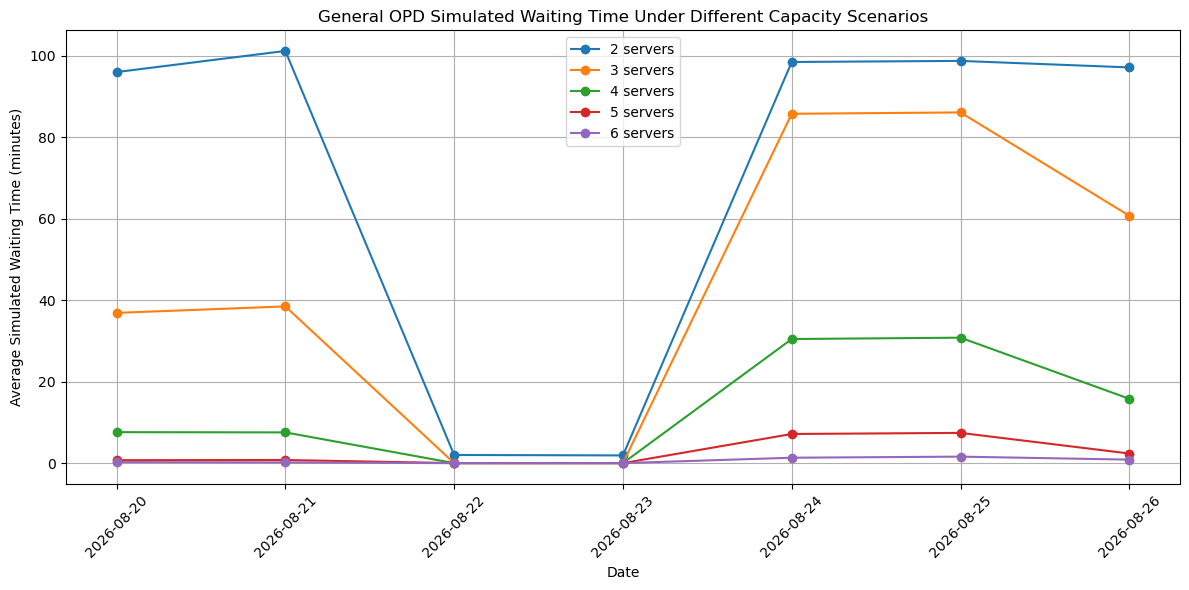

In [19]:
# -------------------------------------------------------
# AVERAGE WAITING TIME BY CAPACITY SCENARIO
# -------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for servers in sorted(
    general_opd_capacity_scenarios["servers"].unique()
):

    data = general_opd_capacity_scenarios[
        general_opd_capacity_scenarios["servers"] == servers
    ]

    plt.plot(
        data["date"],
        data["average_wait_mins"],
        marker="o",
        label=f"{servers} servers"
    )

plt.xlabel("Date")
plt.ylabel("Average Simulated Waiting Time (minutes)")
plt.title(
    "General OPD Simulated Waiting Time Under Different Capacity Scenarios"
)

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

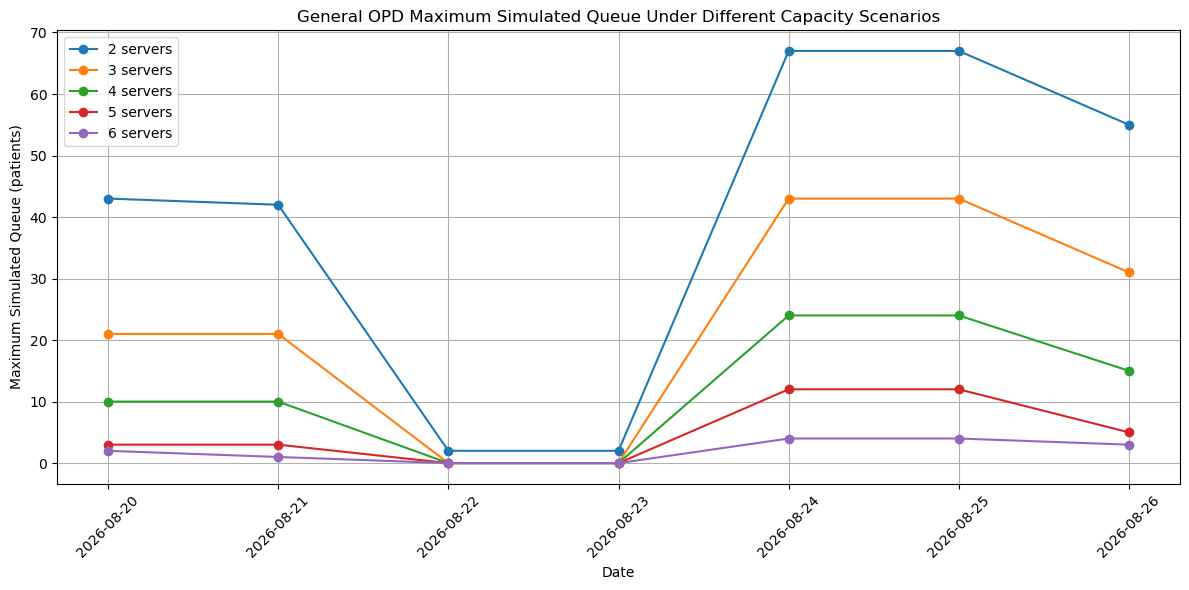

In [20]:
# -------------------------------------------------------
# MAXIMUM QUEUE BY CAPACITY SCENARIO
# -------------------------------------------------------

plt.figure(figsize=(12, 6))

for servers in sorted(
    general_opd_capacity_scenarios["servers"].unique()
):

    data = general_opd_capacity_scenarios[
        general_opd_capacity_scenarios["servers"] == servers
    ]

    plt.plot(
        data["date"],
        data["maximum_queue"],
        marker="o",
        label=f"{servers} servers"
    )

plt.xlabel("Date")
plt.ylabel("Maximum Simulated Queue (patients)")
plt.title(
    "General OPD Maximum Simulated Queue Under Different Capacity Scenarios"
)

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## department simulation configuration

### General time config

In [21]:
df = pd.read_csv("opd_clean.csv")
df.head()

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription
0,010569291,2024-06-01 00:04:00,Female,44 Yr(s),GENERAL OPD,General Outpatient Care
1,010575732,2024-06-01 00:04:00,Female,78 Yr(s),GENERAL OPD,General Outpatient Care
2,010575731,2024-06-01 00:10:00,Female,2 Yr(s),ADMISSION,Admission
3,010454966,2024-06-01 01:22:00,FEMALE,31 Yr(s),GENERAL OPD,General Outpatient Care
4,010573369,2024-06-01 01:36:00,Female,84 Yr(s),GENERAL OPD,General Outpatient Care


In [22]:
# -------------------------------------------------------
# DEPARTMENT SIMULATION CONFIGURATION
# -------------------------------------------------------

simulation_config = pd.DataFrame({
    "department": [
        "GENERAL OPD ",
        "ADMISSION",
        "MCH",
        "CHRONIC CARE CLINIC (DM/HTN/TB/CCC)",
        "MEB SPECIALITY CLINIC",
        "SPECIALITY CLINIC",
        "ONCOLOGY",
        "RENAL",
        "DENTAL",
        "PHYSIOTHERAPY",
        "PAEDS"
    ],

    "service": [
        "Consultation",
        "Admission Processing",
        "Consultation",
        "Consultation",
        "Consultation",
        "Consultation",
        "Consultation",
        "Dialysis",
        "Dental Consultation",
        "Physiotherapy",
        "Paediatric Consultation"
    ],

    "staff": [
        8,
        8,
        8,
        8,
        8,
        8,
        8,
        8,
        8,
        8,
        8
    ],

    "rooms": [
        6,
        6,
        6,
        6,
        6,
        6,
        6,
        6,
        6,
        6,
        6
    ],

    "service_time_mins": [
        10,
        10,
        10,
        10,
        10,
        10,
        10,
        10,
        10,
        10,
        10
    ],

    "operating_hours": [
        8,
        8,
        8,
        8,
        8,
        8,
        8,
        8,
        8,
        8,
        8
    ],

    "evidence_type": [
        "Assumed",
        "Assumed",
        "Assumed",
        "Assumed",
        "Assumed",
        "Assumed",
        "Assumed",
        "Assumed",
        "Assumed",
        "Assumed",
        "Assumed"
    ]
})

simulation_config

,department,service,staff,rooms,service_time_mins,operating_hours,evidence_type
0,GENERAL OPD,Consultation,8,6,10,8,Assumed
1,ADMISSION,Admission Processing,8,6,10,8,Assumed
2,MCH,Consultation,8,6,10,8,Assumed
3,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),Consultation,8,6,10,8,Assumed
4,MEB SPECIALITY CLINIC,Consultation,8,6,10,8,Assumed
5,SPECIALITY CLINIC,Consultation,8,6,10,8,Assumed
6,ONCOLOGY,Consultation,8,6,10,8,Assumed
7,RENAL,Dialysis,8,6,10,8,Assumed
8,DENTAL,Dental Consultation,8,6,10,8,Assumed
9,PHYSIOTHERAPY,Physiotherapy,8,6,10,8,Assumed


In [23]:
# -------------------------------------------------------
# PROTOTYPE HOURLY ARRIVAL PROFILE
# -------------------------------------------------------

default_hourly_profile = {
    8: 0.200215,
    9: 0.219924,
    10: 0.161678,
    11: 0.140799,
    12: 0.104394,
    13: 0.068228,
    14: 0.056291,
    15: 0.048471
}

In [24]:
# -------------------------------------------------------
# RUN DEPARTMENT-LEVEL SIMULATION
# -------------------------------------------------------

department_simulation_results = []

for _, config in simulation_config.iterrows():

    department = config["department"]

    department_forecast = forecast[
        forecast["QueuedTo"] == department
    ].copy()

    for _, forecast_row in department_forecast.iterrows():

        simulation_date = pd.to_datetime(
            forecast_row["date"]
        ).strftime("%Y-%m-%d")

        daily_demand = forecast_row["forecast_demand"]

        summary, timeline = simulate_department_with_timeline(
            daily_demand=daily_demand,
            hourly_profile=default_hourly_profile,
            staff=config["staff"],
            rooms=config["rooms"],
            service_time_mins=config["service_time_mins"],
            operating_hours=config["operating_hours"],
            simulation_date=simulation_date,
            random_seed=42
        )

        summary["date"] = simulation_date
        summary["department"] = department
        summary["service"] = config["service"]
        summary["evidence_type"] = config["evidence_type"]

        department_simulation_results.append(summary)


department_simulation = pd.DataFrame(
    department_simulation_results
)

In [25]:
department_simulation[
    [
        "date",
        "department",
        "service",
        "forecast_demand",
        "simulated_arrivals",
        "patients_served",
        "patients_remaining",
        "maximum_queue",
        "average_wait_mins",
        "daily_capacity",
        "capacity_utilization",
        "congestion_status"
    ]
]

,date,department,service,forecast_demand,simulated_arrivals,patients_served,patients_remaining,maximum_queue,average_wait_mins,daily_capacity,capacity_utilization,congestion_status
0,2026-08-20,GENERAL OPD,Consultation,123.092936,125,125,0,2,0.240000,288,43.402778,Low
1,2026-08-21,GENERAL OPD,Consultation,116.949296,118,118,0,1,0.169492,288,40.972222,Low
2,2026-08-22,GENERAL OPD,Consultation,42.408198,40,40,0,0,0.000000,288,13.888889,Low
3,2026-08-23,GENERAL OPD,Consultation,30.365127,37,37,0,0,0.000000,288,12.847222,Low
4,2026-08-24,GENERAL OPD,Consultation,143.287097,151,151,0,4,1.324503,288,52.430556,Low
...,...,...,...,...,...,...,...,...,...,...,...,...
72,2026-08-22,PAEDS,Paediatric Consultation,0.000000,0,0,0,0,0.000000,288,0.000000,Low
73,2026-08-23,PAEDS,Paediatric Consultation,0.000000,0,0,0,0,0.000000,288,0.000000,Low
74,2026-08-24,PAEDS,Paediatric Consultation,0.052804,0,0,0,0,0.000000,288,0.000000,Low
75,2026-08-25,PAEDS,Paediatric Consultation,0.083630,0,0,0,0,0.000000,288,0.000000,Low


In [26]:
# -------------------------------------------------------
# HISTORICAL HOURLY ARRIVAL PROFILE FOR SIMULATION
# Built directly from raw patient-level data
# -------------------------------------------------------

import pandas as pd
import numpy as np

# Make a copy so the raw dataframe is not modified
profile_data = df.copy()

# Convert registration timestamp
profile_data["RegistrationDate"] = pd.to_datetime(
    profile_data["RegistrationDate"],
    errors="coerce"
)

# Remove rows without a valid registration timestamp
profile_data = profile_data.dropna(
    subset=["RegistrationDate"]
)

# Extract hour
profile_data["hour"] = (
    profile_data["RegistrationDate"].dt.hour
)

# -------------------------------------------------------
# Remove exact 00:00 system-default timestamps
# -------------------------------------------------------

profile_data = profile_data[
    ~(
        (profile_data["RegistrationDate"].dt.hour == 0) &
        (profile_data["RegistrationDate"].dt.minute == 0) &
        (profile_data["RegistrationDate"].dt.second == 0)
    )
]

# -------------------------------------------------------
# Count historical registrations by department and hour
# -------------------------------------------------------

hourly_profile_counts = (
    profile_data
    .groupby(["QueuedTo", "hour"])
    .size()
    .reset_index(name="registrations")
)

# -------------------------------------------------------
# Create complete department × hour grid
# -------------------------------------------------------

departments = profile_data["QueuedTo"].dropna().unique()

hours = range(24)

complete_index = pd.MultiIndex.from_product(
    [departments, hours],
    names=["QueuedTo", "hour"]
)

hourly_profile_counts = (
    hourly_profile_counts
    .set_index(["QueuedTo", "hour"])
    .reindex(complete_index, fill_value=0)
    .reset_index()
)

# -------------------------------------------------------
# Calculate each department's hourly arrival proportion
# -------------------------------------------------------

hourly_profile_counts["hourly_proportion"] = (
    hourly_profile_counts
    .groupby("QueuedTo")["registrations"]
    .transform(
        lambda x: x / x.sum()
        if x.sum() > 0
        else 0
    )
)

# Final historical profile
historical_hourly_profile = hourly_profile_counts[
    [
        "QueuedTo",
        "hour",
        "registrations",
        "hourly_proportion"
    ]
].copy()

historical_hourly_profile.head(10)

,QueuedTo,hour,registrations,hourly_proportion
0,GENERAL OPD,0,574,0.006724
1,GENERAL OPD,1,361,0.004229
2,GENERAL OPD,2,219,0.002565
3,GENERAL OPD,3,193,0.002261
4,GENERAL OPD,4,313,0.003666
5,GENERAL OPD,5,1117,0.013085
6,GENERAL OPD,6,2914,0.034135
7,GENERAL OPD,7,7732,0.090573
8,GENERAL OPD,8,12495,0.146366
9,GENERAL OPD,9,13725,0.160775


In [27]:
general_opd_profile = (
    historical_hourly_profile[
        historical_hourly_profile["QueuedTo"] == "GENERAL OPD "
    ]
    .sort_values("hour")
)

general_opd_profile

,QueuedTo,hour,registrations,hourly_proportion
0,GENERAL OPD,0,574,0.006724
1,GENERAL OPD,1,361,0.004229
2,GENERAL OPD,2,219,0.002565
3,GENERAL OPD,3,193,0.002261
4,GENERAL OPD,4,313,0.003666
5,GENERAL OPD,5,1117,0.013085
6,GENERAL OPD,6,2914,0.034135
7,GENERAL OPD,7,7732,0.090573
8,GENERAL OPD,8,12495,0.146366
9,GENERAL OPD,9,13725,0.160775


In [28]:
general_opd_profile["hourly_proportion"].sum()

1.0

In [29]:
general_opd_hourly_profile = dict(
    zip(
        general_opd_profile["hour"],
        general_opd_profile["hourly_proportion"]
    )
)

general_opd_hourly_profile

{0: 0.006723830943679131,
 1: 0.004228750819979384,
 2: 0.0025653640708462187,
 3: 0.0022608002998781747,
 4: 0.0036664792428076094,
 5: 0.013084528160434823,
 6: 0.03413457033080311,
 7: 0.09057257988941993,
 8: 0.1463663199325274,
 9: 0.16077452909755413,
 10: 0.11819417111798332,
 11: 0.10293084059600788,
 12: 0.07631665260987723,
 13: 0.04987817449161278,
 14: 0.04115125105425921,
 15: 0.03543482335301284,
 16: 0.028254146752881643,
 17: 0.02147174585324712,
 18: 0.015603036266516728,
 19: 0.01252225658326305,
 20: 0.010905725798894199,
 21: 0.009488332864773685,
 22: 0.007391528441570612,
 23: 0.006079561428169806}

In [30]:
operating_hours_profile = (
    general_opd_profile[
        general_opd_profile["hour"].between(8, 15)
    ]
    .copy()
)

operating_hours_profile["simulation_proportion"] = (
    operating_hours_profile["hourly_proportion"]
    / operating_hours_profile["hourly_proportion"].sum()
)

general_opd_simulation_profile = dict(
    zip(
        operating_hours_profile["hour"],
        operating_hours_profile["simulation_proportion"]
    )
)

general_opd_simulation_profile

{8: 0.20021471606204336,
 9: 0.2199237277272145,
 10: 0.1616779900012819,
 11: 0.14079925650557623,
 12: 0.10439366747852839,
 13: 0.06822843225227536,
 14: 0.056290860146135116,
 15: 0.048471349826945266}

### configurable schedule for each service.

In [31]:
# -------------------------------------------------------
# CONFIGURABLE SERVICE OPERATING SCHEDULE
# -------------------------------------------------------

service_config = pd.DataFrame({
    "department": [
        "GENERAL OPD ",
        "CASUALTY",
        "ADMISSION",
        "RENAL",
        "PHYSIOTHERAPY"
    ],

    "service": [
        "Consultation",
        "Emergency Care",
        "Admission",
        "Dialysis",
        "Physiotherapy"
    ],

    # Simulation operating schedule
    "operating_start": [
        "08:00",
        "00:00",
        "00:00",
        "08:00",
        "08:00"
    ],

    "operating_end": [
        "16:00",
        "00:00",
        "00:00",
        "16:00",
        "16:00"
    ],

    # Explicitly identifies 24/7 services
    "is_24_7": [
        False,
        True,
        True,
        False,
        False
    ],

    # Service-time assumptions
    "service_time_mins": [
        10,
        20,
        15,
        240,
        30
    ],

    # Resource assumptions
    "staff_required_per_patient": [
        1,
        1,
        1,
        1,
        1
    ],

    "rooms_required_per_patient": [
        1,
        1,
        1,
        1,
        1
    ],

    # Evidence classification
    "evidence_type": [
        "Assumed",
        "Assumed",
        "Assumed",
        "Assumed",
        "Assumed"
    ]
})

service_config

,department,service,operating_start,operating_end,is_24_7,service_time_mins,staff_required_per_patient,rooms_required_per_patient,evidence_type
0,GENERAL OPD,Consultation,08:00,16:00,False,10,1,1,Assumed
1,CASUALTY,Emergency Care,00:00,00:00,True,20,1,1,Assumed
2,ADMISSION,Admission,00:00,00:00,True,15,1,1,Assumed
3,RENAL,Dialysis,08:00,16:00,False,240,1,1,Assumed
4,PHYSIOTHERAPY,Physiotherapy,08:00,16:00,False,30,1,1,Assumed


In [32]:
# -------------------------------------------------------
# GET OPERATING HOURS FOR A SERVICE
# -------------------------------------------------------

def get_operating_hours(service_row):
    """
    Return the hours during which a service is simulated.
    """

    if service_row["is_24_7"]:
        return list(range(24))

    start = int(service_row["operating_start"][:2])
    end = int(service_row["operating_end"][:2])

    return list(range(start, end))

In [33]:
# General OPD
general_opd_config = service_config[
    service_config["department"] == "GENERAL OPD "
].iloc[0]

get_operating_hours(general_opd_config)

[8, 9, 10, 11, 12, 13, 14, 15]

In [34]:
casualty_config = service_config[
    service_config["department"] == "CASUALTY"
].iloc[0]

get_operating_hours(casualty_config)

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23]

In [35]:
def simulate_department_with_timeline(
    daily_demand,
    hourly_profile,
    staff,
    rooms,
    service_time_mins,
    operating_hours,
    simulation_date="2026-08-25",
    random_seed=42
):

    servers = min(staff, rooms)

    if servers <= 0:
        raise ValueError(
            "Staff and rooms must provide at least one server."
        )

    steps_per_hour = int(60 / service_time_mins)

    start_time = pd.Timestamp(
        f"{simulation_date} {operating_hours[0]:02d}:00:00"
    )

    expected_arrivals = []

    for hour in operating_hours:

        proportion = hourly_profile.get(hour, 0)

        hourly_demand = daily_demand * proportion

        arrivals_per_step = (
            hourly_demand / steps_per_hour
        )

        for _ in range(steps_per_hour):
            expected_arrivals.append(
                arrivals_per_step
            )

    rng = np.random.default_rng(random_seed)

    arrivals = [
        rng.poisson(max(rate, 0))
        for rate in expected_arrivals
    ]

    queue = []

    total_arrivals = 0
    total_served = 0
    total_waiting_patient_minutes = 0
    maximum_queue = 0

    timeline = []

    for step, new_arrivals in enumerate(arrivals):

        for _ in range(new_arrivals):
            queue.append(step)

        total_arrivals += new_arrivals

        queue_before_service = len(queue)

        patients_to_serve = min(
            len(queue),
            servers
        )

        waiting_times = []

        for _ in range(patients_to_serve):

            arrival_step = queue.pop(0)

            waiting_steps = (
                step - arrival_step
            )

            waiting_minutes = (
                waiting_steps * service_time_mins
            )

            waiting_times.append(
                waiting_minutes
            )

            total_waiting_patient_minutes += (
                waiting_minutes
            )

            total_served += 1

        queue_after_service = len(queue)

        maximum_queue = max(
            maximum_queue,
            queue_after_service
        )

        timeline.append({
            "step": step,

            "time": (
                start_time
                + pd.Timedelta(
                    minutes=step * service_time_mins
                )
            ),

            "expected_arrivals":
                expected_arrivals[step],

            "arrivals":
                new_arrivals,

            "queue_before_service":
                queue_before_service,

            "patients_served":
                patients_to_serve,

            "queue_after_service":
                queue_after_service,

            "average_wait_this_step": (
                np.mean(waiting_times)
                if waiting_times
                else 0
            )
        })

    patients_remaining = len(queue)

    average_wait = (
        total_waiting_patient_minutes
        / total_arrivals
        if total_arrivals > 0
        else 0
    )

    daily_capacity = (
        servers
        * len(operating_hours)
        * steps_per_hour
    )

    capacity_utilization = (
        total_arrivals / daily_capacity
    ) * 100

    if patients_remaining > 0:
        congestion_status = "Critical"

    elif capacity_utilization > 100:
        congestion_status = "Overloaded"

    elif capacity_utilization >= 85:
        congestion_status = "High"

    elif capacity_utilization >= 70:
        congestion_status = "Moderate"

    else:
        congestion_status = "Low"

    timeline = pd.DataFrame(timeline)

    summary = {
        "forecast_demand": daily_demand,
        "simulated_arrivals": total_arrivals,
        "patients_served": total_served,
        "patients_remaining": patients_remaining,
        "maximum_queue": maximum_queue,
        "average_wait_mins": average_wait,
        "daily_capacity": daily_capacity,
        "capacity_utilization": capacity_utilization,
        "congestion_status": congestion_status
    }

    return summary, timeline

In [36]:
# -------------------------------------------------------
# CREATE SIMULATION ARRIVAL PROFILE FOR A SERVICE
# -------------------------------------------------------

def get_simulation_profile(
    historical_profile,
    department,
    operating_hours
):
    """
    Extract a department's historical hourly profile
    and adapt it to the service's operating hours.

    The selected hours are renormalized so their
    proportions sum to 1.
    """

    profile = historical_profile[
        historical_profile["QueuedTo"] == department
    ].copy()

    if profile.empty:
        raise ValueError(
            f"No historical profile found for {department}"
        )

    # Keep only the hours during which the service operates
    profile = profile[
        profile["hour"].isin(operating_hours)
    ].copy()

    if profile.empty:
        raise ValueError(
            f"No hourly data available for {department} "
            f"within the selected operating hours."
        )

    # Renormalize selected hours
    total = profile["hourly_proportion"].sum()

    if total <= 0:
        raise ValueError(
            f"Hourly profile for {department} has zero demand."
        )

    profile["simulation_proportion"] = (
        profile["hourly_proportion"] / total
    )

    # Convert to dictionary
    simulation_profile = dict(
        zip(
            profile["hour"],
            profile["simulation_proportion"]
        )
    )

    return simulation_profile

In [37]:
# Get General OPD configuration
general_opd_config = service_config[
    service_config["department"] == "GENERAL OPD "
].iloc[0]

# Get its operating hours
general_opd_hours = get_operating_hours(
    general_opd_config
)

# Build its simulation profile
general_opd_profile = get_simulation_profile(
    historical_hourly_profile,
    "GENERAL OPD ",
    general_opd_hours
)

general_opd_profile

{8: 0.20021471606204336,
 9: 0.2199237277272145,
 10: 0.1616779900012819,
 11: 0.14079925650557623,
 12: 0.10439366747852839,
 13: 0.06822843225227536,
 14: 0.056290860146135116,
 15: 0.048471349826945266}

In [38]:
casualty_config = service_config[
    service_config["department"] == "CASUALTY"
].iloc[0]

casualty_hours = get_operating_hours(
    casualty_config
)

casualty_profile = get_simulation_profile(
    historical_hourly_profile,
    "CASUALTY",
    casualty_hours
)

casualty_profile

{0: 0.02732558139534884,
 1: 0.019767441860465116,
 2: 0.016569767441860464,
 3: 0.014244186046511629,
 4: 0.015988372093023256,
 5: 0.0188953488372093,
 6: 0.01918604651162791,
 7: 0.023837209302325583,
 8: 0.04505813953488372,
 9: 0.050872093023255814,
 10: 0.05465116279069768,
 11: 0.05406976744186046,
 12: 0.050872093023255814,
 13: 0.046511627906976744,
 14: 0.04302325581395349,
 15: 0.049127906976744184,
 16: 0.0563953488372093,
 17: 0.05813953488372093,
 18: 0.05145348837209302,
 19: 0.053488372093023255,
 20: 0.05901162790697674,
 21: 0.06482558139534884,
 22: 0.05901162790697674,
 23: 0.047674418604651166}

In [39]:
# -------------------------------------------------------
# SERVICE-READY SIMULATION INPUT BUILDER
# -------------------------------------------------------

def prepare_simulation_inputs(
    department,
    daily_demand,
    service_config,
    historical_hourly_profile
):
    """
    Prepare the operating hours and historical arrival
    profile for a department/service.
    """

    # Find service configuration
    config = service_config[
        service_config["department"] == department
    ]

    if config.empty:
        raise ValueError(
            f"No service configuration found for {department}"
        )

    config = config.iloc[0]

    # Get operating hours
    operating_hours = get_operating_hours(config)

    # Get department-specific historical profile
    hourly_profile = get_simulation_profile(
        historical_hourly_profile,
        department,
        operating_hours
    )

    return {
        "department": department,
        "daily_demand": daily_demand,
        "operating_hours": operating_hours,
        "hourly_profile": hourly_profile,
        "staff": config.get("number_of_staff", None),
        "rooms": config.get("number_of_rooms", None),
        "service_time_mins": config["service_time_mins"],
        "is_24_7": config["is_24_7"]
    }

In [40]:
general_opd_input = prepare_simulation_inputs(
    department="GENERAL OPD ",
    daily_demand=147.061396,
    service_config=service_config,
    historical_hourly_profile=historical_hourly_profile
)

general_opd_input

{'department': 'GENERAL OPD ',
 'daily_demand': 147.061396,
 'operating_hours': [8, 9, 10, 11, 12, 13, 14, 15],
 'hourly_profile': {8: 0.20021471606204336,
  9: 0.2199237277272145,
  10: 0.1616779900012819,
  11: 0.14079925650557623,
  12: 0.10439366747852839,
  13: 0.06822843225227536,
  14: 0.056290860146135116,
  15: 0.048471349826945266},
 'staff': None,
 'rooms': None,
 'service_time_mins': 10,
 'is_24_7': False}

In [41]:
casualty_input = prepare_simulation_inputs(
    department="CASUALTY",
    daily_demand=100,
    service_config=service_config,
    historical_hourly_profile=historical_hourly_profile
)

casualty_input

{'department': 'CASUALTY',
 'daily_demand': 100,
 'operating_hours': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 'hourly_profile': {0: 0.02732558139534884,
  1: 0.019767441860465116,
  2: 0.016569767441860464,
  3: 0.014244186046511629,
  4: 0.015988372093023256,
  5: 0.0188953488372093,
  6: 0.01918604651162791,
  7: 0.023837209302325583,
  8: 0.04505813953488372,
  9: 0.050872093023255814,
  10: 0.05465116279069768,
  11: 0.05406976744186046,
  12: 0.050872093023255814,
  13: 0.046511627906976744,
  14: 0.04302325581395349,
  15: 0.049127906976744184,
  16: 0.0563953488372093,
  17: 0.05813953488372093,
  18: 0.05145348837209302,
  19: 0.053488372093023255,
  20: 0.05901162790697674,
  21: 0.06482558139534884,
  22: 0.05901162790697674,
  23: 0.047674418604651166},
 'staff': None,
 'rooms': None,
 'service_time_mins': 20,
 'is_24_7': True}

In [42]:
service_config[["department", "service", "is_24_7"]]

,department,service,is_24_7
0,GENERAL OPD,Consultation,False
1,CASUALTY,Emergency Care,True
2,ADMISSION,Admission,True
3,RENAL,Dialysis,False
4,PHYSIOTHERAPY,Physiotherapy,False


In [43]:
service_config[
    service_config["is_24_7"] == True
][["department", "service", "is_24_7"]]

,department,service,is_24_7
1,CASUALTY,Emergency Care,True
2,ADMISSION,Admission,True


In [44]:
service_config[
    service_config["is_24_7"] == False
][["department", "service", "is_24_7"]]

,department,service,is_24_7
0,GENERAL OPD,Consultation,False
3,RENAL,Dialysis,False
4,PHYSIOTHERAPY,Physiotherapy,False


In [45]:
service_config[
    ["department", "is_24_7"]
].sort_values("is_24_7", ascending=False)

,department,is_24_7
1,CASUALTY,True
2,ADMISSION,True
0,GENERAL OPD,False
3,RENAL,False
4,PHYSIOTHERAPY,False


In [46]:
service_config['department'].unique()

array(['GENERAL OPD ', 'CASUALTY', 'ADMISSION', 'RENAL', 'PHYSIOTHERAPY'],
      dtype=object)

In [47]:
df['QueuedTo'].unique()

array(['GENERAL OPD ', 'ADMISSION', 'CASUALTY', 'Gen Surg OPD', 'RENAL',
       'MCH', 'PHYSIOTHERAPY', 'DENTAL', 'SPECIALITY CLINIC',
       'PSYCHOLOGY', 'OHNS', 'ONCOLOGY', 'PRIVATE CLINIC', 'EYE CLINIC',
       'PAEDS BKKH', 'CHRONIC CARE CLINIC (DM/HTN/TB/CCC)', 'Ortho OPD',
       'PALLIATIVE', 'Audiology', 'DAYCASE', 'NUTRITION',
       'OCCUPATIONAL THERAPY', 'NEURO SURGERY CONSULTATION',
       'FAMILY MEDICINE', 'DIABETIC CLINIC', 'FAMILY CLINIC', 'Gynae OPD',
       'MATERNITY NURSERY', 'TELEMEDICINE', 'MORGUE', 'CARDIOLOGY',
       'PAEDS', 'RESPIRATORY CENTER', 'HTS', 'PATHOLOGY', 'MENTAL HEALTH',
       'MEB SPECIALITY CLINIC', 'NEUROSURGERY', 'PEDIATRIC NEUROLOGY',
       'MEB PHYSIOTHERAPY', 'ANAESTHESIA'], dtype=object)

In [48]:
# -------------------------------------------------------
# POPULATE OPERATING SCHEDULES
# Based on publicly available information collected
# for the AfyaFlow simulation.
#
# These remain simulation assumptions unless explicitly
# verified by Kijabe operational data.
# -------------------------------------------------------

# Start with all departments from the actual dataset
departments = sorted(
    df["QueuedTo"]
    .dropna()
    .unique()
)

service_config = pd.DataFrame({
    "department": departments
})

# Default assumption for clinic/appointment-based services
service_config["service"] = "Clinical Service"
service_config["is_24_7"] = False
service_config["operating_start"] = "08:00"
service_config["operating_end"] = "17:00"
service_config["evidence_type"] = "Public-source assumption"

# -------------------------------------------------------
# 24/7 SERVICES
# -------------------------------------------------------

always_open = [
    "CASUALTY",
    "ADMISSION",
    "GENERAL OPD ",
    "MATERNITY NURSERY"
]

service_config.loc[
    service_config["department"].isin(always_open),
    "is_24_7"
] = True

service_config.loc[
    service_config["department"].isin(always_open),
    "operating_start"
] = "00:00"

service_config.loc[
    service_config["department"].isin(always_open),
    "operating_end"
] = "24:00"


# -------------------------------------------------------
# DAYTIME SERVICES
# -------------------------------------------------------

daytime_services = [
    "PHYSIOTHERAPY",
    "OCCUPATIONAL THERAPY",
    "MEB PHYSIOTHERAPY",
    "NUTRITION",

    "Gen Surg OPD",
    "RENAL",
    "SPECIALITY CLINIC",
    "PSYCHOLOGY",
    "OHNS",
    "ONCOLOGY",
    "PRIVATE CLINIC",
    "EYE CLINIC",
    "PAEDS BKKH",
    "CHRONIC CARE CLINIC (DM/HTN/TB/CCC)",
    "Ortho OPD",
    "PALLIATIVE",
    "Audiology",
    "DAYCASE",
    "NEURO SURGERY CONSULTATION",
    "FAMILY MEDICINE",
    "DIABETIC CLINIC",
    "FAMILY CLINIC",
    "Gynae OPD",
    "CARDIOLOGY",
    "PAEDS",
    "RESPIRATORY CENTER",
    "HTS",
    "PATHOLOGY",
    "MENTAL HEALTH",
    "MEB SPECIALITY CLINIC",
    "NEUROSURGERY",
    "PEDIATRIC NEUROLOGY",
    "ANAESTHESIA",
    "TELEMEDICINE"
]

service_config.loc[
    service_config["department"].isin(daytime_services),
    "is_24_7"
] = False

service_config.loc[
    service_config["department"].isin(daytime_services),
    "operating_start"
] = "08:00"

service_config.loc[
    service_config["department"].isin(daytime_services),
    "operating_end"
] = "17:00"


# -------------------------------------------------------
# REVIEW THE RESULT
# -------------------------------------------------------

service_config[
    [
        "department",
        "service",
        "is_24_7",
        "operating_start",
        "operating_end",
        "evidence_type"
    ]
]

,department,service,is_24_7,operating_start,operating_end,evidence_type
0,ADMISSION,Clinical Service,True,00:00,24:00,Public-source assumption
1,ANAESTHESIA,Clinical Service,False,08:00,17:00,Public-source assumption
2,Audiology,Clinical Service,False,08:00,17:00,Public-source assumption
3,CARDIOLOGY,Clinical Service,False,08:00,17:00,Public-source assumption
4,CASUALTY,Clinical Service,True,00:00,24:00,Public-source assumption
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),Clinical Service,False,08:00,17:00,Public-source assumption
6,DAYCASE,Clinical Service,False,08:00,17:00,Public-source assumption
7,DENTAL,Clinical Service,False,08:00,17:00,Public-source assumption
8,DIABETIC CLINIC,Clinical Service,False,08:00,17:00,Public-source assumption
9,EYE CLINIC,Clinical Service,False,08:00,17:00,Public-source assumption


In [49]:
service_config[
    service_config["is_24_7"]
][
    [
        "department",
        "operating_start",
        "operating_end"
    ]
]

,department,operating_start,operating_end
0,ADMISSION,00:00,24:00
4,CASUALTY,00:00,24:00
12,GENERAL OPD,00:00,24:00
16,MATERNITY NURSERY,00:00,24:00


In [50]:
service_config[
    ~service_config["is_24_7"]
][
    [
        "department",
        "operating_start",
        "operating_end"
    ]
]

,department,operating_start,operating_end
1,ANAESTHESIA,08:00,17:00
2,Audiology,08:00,17:00
3,CARDIOLOGY,08:00,17:00
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),08:00,17:00
6,DAYCASE,08:00,17:00
7,DENTAL,08:00,17:00
8,DIABETIC CLINIC,08:00,17:00
9,EYE CLINIC,08:00,17:00
10,FAMILY CLINIC,08:00,17:00
11,FAMILY MEDICINE,08:00,17:00


In [51]:
# -------------------------------------------------------
# REVIEW DEPARTMENT OPERATING SCHEDULES
# -------------------------------------------------------

# Display all departments grouped by operating status

print("24/7 SERVICES")
print("=" * 50)

display(
    service_config[
        service_config["is_24_7"] == True
    ][
        [
            "department",
            "operating_start",
            "operating_end",
            "evidence_type"
        ]
    ].reset_index(drop=True)
)


print("\nDAYTIME / NON-24/7 SERVICES")
print("=" * 50)

display(
    service_config[
        service_config["is_24_7"] == False
    ][
        [
            "department",
            "operating_start",
            "operating_end",
            "evidence_type"
        ]
    ].reset_index(drop=True)
)


print("\nUNCLASSIFIED / TBD")
print("=" * 50)

display(
    service_config[
        service_config["is_24_7"].isna()
    ][
        [
            "department",
            "operating_start",
            "operating_end",
            "evidence_type"
        ]
    ].reset_index(drop=True)
)

24/7 SERVICES


,department,operating_start,operating_end,evidence_type
0,ADMISSION,00:00,24:00,Public-source assumption
1,CASUALTY,00:00,24:00,Public-source assumption
2,GENERAL OPD,00:00,24:00,Public-source assumption
3,MATERNITY NURSERY,00:00,24:00,Public-source assumption



DAYTIME / NON-24/7 SERVICES


,department,operating_start,operating_end,evidence_type
0,ANAESTHESIA,08:00,17:00,Public-source assumption
1,Audiology,08:00,17:00,Public-source assumption
2,CARDIOLOGY,08:00,17:00,Public-source assumption
3,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),08:00,17:00,Public-source assumption
4,DAYCASE,08:00,17:00,Public-source assumption
5,DENTAL,08:00,17:00,Public-source assumption
6,DIABETIC CLINIC,08:00,17:00,Public-source assumption
7,EYE CLINIC,08:00,17:00,Public-source assumption
8,FAMILY CLINIC,08:00,17:00,Public-source assumption
9,FAMILY MEDICINE,08:00,17:00,Public-source assumption



UNCLASSIFIED / TBD


,department,operating_start,operating_end,evidence_type


In [52]:
classified_departments = set(
    service_config[
        service_config["is_24_7"].notna()
    ]["department"]
)

all_departments = set(
    df["QueuedTo"].dropna().unique()
)

missing_classification = sorted(
    all_departments - classified_departments
)

print("Departments without an operating classification:")
print(missing_classification)

Departments without an operating classification:
[]


In [53]:
# Change General OPD back to daytime
service_config.loc[
    service_config["department"] == "GENERAL OPD ",
    "is_24_7"
] = False

service_config.loc[
    service_config["department"] == "GENERAL OPD ",
    "operating_start"
] = "08:00"

service_config.loc[
    service_config["department"] == "GENERAL OPD ",
    "operating_end"
] = "17:00"

In [54]:
service_config[
    service_config["department"].isin([
        "GENERAL OPD ",
        "CASUALTY",
        "ADMISSION",
        "MATERNITY NURSERY"
    ])
][
    [
        "department",
        "is_24_7",
        "operating_start",
        "operating_end"
    ]
]

,department,is_24_7,operating_start,operating_end
0,ADMISSION,True,00:00,24:00
4,CASUALTY,True,00:00,24:00
12,GENERAL OPD,False,08:00,17:00
16,MATERNITY NURSERY,True,00:00,24:00


In [55]:
# -------------------------------------------------------
# SERVICE TIME CONFIGURATION
# -------------------------------------------------------

# Copy the existing department configuration
service_config["service_time_mins"] = np.nan

# Initial simulation assumptions
service_times = {
    "GENERAL OPD ": 10,
    "CASUALTY": 20,
    "ADMISSION": 15,
    "MATERNITY NURSERY": 30,
    "RENAL": 240,
    "PHYSIOTHERAPY": 30,
    "OCCUPATIONAL THERAPY": 30,
    "NUTRITION": 20,
    "DENTAL": 30,
    "PSYCHOLOGY": 45,
    "MENTAL HEALTH": 45,
    "ONCOLOGY": 30,
    "EYE CLINIC": 30,
    "OHNS": 30,
    "CARDIOLOGY": 30,
    "Ortho OPD": 30,
    "Gynae OPD": 30,
    "FAMILY MEDICINE": 20,
    "FAMILY CLINIC": 20,
    "DIABETIC CLINIC": 20,
    "CHRONIC CARE CLINIC (DM/HTN/TB/CCC)": 20
}

for department, minutes in service_times.items():

    service_config.loc[
        service_config["department"] == department,
        "service_time_mins"
    ] = minutes

In [56]:
service_config["service_time_evidence"] = np.where(
    service_config["service_time_mins"].notna(),
    "Simulation assumption",
    "TBD"
)

In [57]:
service_config[
    [
        "department",
        "is_24_7",
        "operating_start",
        "operating_end",
        "service_time_mins",
        "service_time_evidence"
    ]
].sort_values("department")

,department,is_24_7,operating_start,operating_end,service_time_mins,service_time_evidence
0,ADMISSION,True,00:00,24:00,15.0,Simulation assumption
1,ANAESTHESIA,False,08:00,17:00,NaN,TBD
2,Audiology,False,08:00,17:00,NaN,TBD
3,CARDIOLOGY,False,08:00,17:00,30.0,Simulation assumption
4,CASUALTY,True,00:00,24:00,20.0,Simulation assumption
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),False,08:00,17:00,20.0,Simulation assumption
6,DAYCASE,False,08:00,17:00,NaN,TBD
7,DENTAL,False,08:00,17:00,30.0,Simulation assumption
8,DIABETIC CLINIC,False,08:00,17:00,20.0,Simulation assumption
9,EYE CLINIC,False,08:00,17:00,30.0,Simulation assumption


In [58]:
# -------------------------------------------------------
# RESOURCE CONFIGURATION
# -------------------------------------------------------

resource_config = pd.DataFrame({
    "department": service_config["department"],

    "service": service_config["service"],

    "number_of_staff": np.nan,

    "number_of_rooms": np.nan,

    "equipment_required": None,

    "evidence_type": "TBD",

    "source": None,

    "notes": None
})

resource_config.head()

,department,service,number_of_staff,number_of_rooms,equipment_required,evidence_type,source,notes
0,ADMISSION,Clinical Service,NaN,NaN,None,TBD,None,None
1,ANAESTHESIA,Clinical Service,NaN,NaN,None,TBD,None,None
2,Audiology,Clinical Service,NaN,NaN,None,TBD,None,None
3,CARDIOLOGY,Clinical Service,NaN,NaN,None,TBD,None,None
4,CASUALTY,Clinical Service,NaN,NaN,None,TBD,None,None


#### Fix

In [59]:
hospital_resources = pd.DataFrame({
    "resource_type": [
        "Bed",
        "Operating Room",
        "Consultant"
    ],
    
    "quantity": [
        363,
        15,
        70
    ],
    
    "evidence_type": [
        "Documented",
        "Documented",
        "Documented"
    ],
    
    "source": [
        "Frontiers in Education, 2026",
        "Frontiers in Education, 2026",
        "Frontiers in Education, 2026"
    ],
    
    "notes": [
        "Hospital-wide bed capacity",
        "Hospital-wide operating rooms",
        "55 African + 15 expatriate consultants"
    ]
})

hospital_resources

,resource_type,quantity,evidence_type,source,notes
0,Bed,363,Documented,"Frontiers in Education, 2026",Hospital-wide bed capacity
1,Operating Room,15,Documented,"Frontiers in Education, 2026",Hospital-wide operating rooms
2,Consultant,70,Documented,"Frontiers in Education, 2026",55 African + 15 expatriate consultants


In [60]:
resource_likelihood = pd.DataFrame({
    "department": [
        # departments here
    ],
    
    "or_likelihood": [
        # High / Moderate / Low / None
    ],
    
    "bed_likelihood": [
        # High / Moderate / Low / None
    ]
})

In [61]:
print("Departments:", resource_likelihood["department"].nunique())

print("\nOR likelihood:")
print(resource_likelihood["or_likelihood"].value_counts())

print("\nBed likelihood:")
print(resource_likelihood["bed_likelihood"].value_counts())

print("\nMissing classifications:")
print(
    resource_likelihood[
        resource_likelihood["or_likelihood"].isna() |
        resource_likelihood["bed_likelihood"].isna()
    ]
)

Departments: 0

OR likelihood:
Series([], Name: count, dtype: int64)

Bed likelihood:
Series([], Name: count, dtype: int64)

Missing classifications:
Empty DataFrame
Columns: [department, or_likelihood, bed_likelihood]
Index: []


In [62]:
departments = sorted(
    df["QueuedTo"]
    .dropna()
    .unique()
)

print("Number of departments:", len(departments))
print(departments)

Number of departments: 41
['ADMISSION', 'ANAESTHESIA', 'Audiology', 'CARDIOLOGY', 'CASUALTY', 'CHRONIC CARE CLINIC (DM/HTN/TB/CCC)', 'DAYCASE', 'DENTAL', 'DIABETIC CLINIC', 'EYE CLINIC', 'FAMILY CLINIC', 'FAMILY MEDICINE', 'GENERAL OPD ', 'Gen Surg OPD', 'Gynae OPD', 'HTS', 'MATERNITY NURSERY', 'MCH', 'MEB PHYSIOTHERAPY', 'MEB SPECIALITY CLINIC', 'MENTAL HEALTH', 'MORGUE', 'NEURO SURGERY CONSULTATION', 'NEUROSURGERY', 'NUTRITION', 'OCCUPATIONAL THERAPY', 'OHNS', 'ONCOLOGY', 'Ortho OPD', 'PAEDS', 'PAEDS BKKH', 'PALLIATIVE', 'PATHOLOGY', 'PEDIATRIC NEUROLOGY', 'PHYSIOTHERAPY', 'PRIVATE CLINIC', 'PSYCHOLOGY', 'RENAL', 'RESPIRATORY CENTER', 'SPECIALITY CLINIC', 'TELEMEDICINE']


In [63]:
print(df["QueuedTo"].nunique())

41


In [64]:
# -------------------------------------------------------
# DEPARTMENT RESOURCE LIKELIHOOD
# -------------------------------------------------------

resource_likelihood = pd.DataFrame({
    "department": departments
})

# Default classification
resource_likelihood["or_likelihood"] = "None"
resource_likelihood["bed_likelihood"] = "None"


# -------------------------------------------------------
# OPERATING ROOM LIKELIHOOD
# -------------------------------------------------------

or_high = [
    "Gen Surg OPD",
    "Ortho OPD",
    "NEURO SURGERY CONSULTATION",
    "NEUROSURGERY",
    "OHNS",
    "EYE CLINIC",
    "PAEDS BKKH",
    "Gynae OPD",
    "DAYCASE",
    "CASUALTY",
    "ANAESTHESIA"
]

or_moderate = [
    "ONCOLOGY",
    "DENTAL",
    "SPECIALITY CLINIC",
    "PRIVATE CLINIC",
    "MEB SPECIALITY CLINIC",
    "MATERNITY NURSERY",
    "PAEDS",
    "PALLIATIVE"
]


# -------------------------------------------------------
# BED LIKELIHOOD
# -------------------------------------------------------

bed_high = [
    "ADMISSION",
    "CASUALTY",
    "MATERNITY NURSERY",
    "Gen Surg OPD",
    "Ortho OPD",
    "NEURO SURGERY CONSULTATION",
    "NEUROSURGERY",
    "PAEDS BKKH",
    "Gynae OPD",
    "ONCOLOGY",
    "PAEDS",
    "PALLIATIVE"
]

bed_moderate = [
    "DAYCASE",
    "RENAL",
    "OHNS",
    "EYE CLINIC",
    "ANAESTHESIA",
    "CARDIOLOGY",
    "RESPIRATORY CENTER",
    "SPECIALITY CLINIC",
    "PRIVATE CLINIC",
    "MEB SPECIALITY CLINIC",
    "GENERAL OPD ",
    "FAMILY MEDICINE",
    "FAMILY CLINIC",
    "CHRONIC CARE CLINIC (DM/HTN/TB/CCC)",
    "DIABETIC CLINIC",
    "MCH",
    "DENTAL",
    "MENTAL HEALTH",
    "PEDIATRIC NEUROLOGY"
]


# -------------------------------------------------------
# APPLY CLASSIFICATIONS
# -------------------------------------------------------

resource_likelihood.loc[
    resource_likelihood["department"].isin(or_high),
    "or_likelihood"
] = "High"

resource_likelihood.loc[
    resource_likelihood["department"].isin(or_moderate),
    "or_likelihood"
] = "Moderate"


resource_likelihood.loc[
    resource_likelihood["department"].isin(bed_high),
    "bed_likelihood"
] = "High"

resource_likelihood.loc[
    resource_likelihood["department"].isin(bed_moderate),
    "bed_likelihood"
] = "Moderate"


# All classifications are modeling assumptions
resource_likelihood["classification_evidence"] = (
    "Simulation assumption"
)

resource_likelihood

,department,or_likelihood,bed_likelihood,classification_evidence
0,ADMISSION,None,High,Simulation assumption
1,ANAESTHESIA,High,Moderate,Simulation assumption
2,Audiology,None,None,Simulation assumption
3,CARDIOLOGY,None,Moderate,Simulation assumption
4,CASUALTY,High,High,Simulation assumption
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),None,Moderate,Simulation assumption
6,DAYCASE,High,Moderate,Simulation assumption
7,DENTAL,Moderate,Moderate,Simulation assumption
8,DIABETIC CLINIC,None,Moderate,Simulation assumption
9,EYE CLINIC,High,Moderate,Simulation assumption


In [65]:
print("Departments:", resource_likelihood["department"].nunique())

print("\nOR likelihood:")
print(resource_likelihood["or_likelihood"].value_counts())

print("\nBed likelihood:")
print(resource_likelihood["bed_likelihood"].value_counts())

print("\nMissing classifications:")
print(
    resource_likelihood[
        resource_likelihood["or_likelihood"].isna() |
        resource_likelihood["bed_likelihood"].isna()
    ]
)

Departments: 41

OR likelihood:
or_likelihood
None        22
High        11
Moderate     8
Name: count, dtype: int64

Bed likelihood:
bed_likelihood
Moderate    19
High        12
None        10
Name: count, dtype: int64

Missing classifications:
Empty DataFrame
Columns: [department, or_likelihood, bed_likelihood, classification_evidence]
Index: []


In [66]:
# -------------------------------------------------------
# SERVICE-LEVEL CONFIGURATION
# -------------------------------------------------------

service_config = pd.DataFrame({

    "department": [
        "GENERAL OPD ",
        "CASUALTY",
        "ADMISSION",
        "Gen Surg OPD",
        "Ortho OPD",
        "NEURO SURGERY CONSULTATION",
        "NEUROSURGERY",
        "OHNS",
        "EYE CLINIC",
        "PAEDS BKKH",
        "Gynae OPD",
        "DAYCASE",
        "RENAL",
        "PHYSIOTHERAPY"
    ],

    "service": [
        "General Consultation",
        "Emergency Consultation",
        "Admission Processing",
        "Surgical Consultation",
        "Orthopaedic Consultation",
        "Neurosurgical Consultation",
        "Neurosurgical Consultation",
        "ENT Consultation",
        "Ophthalmology Consultation",
        "Paediatric Surgical Service",
        "Gynaecology Consultation",
        "Day Surgery",
        "Dialysis",
        "Physiotherapy Treatment"
    ],

    "service_time_mins": [
        10,     # General consultation
        20,     # Emergency consultation
        15,     # Admission processing
        20,     # Surgical consultation
        20,     # Orthopaedic consultation
        30,     # Neurosurgical consultation
        30,     # Neurosurgical consultation
        30,     # ENT consultation
        30,     # Ophthalmology consultation
        30,     # Paediatric surgical service
        30,     # Gynaecology consultation
        60,     # Day surgery
        240,    # Dialysis
        30      # Physiotherapy
    ],

    "staff_required": [
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1
    ],

    "rooms_required": [
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1
    ],

    "uses_or": [
        False,
        False,
        False,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        False,
        False
    ],

    "uses_bed": [
        False,
        True,
        True,
        True,
        True,
        True,
        True,
        False,
        False,
        True,
        True,
        False,
        True,
        False
    ],

    "evidence_type": [
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption"
    ],

    "source": [
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption"
    ]
})

service_config

,department,service,service_time_mins,staff_required,rooms_required,uses_or,uses_bed,evidence_type,source
0,GENERAL OPD,General Consultation,10,1,1,False,False,Simulation assumption,Simulation assumption
1,CASUALTY,Emergency Consultation,20,1,1,False,True,Simulation assumption,Simulation assumption
2,ADMISSION,Admission Processing,15,1,1,False,True,Simulation assumption,Simulation assumption
3,Gen Surg OPD,Surgical Consultation,20,1,1,True,True,Simulation assumption,Simulation assumption
4,Ortho OPD,Orthopaedic Consultation,20,1,1,True,True,Simulation assumption,Simulation assumption
5,NEURO SURGERY CONSULTATION,Neurosurgical Consultation,30,1,1,True,True,Simulation assumption,Simulation assumption
6,NEUROSURGERY,Neurosurgical Consultation,30,1,1,True,True,Simulation assumption,Simulation assumption
7,OHNS,ENT Consultation,30,1,1,True,False,Simulation assumption,Simulation assumption
8,EYE CLINIC,Ophthalmology Consultation,30,1,1,True,False,Simulation assumption,Simulation assumption
9,PAEDS BKKH,Paediatric Surgical Service,30,1,1,True,True,Simulation assumption,Simulation assumption


In [67]:
print("Number of services:", len(service_config))

print("\nDepartments represented:")
print(service_config["department"].nunique())

print("\nOR-consuming services:")
print(
    service_config[
        service_config["uses_or"] == True
    ][["department", "service"]]
)

print("\nBed-consuming services:")
print(
    service_config[
        service_config["uses_bed"] == True
    ][["department", "service"]]
)

Number of services: 14

Departments represented:
14

OR-consuming services:
                    department                      service
3                 Gen Surg OPD        Surgical Consultation
4                    Ortho OPD     Orthopaedic Consultation
5   NEURO SURGERY CONSULTATION   Neurosurgical Consultation
6                 NEUROSURGERY   Neurosurgical Consultation
7                         OHNS             ENT Consultation
8                   EYE CLINIC   Ophthalmology Consultation
9                   PAEDS BKKH  Paediatric Surgical Service
10                   Gynae OPD     Gynaecology Consultation
11                     DAYCASE                  Day Surgery

Bed-consuming services:
                    department                      service
1                     CASUALTY       Emergency Consultation
2                    ADMISSION         Admission Processing
3                 Gen Surg OPD        Surgical Consultation
4                    Ortho OPD     Orthopaedic Consultation

In [68]:
# -------------------------------------------------------
# PATIENT PATHWAY CONFIGURATION
# -------------------------------------------------------

pathway_config = pd.DataFrame({

    "department": [
        "GENERAL OPD ",
        "CASUALTY",
        "ADMISSION",
        "Gen Surg OPD",
        "Gen Surg OPD",
        "Ortho OPD",
        "NEURO SURGERY CONSULTATION",
        "NEUROSURGERY",
        "OHNS",
        "EYE CLINIC",
        "PAEDS BKKH",
        "Gynae OPD",
        "DAYCASE",
        "RENAL",
        "PHYSIOTHERAPY"
    ],

    "service": [
        "General Consultation",
        "Emergency Consultation",
        "Admission Processing",
        "Surgical Consultation",
        "Surgical Consultation",
        "Orthopaedic Consultation",
        "Neurosurgical Consultation",
        "Neurosurgical Consultation",
        "ENT Consultation",
        "Ophthalmology Consultation",
        "Paediatric Surgical Service",
        "Gynaecology Consultation",
        "Day Surgery",
        "Dialysis",
        "Physiotherapy Treatment"
    ],

    "pathway": [
        "Outpatient",
        "Emergency assessment",
        "Inpatient admission",
        "Outpatient",
        "Surgical",
        "Orthopaedic surgery",
        "Neurosurgical surgery",
        "Neurosurgical surgery",
        "ENT surgery",
        "Ophthalmic surgery",
        "Paediatric surgery",
        "Gynaecological surgery",
        "Day surgery",
        "Dialysis",
        "Therapy"
    ],

    "destination": [
        "Outpatient exit",
        "Admission",
        "Bed",
        "Outpatient exit",
        "Operating Theatre",
        "Operating Theatre",
        "Operating Theatre",
        "Operating Theatre",
        "Operating Theatre",
        "Operating Theatre",
        "Operating Theatre",
        "Operating Theatre",
        "Discharge",
        "Completion",
        "Completion"
    ],

    "uses_or": [
        False,
        False,
        False,
        False,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        False,
        False
    ],

    "uses_bed": [
        False,
        True,
        True,
        False,
        True,
        True,
        True,
        True,
        False,
        False,
        True,
        True,
        False,
        True,
        False
    ],

    "evidence_type": [
        "Simulation assumption"
    ] * 15,

    "source": [
        "Simulation assumption"
    ] * 15
})

pathway_config

,department,service,pathway,destination,uses_or,uses_bed,evidence_type,source
0,GENERAL OPD,General Consultation,Outpatient,Outpatient exit,False,False,Simulation assumption,Simulation assumption
1,CASUALTY,Emergency Consultation,Emergency assessment,Admission,False,True,Simulation assumption,Simulation assumption
2,ADMISSION,Admission Processing,Inpatient admission,Bed,False,True,Simulation assumption,Simulation assumption
3,Gen Surg OPD,Surgical Consultation,Outpatient,Outpatient exit,False,False,Simulation assumption,Simulation assumption
4,Gen Surg OPD,Surgical Consultation,Surgical,Operating Theatre,True,True,Simulation assumption,Simulation assumption
5,Ortho OPD,Orthopaedic Consultation,Orthopaedic surgery,Operating Theatre,True,True,Simulation assumption,Simulation assumption
6,NEURO SURGERY CONSULTATION,Neurosurgical Consultation,Neurosurgical surgery,Operating Theatre,True,True,Simulation assumption,Simulation assumption
7,NEUROSURGERY,Neurosurgical Consultation,Neurosurgical surgery,Operating Theatre,True,True,Simulation assumption,Simulation assumption
8,OHNS,ENT Consultation,ENT surgery,Operating Theatre,True,False,Simulation assumption,Simulation assumption
9,EYE CLINIC,Ophthalmology Consultation,Ophthalmic surgery,Operating Theatre,True,False,Simulation assumption,Simulation assumption


In [69]:
pathway_config.loc[
    pathway_config["department"].isin([
        "OHNS",
        "EYE CLINIC"
    ]),
    "uses_bed"
] = True

In [70]:
pathway_config = pathway_config.rename(columns={
    "uses_or": "can_use_or",
    "uses_bed": "can_use_bed"
})

pathway_config

,department,service,pathway,destination,can_use_or,can_use_bed,evidence_type,source
0,GENERAL OPD,General Consultation,Outpatient,Outpatient exit,False,False,Simulation assumption,Simulation assumption
1,CASUALTY,Emergency Consultation,Emergency assessment,Admission,False,True,Simulation assumption,Simulation assumption
2,ADMISSION,Admission Processing,Inpatient admission,Bed,False,True,Simulation assumption,Simulation assumption
3,Gen Surg OPD,Surgical Consultation,Outpatient,Outpatient exit,False,False,Simulation assumption,Simulation assumption
4,Gen Surg OPD,Surgical Consultation,Surgical,Operating Theatre,True,True,Simulation assumption,Simulation assumption
5,Ortho OPD,Orthopaedic Consultation,Orthopaedic surgery,Operating Theatre,True,True,Simulation assumption,Simulation assumption
6,NEURO SURGERY CONSULTATION,Neurosurgical Consultation,Neurosurgical surgery,Operating Theatre,True,True,Simulation assumption,Simulation assumption
7,NEUROSURGERY,Neurosurgical Consultation,Neurosurgical surgery,Operating Theatre,True,True,Simulation assumption,Simulation assumption
8,OHNS,ENT Consultation,ENT surgery,Operating Theatre,True,True,Simulation assumption,Simulation assumption
9,EYE CLINIC,Ophthalmology Consultation,Ophthalmic surgery,Operating Theatre,True,True,Simulation assumption,Simulation assumption


In [71]:
# -------------------------------------------------------
# PATHWAY ROUTING CONFIGURATION
# -------------------------------------------------------

routing_config = pd.DataFrame({

    "department": [
        "GENERAL OPD ",
        "CASUALTY",
        "ADMISSION",
        "Gen Surg OPD",
        "Gen Surg OPD",
        "Ortho OPD",
        "NEURO SURGERY CONSULTATION",
        "NEUROSURGERY",
        "OHNS",
        "EYE CLINIC",
        "PAEDS BKKH",
        "Gynae OPD",
        "DAYCASE",
        "RENAL",
        "PHYSIOTHERAPY"
    ],

    "service": [
        "General Consultation",
        "Emergency Consultation",
        "Admission Processing",
        "Surgical Consultation",
        "Surgical Consultation",
        "Orthopaedic Consultation",
        "Neurosurgical Consultation",
        "Neurosurgical Consultation",
        "ENT Consultation",
        "Ophthalmology Consultation",
        "Paediatric Surgical Service",
        "Gynaecology Consultation",
        "Day Surgery",
        "Dialysis",
        "Physiotherapy Treatment"
    ],

    "pathway": [
        "Outpatient",
        "Emergency assessment",
        "Inpatient admission",
        "Outpatient",
        "Surgical",
        "Orthopaedic surgery",
        "Neurosurgical surgery",
        "Neurosurgical surgery",
        "ENT surgery",
        "Ophthalmic surgery",
        "Paediatric surgery",
        "Gynaecological surgery",
        "Day surgery",
        "Dialysis",
        "Therapy"
    ],

    "routing_probability": [
        1.00,
        1.00,
        1.00,
        0.70,
        0.30,
        1.00,
        1.00,
        1.00,
        1.00,
        1.00,
        1.00,
        1.00,
        1.00,
        1.00,
        1.00
    ],

    "evidence_type": [
        "Simulation assumption"
    ] * 15,

    "source": [
        "Simulation assumption"
    ] * 15
})

routing_config

,department,service,pathway,routing_probability,evidence_type,source
0,GENERAL OPD,General Consultation,Outpatient,1.0,Simulation assumption,Simulation assumption
1,CASUALTY,Emergency Consultation,Emergency assessment,1.0,Simulation assumption,Simulation assumption
2,ADMISSION,Admission Processing,Inpatient admission,1.0,Simulation assumption,Simulation assumption
3,Gen Surg OPD,Surgical Consultation,Outpatient,0.7,Simulation assumption,Simulation assumption
4,Gen Surg OPD,Surgical Consultation,Surgical,0.3,Simulation assumption,Simulation assumption
5,Ortho OPD,Orthopaedic Consultation,Orthopaedic surgery,1.0,Simulation assumption,Simulation assumption
6,NEURO SURGERY CONSULTATION,Neurosurgical Consultation,Neurosurgical surgery,1.0,Simulation assumption,Simulation assumption
7,NEUROSURGERY,Neurosurgical Consultation,Neurosurgical surgery,1.0,Simulation assumption,Simulation assumption
8,OHNS,ENT Consultation,ENT surgery,1.0,Simulation assumption,Simulation assumption
9,EYE CLINIC,Ophthalmology Consultation,Ophthalmic surgery,1.0,Simulation assumption,Simulation assumption


In [72]:
routing_config["destination_type"] = [
    "Exit",          # GENERAL OPD
    "Decision",      # CASUALTY
    "Bed",           # ADMISSION
    "Exit",          # Gen Surg outpatient
    "Operating Room",# Gen Surg surgical
    "Operating Room",# Ortho
    "Operating Room",# Neuro consultation
    "Operating Room",# Neurosurgery
    "Operating Room",# OHNS
    "Operating Room",# Eye
    "Operating Room",# Paeds BKKH
    "Operating Room",# Gynae
    "Exit",          # Daycase
    "Completion",    # Renal
    "Completion"     # Physio
]

routing_config

,department,service,pathway,routing_probability,evidence_type,source,destination_type
0,GENERAL OPD,General Consultation,Outpatient,1.0,Simulation assumption,Simulation assumption,Exit
1,CASUALTY,Emergency Consultation,Emergency assessment,1.0,Simulation assumption,Simulation assumption,Decision
2,ADMISSION,Admission Processing,Inpatient admission,1.0,Simulation assumption,Simulation assumption,Bed
3,Gen Surg OPD,Surgical Consultation,Outpatient,0.7,Simulation assumption,Simulation assumption,Exit
4,Gen Surg OPD,Surgical Consultation,Surgical,0.3,Simulation assumption,Simulation assumption,Operating Room
5,Ortho OPD,Orthopaedic Consultation,Orthopaedic surgery,1.0,Simulation assumption,Simulation assumption,Operating Room
6,NEURO SURGERY CONSULTATION,Neurosurgical Consultation,Neurosurgical surgery,1.0,Simulation assumption,Simulation assumption,Operating Room
7,NEUROSURGERY,Neurosurgical Consultation,Neurosurgical surgery,1.0,Simulation assumption,Simulation assumption,Operating Room
8,OHNS,ENT Consultation,ENT surgery,1.0,Simulation assumption,Simulation assumption,Operating Room
9,EYE CLINIC,Ophthalmology Consultation,Ophthalmic surgery,1.0,Simulation assumption,Simulation assumption,Operating Room


In [73]:
# Surgical pathways where we do not know the actual
# proportion of patients proceeding to surgery

surgical_departments = [
    "Ortho OPD",
    "NEURO SURGERY CONSULTATION",
    "NEUROSURGERY",
    "OHNS",
    "EYE CLINIC",
    "PAEDS BKKH",
    "Gynae OPD"
]

routing_config.loc[
    routing_config["department"].isin(surgical_departments),
    "routing_probability"
] = np.nan

In [74]:
# CASUALTY admission probability is also unknown.
# The emergency assessment itself is not the same as admission.

routing_config.loc[
    routing_config["department"] == "CASUALTY",
    "routing_probability"
] = np.nan

In [75]:
routing_config[
    [
        "department",
        "pathway",
        "routing_probability"
    ]
]

,department,pathway,routing_probability
0,GENERAL OPD,Outpatient,1.0
1,CASUALTY,Emergency assessment,NaN
2,ADMISSION,Inpatient admission,1.0
3,Gen Surg OPD,Outpatient,0.7
4,Gen Surg OPD,Surgical,0.3
5,Ortho OPD,Orthopaedic surgery,NaN
6,NEURO SURGERY CONSULTATION,Neurosurgical surgery,NaN
7,NEUROSURGERY,Neurosurgical surgery,NaN
8,OHNS,ENT surgery,NaN
9,EYE CLINIC,Ophthalmic surgery,NaN


In [76]:
routing_config.loc[
    routing_config["department"] == "Gen Surg OPD",
    "routing_probability"
] = np.nan

In [77]:
scenario_routing = {
    "Gen Surg OPD": {
        "Surgical": 0.30,
        "Outpatient": 0.70
    }
}

In [78]:
routing_config.loc[
    routing_config["department"] == "Gen Surg OPD",
    "routing_probability"
] = np.nan

In [79]:
routing_config[
    [
        "department",
        "pathway",
        "routing_probability"
    ]
]

,department,pathway,routing_probability
0,GENERAL OPD,Outpatient,1.0
1,CASUALTY,Emergency assessment,NaN
2,ADMISSION,Inpatient admission,1.0
3,Gen Surg OPD,Outpatient,NaN
4,Gen Surg OPD,Surgical,NaN
5,Ortho OPD,Orthopaedic surgery,NaN
6,NEURO SURGERY CONSULTATION,Neurosurgical surgery,NaN
7,NEUROSURGERY,Neurosurgical surgery,NaN
8,OHNS,ENT surgery,NaN
9,EYE CLINIC,Ophthalmic surgery,NaN


In [80]:
# routing function
def route_patients(
    department,
    patient_count,
    routing_config,
    scenario_routing=None,
    random_seed=42
):
    """
    Route patients from a department into its possible pathways.

    Parameters
    ----------
    department : str
        Department being simulated.

    patient_count : int
        Number of patients arriving at the department.

    routing_config : pandas.DataFrame
        Base pathway configuration.

    scenario_routing : dict, optional
        Scenario-specific routing probabilities for pathways
        where the base probability is unknown.

        Example:
        {
            "Gen Surg OPD": {
                "Outpatient": 0.70,
                "Surgical": 0.30
            }
        }

    random_seed : int
        Seed for reproducibility.

    Returns
    -------
    pandas.DataFrame
        Number of patients routed to each pathway.
    """

    if patient_count < 0:
        raise ValueError("patient_count cannot be negative.")

    # Get pathways for this department
    department_routes = routing_config[
        routing_config["department"] == department
    ].copy()

    if department_routes.empty:
        raise ValueError(
            f"No routing configuration found for {department}"
        )

    # Use scenario probabilities where supplied
    probabilities = []

    for _, row in department_routes.iterrows():

        pathway = row["pathway"]
        base_probability = row["routing_probability"]

        # Check whether a scenario probability exists
        if (
            scenario_routing is not None
            and department in scenario_routing
            and pathway in scenario_routing[department]
        ):
            probability = scenario_routing[department][pathway]

        else:
            probability = base_probability

        probabilities.append(probability)

    department_routes["effective_probability"] = probabilities

    # Check for unknown probabilities
    if department_routes["effective_probability"].isna().any():

        missing = department_routes.loc[
            department_routes["effective_probability"].isna(),
            "pathway"
        ].tolist()

        raise ValueError(
            f"Routing probabilities are missing for {department}: "
            f"{missing}. Provide them through scenario_routing."
        )

    # Check that probabilities add up to 1
    probability_sum = department_routes["effective_probability"].sum()

    if not np.isclose(probability_sum, 1.0):
        raise ValueError(
            f"Routing probabilities for {department} "
            f"must sum to 1. Current sum = {probability_sum:.3f}"
        )

    # Randomly assign patients to pathways
    rng = np.random.default_rng(random_seed)

    assigned_pathways = rng.choice(
        department_routes["pathway"].values,
        size=patient_count,
        p=department_routes["effective_probability"].values
    )

    # Count patients assigned to each pathway
    pathway_counts = (
        pd.Series(assigned_pathways)
        .value_counts()
        .reindex(
            department_routes["pathway"],
            fill_value=0
        )
        .reset_index()
    )

    pathway_counts.columns = [
        "pathway",
        "patient_count"
    ]

    # Add department
    pathway_counts["department"] = department

    # Match configuration order
    pathway_counts = pathway_counts[
        ["department", "pathway", "patient_count"]
    ]

    return pathway_counts

In [81]:
general_opd_routing = route_patients(
    department="GENERAL OPD ",
    patient_count=100,
    routing_config=routing_config
)

general_opd_routing

,department,pathway,patient_count
0,GENERAL OPD,Outpatient,100


In [82]:
gen_surg_routing = route_patients(
    department="Gen Surg OPD",
    patient_count=100,
    routing_config=routing_config
)

ValueError: Routing probabilities are missing for Gen Surg OPD: ['Outpatient', 'Surgical']. Provide them through scenario_routing.

In [83]:
scenario_routing = {
    "Gen Surg OPD": {
        "Outpatient": 0.70,
        "Surgical": 0.30
    }
}

In [84]:
gen_surg_routing = route_patients(
    department="Gen Surg OPD",
    patient_count=100,
    routing_config=routing_config,
    scenario_routing=scenario_routing
)

gen_surg_routing

,department,pathway,patient_count
0,Gen Surg OPD,Outpatient,73
1,Gen Surg OPD,Surgical,27


In [85]:
hospital_resource_pools = {
    "Operating Room": {
        "capacity": 15,
        "evidence_type": "Documented",
        "source": "Frontiers in Education, 2026"
    },
    "Bed": {
        "capacity": 363,
        "evidence_type": "Documented",
        "source": "Frontiers in Education, 2026"
    }
}

hospital_resource_pools

{'Operating Room': {'capacity': 15,
  'evidence_type': 'Documented',
  'source': 'Frontiers in Education, 2026'},
 'Bed': {'capacity': 363,
  'evidence_type': 'Documented',
  'source': 'Frontiers in Education, 2026'}}

In [86]:
def allocate_shared_resource(
    resource_type,
    patient_count,
    resource_pools,
    current_usage=0
):
    """
    Allocate patients to a shared hospital resource pool.

    Returns:
        allocated
        unavailable
        utilization_percent
    """

    if resource_type not in resource_pools:
        raise ValueError(
            f"Resource type '{resource_type}' not found."
        )

    capacity = resource_pools[resource_type]["capacity"]

    available = max(capacity - current_usage, 0)

    allocated = min(patient_count, available)

    unavailable = patient_count - allocated

    utilization_percent = (
        (current_usage + allocated) / capacity
    ) * 100

    return {
        "resource_type": resource_type,
        "requested": patient_count,
        "allocated": allocated,
        "unavailable": unavailable,
        "capacity": capacity,
        "utilization_percent": utilization_percent
    }

In [87]:
or_result = allocate_shared_resource(
    resource_type="Operating Room",
    patient_count=8,
    resource_pools=hospital_resource_pools
)

or_result

{'resource_type': 'Operating Room',
 'requested': 8,
 'allocated': 8,
 'unavailable': 0,
 'capacity': 15,
 'utilization_percent': 53.333333333333336}

In [88]:
or_result = allocate_shared_resource(
    resource_type="Operating Room",
    patient_count=20,
    resource_pools=hospital_resource_pools
)

or_result

{'resource_type': 'Operating Room',
 'requested': 20,
 'allocated': 15,
 'unavailable': 5,
 'capacity': 15,
 'utilization_percent': 100.0}

In [89]:
bed_result = allocate_shared_resource(
    resource_type="Bed",
    patient_count=50,
    resource_pools=hospital_resource_pools
)

bed_result

{'resource_type': 'Bed',
 'requested': 50,
 'allocated': 50,
 'unavailable': 0,
 'capacity': 363,
 'utilization_percent': 13.774104683195592}

In [90]:
bed_result = allocate_shared_resource(
    resource_type="Bed",
    patient_count=400,
    resource_pools=hospital_resource_pools
)

bed_result

{'resource_type': 'Bed',
 'requested': 400,
 'allocated': 363,
 'unavailable': 37,
 'capacity': 363,
 'utilization_percent': 100.0}

In [91]:
resource_state = {
    "Operating Room": {
        "capacity": 15,
        "occupied": 0,
        "waiting": 0
    },
    "Bed": {
        "capacity": 363,
        "occupied": 0,
        "waiting": 0
    }
}

resource_state

{'Operating Room': {'capacity': 15, 'occupied': 0, 'waiting': 0},
 'Bed': {'capacity': 363, 'occupied': 0, 'waiting': 0}}

In [92]:
def allocate_resource_stateful(
    resource_type,
    requested,
    resource_state
):
    """
    Allocate a shared hospital resource while
    maintaining its current occupancy.
    """

    if resource_type not in resource_state:
        raise ValueError(
            f"{resource_type} is not defined."
        )

    resource = resource_state[resource_type]

    capacity = resource["capacity"]
    occupied = resource["occupied"]

    available = max(capacity - occupied, 0)

    allocated = min(requested, available)
    waiting = requested - allocated

    # Update the resource state
    resource["occupied"] += allocated
    resource["waiting"] += waiting

    utilization = (
        resource["occupied"] / capacity
    ) * 100

    return {
        "resource_type": resource_type,
        "requested": requested,
        "allocated": allocated,
        "waiting": waiting,
        "occupied": resource["occupied"],
        "available": capacity - resource["occupied"],
        "capacity": capacity,
        "utilization_percent": utilization
    }

In [93]:
resource_state = {
    "Operating Room": {
        "capacity": 15,
        "occupied": 0,
        "waiting": 0
    },
    "Bed": {
        "capacity": 363,
        "occupied": 0,
        "waiting": 0
    }
}

In [94]:
allocate_resource_stateful(
    "Operating Room",
    8,
    resource_state
)

{'resource_type': 'Operating Room',
 'requested': 8,
 'allocated': 8,
 'waiting': 0,
 'occupied': 8,
 'available': 7,
 'capacity': 15,
 'utilization_percent': 53.333333333333336}

In [95]:
allocate_resource_stateful(
    "Operating Room",
    10,
    resource_state
)

{'resource_type': 'Operating Room',
 'requested': 10,
 'allocated': 7,
 'waiting': 3,
 'occupied': 15,
 'available': 0,
 'capacity': 15,
 'utilization_percent': 100.0}

In [96]:
def simulate_resource_timeline(
    arrivals,
    resource_type,
    resource_capacity,
    service_time_mins,
    start_time="2026-08-25 08:00:00",
    time_step_mins=10
):
    """
    Simulate a shared resource over time.

    Parameters
    ----------
    arrivals : list or array
        Number of patients arriving at each time step.

    resource_type : str
        Name of the resource, e.g. "Operating Room" or "Bed".

    resource_capacity : int
        Number of identical resources available.

    service_time_mins : int
        How long each patient occupies the resource.

    start_time : str
        Simulation start time.

    time_step_mins : int
        Length of each simulation step.

    Returns
    -------
    pandas.DataFrame
        Timeline of arrivals, queue, occupancy and completions.
    """

    if resource_capacity <= 0:
        raise ValueError("Resource capacity must be greater than zero.")

    if service_time_mins <= 0:
        raise ValueError("Service time must be greater than zero.")

    # Convert service duration into simulation steps
    service_steps = int(
        np.ceil(service_time_mins / time_step_mins)
    )

    start_time = pd.Timestamp(start_time)

    # Queue stores the step at which each patient entered
    queue = []

    # Each occupied resource stores the step when it becomes free
    active_resources = []

    timeline = []

    total_arrivals = 0
    total_served = 0
    total_waiting_minutes = 0
    maximum_queue = 0

    for step, new_arrivals in enumerate(arrivals):

        current_time = start_time + pd.Timedelta(
            minutes=step * time_step_mins
        )

        # ------------------------------------------------
        # 1. Release resources whose service has finished
        # ------------------------------------------------

        active_resources = [
            finish_step
            for finish_step in active_resources
            if finish_step > step
        ]

        # ------------------------------------------------
        # 2. Add new patients to the queue
        # ------------------------------------------------

        for _ in range(int(new_arrivals)):
            queue.append(step)

        total_arrivals += int(new_arrivals)

        # ------------------------------------------------
        # 3. Determine available resources
        # ------------------------------------------------

        occupied = len(active_resources)

        available = resource_capacity - occupied

        # ------------------------------------------------
        # 4. Start service for waiting patients
        # ------------------------------------------------

        patients_started = min(
            len(queue),
            available
        )

        waiting_times = []

        for _ in range(patients_started):

            arrival_step = queue.pop(0)

            waiting_steps = step - arrival_step

            waiting_minutes = (
                waiting_steps * time_step_mins
            )

            waiting_times.append(waiting_minutes)

            total_waiting_minutes += waiting_minutes

            # Resource becomes available after service finishes
            finish_step = step + service_steps

            active_resources.append(finish_step)

            total_served += 1

        # ------------------------------------------------
        # 5. Current state
        # ------------------------------------------------

        occupied = len(active_resources)

        queue_length = len(queue)

        maximum_queue = max(
            maximum_queue,
            queue_length
        )

        utilization = (
            occupied / resource_capacity
        ) * 100

        timeline.append({
            "step": step,
            "time": current_time,
            "arrivals": int(new_arrivals),
            "queue_length": queue_length,
            "patients_started": patients_started,
            "occupied_resources": occupied,
            "available_resources": (
                resource_capacity - occupied
            ),
            "utilization_percent": utilization,
            "average_wait_this_step": (
                np.mean(waiting_times)
                if waiting_times
                else 0
            )
        })

    # ------------------------------------------------
    # Final summary
    # ------------------------------------------------

    patients_remaining = len(queue)

    average_wait = (
        total_waiting_minutes / total_arrivals
        if total_arrivals > 0
        else 0
    )

    summary = {
        "resource_type": resource_type,
        "capacity": resource_capacity,
        "total_arrivals": total_arrivals,
        "patients_served": total_served,
        "patients_remaining": patients_remaining,
        "maximum_queue": maximum_queue,
        "average_wait_mins": average_wait,
        "final_occupied": len(active_resources)
    }

    return summary, pd.DataFrame(timeline)

In [97]:
arrivals = [
    4,
    3,
    5,
    2,
    4,
    3,
    2,
    1,
    3,
    2
]

In [98]:
or_summary, or_timeline = simulate_resource_timeline(
    arrivals=arrivals,
    resource_type="Operating Room",
    resource_capacity=15,
    service_time_mins=60,
    time_step_mins=10
)

or_summary

{'resource_type': 'Operating Room',
 'capacity': 15,
 'total_arrivals': 29,
 'patients_served': 29,
 'patients_remaining': 0,
 'maximum_queue': 6,
 'average_wait_mins': 5.172413793103448,
 'final_occupied': 15}

In [99]:
or_timeline

,step,time,arrivals,queue_length,patients_started,occupied_resources,available_resources,utilization_percent,average_wait_this_step
0,0,2026-08-25 08:00:00,4,0,4,4,11,26.666667,0.000000
1,1,2026-08-25 08:10:00,3,0,3,7,8,46.666667,0.000000
2,2,2026-08-25 08:20:00,5,0,5,12,3,80.000000,0.000000
3,3,2026-08-25 08:30:00,2,0,2,14,1,93.333333,0.000000
4,4,2026-08-25 08:40:00,4,3,1,15,0,100.000000,0.000000
5,5,2026-08-25 08:50:00,3,6,0,15,0,100.000000,0.000000
6,6,2026-08-25 09:00:00,2,4,4,15,0,100.000000,17.500000
7,7,2026-08-25 09:10:00,1,2,3,15,0,100.000000,16.666667
8,8,2026-08-25 09:20:00,3,0,5,15,0,100.000000,6.000000
9,9,2026-08-25 09:30:00,2,0,2,15,0,100.000000,0.000000


In [100]:
arrivals = [
    20,
    10,
    15,
    12,
    10,
    8,
    10,
    12,
    15,
    10
]

In [101]:
or_summary, or_timeline = simulate_resource_timeline(
    arrivals=arrivals,
    resource_type="Operating Room",
    resource_capacity=15,
    service_time_mins=60,
    time_step_mins=10
)

print(or_summary)

{'resource_type': 'Operating Room', 'capacity': 15, 'total_arrivals': 122, 'patients_served': 30, 'patients_remaining': 92, 'maximum_queue': 92, 'average_wait_mins': 6.557377049180328, 'final_occupied': 15}


In [102]:
or_timeline[
    [
        "time",
        "arrivals",
        "queue_length",
        "occupied_resources",
        "available_resources",
        "utilization_percent"
    ]
]

,time,arrivals,queue_length,occupied_resources,available_resources,utilization_percent
0,2026-08-25 08:00:00,20,5,15,0,100.0
1,2026-08-25 08:10:00,10,15,15,0,100.0
2,2026-08-25 08:20:00,15,30,15,0,100.0
3,2026-08-25 08:30:00,12,42,15,0,100.0
4,2026-08-25 08:40:00,10,52,15,0,100.0
5,2026-08-25 08:50:00,8,60,15,0,100.0
6,2026-08-25 09:00:00,10,55,15,0,100.0
7,2026-08-25 09:10:00,12,67,15,0,100.0
8,2026-08-25 09:20:00,15,82,15,0,100.0
9,2026-08-25 09:30:00,10,92,15,0,100.0


In [103]:
# multi-stage pathway engine.
pathway_stages = {
    "Gen Surg OPD - Outpatient": [
        {
            "stage": "Surgical Consultation",
            "resource_type": "Consultation Room",
            "resource_capacity": 2,
            "service_time_mins": 20
        }
    ],

    "Gen Surg OPD - Surgical": [
        {
            "stage": "Surgical Consultation",
            "resource_type": "Consultation Room",
            "resource_capacity": 2,
            "service_time_mins": 20
        },
        {
            "stage": "Surgery",
            "resource_type": "Operating Room",
            "resource_capacity": 15,
            "service_time_mins": 60
        }
    ]
}

In [104]:
# multi-stage simulator
def simulate_pathway(
    patient_count,
    stages,
    start_time="2026-08-25 08:00:00",
    time_step_mins=10
):
    """
    Simulate patients moving sequentially through
    multiple service/resource stages.
    """

    patients = []

    # Create patient records
    for patient_id in range(patient_count):
        patients.append({
            "patient_id": patient_id,
            "current_stage": 0,
            "arrival_step": 0,
            "service_start_step": None,
            "completion_step": None
        })

    stage_queues = {
        i: [] for i in range(len(stages))
    }

    # Everyone starts at stage 0
    for patient in patients:
        stage_queues[0].append(patient["patient_id"])

    active = {
        i: [] for i in range(len(stages))
    }

    completed_patients = []

    timeline = []

    step = 0

    # Continue until everybody completes
    while len(completed_patients) < patient_count:

        current_time = (
            pd.Timestamp(start_time)
            + pd.Timedelta(minutes=step * time_step_mins)
        )

        # ---------------------------------------------
        # 1. Release completed services
        # ---------------------------------------------

        for stage_index, active_patients in active.items():

            remaining = []

            for patient in active_patients:

                if patient["completion_step"] <= step:

                    next_stage = stage_index + 1

                    if next_stage < len(stages):

                        patient["current_stage"] = next_stage
                        stage_queues[next_stage].append(
                            patient["patient_id"]
                        )

                    else:

                        completed_patients.append(
                            patient["patient_id"]
                        )

                else:
                    remaining.append(patient)

            active[stage_index] = remaining

        # ---------------------------------------------
        # 2. Start patients at each stage
        # ---------------------------------------------

        for stage_index, stage in enumerate(stages):

            capacity = stage["resource_capacity"]

            occupied = len(active[stage_index])

            available = capacity - occupied

            patients_to_start = min(
                len(stage_queues[stage_index]),
                available
            )

            for _ in range(patients_to_start):

                patient_id = stage_queues[
                    stage_index
                ].pop(0)

                patient = patients[patient_id]

                patient["service_start_step"] = step

                service_steps = int(
                    np.ceil(
                        stage["service_time_mins"]
                        / time_step_mins
                    )
                )

                patient["completion_step"] = (
                    step + service_steps
                )

                active[stage_index].append(patient)

        # ---------------------------------------------
        # 3. Record state
        # ---------------------------------------------

        row = {
            "step": step,
            "time": current_time
        }

        for stage_index, stage in enumerate(stages):

            row[
                f"stage_{stage_index}_queue"
            ] = len(stage_queues[stage_index])

            row[
                f"stage_{stage_index}_occupied"
            ] = len(active[stage_index])

        row["completed_patients"] = len(
            completed_patients
        )

        timeline.append(row)

        step += 1

    # ---------------------------------------------
    # Patient-level results
    # ---------------------------------------------

    patient_results = []

    for patient in patients:

        patient_results.append({
            "patient_id": patient["patient_id"],
            "completion_time": (
                pd.Timestamp(start_time)
                + pd.Timedelta(
                    minutes=patient["completion_step"]
                    * time_step_mins
                )
            )
        })

    return (
        pd.DataFrame(patient_results),
        pd.DataFrame(timeline)
    )
    

In [105]:
patient_results, pathway_timeline = simulate_pathway(
    patient_count=20,
    stages=pathway_stages["Gen Surg OPD - Surgical"]
)

print(patient_results.head())

   patient_id     completion_time
0           0 2026-08-25 09:20:00
1           1 2026-08-25 09:20:00
2           2 2026-08-25 09:40:00
3           3 2026-08-25 09:40:00
4           4 2026-08-25 10:00:00


In [106]:
pathway_timeline

,step,time,stage_0_queue,stage_0_occupied,stage_1_queue,stage_1_occupied,completed_patients
0,0,2026-08-25 08:00:00,18,2,0,0,0
1,1,2026-08-25 08:10:00,18,2,0,0,0
2,2,2026-08-25 08:20:00,16,2,0,2,0
3,3,2026-08-25 08:30:00,16,2,0,2,0
4,4,2026-08-25 08:40:00,14,2,0,4,0
5,5,2026-08-25 08:50:00,14,2,0,4,0
6,6,2026-08-25 09:00:00,12,2,0,6,0
7,7,2026-08-25 09:10:00,12,2,0,6,0
8,8,2026-08-25 09:20:00,10,2,0,6,2
9,9,2026-08-25 09:30:00,10,2,0,6,2


In [107]:
human_resource_config = pd.DataFrame({
    "department": [
        "GENERAL OPD ",
        "CASUALTY",
        "Gen Surg OPD",
        "Ortho OPD"
    ],
    "service": [
        "General Consultation",
        "Emergency Consultation",
        "Surgical Consultation",
        "Orthopaedic Consultation"
    ],
    "staff_role": [
        "Clinician",
        "Clinician",
        "Surgeon",
        "Orthopaedic clinician"
    ],
    "available_staff": [
        8,
        6,
        2,
        2
    ],
    "rooms": [
        6,
        4,
        2,
        2
    ],
    "evidence_type": [
        "Assumed",
        "Assumed",
        "Assumed",
        "Assumed"
    ],
    "source": [
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption",
        "Simulation assumption"
    ]
})

human_resource_config

,department,service,staff_role,available_staff,rooms,evidence_type,source
0,GENERAL OPD,General Consultation,Clinician,8,6,Assumed,Simulation assumption
1,CASUALTY,Emergency Consultation,Clinician,6,4,Assumed,Simulation assumption
2,Gen Surg OPD,Surgical Consultation,Surgeon,2,2,Assumed,Simulation assumption
3,Ortho OPD,Orthopaedic Consultation,Orthopaedic clinician,2,2,Assumed,Simulation assumption


In [108]:
def simulate_service_stage(
    queue,
    active_patients,
    staff_capacity,
    room_capacity,
    service_time_mins,
    time_step_mins,
    current_step
):
    """
    Start as many queued patients as both staff and rooms allow.
    """

    # Resources are constrained by whichever is smaller
    available_servers = min(
        staff_capacity - len(active_patients),
        room_capacity - len(active_patients)
    )

    available_servers = max(available_servers, 0)

    patients_started = min(
        len(queue),
        available_servers
    )

    started_patients = []

    for _ in range(patients_started):

        patient = queue.pop(0)

        patient["service_start_step"] = current_step

        service_steps = int(
            np.ceil(
                service_time_mins / time_step_mins
            )
        )

        patient["completion_step"] = (
            current_step + service_steps
        )

        started_patients.append(patient)

    active_patients.extend(started_patients)

    return queue, active_patients

In [109]:
def apply_routing(
    patients,
    department,
    routing_config,
    scenario_routing=None,
    random_seed=42
):
    """
    Route patients according to routing_config.

    Unknown probabilities must be supplied through
    scenario_routing.
    """

    routes = routing_config[
        routing_config["department"] == department
    ].copy()

    if routes.empty:
        raise ValueError(
            f"No routing configuration for {department}"
        )

    probabilities = []

    for _, row in routes.iterrows():

        pathway = row["pathway"]

        probability = row["routing_probability"]

        if (
            scenario_routing is not None
            and department in scenario_routing
            and pathway in scenario_routing[department]
        ):
            probability = scenario_routing[
                department
            ][pathway]

        probabilities.append(probability)

    routes["effective_probability"] = probabilities

    if routes["effective_probability"].isna().any():

        missing = routes.loc[
            routes["effective_probability"].isna(),
            "pathway"
        ].tolist()

        raise ValueError(
            f"Missing routing probabilities for "
            f"{department}: {missing}"
        )

    if not np.isclose(
        routes["effective_probability"].sum(),
        1.0
    ):
        raise ValueError(
            f"Probabilities for {department} "
            f"must sum to 1."
        )

    rng = np.random.default_rng(random_seed)

    choices = rng.choice(
        routes["pathway"].values,
        size=len(patients),
        p=routes["effective_probability"].values
    )

    for patient, pathway in zip(patients, choices):

        patient["pathway"] = pathway

    return patients

In [110]:
scenario_routing = {
    "Gen Surg OPD": {
        "Outpatient": 0.70,
        "Surgical": 0.30
    }
}

In [111]:
patients = [
    {
        "patient_id": i,
        "arrival_step": 0,
        "pathway": None
    }
    for i in range(100)
]

In [112]:
routed_patients = apply_routing(
    patients=patients,
    department="Gen Surg OPD",
    routing_config=routing_config,
    scenario_routing=scenario_routing
)

In [113]:
pd.Series(
    [p["pathway"] for p in routed_patients]
).value_counts()

Outpatient    73
Surgical      27
Name: count, dtype: int64

In [114]:
def simulate_surgical_pathway(
    patient_count,
    department,
    scenario_routing,
    routing_config,
    consultation_staff,
    consultation_rooms,
    consultation_time,
    or_capacity,
    surgery_time,
    simulation_date="2026-08-25",
    start_hour=8,
    end_hour=17,
    time_step_mins=10,
    random_seed=42
):
    """
    Simulate:

    Department
        ↓
    Consultation
        ↓
    Routing
        ↓
    Outpatient exit OR Surgery
        ↓
    Operating Room
        ↓
    Completion
    """

    rng = np.random.default_rng(random_seed)

    # --------------------------------------------
    # Create patients
    # --------------------------------------------

    patients = []

    for i in range(patient_count):

        patients.append({
            "patient_id": i,
            "arrival_step": 0,
            "pathway": None,
            "consult_start": None,
            "consult_end": None,
            "surgery_start": None,
            "surgery_end": None,
            "status": "Waiting"
        })

    # --------------------------------------------
    # Apply routing
    # --------------------------------------------

    patients = apply_routing(
        patients,
        department,
        routing_config,
        scenario_routing,
        random_seed
    )

    # --------------------------------------------
    # Separate queues
    # --------------------------------------------

    consultation_queue = patients.copy()

    surgery_queue = []

    consultation_active = []

    surgery_active = []

    completed = []

    outpatient_exit = []

    timeline = []

    total_steps = int(
        ((end_hour - start_hour) * 60)
        / time_step_mins
    )

    # --------------------------------------------
    # Simulation clock
    # --------------------------------------------

    for step in range(total_steps + 100):

        current_time = (
            pd.Timestamp(
                f"{simulation_date} "
                f"{start_hour:02d}:00:00"
            )
            +
            pd.Timedelta(
                minutes=step * time_step_mins
            )
        )

        # ----------------------------------------
        # 1. Release completed consultations
        # ----------------------------------------

        still_consulting = []

        for patient in consultation_active:

            if patient["consult_end"] <= step:

                pathway = patient["pathway"]

                if pathway == "Outpatient":

                    patient["status"] = "Completed"

                    outpatient_exit.append(patient)

                elif pathway == "Surgical":

                    patient["status"] = "Waiting for OR"

                    surgery_queue.append(patient)

            else:

                still_consulting.append(patient)

        consultation_active = still_consulting

        # ----------------------------------------
        # 2. Release completed surgeries
        # ----------------------------------------

        still_operating = []

        for patient in surgery_active:

            if patient["surgery_end"] <= step:

                patient["status"] = "Completed"

                completed.append(patient)

            else:

                still_operating.append(patient)

        surgery_active = still_operating

        # ----------------------------------------
        # 3. Start consultations
        # ----------------------------------------

        consultation_servers = min(
            consultation_staff,
            consultation_rooms
        )

        available_consultation = (
            consultation_servers
            - len(consultation_active)
        )

        patients_to_consult = min(
            len(consultation_queue),
            max(available_consultation, 0)
        )

        for _ in range(patients_to_consult):

            patient = consultation_queue.pop(0)

            patient["consult_start"] = step

            consultation_steps = int(
                np.ceil(
                    consultation_time
                    / time_step_mins
                )
            )

            patient["consult_end"] = (
                step + consultation_steps
            )

            patient["status"] = "In consultation"

            consultation_active.append(patient)

        # ----------------------------------------
        # 4. Start surgeries
        # ----------------------------------------

        available_or = (
            or_capacity
            - len(surgery_active)
        )

        patients_to_operate = min(
            len(surgery_queue),
            max(available_or, 0)
        )

        for _ in range(patients_to_operate):

            patient = surgery_queue.pop(0)

            patient["surgery_start"] = step

            surgery_steps = int(
                np.ceil(
                    surgery_time
                    / time_step_mins
                )
            )

            patient["surgery_end"] = (
                step + surgery_steps
            )

            patient["status"] = "In surgery"

            surgery_active.append(patient)

        # ----------------------------------------
        # 5. Record timeline
        # ----------------------------------------

        timeline.append({
            "step": step,
            "time": current_time,

            "consultation_queue":
                len(consultation_queue),

            "consultation_active":
                len(consultation_active),

            "surgery_queue":
                len(surgery_queue),

            "surgery_active":
                len(surgery_active),

            "outpatient_completed":
                len(outpatient_exit),

            "surgery_completed":
                len(completed)
        })

        # ----------------------------------------
        # 6. Stop when everyone is finished
        # ----------------------------------------

        if (
            len(outpatient_exit)
            + len(completed)
            == patient_count
        ):
            break

    return (
        pd.DataFrame(patients),
        pd.DataFrame(timeline)
    )

In [115]:
patient_results, surgical_timeline = simulate_surgical_pathway(
    patient_count=100,
    department="Gen Surg OPD",
    scenario_routing=scenario_routing,
    routing_config=routing_config,

    consultation_staff=2,
    consultation_rooms=2,
    consultation_time=20,

    or_capacity=15,
    surgery_time=60,

    simulation_date="2026-08-25"
)

In [116]:
patient_results[
    [
        "patient_id",
        "pathway",
        "consult_start",
        "consult_end",
        "surgery_start",
        "surgery_end",
        "status"
    ]
].head(20)

,patient_id,pathway,consult_start,consult_end,surgery_start,surgery_end,status
0,0,Surgical,0,2,2.0,8.0,Completed
1,1,Outpatient,0,2,NaN,NaN,Completed
2,2,Surgical,2,4,4.0,10.0,Completed
3,3,Outpatient,2,4,NaN,NaN,Completed
4,4,Outpatient,4,6,NaN,NaN,Completed
5,5,Surgical,4,6,6.0,12.0,Completed
6,6,Surgical,6,8,8.0,14.0,Completed
7,7,Surgical,6,8,8.0,14.0,Completed
8,8,Outpatient,8,10,NaN,NaN,Completed
9,9,Outpatient,8,10,NaN,NaN,Completed


In [117]:
surgical_timeline

,step,time,consultation_queue,consultation_active,surgery_queue,surgery_active,outpatient_completed,surgery_completed
0,0,2026-08-25 08:00:00,98,2,0,0,0,0
1,1,2026-08-25 08:10:00,98,2,0,0,0,0
2,2,2026-08-25 08:20:00,96,2,0,1,1,0
3,3,2026-08-25 08:30:00,96,2,0,1,1,0
4,4,2026-08-25 08:40:00,94,2,0,2,2,0
...,...,...,...,...,...,...,...,...
102,102,2026-08-26 01:00:00,0,0,0,1,73,26
103,103,2026-08-26 01:10:00,0,0,0,1,73,26
104,104,2026-08-26 01:20:00,0,0,0,1,73,26
105,105,2026-08-26 01:30:00,0,0,0,1,73,26


In [118]:
patient_results["pathway"].value_counts()

pathway
Outpatient    73
Surgical      27
Name: count, dtype: int64

In [119]:
patient_results["status"].value_counts()

status
Completed    100
Name: count, dtype: int64

In [120]:
def calculate_patient_metrics(patient_results, time_step_mins=10):
    results = patient_results.copy()

    # Consultation waiting time
    results["consult_wait_mins"] = (
        results["consult_start"] -
        results["arrival_step"]
    ) * time_step_mins

    # Surgical waiting time
    surgical_mask = results["pathway"] == "Surgical"

    results["surgery_wait_mins"] = 0

    results.loc[surgical_mask, "surgery_wait_mins"] = (
        results.loc[surgical_mask, "surgery_start"] -
        results.loc[surgical_mask, "consult_end"]
    ) * time_step_mins

    # Total waiting time
    results["total_wait_mins"] = (
        results["consult_wait_mins"] +
        results["surgery_wait_mins"]
    )

    return results

In [121]:
patient_metrics = calculate_patient_metrics(
    patient_results
)

patient_metrics.head()

,patient_id,arrival_step,pathway,consult_start,consult_end,surgery_start,surgery_end,status,consult_wait_mins,surgery_wait_mins,total_wait_mins
0,0,0,Surgical,0,2,2.0,8.0,Completed,0,0,0
1,1,0,Outpatient,0,2,NaN,NaN,Completed,0,0,0
2,2,0,Surgical,2,4,4.0,10.0,Completed,20,0,20
3,3,0,Outpatient,2,4,NaN,NaN,Completed,20,0,20
4,4,0,Outpatient,4,6,NaN,NaN,Completed,40,0,40


In [122]:
def summarize_simulation(
    patient_results,
    surgical_timeline,
    or_capacity
):
    metrics = calculate_patient_metrics(
        patient_results
    )

    surgical_patients = metrics[
        metrics["pathway"] == "Surgical"
    ]

    total_patients = len(metrics)

    total_surgical = len(surgical_patients)

    summary = {
        "total_patients": total_patients,

        "outpatient_patients": (
            total_patients - total_surgical
        ),

        "surgical_patients": total_surgical,

        "average_consult_wait_mins": (
            metrics["consult_wait_mins"].mean()
        ),

        "average_total_wait_mins": (
            metrics["total_wait_mins"].mean()
        ),

        "average_surgery_wait_mins": (
            surgical_patients["surgery_wait_mins"].mean()
            if total_surgical > 0
            else 0
        ),

        "maximum_consult_wait_mins": (
            metrics["consult_wait_mins"].max()
        ),

        "maximum_surgery_wait_mins": (
            surgical_patients["surgery_wait_mins"].max()
            if total_surgical > 0
            else 0
        ),

        "maximum_surgery_queue": (
            surgical_timeline["surgery_queue"].max()
        ),

        "maximum_consultation_queue": (
            surgical_timeline["consultation_queue"].max()
        ),

        "peak_or_utilization_percent": (
            surgical_timeline["surgery_active"].max()
            / or_capacity
        ) * 100,

        "patients_completed": (
            (metrics["status"] == "Completed").sum()
        )
    }

    return pd.Series(summary)

In [123]:
simulation_summary = summarize_simulation(
    patient_results,
    surgical_timeline,
    or_capacity=15
)

simulation_summary

total_patients                 100.000000
outpatient_patients             73.000000
surgical_patients               27.000000
average_consult_wait_mins      490.000000
average_total_wait_mins        490.000000
average_surgery_wait_mins        0.000000
maximum_consult_wait_mins      980.000000
maximum_surgery_wait_mins        0.000000
maximum_surgery_queue            0.000000
maximum_consultation_queue      98.000000
peak_or_utilization_percent     26.666667
patients_completed             100.000000
dtype: float64

In [124]:
def run_sensitivity_analysis(
    patient_count,
    department,
    scenario_routing,
    routing_config,
    staff_levels,
    room_levels,
    or_capacities,
    consultation_time=20,
    surgery_time=60,
    simulation_date="2026-08-25"
):

    results = []

    for staff in staff_levels:

        for rooms in room_levels:

            for or_capacity in or_capacities:

                patient_results, timeline = (
                    simulate_surgical_pathway(

                        patient_count=patient_count,

                        department=department,

                        scenario_routing=scenario_routing,

                        routing_config=routing_config,

                        consultation_staff=staff,

                        consultation_rooms=rooms,

                        consultation_time=consultation_time,

                        or_capacity=or_capacity,

                        surgery_time=surgery_time,

                        simulation_date=simulation_date
                    )
                )

                summary = summarize_simulation(
                    patient_results,
                    timeline,
                    or_capacity
                )

                results.append({

                    "staff": staff,

                    "rooms": rooms,

                    "or_capacity": or_capacity,

                    "total_patients":
                        summary["total_patients"],

                    "surgical_patients":
                        summary["surgical_patients"],

                    "average_consult_wait_mins":
                        summary[
                            "average_consult_wait_mins"
                        ],

                    "average_surgery_wait_mins":
                        summary[
                            "average_surgery_wait_mins"
                        ],

                    "average_total_wait_mins":
                        summary[
                            "average_total_wait_mins"
                        ],

                    "max_consult_queue":
                        summary[
                            "maximum_consultation_queue"
                        ],

                    "max_surgery_queue":
                        summary[
                            "maximum_surgery_queue"
                        ],

                    "peak_or_utilization_percent":
                        summary[
                            "peak_or_utilization_percent"
                        ],

                    "patients_completed":
                        summary[
                            "patients_completed"
                        ]
                })

    return pd.DataFrame(results)

In [125]:
sensitivity_results = run_sensitivity_analysis(

    patient_count=100,

    department="Gen Surg OPD",

    scenario_routing=scenario_routing,

    routing_config=routing_config,

    staff_levels=[1, 2, 3, 4],

    room_levels=[1, 2, 3, 4],

    or_capacities=[5, 10, 15],

    consultation_time=20,

    surgery_time=60,

    simulation_date="2026-08-25"
)

In [126]:
sensitivity_results.head(20)

,staff,rooms,or_capacity,total_patients,surgical_patients,average_consult_wait_mins,average_surgery_wait_mins,average_total_wait_mins,max_consult_queue,max_surgery_queue,peak_or_utilization_percent,patients_completed
0,1,1,5,100.0,27.0,760.0,0.0,760.0,99.0,0.0,60.000000,76.0
1,1,1,10,100.0,27.0,760.0,0.0,760.0,99.0,0.0,30.000000,76.0
2,1,1,15,100.0,27.0,760.0,0.0,760.0,99.0,0.0,20.000000,76.0
3,1,2,5,100.0,27.0,760.0,0.0,760.0,99.0,0.0,60.000000,76.0
4,1,2,10,100.0,27.0,760.0,0.0,760.0,99.0,0.0,30.000000,76.0
5,1,2,15,100.0,27.0,760.0,0.0,760.0,99.0,0.0,20.000000,76.0
6,1,3,5,100.0,27.0,760.0,0.0,760.0,99.0,0.0,60.000000,76.0
7,1,3,10,100.0,27.0,760.0,0.0,760.0,99.0,0.0,30.000000,76.0
8,1,3,15,100.0,27.0,760.0,0.0,760.0,99.0,0.0,20.000000,76.0
9,1,4,5,100.0,27.0,760.0,0.0,760.0,99.0,0.0,60.000000,76.0


In [127]:
best_scenarios = sensitivity_results.sort_values(
    "average_total_wait_mins"
).head(10)

best_scenarios

,staff,rooms,or_capacity,total_patients,surgical_patients,average_consult_wait_mins,average_surgery_wait_mins,average_total_wait_mins,max_consult_queue,max_surgery_queue,peak_or_utilization_percent,patients_completed
47,4,4,15,100.0,27.0,240.0,0.000000,240.0,96.0,0.0,40.000000,100.0
46,4,4,10,100.0,27.0,240.0,0.000000,240.0,96.0,0.0,60.000000,100.0
45,4,4,5,100.0,27.0,240.0,2.222222,240.6,96.0,1.0,100.000000,100.0
30,3,3,5,100.0,27.0,323.4,0.000000,323.4,97.0,0.0,100.000000,100.0
31,3,3,10,100.0,27.0,323.4,0.000000,323.4,97.0,0.0,50.000000,100.0
32,3,3,15,100.0,27.0,323.4,0.000000,323.4,97.0,0.0,33.333333,100.0
33,3,4,5,100.0,27.0,323.4,0.000000,323.4,97.0,0.0,100.000000,100.0
35,3,4,15,100.0,27.0,323.4,0.000000,323.4,97.0,0.0,33.333333,100.0
34,3,4,10,100.0,27.0,323.4,0.000000,323.4,97.0,0.0,50.000000,100.0
42,4,3,5,100.0,27.0,323.4,0.000000,323.4,97.0,0.0,100.000000,100.0


In [128]:
sensitivity_results[
    sensitivity_results["patients_completed"] == 100
].sort_values(
    "average_total_wait_mins"
).head(10)

,staff,rooms,or_capacity,total_patients,surgical_patients,average_consult_wait_mins,average_surgery_wait_mins,average_total_wait_mins,max_consult_queue,max_surgery_queue,peak_or_utilization_percent,patients_completed
47,4,4,15,100.0,27.0,240.0,0.000000,240.0,96.0,0.0,40.000000,100.0
46,4,4,10,100.0,27.0,240.0,0.000000,240.0,96.0,0.0,60.000000,100.0
45,4,4,5,100.0,27.0,240.0,2.222222,240.6,96.0,1.0,100.000000,100.0
44,4,3,15,100.0,27.0,323.4,0.000000,323.4,97.0,0.0,33.333333,100.0
43,4,3,10,100.0,27.0,323.4,0.000000,323.4,97.0,0.0,50.000000,100.0
42,4,3,5,100.0,27.0,323.4,0.000000,323.4,97.0,0.0,100.000000,100.0
35,3,4,15,100.0,27.0,323.4,0.000000,323.4,97.0,0.0,33.333333,100.0
34,3,4,10,100.0,27.0,323.4,0.000000,323.4,97.0,0.0,50.000000,100.0
33,3,4,5,100.0,27.0,323.4,0.000000,323.4,97.0,0.0,100.000000,100.0
32,3,3,15,100.0,27.0,323.4,0.000000,323.4,97.0,0.0,33.333333,100.0


In [129]:
def simulate_surgical_pathway(
    patient_count,
    department,
    scenario_routing,
    routing_config,
    hourly_profile,
    consultation_staff,
    consultation_rooms,
    consultation_time,
    or_capacity,
    surgery_time,
    simulation_date="2026-08-25",
    operating_hours=8,
    start_hour=8,
    time_step_mins=10,
    random_seed=42
):
    """
    Simulate a department with:

    arrivals
        ↓
    consultation
        ↓
    routing
        ↓
    outpatient exit OR surgery
        ↓
    operating room
        ↓
    completion
    """

    rng = np.random.default_rng(random_seed)

    # ------------------------------------------------
    # 1. Create arrival distribution
    # ------------------------------------------------

    hours = sorted(hourly_profile.keys())

    profile_values = np.array(
        [hourly_profile[h] for h in hours],
        dtype=float
    )

    profile_values = (
        profile_values / profile_values.sum()
    )

    # Number of simulation steps per hour
    steps_per_hour = int(
        60 / time_step_mins
    )

    total_steps = (
        operating_hours * steps_per_hour
    )

    # ------------------------------------------------
    # 2. Generate arrivals while preserving total demand
    # ------------------------------------------------

    expected_arrivals = []

    for proportion in profile_values:

        hourly_patients = (
            patient_count * proportion
        )

        patients_per_step = (
            hourly_patients / steps_per_hour
        )

        for _ in range(steps_per_hour):
            expected_arrivals.append(
                patients_per_step
            )

    expected_arrivals = np.array(
        expected_arrivals[:total_steps]
    )

    # ------------------------------------------------
    # 3. Distribute exactly patient_count patients
    # ------------------------------------------------

    arrival_probabilities = (
        expected_arrivals /
        expected_arrivals.sum()
    )

    arrival_counts = rng.multinomial(
        patient_count,
        arrival_probabilities
    )

    arrivals = arrival_counts.tolist()

    # ------------------------------------------------
    # 4. Create patient records dynamically
    # ------------------------------------------------

    patients = []

    patient_id = 0

    # ------------------------------------------------
    # 5. Queues and active services
    # ------------------------------------------------

    consultation_queue = []

    surgery_queue = []

    consultation_active = []

    surgery_active = []

    completed = []

    outpatient_exit = []

    timeline = []

    # ------------------------------------------------
    # 6. Simulation loop
    # ------------------------------------------------

    for step in range(total_steps + 200):

        current_time = (
            pd.Timestamp(
                f"{simulation_date} "
                f"{start_hour:02d}:00:00"
            )
            +
            pd.Timedelta(
                minutes=step * time_step_mins
            )
        )

        # ============================================
        # A. Generate new arrivals
        # ============================================

        new_arrivals = (
            arrivals[step]
            if step < len(arrivals)
            else 0
        )

        # Create individual patient records
        for _ in range(new_arrivals):

            patient = {
                "patient_id": patient_id,
                "arrival_step": step,
                "pathway": None,
                "consult_start": None,
                "consult_end": None,
                "surgery_start": None,
                "surgery_end": None,
                "status": "Waiting"
            }

            patients.append(patient)

            consultation_queue.append(patient)

            patient_id += 1

        # ============================================
        # B. Release completed consultations
        # ============================================

        still_consulting = []

        for patient in consultation_active:

            if patient["consult_end"] <= step:

                if patient["pathway"] == "Outpatient":

                    patient["status"] = "Completed"

                    outpatient_exit.append(patient)

                elif patient["pathway"] == "Surgical":

                    patient["status"] = "Waiting for OR"

                    surgery_queue.append(patient)

            else:

                still_consulting.append(patient)

        consultation_active = still_consulting

        # ============================================
        # C. Release completed surgeries
        # ============================================

        still_operating = []

        for patient in surgery_active:

            if patient["surgery_end"] <= step:

                patient["status"] = "Completed"

                completed.append(patient)

            else:

                still_operating.append(patient)

        surgery_active = still_operating

        # ============================================
        # D. Start consultations
        # ============================================

        consultation_servers = min(
            consultation_staff,
            consultation_rooms
        )

        available_consultation = (
            consultation_servers
            - len(consultation_active)
        )

        patients_to_consult = min(
            len(consultation_queue),
            max(available_consultation, 0)
        )

        for _ in range(patients_to_consult):

            patient = consultation_queue.pop(0)

            # ----------------------------------------
            # Determine pathway
            # ----------------------------------------

            routes = routing_config[
                routing_config["department"] == department
            ].copy()

            probabilities = []

            for _, row in routes.iterrows():

                pathway = row["pathway"]

                probability = row[
                    "routing_probability"
                ]

                if (
                    scenario_routing is not None
                    and department in scenario_routing
                    and pathway in scenario_routing[department]
                ):

                    probability = scenario_routing[
                        department
                    ][pathway]

                probabilities.append(probability)

            routes["effective_probability"] = (
                probabilities
            )

            if routes[
                "effective_probability"
            ].isna().any():

                raise ValueError(
                    f"Missing routing probabilities "
                    f"for {department}"
                )

            if not np.isclose(
                routes[
                    "effective_probability"
                ].sum(),
                1.0
            ):

                raise ValueError(
                    f"Routing probabilities for "
                    f"{department} must sum to 1."
                )

            patient["pathway"] = rng.choice(
                routes["pathway"].values,
                p=routes[
                    "effective_probability"
                ].values
            )

            # ----------------------------------------
            # Start consultation
            # ----------------------------------------

            patient["consult_start"] = step

            consultation_steps = int(
                np.ceil(
                    consultation_time
                    / time_step_mins
                )
            )

            patient["consult_end"] = (
                step + consultation_steps
            )

            patient["status"] = (
                "In consultation"
            )

            consultation_active.append(
                patient
            )

        # ============================================
        # E. Start surgeries
        # ============================================

        available_or = (
            or_capacity
            - len(surgery_active)
        )

        patients_to_operate = min(
            len(surgery_queue),
            max(available_or, 0)
        )

        for _ in range(patients_to_operate):

            patient = surgery_queue.pop(0)

            patient["surgery_start"] = step

            surgery_steps = int(
                np.ceil(
                    surgery_time
                    / time_step_mins
                )
            )

            patient["surgery_end"] = (
                step + surgery_steps
            )

            patient["status"] = "In surgery"

            surgery_active.append(
                patient
            )

        # ============================================
        # F. Record timeline
        # ============================================

        timeline.append({

            "step": step,

            "time": current_time,

            "new_arrivals": new_arrivals,

            "consultation_queue":
                len(consultation_queue),

            "consultation_active":
                len(consultation_active),

            "surgery_queue":
                len(surgery_queue),

            "surgery_active":
                len(surgery_active),

            "outpatient_completed":
                len(outpatient_exit),

            "surgery_completed":
                len(completed),

            "total_completed":
                len(outpatient_exit)
                + len(completed)
        })

        # ============================================
        # G. Stop once all patients are complete
        # ============================================

        if (
            len(patients) >= patient_count
            and
            len(outpatient_exit)
            + len(completed)
            == len(patients)
            and
            step >= total_steps
        ):
            break

    return (
        pd.DataFrame(patients),
        pd.DataFrame(timeline)
    )

In [130]:
scenario_routing = {
    "Gen Surg OPD": {
        "Outpatient": 0.70,
        "Surgical": 0.30
    }
}

In [131]:
gen_surg_profile = get_simulation_profile(
    historical_hourly_profile,
    "Gen Surg OPD",
    list(range(8, 16))
)

In [132]:
patient_results, surgical_timeline = simulate_surgical_pathway(

    patient_count=100,

    department="Gen Surg OPD",

    scenario_routing=scenario_routing,

    routing_config=routing_config,

    hourly_profile=gen_surg_profile,

    consultation_staff=2,

    consultation_rooms=2,

    consultation_time=20,

    or_capacity=15,

    surgery_time=60,

    simulation_date="2026-08-25",

    operating_hours=8,

    start_hour=8,

    time_step_mins=10
)

In [133]:
patient_results.head(20)

,patient_id,arrival_step,pathway,consult_start,consult_end,surgery_start,surgery_end,status
0,0,0,Outpatient,0,2,NaN,NaN,Completed
1,1,0,Outpatient,0,2,NaN,NaN,Completed
2,2,0,Outpatient,2,4,NaN,NaN,Completed
3,3,0,Outpatient,2,4,NaN,NaN,Completed
4,4,0,Outpatient,4,6,NaN,NaN,Completed
5,5,1,Surgical,4,6,6.0,12.0,Completed
6,6,1,Outpatient,6,8,NaN,NaN,Completed
7,7,1,Surgical,6,8,8.0,14.0,Completed
8,8,2,Surgical,8,10,10.0,16.0,Completed
9,9,2,Outpatient,8,10,NaN,NaN,Completed


In [134]:
surgical_timeline.head(20)

,step,time,new_arrivals,consultation_queue,consultation_active,surgery_queue,surgery_active,outpatient_completed,surgery_completed,total_completed
0,0,2026-08-25 08:00:00,5,3,2,0,0,0,0,0
1,1,2026-08-25 08:10:00,3,6,2,0,0,0,0,0
2,2,2026-08-25 08:20:00,6,10,2,0,0,2,0,2
3,3,2026-08-25 08:30:00,5,15,2,0,0,2,0,2
4,4,2026-08-25 08:40:00,1,14,2,0,0,4,0,4
5,5,2026-08-25 08:50:00,8,22,2,0,0,4,0,4
6,6,2026-08-25 09:00:00,5,25,2,0,1,5,0,5
7,7,2026-08-25 09:10:00,5,30,2,0,1,5,0,5
8,8,2026-08-25 09:20:00,1,29,2,0,2,6,0,6
9,9,2026-08-25 09:30:00,3,32,2,0,2,6,0,6


In [135]:
patient_results["pathway"].value_counts()

pathway
Outpatient    79
Surgical      21
Name: count, dtype: int64

In [136]:
patient_results["status"].value_counts()

status
Completed    100
Name: count, dtype: int64

In [137]:
patient_metrics = calculate_patient_metrics(
    patient_results,
    time_step_mins=10
)

patient_metrics[
    [
        "patient_id",
        "arrival_step",
        "pathway",
        "consult_wait_mins",
        "surgery_wait_mins",
        "total_wait_mins"
    ]
].head(20)

,patient_id,arrival_step,pathway,consult_wait_mins,surgery_wait_mins,total_wait_mins
0,0,0,Outpatient,0,0,0
1,1,0,Outpatient,0,0,0
2,2,0,Outpatient,20,0,20
3,3,0,Outpatient,20,0,20
4,4,0,Outpatient,40,0,40
5,5,1,Surgical,30,0,30
6,6,1,Outpatient,50,0,50
7,7,1,Surgical,50,0,50
8,8,2,Surgical,60,0,60
9,9,2,Outpatient,60,0,60


In [138]:
print("Total patients:", len(patient_results))

print(
    "Average consultation wait:",
    patient_metrics["consult_wait_mins"].mean()
)

print(
    "Maximum consultation wait:",
    patient_metrics["consult_wait_mins"].max()
)

print(
    "Average total wait:",
    patient_metrics["total_wait_mins"].mean()
)

print(
    "Maximum total wait:",
    patient_metrics["total_wait_mins"].max()
)

print(
    "Maximum consultation queue:",
    surgical_timeline["consultation_queue"].max()
)

print(
    "Maximum surgery queue:",
    surgical_timeline["surgery_queue"].max()
)

Total patients: 100
Average consultation wait: 339.0
Maximum consultation wait: 570
Average total wait: 339.0
Maximum total wait: 570
Maximum consultation queue: 57
Maximum surgery queue: 0


In [139]:
# ------------------------------------------------
# Consultation capacity sensitivity analysis
# ------------------------------------------------

sensitivity_results = []

for servers in range(1, 7):

    result, timeline = simulate_surgical_pathway(
        patient_count=100,
        department="Gen Surg OPD",
        scenario_routing=scenario_routing,
        routing_config=routing_config,
        hourly_profile=gen_surg_profile,
        consultation_staff=servers,
        consultation_rooms=servers,
        consultation_time=20,
        or_capacity=15,
        surgery_time=60,
        simulation_date="2026-08-25",
        operating_hours=8,
        start_hour=8,
        time_step_mins=10,
        random_seed=42
    )

    metrics = calculate_patient_metrics(result)

    sensitivity_results.append({
        "consultation_servers": servers,
        "total_patients": len(result),
        "average_consult_wait_mins": metrics["consult_wait_mins"].mean(),
        "maximum_consult_wait_mins": metrics["consult_wait_mins"].max(),
        "average_total_wait_mins": metrics["total_wait_mins"].mean(),
        "maximum_total_wait_mins": metrics["total_wait_mins"].max(),
        "maximum_consult_queue": timeline["consultation_queue"].max(),
        "maximum_surgery_queue": timeline["surgery_queue"].max(),
        "completed_patients": (
            result["status"] == "Completed"
        ).sum()
    })

consultation_sensitivity = pd.DataFrame(
    sensitivity_results
)

consultation_sensitivity

,consultation_servers,total_patients,average_consult_wait_mins,maximum_consult_wait_mins,average_total_wait_mins,maximum_total_wait_mins,maximum_consult_queue,maximum_surgery_queue,completed_patients
0,1,100,839.0,1520,839.0,1520,76,0,100
1,2,100,339.0,570,339.0,570,57,0,100
2,3,100,172.4,290,172.4,290,43,0,100
3,4,100,89.0,160,89.0,160,31,0,100
4,5,100,43.9,90,43.9,90,22,0,100
5,6,100,20.7,50,20.7,50,15,0,100


In [140]:
# ------------------------------------------------
# Human-resource and room capacity configuration
# ------------------------------------------------

resource_config = pd.DataFrame({
    "department": [
        "GENERAL OPD ",
        "CASUALTY",
        "ADMISSION",
        "Gen Surg OPD",
        "Ortho OPD",
        "NEURO SURGERY CONSULTATION",
        "NEUROSURGERY",
        "OHNS",
        "EYE CLINIC",
        "PAEDS BKKH",
        "Gynae OPD",
        "DAYCASE",
        "RENAL",
        "PHYSIOTHERAPY"
    ],

    "service": [
        "General Consultation",
        "Emergency Consultation",
        "Admission Processing",
        "Surgical Consultation",
        "Orthopaedic Consultation",
        "Neurosurgical Consultation",
        "Neurosurgical Consultation",
        "ENT Consultation",
        "Ophthalmology Consultation",
        "Paediatric Surgical Service",
        "Gynaecology Consultation",
        "Day Surgery",
        "Dialysis",
        "Physiotherapy Treatment"
    ],

    # Assumption-based values for simulation
    "staff_capacity": [
        2,
        3,
        2,
        2,
        2,
        2,
        2,
        2,
        2,
        2,
        2,
        2,
        3,
        2
    ],

    "room_capacity": [
        2,
        3,
        2,
        2,
        2,
        2,
        2,
        2,
        2,
        2,
        2,
        2,
        3,
        2
    ],

    "evidence_type": [
        "Assumed"
    ] * 14,

    "source": [
        "Simulation assumption"
    ] * 14
})

resource_config

,department,service,staff_capacity,room_capacity,evidence_type,source
0,GENERAL OPD,General Consultation,2,2,Assumed,Simulation assumption
1,CASUALTY,Emergency Consultation,3,3,Assumed,Simulation assumption
2,ADMISSION,Admission Processing,2,2,Assumed,Simulation assumption
3,Gen Surg OPD,Surgical Consultation,2,2,Assumed,Simulation assumption
4,Ortho OPD,Orthopaedic Consultation,2,2,Assumed,Simulation assumption
5,NEURO SURGERY CONSULTATION,Neurosurgical Consultation,2,2,Assumed,Simulation assumption
6,NEUROSURGERY,Neurosurgical Consultation,2,2,Assumed,Simulation assumption
7,OHNS,ENT Consultation,2,2,Assumed,Simulation assumption
8,EYE CLINIC,Ophthalmology Consultation,2,2,Assumed,Simulation assumption
9,PAEDS BKKH,Paediatric Surgical Service,2,2,Assumed,Simulation assumption


In [141]:
# ------------------------------------------------
# Calculate effective service capacity
# ------------------------------------------------

def calculate_effective_capacity(
    staff_capacity,
    room_capacity
):
    """
    Effective service capacity is limited by
    whichever resource is more constrained.
    """

    if staff_capacity <= 0:
        raise ValueError(
            "Staff capacity must be greater than zero."
        )

    if room_capacity <= 0:
        raise ValueError(
            "Room capacity must be greater than zero."
        )

    effective_capacity = min(
        staff_capacity,
        room_capacity
    )

    return effective_capacity

In [142]:
# ------------------------------------------------
# Test effective capacity
# ------------------------------------------------

test_capacity = calculate_effective_capacity(
    staff_capacity=8,
    room_capacity=6
)

print(
    "Effective consultation capacity:",
    test_capacity
)

Effective consultation capacity: 6


In [143]:
# ------------------------------------------------
# Get resource capacity for a department/service
# ------------------------------------------------

def get_service_capacity(
    department,
    service,
    resource_config
):
    config = resource_config[
        (resource_config["department"] == department) &
        (resource_config["service"] == service)
    ]

    if config.empty:
        raise ValueError(
            f"No resource configuration found for "
            f"{department} - {service}"
        )

    config = config.iloc[0]

    effective_capacity = calculate_effective_capacity(
        config["staff_capacity"],
        config["room_capacity"]
    )

    return {
        "department": department,
        "service": service,
        "staff_capacity": config["staff_capacity"],
        "room_capacity": config["room_capacity"],
        "effective_capacity": effective_capacity
    }

In [144]:
general_opd_capacity = get_service_capacity(
    department="GENERAL OPD ",
    service="General Consultation",
    resource_config=resource_config
)

general_opd_capacity

{'department': 'GENERAL OPD ',
 'service': 'General Consultation',
 'staff_capacity': 2,
 'room_capacity': 2,
 'effective_capacity': 2}

In [145]:
# ------------------------------------------------
# Connect resource configuration to simulation
# ------------------------------------------------

def get_simulation_resources(
    department,
    service,
    resource_config
):
    """
    Retrieve the default staff and room resources
    for a department/service.

    These values represent the simulation baseline.
    They can later be overridden by a user-defined
    scenario in the dashboard.
    """

    config = resource_config[
        (resource_config["department"] == department) &
        (resource_config["service"] == service)
    ]

    if config.empty:
        raise ValueError(
            f"No resource configuration found for "
            f"{department} - {service}"
        )

    config = config.iloc[0]

    staff = int(config["staff_capacity"])
    rooms = int(config["room_capacity"])

    effective_capacity = calculate_effective_capacity(
        staff,
        rooms
    )

    return {
        "department": department,
        "service": service,
        "staff_capacity": staff,
        "room_capacity": rooms,
        "effective_capacity": effective_capacity,
        "evidence_type": config["evidence_type"],
        "source": config["source"]
    }

In [146]:
# ------------------------------------------------
# Test default simulation resources
# ------------------------------------------------

general_opd_resources = get_simulation_resources(
    department="GENERAL OPD ",
    service="General Consultation",
    resource_config=resource_config
)

general_opd_resources

{'department': 'GENERAL OPD ',
 'service': 'General Consultation',
 'staff_capacity': 2,
 'room_capacity': 2,
 'effective_capacity': 2,
 'evidence_type': 'Assumed',
 'source': 'Simulation assumption'}

In [147]:
# ------------------------------------------------
# Scenario resource override
# ------------------------------------------------

def get_scenario_resources(
    department,
    service,
    resource_config,
    staff_override=None,
    room_override=None
):
    """
    Retrieve baseline resources and optionally apply
    scenario-specific staff/room overrides.

    Overrides do not modify resource_config.
    """

    resources = get_simulation_resources(
        department=department,
        service=service,
        resource_config=resource_config
    )

    # Apply scenario overrides if provided
    if staff_override is not None:
        if staff_override <= 0:
            raise ValueError(
                "Staff override must be greater than zero."
            )

        resources["staff_capacity"] = int(
            staff_override
        )

    if room_override is not None:
        if room_override <= 0:
            raise ValueError(
                "Room override must be greater than zero."
            )

        resources["room_capacity"] = int(
            room_override
        )

    # Recalculate effective capacity
    resources["effective_capacity"] = (
        calculate_effective_capacity(
            resources["staff_capacity"],
            resources["room_capacity"]
        )
    )

    resources["scenario"] = (
        "Default"
        if staff_override is None and room_override is None
        else "Scenario Override"
    )

    return resources

In [148]:
default_resources = get_scenario_resources(
    department="GENERAL OPD ",
    service="General Consultation",
    resource_config=resource_config
)

default_resources

{'department': 'GENERAL OPD ',
 'service': 'General Consultation',
 'staff_capacity': 2,
 'room_capacity': 2,
 'effective_capacity': 2,
 'evidence_type': 'Assumed',
 'source': 'Simulation assumption',
 'scenario': 'Default'}

In [149]:
scenario_resources = get_scenario_resources(
    department="GENERAL OPD ",
    service="General Consultation",
    resource_config=resource_config,
    staff_override=4,
    room_override=3
)

scenario_resources

{'department': 'GENERAL OPD ',
 'service': 'General Consultation',
 'staff_capacity': 4,
 'room_capacity': 3,
 'effective_capacity': 3,
 'evidence_type': 'Assumed',
 'source': 'Simulation assumption',
 'scenario': 'Scenario Override'}

In [150]:
# ------------------------------------------------
# Run simulation using resource configuration
# ------------------------------------------------

def run_configured_simulation(
    patient_count,
    department,
    service,
    scenario_routing,
    routing_config,
    hourly_profile,
    resource_config,
    consultation_time,
    or_capacity,
    surgery_time,
    staff_override=None,
    room_override=None,
    simulation_date="2026-08-25",
    operating_hours=8,
    start_hour=8,
    time_step_mins=10,
    random_seed=42
):

    # Get baseline or scenario resources
    resources = get_scenario_resources(
        department=department,
        service=service,
        resource_config=resource_config,
        staff_override=staff_override,
        room_override=room_override
    )

    # Run simulation using those resources
    patient_results, timeline = simulate_surgical_pathway(
        patient_count=patient_count,
        department=department,
        scenario_routing=scenario_routing,
        routing_config=routing_config,
        hourly_profile=hourly_profile,
        consultation_staff=resources["staff_capacity"],
        consultation_rooms=resources["room_capacity"],
        consultation_time=consultation_time,
        or_capacity=or_capacity,
        surgery_time=surgery_time,
        simulation_date=simulation_date,
        operating_hours=operating_hours,
        start_hour=start_hour,
        time_step_mins=time_step_mins,
        random_seed=random_seed
    )

    return patient_results, timeline, resources

In [151]:
patient_results, surgical_timeline, resources = (
    run_configured_simulation(
        patient_count=100,
        department="Gen Surg OPD",
        service="Surgical Consultation",
        scenario_routing=scenario_routing,
        routing_config=routing_config,
        hourly_profile=gen_surg_profile,
        resource_config=resource_config,
        consultation_time=20,
        or_capacity=15,
        surgery_time=60
    )
)

resources

{'department': 'Gen Surg OPD',
 'service': 'Surgical Consultation',
 'staff_capacity': 2,
 'room_capacity': 2,
 'effective_capacity': 2,
 'evidence_type': 'Assumed',
 'source': 'Simulation assumption',
 'scenario': 'Default'}

In [152]:
patient_results, surgical_timeline, resources = (
    run_configured_simulation(
        patient_count=100,
        department="Gen Surg OPD",
        service="Surgical Consultation",
        scenario_routing=scenario_routing,
        routing_config=routing_config,
        hourly_profile=gen_surg_profile,
        resource_config=resource_config,
        consultation_time=20,
        or_capacity=15,
        surgery_time=60,
        staff_override=4,
        room_override=3
    )
)

resources

{'department': 'Gen Surg OPD',
 'service': 'Surgical Consultation',
 'staff_capacity': 4,
 'room_capacity': 3,
 'effective_capacity': 3,
 'evidence_type': 'Assumed',
 'source': 'Simulation assumption',
 'scenario': 'Scenario Override'}

In [153]:
# ------------------------------------------------
# Compare default vs scenario resources
# ------------------------------------------------

scenarios = {
    "Default": {
        "staff_override": None,
        "room_override": None
    },
    "4 Staff / 3 Rooms": {
        "staff_override": 4,
        "room_override": 3
    }
}

comparison_results = []

for scenario_name, overrides in scenarios.items():

    patient_results, timeline, resources = (
        run_configured_simulation(
            patient_count=100,
            department="Gen Surg OPD",
            service="Surgical Consultation",
            scenario_routing=scenario_routing,
            routing_config=routing_config,
            hourly_profile=gen_surg_profile,
            resource_config=resource_config,
            consultation_time=20,
            or_capacity=15,
            surgery_time=60,
            staff_override=overrides["staff_override"],
            room_override=overrides["room_override"],
            simulation_date="2026-08-25",
            operating_hours=8,
            start_hour=8,
            time_step_mins=10,
            random_seed=42
        )
    )

    metrics = calculate_patient_metrics(
        patient_results
    )

    comparison_results.append({
        "scenario": scenario_name,
        "staff": resources["staff_capacity"],
        "rooms": resources["room_capacity"],
        "effective_capacity": resources["effective_capacity"],
        "average_wait_mins": metrics["total_wait_mins"].mean(),
        "maximum_wait_mins": metrics["total_wait_mins"].max(),
        "maximum_queue": timeline["consultation_queue"].max(),
        "patients_completed": (
            patient_results["status"] == "Completed"
        ).sum()
    })

resource_scenario_comparison = pd.DataFrame(
    comparison_results
)

resource_scenario_comparison

,scenario,staff,rooms,effective_capacity,average_wait_mins,maximum_wait_mins,maximum_queue,patients_completed
0,Default,2,2,2,339.0,570,57,100
1,4 Staff / 3 Rooms,4,3,3,172.4,290,43,100


In [154]:
# ------------------------------------------------
# Connect 7-day forecast to the simulation
# ------------------------------------------------

def simulate_forecast_period(
    forecast_df,
    department,
    service,
    scenario_routing,
    routing_config,
    hourly_profile,
    resource_config,
    consultation_time,
    or_capacity,
    surgery_time,
    staff_override=None,
    room_override=None,
    operating_hours=8,
    start_hour=8,
    time_step_mins=10,
    random_seed=42
):
    """
    Run the simulation for each forecasted day.

    forecast_df must contain:
        date
        QueuedTo
        prediction
    """

    department_forecast = forecast_df[
        forecast_df["QueuedTo"] == department
    ].copy()

    if department_forecast.empty:
        raise ValueError(
            f"No forecast found for {department}"
        )

    results = []

    for _, row in department_forecast.iterrows():

        forecast_date = pd.Timestamp(
            row["date"]
        )

        forecast_demand = float(
            row["forecast_demand"]
        )

        # Use the forecast as the number of patients
        # entering the simulation.
        patient_count = max(
            int(round(forecast_demand)),
            0
        )

        if patient_count == 0:
            continue

        patient_results, timeline, resources = (
            run_configured_simulation(
                patient_count=patient_count,
                department=department,
                service=service,
                scenario_routing=scenario_routing,
                routing_config=routing_config,
                hourly_profile=hourly_profile,
                resource_config=resource_config,
                consultation_time=consultation_time,
                or_capacity=or_capacity,
                surgery_time=surgery_time,
                staff_override=staff_override,
                room_override=room_override,
                simulation_date=forecast_date.strftime(
                    "%Y-%m-%d"
                ),
                operating_hours=operating_hours,
                start_hour=start_hour,
                time_step_mins=time_step_mins,
                random_seed=random_seed
            )
        )

        metrics = calculate_patient_metrics(
            patient_results
        )

        results.append({
            "date": forecast_date,
            "forecast_demand": forecast_demand,
            "simulated_patients": len(
                patient_results
            ),
            "staff": resources[
                "staff_capacity"
            ],
            "rooms": resources[
                "room_capacity"
            ],
            "effective_capacity": resources[
                "effective_capacity"
            ],
            "average_wait_mins": metrics[
                "total_wait_mins"
            ].mean(),
            "maximum_wait_mins": metrics[
                "total_wait_mins"
            ].max(),
            "maximum_consult_queue": timeline[
                "consultation_queue"
            ].max(),
            "maximum_surgery_queue": timeline[
                "surgery_queue"
            ].max(),
            "patients_completed": (
                patient_results["status"]
                == "Completed"
            ).sum()
        })

    return pd.DataFrame(results)

In [155]:
general_opd_7day_simulation = simulate_forecast_period(
    forecast_df= forecast,
    department="GENERAL OPD ",
    service="General Consultation",
    scenario_routing={
        "GENERAL OPD ": {
            "Outpatient": 1.0
        }
    },
    routing_config=routing_config,
    hourly_profile=general_opd_hourly_profile,
    resource_config=resource_config,
    consultation_time=20,
    or_capacity=15,
    surgery_time=60,
    operating_hours=8,
    start_hour=8,
    time_step_mins=10,
    random_seed=42
)

general_opd_7day_simulation

C:\Users\juan\AppData\Local\Temp\ipykernel_34472\3019062417.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  results.loc[surgical_mask, "surgery_wait_mins"] = (
C:\Users\juan\AppData\Local\Temp\ipykernel_34472\3019062417.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  results.loc[surgical_mask, "surgery_wait_mins"] = (
C:\Users\juan\AppData\Local\Temp\ipykernel_34472\3019062417.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  results.loc[surgical_mask, "surgery_wait_mins"] = (
C:\Users\j

,date,forecast_demand,simulated_patients,staff,rooms,effective_capacity,average_wait_mins,maximum_wait_mins,maximum_consult_queue,maximum_surgery_queue,patients_completed
0,2026-08-20,123.092936,123,2,2,2,327.642276,850,85,0,123
1,2026-08-21,116.949296,117,2,2,2,307.692308,800,80,0,117
2,2026-08-22,42.408198,42,2,2,2,77.857143,220,22,0,42
3,2026-08-23,30.365127,30,2,2,2,44.333333,130,13,0,30
4,2026-08-24,143.287097,143,2,2,2,417.202797,1040,104,0,143
5,2026-08-25,147.061396,147,2,2,2,436.122449,1080,108,0,147
6,2026-08-26,133.956492,134,2,2,2,374.029851,950,95,0,134


In [156]:
forecast.head()

,date,QueuedTo,forecast_demand
0,2026-08-20,ADMISSION,50.315600
1,2026-08-20,ANAESTHESIA,0.910797
2,2026-08-20,Audiology,1.333275
3,2026-08-20,CARDIOLOGY,0.264110
4,2026-08-20,CASUALTY,4.029339


In [157]:
# ------------------------------------------------
# 7-day resource sensitivity analysis
# ------------------------------------------------

scenario_configs = [
    {
        "scenario": "Baseline",
        "staff": 2,
        "rooms": 2
    },
    {
        "scenario": "3 Staff / 3 Rooms",
        "staff": 3,
        "rooms": 3
    },
    {
        "scenario": "4 Staff / 3 Rooms",
        "staff": 4,
        "rooms": 3
    },
    {
        "scenario": "4 Staff / 4 Rooms",
        "staff": 4,
        "rooms": 4
    },
    {
        "scenario": "5 Staff / 5 Rooms",
        "staff": 5,
        "rooms": 5
    }
]

seven_day_scenarios = []

for config in scenario_configs:

    simulation = simulate_forecast_period(
        forecast_df= forecast,
        department="GENERAL OPD ",
        service="General Consultation",
        scenario_routing={
            "GENERAL OPD ": {
                "Outpatient": 1.0
            }
        },
        routing_config=routing_config,
        hourly_profile=general_opd_hourly_profile,
        resource_config=resource_config,
        consultation_time=20,
        or_capacity=15,
        surgery_time=60,
        staff_override=config["staff"],
        room_override=config["rooms"],
        operating_hours=8,
        start_hour=8,
        time_step_mins=10,
        random_seed=42
    )

    simulation["scenario"] = config["scenario"]

    seven_day_scenarios.append(simulation)


seven_day_sensitivity = pd.concat(
    seven_day_scenarios,
    ignore_index=True
)

seven_day_sensitivity = seven_day_sensitivity[
    [
        "scenario",
        "date",
        "forecast_demand",
        "staff",
        "rooms",
        "effective_capacity",
        "average_wait_mins",
        "maximum_wait_mins",
        "maximum_consult_queue",
        "patients_completed"
    ]
]

seven_day_sensitivity

C:\Users\juan\AppData\Local\Temp\ipykernel_34472\3019062417.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  results.loc[surgical_mask, "surgery_wait_mins"] = (
C:\Users\juan\AppData\Local\Temp\ipykernel_34472\3019062417.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  results.loc[surgical_mask, "surgery_wait_mins"] = (
C:\Users\juan\AppData\Local\Temp\ipykernel_34472\3019062417.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  results.loc[surgical_mask, "surgery_wait_mins"] = (
C:\Users\j

,scenario,date,forecast_demand,staff,rooms,effective_capacity,average_wait_mins,maximum_wait_mins,maximum_consult_queue,patients_completed
0,Baseline,2026-08-20,123.092936,2,2,2,327.642276,850,85,123
1,Baseline,2026-08-21,116.949296,2,2,2,307.692308,800,80,117
2,Baseline,2026-08-22,42.408198,2,2,2,77.857143,220,22,42
3,Baseline,2026-08-23,30.365127,2,2,2,44.333333,130,13,30
4,Baseline,2026-08-24,143.287097,2,2,2,417.202797,1040,104,143
5,Baseline,2026-08-25,147.061396,2,2,2,436.122449,1080,108,147
6,Baseline,2026-08-26,133.956492,2,2,2,374.029851,950,95,134
7,3 Staff / 3 Rooms,2026-08-20,123.092936,3,3,3,181.788618,510,76,123
8,3 Staff / 3 Rooms,2026-08-21,116.949296,3,3,3,168.717949,470,71,117
9,3 Staff / 3 Rooms,2026-08-22,42.408198,3,3,3,38.333333,120,17,42


In [158]:
# ------------------------------------------------
# Add congestion classification
# ------------------------------------------------

def classify_congestion(
    average_wait,
    maximum_queue
):
    if average_wait >= 240 or maximum_queue >= 100:
        return "Critical"

    elif average_wait >= 120 or maximum_queue >= 75:
        return "High"

    elif average_wait >= 60 or maximum_queue >= 40:
        return "Moderate"

    else:
        return "Low"


seven_day_sensitivity["congestion_status"] = (
    seven_day_sensitivity.apply(
        lambda row: classify_congestion(
            row["average_wait_mins"],
            row["maximum_consult_queue"]
        ),
        axis=1
    )
)

seven_day_sensitivity

,scenario,date,forecast_demand,staff,rooms,effective_capacity,average_wait_mins,maximum_wait_mins,maximum_consult_queue,patients_completed,congestion_status
0,Baseline,2026-08-20,123.092936,2,2,2,327.642276,850,85,123,Critical
1,Baseline,2026-08-21,116.949296,2,2,2,307.692308,800,80,117,Critical
2,Baseline,2026-08-22,42.408198,2,2,2,77.857143,220,22,42,Moderate
3,Baseline,2026-08-23,30.365127,2,2,2,44.333333,130,13,30,Low
4,Baseline,2026-08-24,143.287097,2,2,2,417.202797,1040,104,143,Critical
5,Baseline,2026-08-25,147.061396,2,2,2,436.122449,1080,108,147,Critical
6,Baseline,2026-08-26,133.956492,2,2,2,374.029851,950,95,134,Critical
7,3 Staff / 3 Rooms,2026-08-20,123.092936,3,3,3,181.788618,510,76,123,High
8,3 Staff / 3 Rooms,2026-08-21,116.949296,3,3,3,168.717949,470,71,117,High
9,3 Staff / 3 Rooms,2026-08-22,42.408198,3,3,3,38.333333,120,17,42,Low


In [159]:
# ------------------------------------------------
# Summarize resource scenarios
# ------------------------------------------------

scenario_summary = (
    seven_day_sensitivity
    .groupby(
        ["scenario", "staff", "rooms", "effective_capacity"],
        as_index=False
    )
    .agg(
        average_wait_mins=(
            "average_wait_mins",
            "mean"
        ),
        maximum_wait_mins=(
            "maximum_wait_mins",
            "max"
        ),
        maximum_queue=(
            "maximum_consult_queue",
            "max"
        ),
        total_forecast_demand=(
            "forecast_demand",
            "sum"
        ),
        total_patients_completed=(
            "patients_completed",
            "sum"
        )
    )
)

scenario_summary

,scenario,staff,rooms,effective_capacity,average_wait_mins,maximum_wait_mins,maximum_queue,total_forecast_demand,total_patients_completed
0,3 Staff / 3 Rooms,3,3,3,159.589335,660,99,737.120542,736
1,4 Staff / 3 Rooms,4,3,3,159.589335,660,99,737.120542,736
2,4 Staff / 4 Rooms,4,4,4,102.810536,450,90,737.120542,736
3,5 Staff / 5 Rooms,5,5,5,72.578581,330,83,737.120542,736
4,Baseline,2,2,2,283.554308,1080,108,737.120542,736


In [160]:
# ------------------------------------------------
# Improvement relative to baseline
# ------------------------------------------------

baseline_wait = scenario_summary.loc[
    scenario_summary["scenario"] == "Baseline",
    "average_wait_mins"
].iloc[0]

scenario_summary["wait_reduction_percent"] = (
    (
        baseline_wait
        - scenario_summary["average_wait_mins"]
    )
    / baseline_wait
    * 100
)

scenario_summary

,scenario,staff,rooms,effective_capacity,average_wait_mins,maximum_wait_mins,maximum_queue,total_forecast_demand,total_patients_completed,wait_reduction_percent
0,3 Staff / 3 Rooms,3,3,3,159.589335,660,99,737.120542,736,43.718247
1,4 Staff / 3 Rooms,4,3,3,159.589335,660,99,737.120542,736,43.718247
2,4 Staff / 4 Rooms,4,4,4,102.810536,450,90,737.120542,736,63.742206
3,5 Staff / 5 Rooms,5,5,5,72.578581,330,83,737.120542,736,74.403993
4,Baseline,2,2,2,283.554308,1080,108,737.120542,736,0.000000


In [161]:
forecast.shape

(287, 3)

###  Bed resource manager

In [162]:
# ------------------------------------------------
# Bed resource manager
# ------------------------------------------------

def create_bed_resource(
    bed_capacity=363,
    evidence_type="Documented",
    source="Frontiers in Education, 2026"
):
    """
    Create the hospital-wide bed resource state.

    Bed capacity is treated as a hospital-level resource.
    """

    if bed_capacity <= 0:
        raise ValueError(
            "Bed capacity must be greater than zero."
        )

    return {
        "resource_type": "Bed",
        "capacity": int(bed_capacity),
        "occupied": 0,
        "waiting": 0,
        "evidence_type": evidence_type,
        "source": source
    }

In [163]:
# ------------------------------------------------
# Allocate beds
# ------------------------------------------------

def allocate_beds(
    requested_beds,
    bed_resource
):
    """
    Allocate available beds to patients.

    Patients who cannot immediately receive a bed
    are placed in the waiting count.
    """

    if requested_beds < 0:
        raise ValueError(
            "Requested beds cannot be negative."
        )

    available_beds = (
        bed_resource["capacity"]
        - bed_resource["occupied"]
    )

    allocated = min(
        requested_beds,
        max(available_beds, 0)
    )

    waiting = (
        requested_beds
        - allocated
    )

    bed_resource["occupied"] += allocated
    bed_resource["waiting"] += waiting

    utilization = (
        bed_resource["occupied"]
        / bed_resource["capacity"]
        * 100
    )

    return {
        "requested": requested_beds,
        "allocated": allocated,
        "waiting": waiting,
        "occupied": bed_resource["occupied"],
        "available": (
            bed_resource["capacity"]
            - bed_resource["occupied"]
        ),
        "utilization_percent": utilization
    }

In [164]:
# ------------------------------------------------
# Test bed resource
# ------------------------------------------------

bed_resource = create_bed_resource()

bed_result = allocate_beds(
    requested_beds=50,
    bed_resource=bed_resource
)

bed_result

{'requested': 50,
 'allocated': 50,
 'waiting': 0,
 'occupied': 50,
 'available': 313,
 'utilization_percent': 13.774104683195592}

In [165]:
# ------------------------------------------------
# Test bed shortage
# ------------------------------------------------

bed_resource = create_bed_resource()

bed_result = allocate_beds(
    requested_beds=400,
    bed_resource=bed_resource
)

bed_result

{'requested': 400,
 'allocated': 363,
 'waiting': 37,
 'occupied': 363,
 'available': 0,
 'utilization_percent': 100.0}

In [166]:
# ------------------------------------------------
# Time-dependent bed simulation
# ------------------------------------------------

def simulate_bed_timeline(
    admissions,
    bed_capacity=363,
    length_of_stay_days=3,
    start_date="2026-08-25"
):
    """
    Simulate hospital bed occupancy over time.

    admissions:
        Number of new admissions for each simulated day.

    bed_capacity:
        Hospital-wide documented bed capacity.

    length_of_stay_days:
        Assumed average length of stay for the scenario.

    start_date:
        First simulation date.
    """

    if bed_capacity <= 0:
        raise ValueError(
            "Bed capacity must be greater than zero."
        )

    if length_of_stay_days <= 0:
        raise ValueError(
            "Length of stay must be greater than zero."
        )

    start_date = pd.Timestamp(start_date)

    # Track patients currently occupying beds.
    # Each value represents the discharge day.
    active_patients = []

    timeline = []

    total_admissions = 0
    total_admitted = 0
    total_waiting = 0

    for day, new_admissions in enumerate(admissions):

        current_date = (
            start_date
            + pd.Timedelta(days=day)
        )

        new_admissions = int(new_admissions)

        # -----------------------------------------
        # Release patients whose stay has ended
        # -----------------------------------------

        active_patients = [
            discharge_day
            for discharge_day in active_patients
            if discharge_day > current_date
        ]

        occupied_before = len(active_patients)

        available_beds = max(
            bed_capacity - occupied_before,
            0
        )

        # -----------------------------------------
        # Allocate beds to new admissions
        # -----------------------------------------

        admitted_today = min(
            new_admissions,
            available_beds
        )

        waiting_today = (
            new_admissions
            - admitted_today
        )

        # -----------------------------------------
        # Assign discharge dates
        # -----------------------------------------

        discharge_date = (
            current_date
            + pd.Timedelta(
                days=length_of_stay_days
            )
        )

        for _ in range(admitted_today):
            active_patients.append(
                discharge_date
            )

        # -----------------------------------------
        # Calculate occupancy
        # -----------------------------------------

        occupied_after = len(active_patients)

        utilization = (
            occupied_after
            / bed_capacity
            * 100
        )

        total_admissions += new_admissions
        total_admitted += admitted_today
        total_waiting += waiting_today

        timeline.append({
            "date": current_date,
            "new_admissions": new_admissions,
            "admitted": admitted_today,
            "waiting_for_bed": waiting_today,
            "occupied_beds": occupied_after,
            "available_beds": (
                bed_capacity
                - occupied_after
            ),
            "bed_utilization_percent": utilization
        })

    return (
        pd.DataFrame(timeline),
        {
            "bed_capacity": bed_capacity,
            "total_admissions": total_admissions,
            "total_admitted": total_admitted,
            "total_waiting": total_waiting,
            "maximum_occupancy": (
                max(
                    [x["occupied_beds"] for x in timeline],
                    default=0
                )
            )
        }
    )

In [167]:
admissions = [
    40,
    45,
    50,
    35,
    60,
    55,
    45
]

bed_timeline, bed_summary = simulate_bed_timeline(
    admissions=admissions,
    bed_capacity=363,
    length_of_stay_days=3
)

display(bed_timeline)

print(bed_summary)

,date,new_admissions,admitted,waiting_for_bed,occupied_beds,available_beds,bed_utilization_percent
0,2026-08-25,40,40,0,40,323,11.019284
1,2026-08-26,45,45,0,85,278,23.415978
2,2026-08-27,50,50,0,135,228,37.190083
3,2026-08-28,35,35,0,130,233,35.812672
4,2026-08-29,60,60,0,145,218,39.944904
5,2026-08-30,55,55,0,150,213,41.322314
6,2026-08-31,45,45,0,160,203,44.077135


{'bed_capacity': 363, 'total_admissions': 330, 'total_admitted': 330, 'total_waiting': 0, 'maximum_occupancy': 160}


In [168]:
# ------------------------------------------------
# Forecast -> Admission Demand -> Bed Simulation
# ------------------------------------------------

def simulate_forecast_bed_demand(
    forecast_df,
    resource_likelihood,
    admission_probabilities,
    bed_capacity=363,
    length_of_stay_days=3,
    start_date=None
):
    """
    Convert forecasted department demand into scenario-based
    admission demand and simulate hospital-wide bed occupancy.

    IMPORTANT:
    Admission probabilities are simulation assumptions unless
    supported by actual Kijabe admission-routing data.

    forecast_df columns required:
        date
        QueuedTo
        prediction

    admission_probabilities:
        Dictionary mapping departments to the assumed probability
        that a forecasted patient eventually requires admission.

        Example:
        {
            "CASUALTY": 0.20,
            "Gen Surg OPD": 0.10,
            "Ortho OPD": 0.10,
            "GENERAL OPD ": 0.05
        }
    """

    required_columns = {
        "date",
        "QueuedTo",
        "forecast_demand"
    }

    missing = required_columns - set(forecast_df.columns)

    if missing:
        raise ValueError(
            f"forecast_df is missing columns: {missing}"
        )

    if bed_capacity <= 0:
        raise ValueError(
            "Bed capacity must be greater than zero."
        )

    if length_of_stay_days <= 0:
        raise ValueError(
            "Length of stay must be greater than zero."
        )

    forecast = forecast_df.copy()

    forecast["date"] = pd.to_datetime(
        forecast["date"],
        errors="coerce"
    )

    forecast["forecast_demand"] = pd.to_numeric(
        forecast["forecast_demand"],
        errors="coerce"
    ).fillna(0)

    forecast = forecast.dropna(
        subset=["date", "QueuedTo"]
    )

    # ---------------------------------------------
    # Keep only departments classified as
    # potentially bed-consuming
    # ---------------------------------------------

    bed_departments = set(
        resource_likelihood.loc[
            resource_likelihood["bed_likelihood"] != "None",
            "department"
        ]
    )

    forecast = forecast[
        forecast["QueuedTo"].isin(bed_departments)
    ].copy()

    # ---------------------------------------------
    # Apply scenario admission probabilities
    # ---------------------------------------------

    forecast["admission_probability"] = (
        forecast["QueuedTo"]
        .map(admission_probabilities)
        .fillna(0)
    )

    forecast["expected_admissions"] = (
        forecast["forecast_demand"]
        * forecast["admission_probability"]
    )

    # ---------------------------------------------
    # Aggregate hospital-wide admission demand
    # ---------------------------------------------

    daily_admissions = (
        forecast
        .groupby("date", as_index=False)
        .agg(
            forecast_demand=("forecast_demand", "sum"),
            expected_admissions=("expected_admissions", "sum")
        )
        .sort_values("date")
    )

    # Convert expected admission demand into
    # integer simulated admissions.
    daily_admissions["simulated_admissions"] = (
        daily_admissions["expected_admissions"]
        .round()
        .astype(int)
    )

    # ---------------------------------------------
    # Determine simulation period
    # ---------------------------------------------

    if start_date is not None:
        simulation_start = pd.Timestamp(start_date)
        daily_admissions = daily_admissions[
            daily_admissions["date"] >= simulation_start
        ].copy()

    if daily_admissions.empty:
        raise ValueError(
            "No forecast data available for the selected "
            "bed-consuming departments."
        )

    # ---------------------------------------------
    # Time-dependent bed simulation
    # ---------------------------------------------

    active_patients = []

    results = []

    total_forecast_demand = 0
    total_expected_admissions = 0
    total_simulated_admissions = 0
    total_admitted = 0
    total_waiting = 0

    for _, row in daily_admissions.iterrows():

        current_date = row["date"]

        new_admissions = int(
            row["simulated_admissions"]
        )

        # -----------------------------------------
        # Release patients whose LOS has ended
        # -----------------------------------------

        active_patients = [
            discharge_date
            for discharge_date in active_patients
            if discharge_date > current_date
        ]

        occupied_before = len(active_patients)

        available_beds = max(
            bed_capacity - occupied_before,
            0
        )

        # -----------------------------------------
        # Allocate beds
        # -----------------------------------------

        admitted_today = min(
            new_admissions,
            available_beds
        )

        waiting_today = (
            new_admissions
            - admitted_today
        )

        # -----------------------------------------
        # Add newly admitted patients
        # -----------------------------------------

        discharge_date = (
            current_date
            + pd.Timedelta(
                days=length_of_stay_days
            )
        )

        for _ in range(admitted_today):
            active_patients.append(
                discharge_date
            )

        occupied_after = len(active_patients)

        utilization = (
            occupied_after
            / bed_capacity
            * 100
        )

        # -----------------------------------------
        # Bed congestion classification
        # -----------------------------------------

        if waiting_today > 0:
            congestion = "Critical"
        elif utilization >= 90:
            congestion = "High"
        elif utilization >= 75:
            congestion = "Moderate"
        else:
            congestion = "Low"

        # -----------------------------------------
        # Store daily results
        # -----------------------------------------

        results.append({
            "date": current_date,
            "forecast_demand": row["forecast_demand"],
            "expected_admissions": row[
                "expected_admissions"
            ],
            "simulated_admissions": new_admissions,
            "admitted": admitted_today,
            "waiting_for_bed": waiting_today,
            "occupied_beds": occupied_after,
            "available_beds": (
                bed_capacity
                - occupied_after
            ),
            "bed_utilization_percent": utilization,
            "congestion_status": congestion
        })

        total_forecast_demand += row["forecast_demand"]
        total_expected_admissions += (
            row["expected_admissions"]
        )
        total_simulated_admissions += new_admissions
        total_admitted += admitted_today
        total_waiting += waiting_today

    # ---------------------------------------------
    # Summary
    # ---------------------------------------------

    timeline = pd.DataFrame(results)

    summary = {
        "bed_capacity": bed_capacity,
        "total_forecast_demand": total_forecast_demand,
        "total_expected_admissions": total_expected_admissions,
        "total_simulated_admissions": total_simulated_admissions,
        "total_admitted": total_admitted,
        "total_waiting_for_bed": total_waiting,
        "maximum_occupancy": (
            timeline["occupied_beds"].max()
        ),
        "maximum_utilization_percent": (
            timeline["bed_utilization_percent"].max()
        )
    }

    return timeline, summary

In [169]:
# ------------------------------------------------
# Scenario admission probabilities
# ------------------------------------------------

admission_probabilities = {
    "CASUALTY": 0.20,
    "ADMISSION": 1.00,
    "Gen Surg OPD": 0.10,
    "Ortho OPD": 0.10,
    "NEURO SURGERY CONSULTATION": 0.10,
    "NEUROSURGERY": 0.10,
    "PAEDS BKKH": 0.10,
    "Gynae OPD": 0.10,
    "ONCOLOGY": 0.10,
    "PAEDS": 0.10,
    "PALLIATIVE": 0.10,
    "RENAL": 0.05,
    "OHNS": 0.05,
    "EYE CLINIC": 0.05,
    "ANAESTHESIA": 0.05,
    "CARDIOLOGY": 0.05,
    "RESPIRATORY CENTER": 0.05,
    "SPECIALITY CLINIC": 0.05,
    "PRIVATE CLINIC": 0.05,
    "MEB SPECIALITY CLINIC": 0.05,
    "GENERAL OPD ": 0.05,
    "FAMILY MEDICINE": 0.05,
    "FAMILY CLINIC": 0.05,
    "CHRONIC CARE CLINIC (DM/HTN/TB/CCC)": 0.05,
    "DIABETIC CLINIC": 0.05,
    "MCH": 0.05,
    "DENTAL": 0.02,
    "MENTAL HEALTH": 0.02,
    "PEDIATRIC NEUROLOGY": 0.05,
    "DAYCASE": 0.00
}

In [170]:
# ------------------------------------------------
# Run forecast-driven bed simulation
# ------------------------------------------------

bed_timeline, bed_summary = simulate_forecast_bed_demand(
    forecast_df= forecast,
    resource_likelihood=resource_likelihood,
    admission_probabilities=admission_probabilities,
    bed_capacity=363,
    length_of_stay_days=3
)

display(bed_timeline)

print(bed_summary)

,date,forecast_demand,expected_admissions,simulated_admissions,admitted,waiting_for_bed,occupied_beds,available_beds,bed_utilization_percent,congestion_status
0,2026-08-20,499.350869,75.449418,75,75,0,75,288,20.661157,Low
1,2026-08-21,420.250283,61.043888,61,61,0,136,227,37.465565,Low
2,2026-08-22,89.294314,25.292310,25,25,0,161,202,44.352617,Low
3,2026-08-23,62.741947,21.448273,21,21,0,107,256,29.476584,Low
4,2026-08-24,498.540998,63.936900,64,64,0,110,253,30.303030,Low
5,2026-08-25,493.868516,67.193180,67,67,0,152,211,41.873278,Low
6,2026-08-26,430.846538,63.525851,64,64,0,195,168,53.719008,Low


{'bed_capacity': 363, 'total_forecast_demand': 2494.8934659875404, 'total_expected_admissions': 377.8898203786324, 'total_simulated_admissions': 377, 'total_admitted': 377, 'total_waiting_for_bed': 0, 'maximum_occupancy': 195, 'maximum_utilization_percent': 53.71900826446281}


In [171]:
# ------------------------------------------------
# Integrated Consultation -> OR -> Bed Simulation
# ------------------------------------------------

def simulate_integrated_pathway(
    patient_count,
    department,
    scenario_routing,
    routing_config,
    hourly_profile,
    consultation_staff,
    consultation_rooms,
    consultation_time,
    or_capacity,
    surgery_time,
    bed_resource,
    length_of_stay_days=3,
    simulation_date="2026-08-25",
    operating_hours=8,
    start_hour=8,
    time_step_mins=10,
    random_seed=42
):
    """
    Integrated AfyaFlow pathway simulation.

    Patient flow:
        Arrival
          ↓
        Consultation
          ↓
        Outpatient exit
          OR
        Surgery queue
          ↓
        Operating Room
          ↓
        Inpatient bed
          ↓
        Discharge

    All routing, service times and consultation resources are
    scenario assumptions unless supported by hospital data.
    """

    rng = np.random.default_rng(random_seed)

    # ------------------------------------------------
    # 1. Generate arrivals using historical profile
    # ------------------------------------------------

    hours = sorted(hourly_profile.keys())

    profile_values = np.array(
        [hourly_profile[h] for h in hours],
        dtype=float
    )

    if profile_values.sum() <= 0:
        raise ValueError(
            "Hourly profile must contain positive demand."
        )

    profile_values = (
        profile_values / profile_values.sum()
    )

    steps_per_hour = int(
        60 / time_step_mins
    )

    total_steps = (
        operating_hours * steps_per_hour
    )

    expected_arrivals = []

    for proportion in profile_values:

        hourly_patients = (
            patient_count * proportion
        )

        patients_per_step = (
            hourly_patients / steps_per_hour
        )

        for _ in range(steps_per_hour):
            expected_arrivals.append(
                patients_per_step
            )

    expected_arrivals = np.array(
        expected_arrivals[:total_steps]
    )

    arrival_probabilities = (
        expected_arrivals
        / expected_arrivals.sum()
    )

    arrival_counts = rng.multinomial(
        patient_count,
        arrival_probabilities
    )

    arrivals = arrival_counts.tolist()

    # ------------------------------------------------
    # 2. Patient containers and queues
    # ------------------------------------------------

    patients = []

    consultation_queue = []
    surgery_queue = []
    bed_queue = []

    consultation_active = []
    surgery_active = []
    bed_active = []

    completed = []
    outpatient_exit = []

    patient_id = 0

    # ------------------------------------------------
    # 3. Metrics
    # ------------------------------------------------

    total_bed_wait = 0

    timeline = []

    # ------------------------------------------------
    # 4. Simulation loop
    # ------------------------------------------------

    for step in range(
        total_steps + 500
    ):

        current_time = (
            pd.Timestamp(
                f"{simulation_date} "
                f"{start_hour:02d}:00:00"
            )
            + pd.Timedelta(
                minutes=step * time_step_mins
            )
        )

        # --------------------------------------------
        # New arrivals
        # --------------------------------------------

        new_arrivals = (
            arrivals[step]
            if step < len(arrivals)
            else 0
        )

        for _ in range(new_arrivals):

            patient = {
                "patient_id": patient_id,
                "arrival_step": step,

                "pathway": None,

                "consult_start": None,
                "consult_end": None,

                "surgery_start": None,
                "surgery_end": None,

                "bed_request_step": None,
                "bed_start_step": None,
                "bed_discharge_step": None,

                "status": "Waiting"
            }

            patients.append(patient)

            consultation_queue.append(
                patient
            )

            patient_id += 1

        # --------------------------------------------
        # Release completed consultations
        # --------------------------------------------

        still_consulting = []

        for patient in consultation_active:

            if patient["consult_end"] <= step:

                if patient["pathway"] == "Outpatient":

                    patient["status"] = "Completed"

                    outpatient_exit.append(
                        patient
                    )

                elif patient["pathway"] == "Surgical":

                    patient["status"] = (
                        "Waiting for OR"
                    )

                    surgery_queue.append(
                        patient
                    )

            else:

                still_consulting.append(
                    patient
                )

        consultation_active = (
            still_consulting
        )

        # --------------------------------------------
        # Release completed surgeries
        # --------------------------------------------

        still_operating = []

        for patient in surgery_active:

            if patient["surgery_end"] <= step:

                patient["status"] = (
                    "Waiting for Bed"
                )

                patient["bed_request_step"] = step

                bed_queue.append(
                    patient
                )

            else:

                still_operating.append(
                    patient
                )

        surgery_active = (
            still_operating
        )

        # --------------------------------------------
        # Release discharged patients
        # --------------------------------------------

        still_in_bed = []

        for patient in bed_active:

            if patient["bed_discharge_step"] <= step:

                patient["status"] = (
                    "Completed"
                )

                completed.append(
                    patient
                )

                bed_resource["occupied"] -= 1

            else:

                still_in_bed.append(
                    patient
                )

        bed_active = still_in_bed

        # --------------------------------------------
        # Consultation capacity
        # --------------------------------------------

        consultation_servers = min(
            consultation_staff,
            consultation_rooms
        )

        available_consultation = (
            consultation_servers
            - len(consultation_active)
        )

        patients_to_consult = min(
            len(consultation_queue),
            max(available_consultation, 0)
        )

        # --------------------------------------------
        # Start consultations
        # --------------------------------------------

        for _ in range(
            patients_to_consult
        ):

            patient = (
                consultation_queue.pop(0)
            )

            routes = routing_config[
                routing_config["department"]
                == department
            ].copy()

            probabilities = []

            for _, row in routes.iterrows():

                pathway = row["pathway"]

                probability = (
                    row["routing_probability"]
                )

                if (
                    scenario_routing is not None
                    and department in scenario_routing
                    and pathway
                    in scenario_routing[department]
                ):

                    probability = (
                        scenario_routing[
                            department
                        ][pathway]
                    )

                probabilities.append(
                    probability
                )

            routes[
                "effective_probability"
            ] = probabilities

            if (
                routes[
                    "effective_probability"
                ].isna().any()
            ):

                raise ValueError(
                    f"Missing routing probabilities "
                    f"for {department}."
                )

            if not np.isclose(
                routes[
                    "effective_probability"
                ].sum(),
                1.0
            ):

                raise ValueError(
                    f"Routing probabilities for "
                    f"{department} must sum to 1."
                )

            patient["pathway"] = rng.choice(
                routes["pathway"].values,
                p=routes[
                    "effective_probability"
                ].values
            )

            patient["consult_start"] = step

            consultation_steps = int(
                np.ceil(
                    consultation_time
                    / time_step_mins
                )
            )

            patient["consult_end"] = (
                step + consultation_steps
            )

            patient["status"] = (
                "In Consultation"
            )

            consultation_active.append(
                patient
            )

        # --------------------------------------------
        # OR capacity
        # --------------------------------------------

        available_or = (
            or_capacity
            - len(surgery_active)
        )

        patients_to_operate = min(
            len(surgery_queue),
            max(available_or, 0)
        )

        # --------------------------------------------
        # Start surgeries
        # --------------------------------------------

        for _ in range(
            patients_to_operate
        ):

            patient = (
                surgery_queue.pop(0)
            )

            patient["surgery_start"] = step

            surgery_steps = int(
                np.ceil(
                    surgery_time
                    / time_step_mins
                )
            )

            patient["surgery_end"] = (
                step + surgery_steps
            )

            patient["status"] = (
                "In Surgery"
            )

            surgery_active.append(
                patient
            )

        # --------------------------------------------
        # Bed allocation
        # --------------------------------------------

        available_beds = (
            bed_resource["capacity"]
            - bed_resource["occupied"]
        )

        patients_to_admit = min(
            len(bed_queue),
            max(available_beds, 0)
        )

        for _ in range(
            patients_to_admit
        ):

            patient = (
                bed_queue.pop(0)
            )

            patient["bed_start_step"] = step

            bed_wait_steps = (
                step
                - patient["bed_request_step"]
            )

            total_bed_wait += (
                bed_wait_steps
                * time_step_mins
            )

            patient["bed_discharge_step"] = (
                step
                + int(length_of_stay_days
                      * 24 * 60
                      / time_step_mins)
            )

            patient["status"] = (
                "Inpatient"
            )

            bed_active.append(
                patient
            )

            bed_resource["occupied"] += 1

        # --------------------------------------------
        # Current resource states
        # --------------------------------------------

        bed_occupied = (
            bed_resource["occupied"]
        )

        bed_available = (
            bed_resource["capacity"]
            - bed_occupied
        )

        bed_utilization = (
            bed_occupied
            / bed_resource["capacity"]
            * 100
        )

        # --------------------------------------------
        # Timeline
        # --------------------------------------------

        timeline.append({

            "step": step,
            "time": current_time,

            "new_arrivals": new_arrivals,

            "consultation_queue": (
                len(consultation_queue)
            ),

            "consultation_active": (
                len(consultation_active)
            ),

            "surgery_queue": (
                len(surgery_queue)
            ),

            "surgery_active": (
                len(surgery_active)
            ),

            "bed_queue": (
                len(bed_queue)
            ),

            "occupied_beds": (
                bed_occupied
            ),

            "available_beds": (
                bed_available
            ),

            "bed_utilization_percent": (
                bed_utilization
            ),

            "outpatient_completed": (
                len(outpatient_exit)
            ),

            "completed": (
                len(completed)
            )
        })

        # --------------------------------------------
        # Stop when everyone has completed
        # --------------------------------------------

        if (
            len(patients) >= patient_count
            and len(completed)
            + len(outpatient_exit)
            == len(patients)
            and step >= total_steps
        ):
            break

    # ------------------------------------------------
    # 5. Convert results to DataFrames
    # ------------------------------------------------

    patient_results = pd.DataFrame(
        patients
    )

    timeline = pd.DataFrame(
        timeline
    )

    # ------------------------------------------------
    # 6. Patient-level metrics
    # ------------------------------------------------

    if not patient_results.empty:

        patient_results[
            "consult_wait_mins"
        ] = (
            patient_results[
                "consult_start"
            ]
            - patient_results[
                "arrival_step"
            ]
        ) * time_step_mins

        patient_results[
            "surgery_wait_mins"
        ] = 0.0

        surgical_mask = (
            patient_results["pathway"]
            == "Surgical"
        )

        patient_results.loc[
            surgical_mask,
            "surgery_wait_mins"
        ] = (
            patient_results.loc[
                surgical_mask,
                "surgery_start"
            ]
            - patient_results.loc[
                surgical_mask,
                "consult_end"
            ]
        ) * time_step_mins

        patient_results[
            "bed_wait_mins"
        ] = 0.0

        bed_mask = (
            patient_results[
                "bed_request_step"
            ].notna()
        )

        patient_results.loc[
            bed_mask,
            "bed_wait_mins"
        ] = (
            patient_results.loc[
                bed_mask,
                "bed_start_step"
            ]
            - patient_results.loc[
                bed_mask,
                "bed_request_step"
            ]
        ) * time_step_mins

        patient_results[
            "total_wait_mins"
        ] = (
            patient_results[
                "consult_wait_mins"
            ]
            + patient_results[
                "surgery_wait_mins"
            ]
            + patient_results[
                "bed_wait_mins"
            ]
        )

    # ------------------------------------------------
    # 7. Summary
    # ------------------------------------------------

    summary = {

        "patient_count": patient_count,

        "completed_patients": (
            len(completed)
            + len(outpatient_exit)
        ),

        "outpatient_patients": (
            len(outpatient_exit)
        ),

        "surgical_patients": int(
            (
                patient_results[
                    "pathway"
                ] == "Surgical"
            ).sum()
        ),

        "maximum_consultation_queue": (
            timeline[
                "consultation_queue"
            ].max()
        ),

        "maximum_surgery_queue": (
            timeline[
                "surgery_queue"
            ].max()
        ),

        "maximum_bed_queue": (
            timeline[
                "bed_queue"
            ].max()
        ),

        "maximum_bed_occupancy": (
            timeline[
                "occupied_beds"
            ].max()
        ),

        "maximum_bed_utilization_percent": (
            timeline[
                "bed_utilization_percent"
            ].max()
        ),

        "average_total_wait_mins": (
            patient_results[
                "total_wait_mins"
            ].mean()
        ),

        "maximum_total_wait_mins": (
            patient_results[
                "total_wait_mins"
            ].max()
        ),

        "total_bed_wait_mins": (
            total_bed_wait
        )
    }

    return (
        patient_results,
        timeline,
        summary
    )

In [172]:
# ------------------------------------------------
# Integrated pathway test
# ------------------------------------------------

bed_resource = create_bed_resource(
    bed_capacity=363
)

scenario_routing = {
    "Gen Surg OPD": {
        "Outpatient": 0.70,
        "Surgical": 0.30
    }
}

gen_surg_profile = get_simulation_profile(
    historical_hourly_profile,
    "Gen Surg OPD",
    range(8, 16)
)

patient_results, integrated_timeline, integrated_summary = (
    simulate_integrated_pathway(
        patient_count=100,
        department="Gen Surg OPD",
        scenario_routing=scenario_routing,
        routing_config=routing_config,
        hourly_profile=gen_surg_profile,
        consultation_staff=2,
        consultation_rooms=2,
        consultation_time=20,
        or_capacity=15,
        surgery_time=60,
        bed_resource=bed_resource,
        length_of_stay_days=3,
        simulation_date="2026-08-25",
        operating_hours=8,
        start_hour=8,
        time_step_mins=10,
        random_seed=42
    )
)

display(patient_results.head(20))
display(integrated_timeline.head(20))

print(integrated_summary)

,patient_id,arrival_step,pathway,consult_start,consult_end,surgery_start,surgery_end,bed_request_step,bed_start_step,bed_discharge_step,status,consult_wait_mins,surgery_wait_mins,bed_wait_mins,total_wait_mins
0,0,0,Outpatient,0,2,NaN,NaN,NaN,NaN,NaN,Completed,0,0.0,0.0,0.0
1,1,0,Outpatient,0,2,NaN,NaN,NaN,NaN,NaN,Completed,0,0.0,0.0,0.0
2,2,0,Outpatient,2,4,NaN,NaN,NaN,NaN,NaN,Completed,20,0.0,0.0,20.0
3,3,0,Outpatient,2,4,NaN,NaN,NaN,NaN,NaN,Completed,20,0.0,0.0,20.0
4,4,0,Outpatient,4,6,NaN,NaN,NaN,NaN,NaN,Completed,40,0.0,0.0,40.0
5,5,1,Surgical,4,6,6.0,12.0,12.0,12.0,444.0,Completed,30,0.0,0.0,30.0
6,6,1,Outpatient,6,8,NaN,NaN,NaN,NaN,NaN,Completed,50,0.0,0.0,50.0
7,7,1,Surgical,6,8,8.0,14.0,14.0,14.0,446.0,Completed,50,0.0,0.0,50.0
8,8,2,Surgical,8,10,10.0,16.0,16.0,16.0,448.0,Completed,60,0.0,0.0,60.0
9,9,2,Outpatient,8,10,NaN,NaN,NaN,NaN,NaN,Completed,60,0.0,0.0,60.0


,step,time,new_arrivals,consultation_queue,consultation_active,surgery_queue,surgery_active,bed_queue,occupied_beds,available_beds,bed_utilization_percent,outpatient_completed,completed
0,0,2026-08-25 08:00:00,5,3,2,0,0,0,0,363,0.000000,0,0
1,1,2026-08-25 08:10:00,3,6,2,0,0,0,0,363,0.000000,0,0
2,2,2026-08-25 08:20:00,6,10,2,0,0,0,0,363,0.000000,2,0
3,3,2026-08-25 08:30:00,5,15,2,0,0,0,0,363,0.000000,2,0
4,4,2026-08-25 08:40:00,1,14,2,0,0,0,0,363,0.000000,4,0
5,5,2026-08-25 08:50:00,8,22,2,0,0,0,0,363,0.000000,4,0
6,6,2026-08-25 09:00:00,5,25,2,0,1,0,0,363,0.000000,5,0
7,7,2026-08-25 09:10:00,5,30,2,0,1,0,0,363,0.000000,5,0
8,8,2026-08-25 09:20:00,1,29,2,0,2,0,0,363,0.000000,6,0
9,9,2026-08-25 09:30:00,3,32,2,0,2,0,0,363,0.000000,6,0


{'patient_count': 100, 'completed_patients': 100, 'outpatient_patients': 79, 'surgical_patients': 21, 'maximum_consultation_queue': 57, 'maximum_surgery_queue': 0, 'maximum_bed_queue': 0, 'maximum_bed_occupancy': 21, 'maximum_bed_utilization_percent': 5.785123966942149, 'average_total_wait_mins': 339.0, 'maximum_total_wait_mins': 570.0, 'total_bed_wait_mins': 0}


In [173]:
# ------------------------------------------------
# Integrated bottleneck test
# ------------------------------------------------

bed_resource = create_bed_resource(
    bed_capacity=10
)

patient_results, integrated_timeline, integrated_summary = (
    simulate_integrated_pathway(
        patient_count=100,
        department="Gen Surg OPD",
        scenario_routing={
            "Gen Surg OPD": {
                "Outpatient": 0.50,
                "Surgical": 0.50
            }
        },
        routing_config=routing_config,
        hourly_profile=gen_surg_profile,
        consultation_staff=4,
        consultation_rooms=4,
        consultation_time=20,
        or_capacity=3,
        surgery_time=60,
        bed_resource=bed_resource,
        length_of_stay_days=3,
        simulation_date="2026-08-25",
        operating_hours=8,
        start_hour=8,
        time_step_mins=10,
        random_seed=42
    )
)

display(patient_results.head(20))
display(integrated_timeline.head(30))

print(integrated_summary)

,patient_id,arrival_step,pathway,consult_start,consult_end,surgery_start,surgery_end,bed_request_step,bed_start_step,bed_discharge_step,status,consult_wait_mins,surgery_wait_mins,bed_wait_mins,total_wait_mins
0,0,0,Outpatient,0,2,NaN,NaN,NaN,NaN,NaN,Completed,0,0.0,0.0,0.0
1,1,0,Surgical,0,2,2.0,8.0,8.0,8.0,440.0,Completed,0,0.0,0.0,0.0
2,2,0,Outpatient,0,2,NaN,NaN,NaN,NaN,NaN,Completed,0,0.0,0.0,0.0
3,3,0,Outpatient,0,2,NaN,NaN,NaN,NaN,NaN,Completed,0,0.0,0.0,0.0
4,4,0,Outpatient,2,4,NaN,NaN,NaN,NaN,NaN,Completed,20,0.0,0.0,20.0
5,5,1,Surgical,2,4,4.0,10.0,10.0,10.0,442.0,Completed,10,0.0,0.0,10.0
6,6,1,Surgical,2,4,4.0,10.0,10.0,10.0,442.0,Completed,10,0.0,0.0,10.0
7,7,1,Surgical,2,4,8.0,14.0,14.0,14.0,446.0,Completed,10,40.0,0.0,50.0
8,8,2,Surgical,4,6,10.0,16.0,16.0,16.0,448.0,Completed,20,40.0,0.0,60.0
9,9,2,Outpatient,4,6,NaN,NaN,NaN,NaN,NaN,Completed,20,0.0,0.0,20.0


,step,time,new_arrivals,consultation_queue,consultation_active,surgery_queue,surgery_active,bed_queue,occupied_beds,available_beds,bed_utilization_percent,outpatient_completed,completed
0,0,2026-08-25 08:00:00,5,1,4,0,0,0,0,10,0.0,0,0
1,1,2026-08-25 08:10:00,3,4,4,0,0,0,0,10,0.0,0,0
2,2,2026-08-25 08:20:00,6,6,4,0,1,0,0,10,0.0,3,0
3,3,2026-08-25 08:30:00,5,11,4,0,1,0,0,10,0.0,3,0
4,4,2026-08-25 08:40:00,1,8,4,1,3,0,0,10,0.0,4,0
5,5,2026-08-25 08:50:00,8,16,4,1,3,0,0,10,0.0,4,0
6,6,2026-08-25 09:00:00,5,17,4,3,3,0,0,10,0.0,6,0
7,7,2026-08-25 09:10:00,5,22,4,3,3,0,0,10,0.0,6,0
8,8,2026-08-25 09:20:00,1,19,4,4,3,0,1,9,10.0,8,0
9,9,2026-08-25 09:30:00,3,22,4,4,3,0,1,9,10.0,8,0


{'patient_count': 100, 'completed_patients': 66, 'outpatient_patients': 56, 'surgical_patients': 44, 'maximum_consultation_queue': 31, 'maximum_surgery_queue': 19, 'maximum_bed_queue': 34, 'maximum_bed_occupancy': 10, 'maximum_bed_utilization_percent': 100.0, 'average_total_wait_mins': 645.7894736842105, 'maximum_total_wait_mins': 4400.0, 'total_bed_wait_mins': 41200}


### Forecat connection

In [174]:
# ------------------------------------------------
# Forecast -> Integrated Simulation Adapter
# ------------------------------------------------

def run_forecast_integrated_simulation(
    forecast_df,
    department,
    service,
    scenario_routing,
    routing_config,
    hourly_profile,
    resource_config,
    bed_capacity=363,
    length_of_stay_days=3,
    consultation_time=20,
    or_capacity=15,
    surgery_time=60,
    staff_override=None,
    room_override=None,
    operating_hours=8,
    start_hour=8,
    time_step_mins=10,
    random_seed=42
):
    """
    Run the integrated consultation -> OR -> bed simulation
    for every forecasted day for one department.

    forecast_df must contain:
        date
        QueuedTo
        prediction

    The forecast supplies patient demand.
    The simulation determines queues, waiting and resource usage.
    """

    required_columns = {
        "date",
        "QueuedTo",
        "forecast_demand"
    }

    missing = required_columns - set(forecast_df.columns)

    if missing:
        raise ValueError(
            f"Forecast is missing columns: {missing}"
        )

    department_forecast = forecast_df[
        forecast_df["QueuedTo"] == department
    ].copy()

    if department_forecast.empty:
        raise ValueError(
            f"No forecast found for {department}"
        )

    department_forecast["date"] = pd.to_datetime(
        department_forecast["date"]
    )

    # ------------------------------------------------
    # Historical arrival profile
    # ------------------------------------------------

    simulation_profile = get_simulation_profile(
        historical_profile=hourly_profile,
        department=department,
        operating_hours=range(
            start_hour,
            start_hour + operating_hours
        )
    )

    # ------------------------------------------------
    # Results
    # ------------------------------------------------

    daily_results = []
    all_patient_results = []
    all_timeline_results = []

    for _, row in department_forecast.iterrows():

        forecast_date = pd.Timestamp(
            row["date"]
        )

        forecast_demand = max(
            float(row["forecast_demand"]),
            0
        )

        patient_count = max(
            int(round(forecast_demand)),
            0
        )

        if patient_count == 0:
            continue

        # New bed state for each forecast day.
        # This makes each day an independent
        # scenario simulation.
        bed_resource = create_bed_resource(
            bed_capacity=bed_capacity
        )

        patient_results, timeline, summary = (
            simulate_integrated_pathway(

                patient_count=patient_count,

                department=department,

                scenario_routing=scenario_routing,

                routing_config=routing_config,

                hourly_profile=simulation_profile,

                consultation_staff=(
                    staff_override
                    if staff_override is not None
                    else int(
                        resource_config.loc[
                            (
                                resource_config[
                                    "department"
                                ] == department
                            )
                            &
                            (
                                resource_config[
                                    "service"
                                ] == service
                            ),
                            "staff_capacity"
                        ].iloc[0]
                    )
                ),

                consultation_rooms=(
                    room_override
                    if room_override is not None
                    else int(
                        resource_config.loc[
                            (
                                resource_config[
                                    "department"
                                ] == department
                            )
                            &
                            (
                                resource_config[
                                    "service"
                                ] == service
                            ),
                            "room_capacity"
                        ].iloc[0]
                    )
                ),

                consultation_time=consultation_time,

                or_capacity=or_capacity,

                surgery_time=surgery_time,

                bed_resource=bed_resource,

                length_of_stay_days=(
                    length_of_stay_days
                ),

                simulation_date=(
                    forecast_date.strftime(
                        "%Y-%m-%d"
                    )
                ),

                operating_hours=operating_hours,

                start_hour=start_hour,

                time_step_mins=time_step_mins,

                random_seed=(
                    random_seed
                    + _
                )
            )
        )

        # ------------------------------------------------
        # Add date and department identifiers
        # ------------------------------------------------

        patient_results[
            "simulation_date"
        ] = forecast_date

        patient_results[
            "department"
        ] = department

        timeline[
            "simulation_date"
        ] = forecast_date

        timeline[
            "department"
        ] = department

        # ------------------------------------------------
        # Daily result
        # ------------------------------------------------

        daily_results.append({

            "date": forecast_date,

            "department": department,

            "forecast_demand": forecast_demand,

            "simulated_patients": (
                patient_count
            ),

            "completed_patients": (
                summary[
                    "completed_patients"
                ]
            ),

            "outpatient_patients": (
                summary[
                    "outpatient_patients"
                ]
            ),

            "surgical_patients": (
                summary[
                    "surgical_patients"
                ]
            ),

            "maximum_consultation_queue": (
                summary[
                    "maximum_consultation_queue"
                ]
            ),

            "maximum_surgery_queue": (
                summary[
                    "maximum_surgery_queue"
                ]
            ),

            "maximum_bed_queue": (
                summary[
                    "maximum_bed_queue"
                ]
            ),

            "maximum_bed_occupancy": (
                summary[
                    "maximum_bed_occupancy"
                ]
            ),

            "maximum_bed_utilization_percent": (
                summary[
                    "maximum_bed_utilization_percent"
                ]
            ),

            "average_total_wait_mins": (
                summary[
                    "average_total_wait_mins"
                ]
            ),

            "maximum_total_wait_mins": (
                summary[
                    "maximum_total_wait_mins"
                ]
            )
        })

        all_patient_results.append(
            patient_results
        )

        all_timeline_results.append(
            timeline
        )

    # ------------------------------------------------
    # Combine results
    # ------------------------------------------------

    daily_results = pd.DataFrame(
        daily_results
    )

    if all_patient_results:
        all_patient_results = pd.concat(
            all_patient_results,
            ignore_index=True
        )
    else:
        all_patient_results = pd.DataFrame()

    if all_timeline_results:
        all_timeline_results = pd.concat(
            all_timeline_results,
            ignore_index=True
        )
    else:
        all_timeline_results = pd.DataFrame()

    return (
        daily_results,
        all_patient_results,
        all_timeline_results
    )

In [175]:
# ------------------------------------------------
# Run integrated simulation using daily forecast
# ------------------------------------------------

daily_integrated_results, patient_results, timeline_results = (
    run_forecast_integrated_simulation(

        forecast_df= forecast,

        department="Gen Surg OPD",

        service="Surgical Consultation",

        scenario_routing={
            "Gen Surg OPD": {
                "Outpatient": 0.70,
                "Surgical": 0.30
            }
        },

        routing_config=routing_config,

        hourly_profile=historical_hourly_profile,

        resource_config=resource_config,

        bed_capacity=363,

        length_of_stay_days=3,

        consultation_time=20,

        or_capacity=15,

        surgery_time=60,

        operating_hours=8,

        start_hour=8,

        time_step_mins=10,

        random_seed=42
    )
)

display(daily_integrated_results)

C:\Users\juan\AppData\Local\Temp\ipykernel_34472\2711353592.py:627: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  patient_results.loc[
C:\Users\juan\AppData\Local\Temp\ipykernel_34472\2711353592.py:651: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  patient_results.loc[
C:\Users\juan\AppData\Local\Temp\ipykernel_34472\2711353592.py:627: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  patient_results.loc[
C:\Users\juan\AppData\Local\Temp\ipykernel_34472\2711353592.py:651: FutureWarning: Setting an 

,date,department,forecast_demand,simulated_patients,completed_patients,outpatient_patients,surgical_patients,maximum_consultation_queue,maximum_surgery_queue,maximum_bed_queue,maximum_bed_occupancy,maximum_bed_utilization_percent,average_total_wait_mins,maximum_total_wait_mins
0,2026-08-20,Gen Surg OPD,6.347255,6,6,2,4,0,0,0,4,1.101928,0.00,0.0
1,2026-08-21,Gen Surg OPD,6.056767,6,6,6,0,0,0,0,0,0.000000,0.00,0.0
2,2026-08-22,Gen Surg OPD,1.351474,1,1,1,0,0,0,0,0,0.000000,0.00,0.0
3,2026-08-23,Gen Surg OPD,2.557772,3,3,3,0,0,0,0,0,0.000000,0.00,0.0
4,2026-08-24,Gen Surg OPD,7.792430,8,8,6,2,1,0,0,2,0.550964,1.25,10.0
5,2026-08-25,Gen Surg OPD,6.312736,6,6,3,3,0,0,0,3,0.826446,0.00,0.0
6,2026-08-26,Gen Surg OPD,6.061609,6,6,4,2,0,0,0,2,0.550964,0.00,0.0


In [176]:
forecast.head()

,date,QueuedTo,forecast_demand
0,2026-08-20,ADMISSION,50.315600
1,2026-08-20,ANAESTHESIA,0.910797
2,2026-08-20,Audiology,1.333275
3,2026-08-20,CARDIOLOGY,0.264110
4,2026-08-20,CASUALTY,4.029339


### Forecast intergration

In [177]:
# ------------------------------------------------
# Load AfyaFlow forecast outputs
# ------------------------------------------------

import pandas as pd
import os

# File paths
daily_path = "daily_future_forecast2.csv"
hourly_path = "hourly_future_forecast.csv"
weekly_path = "future_weekly_ensemble.csv"

# Load forecasts
daily_forecast = pd.read_csv(daily_path)
hourly_forecast = pd.read_csv(hourly_path)
weekly_forecast = pd.read_csv(weekly_path)

# ------------------------------------------------
# Basic inspection
# ------------------------------------------------

print("DAILY FORECAST")
print("=" * 50)
print("Shape:", daily_forecast.shape)
print("Columns:", daily_forecast.columns.tolist())
display(daily_forecast.head())

print("\nHOURLY FORECAST")
print("=" * 50)
print("Shape:", hourly_forecast.shape)
print("Columns:", hourly_forecast.columns.tolist())
display(hourly_forecast.head())

print("\nWEEKLY FORECAST")
print("=" * 50)
print("Shape:", weekly_forecast.shape)
print("Columns:", weekly_forecast.columns.tolist())
display(weekly_forecast.head())

DAILY FORECAST
Shape: (287, 3)
Columns: ['date', 'QueuedTo', 'forecast_demand']


,date,QueuedTo,forecast_demand
0,2026-08-20,ADMISSION,50.315600
1,2026-08-20,ANAESTHESIA,0.910797
2,2026-08-20,Audiology,1.333275
3,2026-08-20,CARDIOLOGY,0.264110
4,2026-08-20,CASUALTY,4.029339



HOURLY FORECAST
Shape: (6888, 4)
Columns: ['date', 'hour', 'QueuedTo', 'predicted_demand']


,date,hour,QueuedTo,predicted_demand
0,2026-08-19 01:00:00,1,ADMISSION,0.261545
1,2026-08-19 01:00:00,1,ANAESTHESIA,0.000489
2,2026-08-19 01:00:00,1,Audiology,0.006173
3,2026-08-19 01:00:00,1,CARDIOLOGY,0.000489
4,2026-08-19 01:00:00,1,CASUALTY,0.029474



WEEKLY FORECAST
Shape: (132, 5)
Columns: ['week', 'QueuedTo', 'lgbm_prediction', 'prophet_prediction', 'ensemble_prediction']


,week,QueuedTo,lgbm_prediction,prophet_prediction,ensemble_prediction
0,2026-08-18,ADMISSION,244.816941,290.856885,267.836913
1,2026-08-18,Audiology,12.629543,12.173273,12.401408
2,2026-08-18,CARDIOLOGY,1.419497,0.654399,1.036948
3,2026-08-18,CASUALTY,43.379603,33.310208,38.344906
4,2026-08-18,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),235.617350,233.616779,234.617064


In [178]:
# ------------------------------------------------
# Inspect forecast coverage
# ------------------------------------------------

def inspect_forecast(df, name):
    print(f"\n{'=' * 60}")
    print(name)
    print("=" * 60)

    print("Rows:", len(df))
    print("Columns:", df.columns.tolist())

    # Detect likely date/time columns
    date_columns = [
        col for col in df.columns
        if any(
            word in col.lower()
            for word in ["date", "time", "week", "hour"]
        )
    ]

    print("\nPossible date/time columns:")
    print(date_columns)

    for col in date_columns:
        print(f"\n{col}:")
        print("  First:", df[col].min())
        print("  Last: ", df[col].max())
        print("  Unique:", df[col].nunique())

    # Department coverage
    if "QueuedTo" in df.columns:
        print("\nDepartments:", df["QueuedTo"].nunique())
        print(
            df["QueuedTo"]
            .dropna()
            .unique()
            .tolist()
        )

    # Missing values
    print("\nMissing values:")
    print(df.isna().sum())


inspect_forecast(
    daily_forecast,
    "DAILY FORECAST"
)

inspect_forecast(
    hourly_forecast,
    "HOURLY FORECAST"
)

inspect_forecast(
    weekly_forecast,
    "WEEKLY FORECAST"
)


DAILY FORECAST
Rows: 287
Columns: ['date', 'QueuedTo', 'forecast_demand']

Possible date/time columns:
['date']

date:
  First: 2026-08-20
  Last:  2026-08-26
  Unique: 7

Departments: 41
['ADMISSION', 'ANAESTHESIA', 'Audiology', 'CARDIOLOGY', 'CASUALTY', 'CHRONIC CARE CLINIC (DM/HTN/TB/CCC)', 'DAYCASE', 'DENTAL', 'DIABETIC CLINIC', 'EYE CLINIC', 'FAMILY CLINIC', 'FAMILY MEDICINE', 'GENERAL OPD ', 'Gen Surg OPD', 'Gynae OPD', 'HTS', 'MATERNITY NURSERY', 'MCH', 'MEB PHYSIOTHERAPY', 'MEB SPECIALITY CLINIC', 'MENTAL HEALTH', 'MORGUE', 'NEURO SURGERY CONSULTATION', 'NEUROSURGERY', 'NUTRITION', 'OCCUPATIONAL THERAPY', 'OHNS', 'ONCOLOGY', 'Ortho OPD', 'PAEDS', 'PAEDS BKKH', 'PALLIATIVE', 'PATHOLOGY', 'PEDIATRIC NEUROLOGY', 'PHYSIOTHERAPY', 'PRIVATE CLINIC', 'PSYCHOLOGY', 'RENAL', 'RESPIRATORY CENTER', 'SPECIALITY CLINIC', 'TELEMEDICINE']

Missing values:
date               0
QueuedTo           0
forecast_demand    0
dtype: int64

HOURLY FORECAST
Rows: 6888
Columns: ['date', 'hour', 'QueuedT

In [181]:
# ------------------------------------------------
# STEP 2: Standardize AfyaFlow Forecast Outputs
# ------------------------------------------------

# Make copies so the original forecast data remains unchanged
daily_std = daily_forecast.copy()
hourly_std = hourly_forecast.copy()
weekly_std = weekly_forecast.copy()


# ------------------------------------------------
# DAILY
# ------------------------------------------------

daily_std = daily_std.rename(
    columns={
        "lightgbm_prediction": "prediction"
    }
)

daily_std["date"] = pd.to_datetime(
    daily_std["date"],
    errors="coerce"
)

daily_std["forecast_demand"] = pd.to_numeric(
    daily_std["forecast_demand"],
    errors="coerce"
)

daily_std = daily_std[
    [
        "date",
        "QueuedTo",
        "forecast_demand"
    ]
].copy()


# ------------------------------------------------
# HOURLY
# ------------------------------------------------

hourly_std = hourly_std.rename(
    columns={
        "predicted_demand": "prediction"
    }
)

hourly_std["date"] = pd.to_datetime(
    hourly_std["date"],
    errors="coerce"
)

hourly_std["hour"] = pd.to_numeric(
    hourly_std["hour"],
    errors="coerce"
)

hourly_std["prediction"] = pd.to_numeric(
    hourly_std["prediction"],
    errors="coerce"
)

hourly_std = hourly_std[
    [
        "date",
        "hour",
        "QueuedTo",
        "prediction"
    ]
].copy()


# ------------------------------------------------
# WEEKLY
# ------------------------------------------------

weekly_std = weekly_std.rename(
    columns={
        "ensemble_prediction": "prediction"
    }
)

weekly_std["week"] = pd.to_datetime(
    weekly_std["week"],
    errors="coerce"
)

weekly_std["prediction"] = pd.to_numeric(
    weekly_std["prediction"],
    errors="coerce"
)

weekly_std = weekly_std[
    [
        "week",
        "QueuedTo",
        "prediction"
    ]
].copy()


# ------------------------------------------------
# Validation
# ------------------------------------------------

print("DAILY STANDARDIZED")
print(daily_std.shape)
display(daily_std.head())


print("\nHOURLY STANDARDIZED")
print(hourly_std.shape)
display(hourly_std.head())


print("\nWEEKLY STANDARDIZED")
print(weekly_std.shape)
display(weekly_std.head())

DAILY STANDARDIZED
(287, 3)


,date,QueuedTo,forecast_demand
0,2026-08-20,ADMISSION,50.315600
1,2026-08-20,ANAESTHESIA,0.910797
2,2026-08-20,Audiology,1.333275
3,2026-08-20,CARDIOLOGY,0.264110
4,2026-08-20,CASUALTY,4.029339



HOURLY STANDARDIZED
(6888, 4)


,date,hour,QueuedTo,prediction
0,2026-08-19 01:00:00,1,ADMISSION,0.261545
1,2026-08-19 01:00:00,1,ANAESTHESIA,0.000489
2,2026-08-19 01:00:00,1,Audiology,0.006173
3,2026-08-19 01:00:00,1,CARDIOLOGY,0.000489
4,2026-08-19 01:00:00,1,CASUALTY,0.029474



WEEKLY STANDARDIZED
(132, 3)


,week,QueuedTo,prediction
0,2026-08-18,ADMISSION,267.836913
1,2026-08-18,Audiology,12.401408
2,2026-08-18,CARDIOLOGY,1.036948
3,2026-08-18,CASUALTY,38.344906
4,2026-08-18,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),234.617064


In [182]:
# ------------------------------------------------
# Validate standardized forecast datasets
# ------------------------------------------------

print("DAILY")
print("=" * 50)
print("Rows:", len(daily_std))
print("Departments:", daily_std["QueuedTo"].nunique())
print("Dates:", daily_std["date"].min(), "to", daily_std["date"].max())
print("Missing:")
print(daily_std.isna().sum())


print("\nHOURLY")
print("=" * 50)
print("Rows:", len(hourly_std))
print("Departments:", hourly_std["QueuedTo"].nunique())
print("Dates:", hourly_std["date"].min(), "to", hourly_std["date"].max())
print("Hours:", sorted(hourly_std["hour"].unique()))
print("Missing:")
print(hourly_std.isna().sum())


print("\nWEEKLY")
print("=" * 50)
print("Rows:", len(weekly_std))
print("Departments:", weekly_std["QueuedTo"].nunique())
print("Weeks:", weekly_std["week"].min(), "to", weekly_std["week"].max())
print("Missing:")
print(weekly_std.isna().sum())

DAILY
Rows: 287
Departments: 41
Dates: 2026-08-20 00:00:00 to 2026-08-26 00:00:00
Missing:
date               0
QueuedTo           0
forecast_demand    0
dtype: int64

HOURLY
Rows: 6888
Departments: 41
Dates: 2026-08-19 01:00:00 to 2026-08-26 00:00:00
Hours: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
Missing:
date          0
hour          0
QueuedTo      0
prediction    0
dtype: int64

WEEKLY
Rows: 132
Departments: 33
Weeks: 2026-08-18 00:00:00 to 2026-09-08 00:00:00
Missing:
week          0
QueuedTo      0
prediction    0
dtype: int64


#### daily 7-day forecast to the simulation

In [183]:
print(forecast.shape)
display(forecast.head())
print(forecast["date"].min())
print(forecast["date"].max())

(287, 3)


,date,QueuedTo,forecast_demand
0,2026-08-20,ADMISSION,50.315600
1,2026-08-20,ANAESTHESIA,0.910797
2,2026-08-20,Audiology,1.333275
3,2026-08-20,CARDIOLOGY,0.264110
4,2026-08-20,CASUALTY,4.029339


2026-08-20
2026-08-26


In [184]:
daily_7day = forecast.copy()

daily_7day = daily_7day.rename(
    columns={"forecast_demand": "prediction"}
)

daily_7day["date"] = pd.to_datetime(daily_7day["date"])

daily_7day = daily_7day[
    ["date", "QueuedTo", "prediction"]
].copy()

print("Rows:", len(daily_7day))
print("Departments:", daily_7day["QueuedTo"].nunique())
print(
    "Dates:",
    daily_7day["date"].min(),
    "to",
    daily_7day["date"].max()
)

display(daily_7day.head())

Rows: 287
Departments: 41
Dates: 2026-08-20 00:00:00 to 2026-08-26 00:00:00


,date,QueuedTo,prediction
0,2026-08-20,ADMISSION,50.315600
1,2026-08-20,ANAESTHESIA,0.910797
2,2026-08-20,Audiology,1.333275
3,2026-08-20,CARDIOLOGY,0.264110
4,2026-08-20,CASUALTY,4.029339


In [185]:
daily_7day.to_csv(
    "daily_7day_forecast.csv",
    index=False
)

In [186]:
general_opd_forecast = daily_7day[
    daily_7day["QueuedTo"] == "GENERAL OPD "
].copy()

display(general_opd_forecast)

,date,QueuedTo,prediction
12,2026-08-20,GENERAL OPD,123.092936
53,2026-08-21,GENERAL OPD,116.949296
94,2026-08-22,GENERAL OPD,42.408198
135,2026-08-23,GENERAL OPD,30.365127
176,2026-08-24,GENERAL OPD,143.287097
217,2026-08-25,GENERAL OPD,147.061396
258,2026-08-26,GENERAL OPD,133.956492


In [187]:
print("Rows:", len(general_opd_forecast))
print(
    "Dates:",
    general_opd_forecast["date"].min(),
    "to",
    general_opd_forecast["date"].max()
)

Rows: 7
Dates: 2026-08-20 00:00:00 to 2026-08-26 00:00:00


In [188]:
general_opd_operating_hours = list(range(8, 16))

general_opd_results = []

for _, row in general_opd_forecast.iterrows():

    summary, timeline = simulate_department_with_timeline(
        daily_demand=row["prediction"],
        hourly_profile=general_opd_simulation_profile,
        staff=8,
        rooms=6,
        service_time_mins=10,
        operating_hours=general_opd_operating_hours,
        simulation_date=row["date"].strftime("%Y-%m-%d"),
        random_seed=42
    )

    summary["date"] = row["date"]
    summary["department"] = row["QueuedTo"]

    general_opd_results.append(summary)

general_opd_simulation = pd.DataFrame(general_opd_results)

general_opd_simulation = general_opd_simulation[
    [
        "date",
        "department",
        "forecast_demand",
        "simulated_arrivals",
        "patients_served",
        "patients_remaining",
        "maximum_queue",
        "average_wait_mins",
        "daily_capacity",
        "capacity_utilization",
        "congestion_status"
    ]
]

display(general_opd_simulation)

,date,department,forecast_demand,simulated_arrivals,patients_served,patients_remaining,maximum_queue,average_wait_mins,daily_capacity,capacity_utilization,congestion_status
0,2026-08-20,GENERAL OPD,123.092936,125,125,0,2,0.240000,288,43.402778,Low
1,2026-08-21,GENERAL OPD,116.949296,118,118,0,1,0.169492,288,40.972222,Low
2,2026-08-22,GENERAL OPD,42.408198,40,40,0,0,0.000000,288,13.888889,Low
3,2026-08-23,GENERAL OPD,30.365127,37,37,0,0,0.000000,288,12.847222,Low
4,2026-08-24,GENERAL OPD,143.287097,151,151,0,4,1.324503,288,52.430556,Low
5,2026-08-25,GENERAL OPD,147.061396,151,151,0,4,1.589404,288,52.430556,Low
6,2026-08-26,GENERAL OPD,133.956492,140,140,0,3,0.857143,288,48.611111,Low


In [189]:
# Step 5: Capacity sensitivity validation

capacity_results = []

for servers in range(2, 7):

    for _, row in general_opd_forecast.iterrows():

        # Use the same number for staff and rooms
        # so that the number of effective servers = `servers`
        summary, timeline = simulate_department_with_timeline(
            daily_demand=row["prediction"],
            hourly_profile=general_opd_simulation_profile,
            staff=servers,
            rooms=servers,
            service_time_mins=10,
            operating_hours=general_opd_operating_hours,
            simulation_date=row["date"].strftime("%Y-%m-%d"),
            random_seed=42
        )

        capacity_results.append({
            "date": row["date"],
            "servers": servers,
            "forecast_demand": row["prediction"],
            "simulated_arrivals": summary["simulated_arrivals"],
            "patients_served": summary["patients_served"],
            "patients_remaining": summary["patients_remaining"],
            "maximum_queue": summary["maximum_queue"],
            "average_wait_mins": summary["average_wait_mins"],
            "daily_capacity": summary["daily_capacity"],
            "capacity_utilization": summary["capacity_utilization"],
            "congestion_status": summary["congestion_status"]
        })

capacity_sensitivity = pd.DataFrame(capacity_results)

display(capacity_sensitivity)

,date,servers,forecast_demand,simulated_arrivals,patients_served,patients_remaining,maximum_queue,average_wait_mins,daily_capacity,capacity_utilization,congestion_status
0,2026-08-20,2,123.092936,125,96,29,43,96.000000,96,130.208333,Critical
1,2026-08-21,2,116.949296,118,96,22,42,101.186441,96,122.916667,Critical
2,2026-08-22,2,42.408198,40,40,0,2,2.000000,96,41.666667,Low
3,2026-08-23,2,30.365127,37,37,0,2,1.891892,96,38.541667,Low
4,2026-08-24,2,143.287097,151,96,55,67,98.476821,96,157.291667,Critical
5,2026-08-25,2,147.061396,151,96,55,67,98.741722,96,157.291667,Critical
6,2026-08-26,2,133.956492,140,96,44,55,97.142857,96,145.833333,Critical
7,2026-08-20,3,123.092936,125,125,0,21,36.880000,144,86.805556,High
8,2026-08-21,3,116.949296,118,118,0,21,38.474576,144,81.944444,Moderate
9,2026-08-22,3,42.408198,40,40,0,0,0.000000,144,27.777778,Low


In [190]:
# Show the most constrained scenarios first

display(
    capacity_sensitivity.sort_values(
        ["servers", "date"]
    )[
        [
            "date",
            "servers",
            "forecast_demand",
            "maximum_queue",
            "average_wait_mins",
            "capacity_utilization",
            "congestion_status"
        ]
    ]
)

,date,servers,forecast_demand,maximum_queue,average_wait_mins,capacity_utilization,congestion_status
0,2026-08-20,2,123.092936,43,96.000000,130.208333,Critical
1,2026-08-21,2,116.949296,42,101.186441,122.916667,Critical
2,2026-08-22,2,42.408198,2,2.000000,41.666667,Low
3,2026-08-23,2,30.365127,2,1.891892,38.541667,Low
4,2026-08-24,2,143.287097,67,98.476821,157.291667,Critical
5,2026-08-25,2,147.061396,67,98.741722,157.291667,Critical
6,2026-08-26,2,133.956492,55,97.142857,145.833333,Critical
7,2026-08-20,3,123.092936,21,36.880000,86.805556,High
8,2026-08-21,3,116.949296,21,38.474576,81.944444,Moderate
9,2026-08-22,3,42.408198,0,0.000000,27.777778,Low


In [191]:
def run_department_forecast_simulation(
    forecast_df,
    department,
    historical_hourly_profile,
    service_config,
    staff,
    rooms,
    service_time_mins,
    operating_hours,
    random_seed=42
):
    """
    Run the queue simulation for one department across
    all dates contained in the forecast dataframe.
    """

    # -----------------------------------
    # 1. Validate forecast data
    # -----------------------------------

    required_columns = {
        "date",
        "QueuedTo",
        "prediction"
    }

    missing_columns = required_columns - set(forecast_df.columns)

    if missing_columns:
        raise ValueError(
            f"Missing forecast columns: {missing_columns}"
        )

    department_forecast = forecast_df[
        forecast_df["QueuedTo"] == department
    ].copy()

    if department_forecast.empty:
        raise ValueError(
            f"No forecast found for department: {department}"
        )

    # -----------------------------------
    # 2. Validate operating hours
    # -----------------------------------

    if not operating_hours:
        raise ValueError(
            "Operating hours cannot be empty."
        )

    # -----------------------------------
    # 3. Obtain historical arrival profile
    # -----------------------------------

    hourly_profile = get_simulation_profile(
        historical_profile=historical_hourly_profile,
        department=department,
        operating_hours=operating_hours
    )

    # -----------------------------------
    # 4. Run simulation for each date
    # -----------------------------------

    results = []

    for _, row in department_forecast.iterrows():

        simulation_date = pd.Timestamp(
            row["date"]
        )

        summary, timeline = simulate_department_with_timeline(
            daily_demand=row["prediction"],
            hourly_profile=hourly_profile,
            staff=staff,
            rooms=rooms,
            service_time_mins=service_time_mins,
            operating_hours=operating_hours,
            simulation_date=simulation_date.strftime("%Y-%m-%d"),
            random_seed=random_seed
        )

        summary["date"] = simulation_date
        summary["department"] = department

        results.append(summary)

    # -----------------------------------
    # 5. Convert results to DataFrame
    # -----------------------------------

    simulation_results = pd.DataFrame(results)

    # Put important columns first
    simulation_results = simulation_results[
        [
            "date",
            "department",
            "forecast_demand",
            "simulated_arrivals",
            "patients_served",
            "patients_remaining",
            "maximum_queue",
            "average_wait_mins",
            "daily_capacity",
            "capacity_utilization",
            "congestion_status"
        ]
    ]

    return simulation_results

In [192]:
general_opd_results = run_department_forecast_simulation(
    forecast_df=daily_7day,
    department="GENERAL OPD ",
    historical_hourly_profile=historical_hourly_profile,
    service_config=service_config,
    staff=6,
    rooms=6,
    service_time_mins=10,
    operating_hours=list(range(8, 16)),
    random_seed=42
)

display(general_opd_results)

,date,department,forecast_demand,simulated_arrivals,patients_served,patients_remaining,maximum_queue,average_wait_mins,daily_capacity,capacity_utilization,congestion_status
0,2026-08-20,GENERAL OPD,123.092936,125,125,0,2,0.240000,288,43.402778,Low
1,2026-08-21,GENERAL OPD,116.949296,118,118,0,1,0.169492,288,40.972222,Low
2,2026-08-22,GENERAL OPD,42.408198,40,40,0,0,0.000000,288,13.888889,Low
3,2026-08-23,GENERAL OPD,30.365127,37,37,0,0,0.000000,288,12.847222,Low
4,2026-08-24,GENERAL OPD,143.287097,151,151,0,4,1.324503,288,52.430556,Low
5,2026-08-25,GENERAL OPD,147.061396,151,151,0,4,1.589404,288,52.430556,Low
6,2026-08-26,GENERAL OPD,133.956492,140,140,0,3,0.857143,288,48.611111,Low


In [193]:
display(service_config)

,department,service,service_time_mins,staff_required,rooms_required,uses_or,uses_bed,evidence_type,source
0,GENERAL OPD,General Consultation,10,1,1,False,False,Simulation assumption,Simulation assumption
1,CASUALTY,Emergency Consultation,20,1,1,False,True,Simulation assumption,Simulation assumption
2,ADMISSION,Admission Processing,15,1,1,False,True,Simulation assumption,Simulation assumption
3,Gen Surg OPD,Surgical Consultation,20,1,1,True,True,Simulation assumption,Simulation assumption
4,Ortho OPD,Orthopaedic Consultation,20,1,1,True,True,Simulation assumption,Simulation assumption
5,NEURO SURGERY CONSULTATION,Neurosurgical Consultation,30,1,1,True,True,Simulation assumption,Simulation assumption
6,NEUROSURGERY,Neurosurgical Consultation,30,1,1,True,True,Simulation assumption,Simulation assumption
7,OHNS,ENT Consultation,30,1,1,True,False,Simulation assumption,Simulation assumption
8,EYE CLINIC,Ophthalmology Consultation,30,1,1,True,False,Simulation assumption,Simulation assumption
9,PAEDS BKKH,Paediatric Surgical Service,30,1,1,True,True,Simulation assumption,Simulation assumption


In [194]:
def run_department_forecast_simulation(
    forecast_df,
    department,
    historical_hourly_profile,
    service_config,
    staff_available,
    rooms_available,
    random_seed=42
):
    """
    Run the forecast-driven queue simulation for one department.

    staff_available and rooms_available are scenario inputs.
    service_config provides service-level requirements.
    """

    # -----------------------------------
    # 1. Check forecast columns
    # -----------------------------------

    required_columns = {
        "date",
        "QueuedTo",
        "prediction"
    }

    missing_columns = required_columns - set(forecast_df.columns)

    if missing_columns:
        raise ValueError(
            f"Missing forecast columns: {missing_columns}"
        )

    # -----------------------------------
    # 2. Get department configuration
    # -----------------------------------

    config = service_config[
        service_config["department"] == department
    ].copy()

    if config.empty:
        raise ValueError(
            f"No service configuration found for {department}"
        )

    config = config.iloc[0]

    # -----------------------------------
    # 3. Get department forecast
    # -----------------------------------

    department_forecast = forecast_df[
        forecast_df["QueuedTo"] == department
    ].copy()

    if department_forecast.empty:
        raise ValueError(
            f"No forecast found for {department}"
        )

    # -----------------------------------
    # 4. Determine operating hours
    # -----------------------------------

    operating_hours = get_operating_hours(config)

    # -----------------------------------
    # 5. Get historical arrival profile
    # -----------------------------------

    hourly_profile = get_simulation_profile(
        historical_profile=historical_hourly_profile,
        department=department,
        operating_hours=operating_hours
    )

    # -----------------------------------
    # 6. Get service-level parameters
    # -----------------------------------

    service_time = float(
        config["service_time_mins"]
    )

    # -----------------------------------
    # 7. Run simulation for each forecast day
    # -----------------------------------

    results = []

    for _, row in department_forecast.iterrows():

        summary, timeline = simulate_department_with_timeline(
            daily_demand=row["prediction"],
            hourly_profile=hourly_profile,
            staff=staff_available,
            rooms=rooms_available,
            service_time_mins=service_time,
            operating_hours=operating_hours,
            simulation_date=row["date"].strftime("%Y-%m-%d"),
            random_seed=random_seed
        )

        summary["date"] = row["date"]
        summary["department"] = department

        results.append(summary)

    # -----------------------------------
    # 8. Return results
    # -----------------------------------

    return pd.DataFrame(results)

In [195]:
general_opd_results = run_department_forecast_simulation(
    forecast_df=daily_7day,
    department="GENERAL OPD ",
    historical_hourly_profile=historical_hourly_profile,
    service_config=service_config,
    staff_available=6,
    rooms_available=6,
    random_seed=42
)

display(general_opd_results)

KeyError: 'is_24_7'

In [196]:
service_config["is_24_7"] = False
service_config["operating_start"] = "08:00"
service_config["operating_end"] = "16:00"

In [197]:
always_open = [
    "CASUALTY",
    "ADMISSION",
    "MATERNITY NURSERY"
]

service_config.loc[
    service_config["department"].isin(always_open),
    "is_24_7"
] = True

service_config.loc[
    service_config["department"].isin(always_open),
    "operating_start"
] = "00:00"

service_config.loc[
    service_config["department"].isin(always_open),
    "operating_end"
] = "24:00"

In [198]:
display(
    service_config[
        [
            "department",
            "service",
            "is_24_7",
            "operating_start",
            "operating_end"
        ]
    ]
)

,department,service,is_24_7,operating_start,operating_end
0,GENERAL OPD,General Consultation,False,08:00,16:00
1,CASUALTY,Emergency Consultation,True,00:00,24:00
2,ADMISSION,Admission Processing,True,00:00,24:00
3,Gen Surg OPD,Surgical Consultation,False,08:00,16:00
4,Ortho OPD,Orthopaedic Consultation,False,08:00,16:00
5,NEURO SURGERY CONSULTATION,Neurosurgical Consultation,False,08:00,16:00
6,NEUROSURGERY,Neurosurgical Consultation,False,08:00,16:00
7,OHNS,ENT Consultation,False,08:00,16:00
8,EYE CLINIC,Ophthalmology Consultation,False,08:00,16:00
9,PAEDS BKKH,Paediatric Surgical Service,False,08:00,16:00


In [199]:
general_opd_results = run_department_forecast_simulation(
    forecast_df=daily_7day,
    department="GENERAL OPD ",
    historical_hourly_profile=historical_hourly_profile,
    service_config=service_config,
    staff_available=6,
    rooms_available=6,
    random_seed=42
)

display(general_opd_results)

,forecast_demand,simulated_arrivals,patients_served,patients_remaining,maximum_queue,average_wait_mins,daily_capacity,capacity_utilization,congestion_status,date,department
0,123.092936,125,125,0,2,0.240000,288,43.402778,Low,2026-08-20,GENERAL OPD
1,116.949296,118,118,0,1,0.169492,288,40.972222,Low,2026-08-21,GENERAL OPD
2,42.408198,40,40,0,0,0.000000,288,13.888889,Low,2026-08-22,GENERAL OPD
3,30.365127,37,37,0,0,0.000000,288,12.847222,Low,2026-08-23,GENERAL OPD
4,143.287097,151,151,0,4,1.324503,288,52.430556,Low,2026-08-24,GENERAL OPD
5,147.061396,151,151,0,4,1.589404,288,52.430556,Low,2026-08-25,GENERAL OPD
6,133.956492,140,140,0,3,0.857143,288,48.611111,Low,2026-08-26,GENERAL OPD


In [200]:
capacity_config = service_config[
    [
        "department",
        "service"
    ]
].copy()

capacity_config["staff_available"] = 6
capacity_config["rooms_available"] = 6

capacity_config["evidence_type"] = "Simulation assumption"
capacity_config["source"] = "Simulation assumption"

display(capacity_config)

,department,service,staff_available,rooms_available,evidence_type,source
0,GENERAL OPD,General Consultation,6,6,Simulation assumption,Simulation assumption
1,CASUALTY,Emergency Consultation,6,6,Simulation assumption,Simulation assumption
2,ADMISSION,Admission Processing,6,6,Simulation assumption,Simulation assumption
3,Gen Surg OPD,Surgical Consultation,6,6,Simulation assumption,Simulation assumption
4,Ortho OPD,Orthopaedic Consultation,6,6,Simulation assumption,Simulation assumption
5,NEURO SURGERY CONSULTATION,Neurosurgical Consultation,6,6,Simulation assumption,Simulation assumption
6,NEUROSURGERY,Neurosurgical Consultation,6,6,Simulation assumption,Simulation assumption
7,OHNS,ENT Consultation,6,6,Simulation assumption,Simulation assumption
8,EYE CLINIC,Ophthalmology Consultation,6,6,Simulation assumption,Simulation assumption
9,PAEDS BKKH,Paediatric Surgical Service,6,6,Simulation assumption,Simulation assumption


In [201]:
# generalized configuration lookup
simulation_config = service_config.merge(
    capacity_config[
        [
            "department",
            "service",
            "staff_available",
            "rooms_available"
        ]
    ],
    on=["department", "service"],
    how="left"
)

display(simulation_config)

,department,service,service_time_mins,staff_required,rooms_required,uses_or,uses_bed,evidence_type,source,is_24_7,operating_start,operating_end,staff_available,rooms_available
0,GENERAL OPD,General Consultation,10,1,1,False,False,Simulation assumption,Simulation assumption,False,08:00,16:00,6,6
1,CASUALTY,Emergency Consultation,20,1,1,False,True,Simulation assumption,Simulation assumption,True,00:00,24:00,6,6
2,ADMISSION,Admission Processing,15,1,1,False,True,Simulation assumption,Simulation assumption,True,00:00,24:00,6,6
3,Gen Surg OPD,Surgical Consultation,20,1,1,True,True,Simulation assumption,Simulation assumption,False,08:00,16:00,6,6
4,Ortho OPD,Orthopaedic Consultation,20,1,1,True,True,Simulation assumption,Simulation assumption,False,08:00,16:00,6,6
5,NEURO SURGERY CONSULTATION,Neurosurgical Consultation,30,1,1,True,True,Simulation assumption,Simulation assumption,False,08:00,16:00,6,6
6,NEUROSURGERY,Neurosurgical Consultation,30,1,1,True,True,Simulation assumption,Simulation assumption,False,08:00,16:00,6,6
7,OHNS,ENT Consultation,30,1,1,True,False,Simulation assumption,Simulation assumption,False,08:00,16:00,6,6
8,EYE CLINIC,Ophthalmology Consultation,30,1,1,True,False,Simulation assumption,Simulation assumption,False,08:00,16:00,6,6
9,PAEDS BKKH,Paediatric Surgical Service,30,1,1,True,True,Simulation assumption,Simulation assumption,False,08:00,16:00,6,6


In [202]:
print("Rows:", len(simulation_config))

print("\nMissing values:")
print(
    simulation_config[
        [
            "staff_available",
            "rooms_available",
            "service_time_mins"
        ]
    ].isna().sum()
)

Rows: 14

Missing values:
staff_available      0
rooms_available      0
service_time_mins    0
dtype: int64


In [203]:
def run_department_forecast_simulation(
    forecast_df,
    department,
    historical_hourly_profile,
    simulation_config,
    random_seed=42
):
    """
    Run the forecast-driven queue simulation for one department.

    Configuration is retrieved automatically from simulation_config.
    """

    # -----------------------------------
    # 1. Validate forecast
    # -----------------------------------

    required_columns = {
        "date",
        "QueuedTo",
        "prediction"
    }

    missing_columns = required_columns - set(forecast_df.columns)

    if missing_columns:
        raise ValueError(
            f"Missing forecast columns: {missing_columns}"
        )

    # -----------------------------------
    # 2. Get configuration
    # -----------------------------------

    config = simulation_config[
        simulation_config["department"] == department
    ].copy()

    if config.empty:
        raise ValueError(
            f"No simulation configuration found for {department}"
        )

    config = config.iloc[0]

    # -----------------------------------
    # 3. Get department forecast
    # -----------------------------------

    department_forecast = forecast_df[
        forecast_df["QueuedTo"] == department
    ].copy()

    if department_forecast.empty:
        raise ValueError(
            f"No forecast found for {department}"
        )

    # -----------------------------------
    # 4. Operating hours
    # -----------------------------------

    operating_hours = get_operating_hours(config)

    # -----------------------------------
    # 5. Historical arrival profile
    # -----------------------------------

    hourly_profile = get_simulation_profile(
        historical_profile=historical_hourly_profile,
        department=department,
        operating_hours=operating_hours
    )

    # -----------------------------------
    # 6. Configuration values
    # -----------------------------------

    staff = int(config["staff_available"])
    rooms = int(config["rooms_available"])
    service_time = float(config["service_time_mins"])

    # -----------------------------------
    # 7. Run simulation
    # -----------------------------------

    results = []

    for _, row in department_forecast.iterrows():

        summary, timeline = simulate_department_with_timeline(
            daily_demand=row["prediction"],
            hourly_profile=hourly_profile,
            staff=staff,
            rooms=rooms,
            service_time_mins=service_time,
            operating_hours=operating_hours,
            simulation_date=row["date"].strftime("%Y-%m-%d"),
            random_seed=random_seed
        )

        summary["date"] = row["date"]
        summary["department"] = department

        results.append(summary)

    # -----------------------------------
    # 8. Return results
    # -----------------------------------

    return pd.DataFrame(results)

In [204]:
general_opd_results = run_department_forecast_simulation(
    forecast_df=daily_7day,
    department="GENERAL OPD ",
    historical_hourly_profile=historical_hourly_profile,
    simulation_config=simulation_config,
    random_seed=42
)

display(general_opd_results)

,forecast_demand,simulated_arrivals,patients_served,patients_remaining,maximum_queue,average_wait_mins,daily_capacity,capacity_utilization,congestion_status,date,department
0,123.092936,125,125,0,2,0.240000,288,43.402778,Low,2026-08-20,GENERAL OPD
1,116.949296,118,118,0,1,0.169492,288,40.972222,Low,2026-08-21,GENERAL OPD
2,42.408198,40,40,0,0,0.000000,288,13.888889,Low,2026-08-22,GENERAL OPD
3,30.365127,37,37,0,0,0.000000,288,12.847222,Low,2026-08-23,GENERAL OPD
4,143.287097,151,151,0,4,1.324503,288,52.430556,Low,2026-08-24,GENERAL OPD
5,147.061396,151,151,0,4,1.589404,288,52.430556,Low,2026-08-25,GENERAL OPD
6,133.956492,140,140,0,3,0.857143,288,48.611111,Low,2026-08-26,GENERAL OPD


In [205]:
# Step 7 — Run simulation for all configured departments

all_department_results = []

configured_departments = simulation_config["department"].unique()

for department in configured_departments:

    try:
        result = run_department_forecast_simulation(
            forecast_df=daily_7day,
            department=department,
            historical_hourly_profile=historical_hourly_profile,
            simulation_config=simulation_config,
            random_seed=42
        )

        all_department_results.append(result)

    except Exception as e:
        print(f"Could not simulate {department}: {e}")

all_department_simulation = pd.concat(
    all_department_results,
    ignore_index=True
)

display(all_department_simulation)

Could not simulate RENAL: float division by zero


,forecast_demand,simulated_arrivals,patients_served,patients_remaining,maximum_queue,average_wait_mins,daily_capacity,capacity_utilization,congestion_status,date,department
0,123.092936,125,125,0,2,0.240000,288,43.402778,Low,2026-08-20,GENERAL OPD
1,116.949296,118,118,0,1,0.169492,288,40.972222,Low,2026-08-21,GENERAL OPD
2,42.408198,40,40,0,0,0.000000,288,13.888889,Low,2026-08-22,GENERAL OPD
3,30.365127,37,37,0,0,0.000000,288,12.847222,Low,2026-08-23,GENERAL OPD
4,143.287097,151,151,0,4,1.324503,288,52.430556,Low,2026-08-24,GENERAL OPD
...,...,...,...,...,...,...,...,...,...,...,...
86,0.535963,1,1,0,0,0.000000,96,1.041667,Low,2026-08-22,PHYSIOTHERAPY
87,0.388229,1,1,0,0,0.000000,96,1.041667,Low,2026-08-23,PHYSIOTHERAPY
88,5.546439,10,10,0,0,0.000000,96,10.416667,Low,2026-08-24,PHYSIOTHERAPY
89,6.584594,11,11,0,0,0.000000,96,11.458333,Low,2026-08-25,PHYSIOTHERAPY


In [206]:
print("Departments simulated:",
      all_department_simulation["department"].nunique())

print("Rows:",
      len(all_department_simulation))

print("\nDepartments:")
print(
    all_department_simulation["department"]
    .unique()
)

Departments simulated: 13
Rows: 91

Departments:
['GENERAL OPD ' 'CASUALTY' 'ADMISSION' 'Gen Surg OPD' 'Ortho OPD'
 'NEURO SURGERY CONSULTATION' 'NEUROSURGERY' 'OHNS' 'EYE CLINIC'
 'PAEDS BKKH' 'Gynae OPD' 'DAYCASE' 'PHYSIOTHERAPY']


In [207]:
congestion_summary = (
    all_department_simulation
    .groupby(["department", "congestion_status"])
    .size()
    .unstack(fill_value=0)
)

display(congestion_summary)

congestion_status,Low
department,
ADMISSION,7
CASUALTY,7
DAYCASE,7
EYE CLINIC,7
GENERAL OPD,7
Gen Surg OPD,7
Gynae OPD,7
NEURO SURGERY CONSULTATION,7
NEUROSURGERY,7


In [208]:
display(
    all_department_simulation
    .sort_values(
        "capacity_utilization",
        ascending=False
    )
    [
        [
            "date",
            "department",
            "forecast_demand",
            "patients_remaining",
            "maximum_queue",
            "average_wait_mins",
            "capacity_utilization",
            "congestion_status"
        ]
    ]
)

,date,department,forecast_demand,patients_remaining,maximum_queue,average_wait_mins,capacity_utilization,congestion_status
69,2026-08-26,PAEDS BKKH,41.724722,0,8,18.235294,53.125000,Low
4,2026-08-24,GENERAL OPD,143.287097,0,4,1.324503,52.430556,Low
5,2026-08-25,GENERAL OPD,147.061396,0,4,1.589404,52.430556,Low
6,2026-08-26,GENERAL OPD,133.956492,0,3,0.857143,48.611111,Low
0,2026-08-20,GENERAL OPD,123.092936,0,2,0.240000,43.402778,Low
...,...,...,...,...,...,...,...,...
66,2026-08-23,PAEDS BKKH,0.068824,0,0,0.000000,0.000000,Low
65,2026-08-22,PAEDS BKKH,0.000000,0,0,0.000000,0.000000,Low
51,2026-08-22,OHNS,0.000000,0,0,0.000000,0.000000,Low
52,2026-08-23,OHNS,0.067241,0,0,0.000000,0.000000,Low


In [209]:
# Find why RENAL failed

try:
    renal_results = run_department_forecast_simulation(
        forecast_df=daily_7day,
        department="RENAL",
        historical_hourly_profile=historical_hourly_profile,
        simulation_config=simulation_config,
        random_seed=42
    )

    display(renal_results)

except Exception as e:
    print("RENAL ERROR:")
    print(type(e).__name__)
    print(e)

RENAL ERROR:
ZeroDivisionError
float division by zero


In [210]:
forecast_departments = set(
    daily_7day["QueuedTo"].unique()
)

simulated_departments = set(
    all_department_simulation["department"].unique()
)

missing_from_simulation = sorted(
    forecast_departments - simulated_departments
)

print("Forecast departments:", len(forecast_departments))
print("Simulated departments:", len(simulated_departments))
print("\nMissing from simulation:")
print(missing_from_simulation)

Forecast departments: 41
Simulated departments: 13

Missing from simulation:
['ANAESTHESIA', 'Audiology', 'CARDIOLOGY', 'CHRONIC CARE CLINIC (DM/HTN/TB/CCC)', 'DENTAL', 'DIABETIC CLINIC', 'FAMILY CLINIC', 'FAMILY MEDICINE', 'HTS', 'MATERNITY NURSERY', 'MCH', 'MEB PHYSIOTHERAPY', 'MEB SPECIALITY CLINIC', 'MENTAL HEALTH', 'MORGUE', 'NUTRITION', 'OCCUPATIONAL THERAPY', 'ONCOLOGY', 'PAEDS', 'PALLIATIVE', 'PATHOLOGY', 'PEDIATRIC NEUROLOGY', 'PRIVATE CLINIC', 'PSYCHOLOGY', 'RENAL', 'RESPIRATORY CENTER', 'SPECIALITY CLINIC', 'TELEMEDICINE']


In [211]:
# Configuration coverage check

forecast_departments = set(daily_7day["QueuedTo"].unique())
configured_departments = set(service_config["department"].unique())

print("Forecast departments:", len(forecast_departments))
print("Configured departments:", len(configured_departments))

print("\nConfigured but not in forecast:")
print(sorted(configured_departments - forecast_departments))

print("\nIn forecast but not configured:")
print(sorted(forecast_departments - configured_departments))

Forecast departments: 41
Configured departments: 14

Configured but not in forecast:
[]

In forecast but not configured:
['ANAESTHESIA', 'Audiology', 'CARDIOLOGY', 'CHRONIC CARE CLINIC (DM/HTN/TB/CCC)', 'DENTAL', 'DIABETIC CLINIC', 'FAMILY CLINIC', 'FAMILY MEDICINE', 'HTS', 'MATERNITY NURSERY', 'MCH', 'MEB PHYSIOTHERAPY', 'MEB SPECIALITY CLINIC', 'MENTAL HEALTH', 'MORGUE', 'NUTRITION', 'OCCUPATIONAL THERAPY', 'ONCOLOGY', 'PAEDS', 'PALLIATIVE', 'PATHOLOGY', 'PEDIATRIC NEUROLOGY', 'PRIVATE CLINIC', 'PSYCHOLOGY', 'RESPIRATORY CENTER', 'SPECIALITY CLINIC', 'TELEMEDICINE']


In [212]:
# All configure departments
# Create a complete 41-department configuration framework

all_departments = sorted(
    daily_7day["QueuedTo"].unique()
)

complete_service_config = pd.DataFrame({
    "department": all_departments
})

# Empty fields to be populated
complete_service_config["service"] = pd.NA
complete_service_config["service_time_mins"] = pd.NA
complete_service_config["staff_required"] = pd.NA
complete_service_config["rooms_required"] = pd.NA
complete_service_config["uses_or"] = pd.NA
complete_service_config["uses_bed"] = pd.NA
complete_service_config["is_24_7"] = False
complete_service_config["operating_start"] = "08:00"
complete_service_config["operating_end"] = "16:00"
complete_service_config["evidence_type"] = pd.NA
complete_service_config["source"] = pd.NA

display(complete_service_config)

,department,service,service_time_mins,staff_required,rooms_required,uses_or,uses_bed,is_24_7,operating_start,operating_end,evidence_type,source
0,ADMISSION,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,08:00,16:00,<NA>,<NA>
1,ANAESTHESIA,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,08:00,16:00,<NA>,<NA>
2,Audiology,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,08:00,16:00,<NA>,<NA>
3,CARDIOLOGY,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,08:00,16:00,<NA>,<NA>
4,CASUALTY,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,08:00,16:00,<NA>,<NA>
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,08:00,16:00,<NA>,<NA>
6,DAYCASE,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,08:00,16:00,<NA>,<NA>
7,DENTAL,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,08:00,16:00,<NA>,<NA>
8,DIABETIC CLINIC,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,08:00,16:00,<NA>,<NA>
9,EYE CLINIC,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,08:00,16:00,<NA>,<NA>


In [213]:
print("Total departments:", len(complete_service_config))
print(
    "Configured services:",
    complete_service_config["service"].notna().sum()
)

Total departments: 41
Configured services: 0


In [214]:
# Start with all 41 forecast departments
complete_service_config = pd.DataFrame({
    "department": sorted(daily_7day["QueuedTo"].unique())
})

# Merge the service configurations we have already built
complete_service_config = complete_service_config.merge(
    service_config,
    on="department",
    how="left"
)

# Check the result
display(complete_service_config)

print("Total departments:", len(complete_service_config))
print("Configured services:", complete_service_config["service"].notna().sum())
print(
    "Unconfigured departments:",
    complete_service_config["service"].isna().sum()
)

,department,service,service_time_mins,staff_required,rooms_required,uses_or,uses_bed,evidence_type,source,is_24_7,operating_start,operating_end
0,ADMISSION,Admission Processing,15.0,1.0,1.0,False,True,Simulation assumption,Simulation assumption,True,00:00,24:00
1,ANAESTHESIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Audiology,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CARDIOLOGY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CASUALTY,Emergency Consultation,20.0,1.0,1.0,False,True,Simulation assumption,Simulation assumption,True,00:00,24:00
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,DAYCASE,Day Surgery,60.0,1.0,1.0,True,False,Simulation assumption,Simulation assumption,False,08:00,16:00
7,DENTAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,DIABETIC CLINIC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,EYE CLINIC,Ophthalmology Consultation,30.0,1.0,1.0,True,False,Simulation assumption,Simulation assumption,False,08:00,16:00


Total departments: 41
Configured services: 14
Unconfigured departments: 27


In [215]:
complete_service_config = complete_service_config.rename(
    columns={
        "uses_or": "can_use_or",
        "uses_bed": "can_use_bed"
    }
)

In [216]:
# ============================================================
# COMPLETE THE 41-DEPARTMENT SERVICE CONFIGURATION
# ============================================================

# Service assumptions for the 27 currently unconfigured departments
# These are NOT claimed to be Kijabe's actual operational values.

assumption_configs = {
    
    "ANAESTHESIA": {
        "service": "Anaesthesia Service",
        "service_time_mins": 30,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": True,
        "uses_bed": True,
        "is_24_7": False
    },

    "Audiology": {
        "service": "Audiology Assessment",
        "service_time_mins": 30,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": False,
        "is_24_7": False
    },

    "CARDIOLOGY": {
        "service": "Cardiology Consultation",
        "service_time_mins": 30,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": True,
        "is_24_7": False
    },

    "CHRONIC CARE CLINIC (DM/HTN/TB/CCC)": {
        "service": "Chronic Care Consultation",
        "service_time_mins": 20,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": False,
        "is_24_7": False
    },

    "DENTAL": {
        "service": "Dental Consultation",
        "service_time_mins": 30,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": False,
        "is_24_7": False
    },

    "DIABETIC CLINIC": {
        "service": "Diabetic Clinic Consultation",
        "service_time_mins": 20,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": False,
        "is_24_7": False
    },

    "FAMILY CLINIC": {
        "service": "Family Clinic Consultation",
        "service_time_mins": 20,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": False,
        "is_24_7": False
    },

    "FAMILY MEDICINE": {
        "service": "Family Medicine Consultation",
        "service_time_mins": 20,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": False,
        "is_24_7": False
    },

    "HTS": {
        "service": "HIV Testing Service",
        "service_time_mins": 20,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": False,
        "is_24_7": False
    },

    "MATERNITY NURSERY": {
        "service": "Maternity/Nursery Care",
        "service_time_mins": 30,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": True,
        "is_24_7": True
    },

    "MCH": {
        "service": "Maternal and Child Health Consultation",
        "service_time_mins": 20,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": False,
        "is_24_7": False
    },

    "MEB PHYSIOTHERAPY": {
        "service": "Physiotherapy Treatment",
        "service_time_mins": 30,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": False,
        "is_24_7": False
    },

    "MEB SPECIALITY CLINIC": {
        "service": "Speciality Consultation",
        "service_time_mins": 30,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": False,
        "is_24_7": False
    },

    "MENTAL HEALTH": {
        "service": "Mental Health Consultation",
        "service_time_mins": 45,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": False,
        "is_24_7": False
    },

    "MORGUE": {
        "service": "Mortuary Service",
        "service_time_mins": 30,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": False,
        "is_24_7": True
    },

    "NUTRITION": {
        "service": "Nutrition Consultation",
        "service_time_mins": 30,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": False,
        "is_24_7": False
    },

    "OCCUPATIONAL THERAPY": {
        "service": "Occupational Therapy",
        "service_time_mins": 30,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": False,
        "is_24_7": False
    },

    "ONCOLOGY": {
        "service": "Oncology Consultation",
        "service_time_mins": 30,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": True,
        "is_24_7": False
    },

    "PAEDS": {
        "service": "Paediatric Consultation",
        "service_time_mins": 20,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": True,
        "is_24_7": False
    },

    "PALLIATIVE": {
        "service": "Palliative Care Consultation",
        "service_time_mins": 30,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": True,
        "is_24_7": False
    },

    "PATHOLOGY": {
        "service": "Pathology Service",
        "service_time_mins": 20,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": False,
        "is_24_7": False
    },

    "PEDIATRIC NEUROLOGY": {
        "service": "Paediatric Neurology Consultation",
        "service_time_mins": 30,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": True,
        "is_24_7": False
    },

    "PRIVATE CLINIC": {
        "service": "Private Consultation",
        "service_time_mins": 30,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": False,
        "is_24_7": False
    },

    "PSYCHOLOGY": {
        "service": "Psychology Consultation",
        "service_time_mins": 45,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": False,
        "is_24_7": False
    },

    "RESPIRATORY CENTER": {
        "service": "Respiratory Consultation",
        "service_time_mins": 30,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": True,
        "is_24_7": False
    },

    "SPECIALITY CLINIC": {
        "service": "Speciality Consultation",
        "service_time_mins": 30,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": False,
        "is_24_7": False
    },

    "TELEMEDICINE": {
        "service": "Telemedicine Consultation",
        "service_time_mins": 20,
        "staff_required": 1,
        "rooms_required": 1,
        "uses_or": False,
        "uses_bed": False,
        "is_24_7": False
    }
}


# ------------------------------------------------------------
# Fill only departments that are currently unconfigured
# ------------------------------------------------------------

for department, config in assumption_configs.items():

    mask = complete_service_config["department"] == department

    for column, value in config.items():
        complete_service_config.loc[mask, column] = value


# ------------------------------------------------------------
# Standard operating hours
# ------------------------------------------------------------

complete_service_config["operating_start"] = complete_service_config[
    "operating_start"
].fillna("08:00")

complete_service_config["operating_end"] = complete_service_config[
    "operating_end"
].fillna("16:00")


# 24/7 departments
complete_service_config.loc[
    complete_service_config["is_24_7"] == True,
    "operating_start"
] = "00:00"

complete_service_config.loc[
    complete_service_config["is_24_7"] == True,
    "operating_end"
] = "24:00"


# ------------------------------------------------------------
# Mark these newly created values as assumptions
# ------------------------------------------------------------

newly_configured = complete_service_config["evidence_type"].isna()

complete_service_config.loc[
    newly_configured,
    "evidence_type"
] = "Simulation assumption"

complete_service_config.loc[
    newly_configured,
    "source"
] = "Simulation assumption"


# ------------------------------------------------------------
# Rename resource dependency columns
# ------------------------------------------------------------

complete_service_config = complete_service_config.rename(
    columns={
        "uses_or": "can_use_or",
        "uses_bed": "can_use_bed"
    }
)


# ------------------------------------------------------------
# Final check
# ------------------------------------------------------------

print("Total departments:", len(complete_service_config))
print(
    "Configured services:",
    complete_service_config["service"].notna().sum()
)
print(
    "Unconfigured departments:",
    complete_service_config["service"].isna().sum()
)

display(complete_service_config)

Total departments: 41
Configured services: 41
Unconfigured departments: 0


C:\Users\juan\AppData\Local\Temp\ipykernel_34472\136816910.py:291: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  complete_service_config.loc[mask, column] = value
C:\Users\juan\AppData\Local\Temp\ipykernel_34472\136816910.py:291: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  complete_service_config.loc[mask, column] = value


,department,service,service_time_mins,staff_required,rooms_required,can_use_or,can_use_bed,evidence_type,source,is_24_7,operating_start,operating_end,can_use_or,can_use_bed
0,ADMISSION,Admission Processing,15.0,1.0,1.0,False,True,Simulation assumption,Simulation assumption,True,00:00,24:00,NaN,NaN
1,ANAESTHESIA,Anaesthesia Service,30.0,1.0,1.0,NaN,NaN,Simulation assumption,Simulation assumption,False,08:00,16:00,True,True
2,Audiology,Audiology Assessment,30.0,1.0,1.0,NaN,NaN,Simulation assumption,Simulation assumption,False,08:00,16:00,False,False
3,CARDIOLOGY,Cardiology Consultation,30.0,1.0,1.0,NaN,NaN,Simulation assumption,Simulation assumption,False,08:00,16:00,False,True
4,CASUALTY,Emergency Consultation,20.0,1.0,1.0,False,True,Simulation assumption,Simulation assumption,True,00:00,24:00,NaN,NaN
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),Chronic Care Consultation,20.0,1.0,1.0,NaN,NaN,Simulation assumption,Simulation assumption,False,08:00,16:00,False,False
6,DAYCASE,Day Surgery,60.0,1.0,1.0,True,False,Simulation assumption,Simulation assumption,False,08:00,16:00,NaN,NaN
7,DENTAL,Dental Consultation,30.0,1.0,1.0,NaN,NaN,Simulation assumption,Simulation assumption,False,08:00,16:00,False,False
8,DIABETIC CLINIC,Diabetic Clinic Consultation,20.0,1.0,1.0,NaN,NaN,Simulation assumption,Simulation assumption,False,08:00,16:00,False,False
9,EYE CLINIC,Ophthalmology Consultation,30.0,1.0,1.0,True,False,Simulation assumption,Simulation assumption,False,08:00,16:00,NaN,NaN


In [217]:
print("RENAL configuration:")
display(
    complete_service_config[
        complete_service_config["department"] == "RENAL"
    ]
)

print("\nRENAL forecast:")
display(
    daily_7day[
        daily_7day["QueuedTo"] == "RENAL"
    ]
)

print("\nRENAL historical profile:")
display(
    historical_hourly_profile[
        historical_hourly_profile["QueuedTo"] == "RENAL"
    ]
)

RENAL configuration:


,department,service,service_time_mins,staff_required,rooms_required,can_use_or,can_use_bed,evidence_type,source,is_24_7,operating_start,operating_end,can_use_or,can_use_bed
37,RENAL,Dialysis,240.0,1.0,1.0,False,True,Simulation assumption,Simulation assumption,False,08:00,16:00,NaN,NaN



RENAL forecast:


,date,QueuedTo,prediction
37,2026-08-20,RENAL,15.817276
78,2026-08-21,RENAL,15.991763
119,2026-08-22,RENAL,10.922556
160,2026-08-23,RENAL,0.552336
201,2026-08-24,RENAL,16.571431
242,2026-08-25,RENAL,17.659096
283,2026-08-26,RENAL,9.100269



RENAL historical profile:


,QueuedTo,hour,registrations,hourly_proportion
96,RENAL,0,13,0.001174
97,RENAL,1,28,0.002528
98,RENAL,2,36,0.003251
99,RENAL,3,98,0.008849
100,RENAL,4,76,0.006862
101,RENAL,5,82,0.007404
102,RENAL,6,100,0.009029
103,RENAL,7,1001,0.090384
104,RENAL,8,4718,0.426005
105,RENAL,9,1428,0.128939


In [218]:
def simulate_department_with_timeline(
    daily_demand,
    hourly_profile,
    staff,
    rooms,
    service_time_mins,
    operating_hours,
    simulation_date="2026-08-25",
    random_seed=42
):
    """
    Simulate one department for one day.

    Supports service times shorter than, equal to, or longer than 60 minutes.
    """

    # --------------------------------------------------------
    # Validate resources
    # --------------------------------------------------------

    servers = min(staff, rooms)

    if servers <= 0:
        raise ValueError(
            "Staff and rooms must provide at least one server."
        )

    if service_time_mins <= 0:
        raise ValueError(
            "service_time_mins must be greater than zero."
        )

    if not operating_hours:
        raise ValueError(
            "operating_hours cannot be empty."
        )

    # --------------------------------------------------------
    # Create a minute-based simulation
    # --------------------------------------------------------

    start_hour = operating_hours[0]
    end_hour = operating_hours[-1] + 1

    start_time = pd.Timestamp(
        f"{simulation_date} {start_hour:02d}:00:00"
    )

    end_time = pd.Timestamp(
        f"{simulation_date} {end_hour:02d}:00:00"
    )

    total_minutes = int(
        (end_time - start_time).total_seconds() / 60
    )

    # --------------------------------------------------------
    # Convert hourly demand profile into minute-level
    # arrival probabilities
    # --------------------------------------------------------

    hourly_profile = dict(hourly_profile)

    hourly_rates = []

    for hour in operating_hours:
        proportion = hourly_profile.get(hour, 0)

        hourly_demand = daily_demand * proportion

        # Spread hourly demand across 60 minutes
        minute_rate = hourly_demand / 60

        for _ in range(60):
            hourly_rates.append(minute_rate)

    # Ensure exactly one simulation value per minute
    hourly_rates = hourly_rates[:total_minutes]

    # --------------------------------------------------------
    # Generate arrivals
    # --------------------------------------------------------

    rng = np.random.default_rng(random_seed)

    arrivals = [
        rng.poisson(max(rate, 0))
        for rate in hourly_rates
    ]

    # --------------------------------------------------------
    # Queue simulation
    # --------------------------------------------------------

    queue = []

    total_arrivals = 0
    total_served = 0
    total_waiting_patient_minutes = 0
    maximum_queue = 0

    # Each server stores the minute when it becomes available
    server_available_times = [0] * servers

    timeline = []

    for minute, new_arrivals in enumerate(arrivals):

        # Add new patients to queue
        for _ in range(new_arrivals):
            queue.append(minute)

        total_arrivals += new_arrivals

        # ----------------------------------------------------
        # Assign available servers
        # ----------------------------------------------------

        for server_id in range(servers):

            if not queue:
                break

            # Server is available if its previous service is finished
            if server_available_times[server_id] <= minute:

                arrival_minute = queue.pop(0)

                waiting_minutes = minute - arrival_minute

                total_waiting_patient_minutes += waiting_minutes

                total_served += 1

                # Server becomes available after service time
                server_available_times[server_id] = (
                    minute + service_time_mins
                )

        maximum_queue = max(
            maximum_queue,
            len(queue)
        )

        timeline.append({
            "timestamp": start_time + pd.Timedelta(
                minutes=minute
            ),
            "minute": minute,
            "new_arrivals": new_arrivals,
            "queue_length": len(queue),
            "patients_served": total_served
        })

    # --------------------------------------------------------
    # Final metrics
    # --------------------------------------------------------

    patients_remaining = len(queue)

    average_wait = (
        total_waiting_patient_minutes / total_arrivals
        if total_arrivals > 0
        else 0
    )

    # Theoretical daily capacity
    capacity_per_server = total_minutes / service_time_mins

    daily_capacity = servers * capacity_per_server

    capacity_utilization = (
        total_arrivals / daily_capacity * 100
        if daily_capacity > 0
        else 0
    )

    # --------------------------------------------------------
    # Congestion classification
    # --------------------------------------------------------

    if patients_remaining > 0:

        congestion_status = "Critical"

    elif capacity_utilization > 100:

        congestion_status = "Overloaded"

    elif capacity_utilization >= 85:

        congestion_status = "High"

    elif capacity_utilization >= 70:

        congestion_status = "Moderate"

    else:

        congestion_status = "Low"

    summary = {
        "date": simulation_date,
        "demand": daily_demand,
        "arrivals": total_arrivals,
        "served": total_served,
        "patients_remaining": patients_remaining,
        "maximum_queue": maximum_queue,
        "average_wait_minutes": average_wait,
        "daily_capacity": daily_capacity,
        "capacity_utilization_pct": capacity_utilization,
        "congestion_status": congestion_status
    }

    timeline_df = pd.DataFrame(timeline)

    return summary, timeline_df

In [219]:
renal_config = complete_service_config[
    complete_service_config["department"] == "RENAL"
].iloc[0]

renal_profile = get_simulation_profile(
    historical_hourly_profile,
    "RENAL",
    get_operating_hours(renal_config)
)

renal_demand = daily_7day[
    (daily_7day["QueuedTo"] == "RENAL") &
    (daily_7day["date"] == "2026-08-25")
]["prediction"].iloc[0]

renal_summary, renal_timeline = simulate_department_with_timeline(
    daily_demand=renal_demand,
    hourly_profile=renal_profile,
    staff=6,
    rooms=6,
    service_time_mins=renal_config["service_time_mins"],
    operating_hours=get_operating_hours(renal_config),
    simulation_date="2026-08-25",
    random_seed=42
)

print("RENAL SIMULATION")
display(pd.DataFrame([renal_summary]))

RENAL SIMULATION


,date,demand,arrivals,served,patients_remaining,maximum_queue,average_wait_minutes,daily_capacity,capacity_utilization_pct,congestion_status
0,2026-08-25,17.659096,11,11,0,3,34.272727,12.0,91.666667,High


In [220]:
# ============================================================
# AFYAFLOW — 7-DAY / 41-DEPARTMENT SIMULATION
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Helper: operating hours
# ------------------------------------------------------------

def get_operating_hours(service_row):

    if service_row["is_24_7"]:
        return list(range(24))

    start = int(service_row["operating_start"][:2])
    end = int(service_row["operating_end"][:2])

    return list(range(start, end))


# ------------------------------------------------------------
# 2. Helper: obtain historical hourly profile
# ------------------------------------------------------------

def get_simulation_profile(
    historical_profile,
    department,
    operating_hours
):

    profile = historical_profile[
        historical_profile["QueuedTo"] == department
    ].copy()

    if profile.empty:
        raise ValueError(
            f"No historical profile found for {department}"
        )

    profile = profile[
        profile["hour"].isin(operating_hours)
    ].copy()

    # --------------------------------------------------------
    # If there is no usable historical demand in the
    # operating window, use a uniform assumption.
    # --------------------------------------------------------

    total = profile["hourly_proportion"].sum()

    if total <= 0:

        uniform_proportion = (
            1 / len(operating_hours)
        )

        return {
            hour: uniform_proportion
            for hour in operating_hours
        }

    # --------------------------------------------------------
    # Normal historical profile
    # --------------------------------------------------------

    profile["simulation_proportion"] = (
        profile["hourly_proportion"] / total
    )

    return dict(
        zip(
            profile["hour"],
            profile["simulation_proportion"]
        )
    )

# ------------------------------------------------------------
# 3. Main simulation function
# ------------------------------------------------------------

def simulate_department(
    daily_demand,
    hourly_profile,
    staff,
    rooms,
    service_time_mins,
    operating_hours,
    simulation_date
):

    # --------------------------------------------------------
    # Validate
    # --------------------------------------------------------

    if staff <= 0:
        raise ValueError("staff must be > 0")

    if rooms <= 0:
        raise ValueError("rooms must be > 0")

    if service_time_mins <= 0:
        raise ValueError(
            "service_time_mins must be > 0"
        )

    if len(operating_hours) == 0:
        raise ValueError(
            "No operating hours supplied"
        )

    # --------------------------------------------------------
    # Available simultaneous servers
    # --------------------------------------------------------

    servers = min(
        int(staff),
        int(rooms)
    )

    # --------------------------------------------------------
    # Convert forecast to whole patients
    # --------------------------------------------------------

    patient_count = int(
        round(float(daily_demand))
    )

    if patient_count <= 0:

        return {
            "date": simulation_date,
            "demand_forecast": float(daily_demand),
            "simulated_arrivals": 0,
            "patients_served": 0,
            "patients_remaining": 0,
            "maximum_queue": 0,
            "average_wait_minutes": 0,
            "daily_capacity": 0,
            "capacity_utilization_pct": 0,
            "congestion_status": "Low"
        }

    # --------------------------------------------------------
    # Build arrival probability distribution
    # --------------------------------------------------------

    probabilities = np.array([
        hourly_profile.get(hour, 0)
        for hour in operating_hours
    ])

    probabilities = probabilities / probabilities.sum()

    # --------------------------------------------------------
    # Distribute EXACTLY patient_count patients
    # across operating hours
    # --------------------------------------------------------

    rng = np.random.default_rng(
        42
    )

    hourly_arrivals = rng.multinomial(
        patient_count,
        probabilities
    )

    # --------------------------------------------------------
    # Minute-level arrival schedule
    # --------------------------------------------------------

    total_minutes = (
        len(operating_hours) * 60
    )

    arrival_by_minute = np.zeros(
        total_minutes,
        dtype=int
    )

    for i, arrivals in enumerate(hourly_arrivals):

        if arrivals == 0:
            continue

        start_minute = i * 60

        end_minute = (i + 1) * 60

        # Spread arrivals randomly throughout the hour
        selected_minutes = rng.integers(
            start_minute,
            end_minute,
            size=arrivals
        )

        for minute in selected_minutes:
            arrival_by_minute[minute] += 1

    # --------------------------------------------------------
    # Queue simulation
    # --------------------------------------------------------

    queue = []

    server_available = [0] * servers

    total_served = 0
    total_waiting_minutes = 0
    maximum_queue = 0

    for minute in range(total_minutes):

        # Add arriving patients
        for _ in range(
            arrival_by_minute[minute]
        ):
            queue.append(minute)

        # Assign available servers
        for server_id in range(servers):

            if not queue:
                break

            if server_available[server_id] <= minute:

                arrival_time = queue.pop(0)

                waiting_time = (
                    minute - arrival_time
                )

                total_waiting_minutes += (
                    waiting_time
                )

                total_served += 1

                server_available[server_id] = (
                    minute + service_time_mins
                )

        maximum_queue = max(
            maximum_queue,
            len(queue)
        )

    # --------------------------------------------------------
    # Final metrics
    # --------------------------------------------------------

    patients_remaining = len(queue)

    average_wait = (
        total_waiting_minutes / patient_count
        if patient_count > 0
        else 0
    )

    # Theoretical service capacity
    daily_capacity = (
        servers *
        total_minutes /
        service_time_mins
    )

    capacity_utilization = (
        patient_count /
        daily_capacity *
        100
        if daily_capacity > 0
        else 0
    )

    # --------------------------------------------------------
    # Congestion classification
    # --------------------------------------------------------

    if patients_remaining > 0:

        congestion_status = "Critical"

    elif capacity_utilization > 100:

        congestion_status = "Overloaded"

    elif capacity_utilization >= 85:

        congestion_status = "High"

    elif capacity_utilization >= 70:

        congestion_status = "Moderate"

    else:

        congestion_status = "Low"

    return {
        "date": simulation_date,
        "demand_forecast": float(daily_demand),
        "simulated_arrivals": patient_count,
        "patients_served": total_served,
        "patients_remaining": patients_remaining,
        "maximum_queue": maximum_queue,
        "average_wait_minutes": average_wait,
        "daily_capacity": daily_capacity,
        "capacity_utilization_pct": capacity_utilization,
        "congestion_status": congestion_status
    }


# ============================================================
# 4. Capacity configuration
# ============================================================

# IMPORTANT:
# These are simulation assumptions, NOT actual Kijabe staffing.
#
# We use the existing capacity_config if it exists.
# Otherwise create a temporary uniform scenario.

capacity_config = pd.DataFrame({
    "department": complete_service_config["department"],
    "staff_available": 6,
    "rooms_available": 6,
    "evidence_type": "Simulation assumption",
    "source": "Simulation assumption"
})


# ============================================================
# 5. Run all 41 departments for all 7 days
# ============================================================

simulation_results = []

errors = []

for _, service_row in complete_service_config.iterrows():

    department = service_row["department"]

    # Find capacity
    capacity_row = capacity_config[
        capacity_config["department"] == department
    ]

    if capacity_row.empty:

        errors.append({
            "department": department,
            "error": "No capacity configuration"
        })

        continue

    capacity_row = capacity_row.iloc[0]

    staff = capacity_row["staff_available"]
    rooms = capacity_row["rooms_available"]

    # Operating hours
    operating_hours = get_operating_hours(
        service_row
    )

    # Historical arrival profile
    try:

        hourly_profile = get_simulation_profile(
            historical_hourly_profile,
            department,
            operating_hours
        )

    except Exception as e:

        errors.append({
            "department": department,
            "error": str(e)
        })

        continue

    # --------------------------------------------------------
    # Run each forecast day
    # --------------------------------------------------------

    department_forecast = daily_7day[
        daily_7day["QueuedTo"] == department
    ].copy()

    for _, forecast_row in department_forecast.iterrows():

        try:

            result = simulate_department(

                daily_demand=forecast_row["prediction"],

                hourly_profile=hourly_profile,

                staff=staff,

                rooms=rooms,

                service_time_mins=service_row[
                    "service_time_mins"
                ],

                operating_hours=operating_hours,

                simulation_date=str(
                    forecast_row["date"]
                )
            )

            result["department"] = department
            result["service"] = service_row["service"]

            simulation_results.append(result)

        except Exception as e:

            errors.append({
                "department": department,
                "date": str(forecast_row["date"]),
                "error": str(e)
            })


# ============================================================
# 6. Create final dataframe
# ============================================================

simulation_results = pd.DataFrame(
    simulation_results
)

# Put columns in a useful order

simulation_results = simulation_results[
    [
        "date",
        "department",
        "service",
        "demand_forecast",
        "simulated_arrivals",
        "patients_served",
        "patients_remaining",
        "maximum_queue",
        "average_wait_minutes",
        "daily_capacity",
        "capacity_utilization_pct",
        "congestion_status"
    ]
]

simulation_results = simulation_results.sort_values(
    ["date", "department"]
).reset_index(drop=True)


# ============================================================
# 7. Check results
# ============================================================

print(
    "Simulation rows:",
    len(simulation_results)
)

print(
    "Departments simulated:",
    simulation_results["department"].nunique()
)

print(
    "Departments expected:",
    complete_service_config["department"].nunique()
)

print(
    "Simulation errors:",
    len(errors)
)

if errors:
    print("\nErrors:")
    display(pd.DataFrame(errors))

print("\nCongestion summary:")
display(
    simulation_results[
        "congestion_status"
    ].value_counts()
)

print("\nSample results:")
simulation_results.head(20)


Simulation rows: 287
Departments simulated: 41
Departments expected: 41
Simulation errors: 0

Congestion summary:


congestion_status
Low         281
Critical      4
High          1
Moderate      1
Name: count, dtype: int64


Sample results:


,date,department,service,demand_forecast,simulated_arrivals,patients_served,patients_remaining,maximum_queue,average_wait_minutes,daily_capacity,capacity_utilization_pct,congestion_status
0,2026-08-20 00:00:00,ADMISSION,Admission Processing,50.315600,50,50,0,0,0.000000,576.0,8.680556,Low
1,2026-08-20 00:00:00,ANAESTHESIA,Anaesthesia Service,0.910797,1,1,0,0,0.000000,96.0,1.041667,Low
2,2026-08-20 00:00:00,Audiology,Audiology Assessment,1.333275,1,1,0,0,0.000000,96.0,1.041667,Low
3,2026-08-20 00:00:00,CARDIOLOGY,Cardiology Consultation,0.264110,0,0,0,0,0.000000,0.0,0.000000,Low
4,2026-08-20 00:00:00,CASUALTY,Emergency Consultation,4.029339,4,4,0,0,0.000000,432.0,0.925926,Low
5,2026-08-20 00:00:00,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),Chronic Care Consultation,49.895053,50,50,0,0,0.000000,144.0,34.722222,Low
6,2026-08-20 00:00:00,DAYCASE,Day Surgery,7.508815,8,8,0,0,0.000000,48.0,16.666667,Low
7,2026-08-20 00:00:00,DENTAL,Dental Consultation,15.644139,16,16,0,0,0.000000,96.0,16.666667,Low
8,2026-08-20 00:00:00,DIABETIC CLINIC,Diabetic Clinic Consultation,0.040761,0,0,0,0,0.000000,0.0,0.000000,Low
9,2026-08-20 00:00:00,EYE CLINIC,Ophthalmology Consultation,17.006146,17,17,0,0,0.000000,96.0,17.708333,Low


In [221]:
# ============================================================
# SAVE AFYAFLOW SIMULATION OUTPUT
# ============================================================

simulation_results.to_csv(
    "afya_flow_7day_simulation.csv",
    index=False
)

print("Saved:")
print("afya_flow_7day_simulation.csv")

print("\nShape:")
print(simulation_results.shape)

print("\nDate range:")
print(
    simulation_results["date"].min(),
    "to",
    simulation_results["date"].max()
)

print("\nDepartments:")
print(
    simulation_results["department"].nunique()
)

Saved:
afya_flow_7day_simulation.csv

Shape:
(287, 12)

Date range:
2026-08-20 00:00:00 to 2026-08-26 00:00:00

Departments:
41


In [222]:
# ============================================================
# DASHBOARD SUMMARY
# ============================================================

dashboard_summary = simulation_results[
    [
        "date",
        "department",
        "service",
        "demand_forecast",
        "patients_served",
        "patients_remaining",
        "maximum_queue",
        "average_wait_minutes",
        "daily_capacity",
        "capacity_utilization_pct",
        "congestion_status"
    ]
].copy()

dashboard_summary.to_csv(
    "afya_flow_dashboard_data.csv",
    index=False
)

display(
    dashboard_summary.head(20)
)

,date,department,service,demand_forecast,patients_served,patients_remaining,maximum_queue,average_wait_minutes,daily_capacity,capacity_utilization_pct,congestion_status
0,2026-08-20 00:00:00,ADMISSION,Admission Processing,50.315600,50,0,0,0.000000,576.0,8.680556,Low
1,2026-08-20 00:00:00,ANAESTHESIA,Anaesthesia Service,0.910797,1,0,0,0.000000,96.0,1.041667,Low
2,2026-08-20 00:00:00,Audiology,Audiology Assessment,1.333275,1,0,0,0.000000,96.0,1.041667,Low
3,2026-08-20 00:00:00,CARDIOLOGY,Cardiology Consultation,0.264110,0,0,0,0.000000,0.0,0.000000,Low
4,2026-08-20 00:00:00,CASUALTY,Emergency Consultation,4.029339,4,0,0,0.000000,432.0,0.925926,Low
5,2026-08-20 00:00:00,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),Chronic Care Consultation,49.895053,50,0,0,0.000000,144.0,34.722222,Low
6,2026-08-20 00:00:00,DAYCASE,Day Surgery,7.508815,8,0,0,0.000000,48.0,16.666667,Low
7,2026-08-20 00:00:00,DENTAL,Dental Consultation,15.644139,16,0,0,0.000000,96.0,16.666667,Low
8,2026-08-20 00:00:00,DIABETIC CLINIC,Diabetic Clinic Consultation,0.040761,0,0,0,0.000000,0.0,0.000000,Low
9,2026-08-20 00:00:00,EYE CLINIC,Ophthalmology Consultation,17.006146,17,0,0,0.000000,96.0,17.708333,Low


In [223]:
# ============================================================
# DEPARTMENT SUMMARY
# ============================================================

department_summary = (
    simulation_results
    .groupby("department")
    .agg(
        total_forecast_demand=(
            "demand_forecast",
            "sum"
        ),
        total_patients_served=(
            "patients_served",
            "sum"
        ),
        total_patients_remaining=(
            "patients_remaining",
            "sum"
        ),
        maximum_queue=(
            "maximum_queue",
            "max"
        ),
        average_wait_minutes=(
            "average_wait_minutes",
            "mean"
        ),
        maximum_utilization_pct=(
            "capacity_utilization_pct",
            "max"
        )
    )
    .reset_index()
)

department_summary.to_csv(
    "afya_flow_department_summary.csv",
    index=False
)

display(department_summary)

,department,total_forecast_demand,total_patients_served,total_patients_remaining,maximum_queue,average_wait_minutes,maximum_utilization_pct
0,ADMISSION,252.219155,251,0,0,0.000000,8.680556
1,ANAESTHESIA,8.669851,9,0,0,0.000000,4.166667
2,Audiology,10.349472,10,0,0,0.000000,3.125000
3,CARDIOLOGY,0.444500,0,0,0,0.000000,0.000000
4,CASUALTY,27.661879,27,0,0,0.000000,1.157407
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),218.265244,218,0,0,0.000000,34.722222
6,DAYCASE,38.045511,38,0,0,0.000000,16.666667
7,DENTAL,88.910228,89,0,0,0.000000,20.833333
8,DIABETIC CLINIC,0.207127,0,0,0,0.000000,0.000000
9,EYE CLINIC,54.890030,54,0,0,0.000000,17.708333


In [224]:
forecast.shape

(287, 3)

### Hourly simulations

In [225]:
# ============================================================
# AFYAFLOW — HOURLY CAPACITY SIMULATION
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Load hourly forecast
# ------------------------------------------------------------

hourly_forecast = pd.read_csv(
    "hourly_future_forecast.csv"
)

hourly_forecast["date"] = pd.to_datetime(
    hourly_forecast["date"]
)

print("Hourly forecast:")
print(hourly_forecast.shape)

display(hourly_forecast.head())


# ------------------------------------------------------------
# 2. Prepare hourly forecast
# ------------------------------------------------------------

# The file contains:
# date | hour | QueuedTo | predicted_demand

hourly_forecast = hourly_forecast.rename(
    columns={
        "predicted_demand": "forecast_demand"
    }
)

# Remove any rows outside the intended forecast period
hourly_forecast = hourly_forecast[
    hourly_forecast["QueuedTo"].isin(
        complete_service_config["department"]
    )
].copy()


# ------------------------------------------------------------
# 3. Hourly simulation function
# ------------------------------------------------------------

def simulate_hour(
    demand,
    staff,
    rooms,
    service_time_mins
):

    servers = min(
        int(staff),
        int(rooms)
    )

    if servers <= 0:
        return {
            "simulated_arrivals": 0,
            "patients_served": 0,
            "patients_remaining": 0,
            "maximum_queue": 0,
            "average_wait_minutes": 0,
            "capacity": 0,
            "utilization_pct": 0,
            "congestion_status": "Low"
        }

    # Convert forecast to whole patients
    arrivals = int(
        round(float(demand))
    )

    # Capacity during one hour
    capacity = (
        servers * 60 / service_time_mins
    )

    # --------------------------------------------------------
    # If service takes longer than one hour, a server may
    # only complete part of a service during this hour.
    # --------------------------------------------------------

    patients_served = min(
        arrivals,
        int(np.floor(capacity))
    )

    patients_remaining = max(
        arrivals - patients_served,
        0
    )

    utilization = (
        arrivals / capacity * 100
        if capacity > 0
        else 0
    )

    # Approximate queue during this hour
    maximum_queue = patients_remaining

    # Approximate waiting time based on queue pressure
    if patients_remaining > 0:

        average_wait = (
            patients_remaining /
            max(servers, 1)
        ) * (
            service_time_mins / 2
        )

    else:

        average_wait = 0

    # --------------------------------------------------------
    # Congestion
    # --------------------------------------------------------

    if patients_remaining > 0:
        status = "Critical"

    elif utilization > 100:
        status = "Overloaded"

    elif utilization >= 85:
        status = "High"

    elif utilization >= 70:
        status = "Moderate"

    else:
        status = "Low"

    return {
        "simulated_arrivals": arrivals,
        "patients_served": patients_served,
        "patients_remaining": patients_remaining,
        "maximum_queue": maximum_queue,
        "average_wait_minutes": average_wait,
        "capacity": capacity,
        "utilization_pct": utilization,
        "congestion_status": status
    }


# ------------------------------------------------------------
# 4. Run hourly simulation
# ------------------------------------------------------------

hourly_simulation_results = []

hourly_errors = []


for _, forecast_row in hourly_forecast.iterrows():

    department = forecast_row["QueuedTo"]

    # Get service configuration
    service_rows = complete_service_config[
        complete_service_config["department"]
        == department
    ]

    if service_rows.empty:

        hourly_errors.append({
            "department": department,
            "error": "No service configuration"
        })

        continue

    service_row = service_rows.iloc[0]

    # Get capacity
    capacity_rows = capacity_config[
        capacity_config["department"]
        == department
    ]

    if capacity_rows.empty:

        hourly_errors.append({
            "department": department,
            "error": "No capacity configuration"
        })

        continue

    capacity_row = capacity_rows.iloc[0]

    staff = capacity_row[
        "staff_available"
    ]

    rooms = capacity_row[
        "rooms_available"
    ]

    # Simulate this hour
    try:

        result = simulate_hour(

            demand=forecast_row[
                "forecast_demand"
            ],

            staff=staff,

            rooms=rooms,

            service_time_mins=service_row[
                "service_time_mins"
            ]
        )

        result["date"] = forecast_row["date"]
        result["hour"] = forecast_row["hour"]
        result["department"] = department
        result["service"] = service_row["service"]
        result["forecast_demand"] = forecast_row[
            "forecast_demand"
        ]

        hourly_simulation_results.append(
            result
        )

    except Exception as e:

        hourly_errors.append({
            "department": department,
            "date": forecast_row["date"],
            "hour": forecast_row["hour"],
            "error": str(e)
        })


# ------------------------------------------------------------
# 5. Create dataframe
# ------------------------------------------------------------

hourly_simulation_results = pd.DataFrame(
    hourly_simulation_results
)


hourly_simulation_results = hourly_simulation_results[
    [
        "date",
        "hour",
        "department",
        "service",
        "forecast_demand",
        "simulated_arrivals",
        "patients_served",
        "patients_remaining",
        "maximum_queue",
        "average_wait_minutes",
        "capacity",
        "utilization_pct",
        "congestion_status"
    ]
]


hourly_simulation_results = (
    hourly_simulation_results
    .sort_values(
        ["date", "hour", "department"]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 6. Results
# ------------------------------------------------------------

print(
    "Hourly simulation rows:",
    len(hourly_simulation_results)
)

print(
    "Departments:",
    hourly_simulation_results[
        "department"
    ].nunique()
)

print(
    "Simulation errors:",
    len(hourly_errors)
)

print("\nCongestion summary:")

display(
    hourly_simulation_results[
        "congestion_status"
    ].value_counts()
)

print("\nSample:")

display(
    hourly_simulation_results.head(20)
)

Hourly forecast:
(6888, 4)


,date,hour,QueuedTo,predicted_demand
0,2026-08-19 01:00:00,1,ADMISSION,0.261545
1,2026-08-19 01:00:00,1,ANAESTHESIA,0.000489
2,2026-08-19 01:00:00,1,Audiology,0.006173
3,2026-08-19 01:00:00,1,CARDIOLOGY,0.000489
4,2026-08-19 01:00:00,1,CASUALTY,0.029474


Hourly simulation rows: 6888
Departments: 41
Simulation errors: 0

Congestion summary:


congestion_status
Low         6843
Critical      26
Moderate      11
High           8
Name: count, dtype: int64


Sample:


,date,hour,department,service,forecast_demand,simulated_arrivals,patients_served,patients_remaining,maximum_queue,average_wait_minutes,capacity,utilization_pct,congestion_status
0,2026-08-19 01:00:00,1,ADMISSION,Admission Processing,0.261545,0,0,0,0,0.0,24.0,0.000000,Low
1,2026-08-19 01:00:00,1,ANAESTHESIA,Anaesthesia Service,0.000489,0,0,0,0,0.0,12.0,0.000000,Low
2,2026-08-19 01:00:00,1,Audiology,Audiology Assessment,0.006173,0,0,0,0,0.0,12.0,0.000000,Low
3,2026-08-19 01:00:00,1,CARDIOLOGY,Cardiology Consultation,0.000489,0,0,0,0,0.0,12.0,0.000000,Low
4,2026-08-19 01:00:00,1,CASUALTY,Emergency Consultation,0.029474,0,0,0,0,0.0,18.0,0.000000,Low
5,2026-08-19 01:00:00,1,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),Chronic Care Consultation,1.768831,2,2,0,0,0.0,18.0,11.111111,Low
6,2026-08-19 01:00:00,1,DAYCASE,Day Surgery,0.254450,0,0,0,0,0.0,6.0,0.000000,Low
7,2026-08-19 01:00:00,1,DENTAL,Dental Consultation,0.977934,1,1,0,0,0.0,12.0,8.333333,Low
8,2026-08-19 01:00:00,1,DIABETIC CLINIC,Diabetic Clinic Consultation,0.000489,0,0,0,0,0.0,18.0,0.000000,Low
9,2026-08-19 01:00:00,1,EYE CLINIC,Ophthalmology Consultation,0.295982,0,0,0,0,0.0,12.0,0.000000,Low


In [226]:
# ============================================================
# AFYAFLOW — HOURLY SIMULATION WITH PERSISTENT QUEUES
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Prepare hourly forecast
# ------------------------------------------------------------

hourly_forecast = pd.read_csv(
    "hourly_future_forecast.csv"
)

hourly_forecast["date"] = pd.to_datetime(
    hourly_forecast["date"]
)

hourly_forecast = hourly_forecast.rename(
    columns={
        "predicted_demand": "forecast_demand"
    }
)

# Create a clean timestamp from date + hour
hourly_forecast["timestamp"] = (
    hourly_forecast["date"].dt.normalize()
    + pd.to_timedelta(
        hourly_forecast["hour"],
        unit="h"
    )
)

# Keep only configured departments
hourly_forecast = hourly_forecast[
    hourly_forecast["QueuedTo"].isin(
        complete_service_config["department"]
    )
].copy()

hourly_forecast = hourly_forecast.sort_values(
    ["QueuedTo", "timestamp"]
).reset_index(drop=True)


print("Hourly forecast shape:", hourly_forecast.shape)
print(
    "Hours:",
    hourly_forecast["timestamp"].nunique()
)
print(
    "Departments:",
    hourly_forecast["QueuedTo"].nunique()
)


# ------------------------------------------------------------
# 2. Persistent hourly simulation function
# ------------------------------------------------------------

def simulate_department_hourly(
    department_forecast,
    service_config,
    capacity_config,
    random_seed=42
):

    rng = np.random.default_rng(random_seed)

    department = department_forecast[
        "QueuedTo"
    ].iloc[0]

    # --------------------------------------------------------
    # Service configuration
    # --------------------------------------------------------

    service_row = service_config[
        service_config["department"]
        == department
    ]

    if service_row.empty:
        raise ValueError(
            f"No service configuration for {department}"
        )

    service_row = service_row.iloc[0]

    service_time = float(
        service_row["service_time_mins"]
    )

    operating_start = int(
        service_row["operating_start"]
    )

    operating_end = int(
        service_row["operating_end"]
    )

    is_24_7 = bool(
        service_row["is_24_7"]
    )

    # --------------------------------------------------------
    # Capacity configuration
    # --------------------------------------------------------

    capacity_row = capacity_config[
        capacity_config["department"]
        == department
    ]

    if capacity_row.empty:
        raise ValueError(
            f"No capacity configuration for {department}"
        )

    capacity_row = capacity_row.iloc[0]

    staff = int(
        capacity_row["staff_available"]
    )

    rooms = int(
        capacity_row["rooms_available"]
    )

    servers = min(
        staff,
        rooms
    )

    if servers <= 0:
        raise ValueError(
            f"No available servers for {department}"
        )

    # --------------------------------------------------------
    # Simulation state
    # --------------------------------------------------------

    queue = []

    server_available = np.zeros(
        servers,
        dtype=int
    )

    results = []

    total_wait_minutes = 0
    total_patients_served = 0
    total_arrivals = 0

    # --------------------------------------------------------
    # Process every forecast hour
    # --------------------------------------------------------

    for _, row in department_forecast.iterrows():

        timestamp = row["timestamp"]

        hour = int(
            timestamp.hour
        )

        forecast_demand = max(
            float(row["forecast_demand"]),
            0
        )

        # ----------------------------------------------------
        # Determine whether department is operating
        # ----------------------------------------------------

        if is_24_7:

            operating = True

        else:

            operating = (
                operating_start
                <= hour
                < operating_end
            )

        # ----------------------------------------------------
        # Convert forecast demand into integer arrivals
        #
        # floor + Bernoulli preserves the expected value
        # better than simply rounding every hour.
        # ----------------------------------------------------

        base_arrivals = int(
            np.floor(forecast_demand)
        )

        fractional_part = (
            forecast_demand
            - base_arrivals
        )

        simulated_arrivals = (
            base_arrivals
            + int(
                rng.random()
                < fractional_part
            )
        )

        total_arrivals += simulated_arrivals

        # ----------------------------------------------------
        # Generate arrival minutes within this hour
        # ----------------------------------------------------

        if simulated_arrivals > 0:

            arrival_minutes = rng.integers(
                0,
                60,
                size=simulated_arrivals
            )

            arrival_minutes.sort()

        else:

            arrival_minutes = np.array(
                [],
                dtype=int
            )

        # ----------------------------------------------------
        # Add new patients to queue
        #
        # Queue entries contain the minute they arrived.
        # ----------------------------------------------------

        for minute in arrival_minutes:

            absolute_minute = (
                timestamp.value
                // 60_000_000_000
                + minute
            )

            queue.append(
                absolute_minute
            )

        # ----------------------------------------------------
        # Process the hour minute-by-minute
        # ----------------------------------------------------

        hour_start = (
            timestamp.value
            // 60_000_000_000
        )

        for minute in range(60):

            current_minute = (
                hour_start
                + minute
            )

            # ------------------------------------------------
            # Add patients arriving at this minute
            # ------------------------------------------------

            new_arrivals_here = [
                arrival
                for arrival in queue
                if arrival == current_minute
            ]

            # ------------------------------------------------
            # Remove those that are already waiting
            # only when they are actually served below.
            # ------------------------------------------------

            if not operating:
                continue

            # ------------------------------------------------
            # Find available servers
            # ------------------------------------------------

            available_servers = np.where(
                server_available
                <= current_minute
            )[0]

            # ------------------------------------------------
            # Serve patients while servers are available
            # ------------------------------------------------

            while (
                len(queue) > 0
                and len(available_servers) > 0
            ):

                # FIFO queue
                arrival_time = queue.pop(0)

                server = (
                    available_servers[0]
                )

                # Waiting time
                wait_time = (
                    current_minute
                    - arrival_time
                )

                total_wait_minutes += max(
                    wait_time,
                    0
                )

                # Server becomes available after service
                server_available[server] = (
                    current_minute
                    + int(service_time)
                )

                total_patients_served += 1

                # Refresh available servers
                available_servers = np.where(
                    server_available
                    <= current_minute
                )[0]

        # ----------------------------------------------------
        # Hour-end queue
        # ----------------------------------------------------

        queue_length = len(queue)

        # ----------------------------------------------------
        # Theoretical capacity for this hour
        # ----------------------------------------------------

        if operating:

            hourly_capacity = (
                servers
                * 60
                / service_time
            )

        else:

            hourly_capacity = 0

        # ----------------------------------------------------
        # Utilization
        # ----------------------------------------------------

        if hourly_capacity > 0:

            utilization = (
                simulated_arrivals
                / hourly_capacity
            ) * 100

        else:

            utilization = (
                100
                if queue_length > 0
                else 0
            )

        # ----------------------------------------------------
        # Average waiting time
        # ----------------------------------------------------

        if total_patients_served > 0:

            average_wait = (
                total_wait_minutes
                / total_patients_served
            )

        else:

            average_wait = 0

        # ----------------------------------------------------
        # Congestion classification
        # ----------------------------------------------------

        if queue_length > 100:

            congestion = "Critical"

        elif queue_length > 0:

            congestion = "High"

        elif utilization >= 85:

            congestion = "High"

        elif utilization >= 70:

            congestion = "Moderate"

        else:

            congestion = "Low"

        # ----------------------------------------------------
        # Store result
        # ----------------------------------------------------

        results.append({

            "date": timestamp,

            "hour": hour,

            "department": department,

            "service": service_row[
                "service"
            ],

            "forecast_demand":
                forecast_demand,

            "simulated_arrivals":
                simulated_arrivals,

            "patients_served":
                total_patients_served,

            "patients_remaining":
                queue_length,

            "maximum_queue":
                queue_length,

            "average_wait_minutes":
                average_wait,

            "capacity":
                hourly_capacity,

            "utilization_pct":
                utilization,

            "congestion_status":
                congestion
        })

    return pd.DataFrame(results)


# ------------------------------------------------------------
# 3. Run simulation for all departments
# ------------------------------------------------------------

hourly_simulation_results = []

hourly_errors = []


for department in hourly_forecast[
    "QueuedTo"
].unique():

    department_data = hourly_forecast[
        hourly_forecast["QueuedTo"]
        == department
    ].copy()

    try:

        result = simulate_department_hourly(

            department_forecast=department_data,

            service_config=complete_service_config,

            capacity_config=capacity_config,

            random_seed=42
        )

        hourly_simulation_results.append(
            result
        )

    except Exception as e:

        hourly_errors.append({

            "department": department,

            "error": str(e)

        })


# ------------------------------------------------------------
# 4. Combine results
# ------------------------------------------------------------

hourly_simulation_results = pd.concat(
    hourly_simulation_results,
    ignore_index=True
)


hourly_simulation_results = (
    hourly_simulation_results
    .sort_values(
        ["date", "department"]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 5. Validation
# ------------------------------------------------------------

print(
    "Hourly simulation rows:",
    len(hourly_simulation_results)
)

print(
    "Departments simulated:",
    hourly_simulation_results[
        "department"
    ].nunique()
)

print(
    "Simulation errors:",
    len(hourly_errors)
)

print(
    "Hours simulated:",
    hourly_simulation_results[
        "date"
    ].nunique()
)


# ------------------------------------------------------------
# 6. Congestion summary
# ------------------------------------------------------------

print("\nCongestion summary:")

display(
    hourly_simulation_results[
        "congestion_status"
    ].value_counts()
)


# ------------------------------------------------------------
# 7. Inspect highest congestion
# ------------------------------------------------------------

print("\nHighest queue periods:")

display(
    hourly_simulation_results
    .sort_values(
        "maximum_queue",
        ascending=False
    )
    .head(20)
)


# ------------------------------------------------------------
# 8. Save output
# ------------------------------------------------------------

hourly_simulation_results.to_csv(
    "hourly_capacity_simulation.csv",
    index=False
)

print(
    "\nSaved: hourly_capacity_simulation.csv"
)

Hourly forecast shape: (6888, 5)
Hours: 168
Departments: 41


ValueError: No objects to concatenate

In [227]:
# ============================================================
# DIAGNOSTIC — FIND WHY HOURLY SIMULATION FAILED
# ============================================================

print("capacity_config columns:")
print(capacity_config.columns.tolist())

print("\ncapacity_config:")
display(capacity_config.head())

print("\ncomplete_service_config columns:")
print(complete_service_config.columns.tolist())

print("\nOperating hour data types:")
display(
    complete_service_config[
        [
            "department",
            "service_time_mins",
            "is_24_7",
            "operating_start",
            "operating_end"
        ]
    ].head()
)

print("\nFirst simulation errors:")

if len(hourly_errors) > 0:
    display(
        pd.DataFrame(hourly_errors).head(20)
    )
else:
    print("No errors were recorded.")

capacity_config columns:
['department', 'staff_available', 'rooms_available', 'evidence_type', 'source']

capacity_config:


,department,staff_available,rooms_available,evidence_type,source
0,ADMISSION,6,6,Simulation assumption,Simulation assumption
1,ANAESTHESIA,6,6,Simulation assumption,Simulation assumption
2,Audiology,6,6,Simulation assumption,Simulation assumption
3,CARDIOLOGY,6,6,Simulation assumption,Simulation assumption
4,CASUALTY,6,6,Simulation assumption,Simulation assumption



complete_service_config columns:
['department', 'service', 'service_time_mins', 'staff_required', 'rooms_required', 'can_use_or', 'can_use_bed', 'evidence_type', 'source', 'is_24_7', 'operating_start', 'operating_end', 'can_use_or', 'can_use_bed']

Operating hour data types:


,department,service_time_mins,is_24_7,operating_start,operating_end
0,ADMISSION,15.0,True,00:00,24:00
1,ANAESTHESIA,30.0,False,08:00,16:00
2,Audiology,30.0,False,08:00,16:00
3,CARDIOLOGY,30.0,False,08:00,16:00
4,CASUALTY,20.0,True,00:00,24:00



First simulation errors:


,department,error
0,ADMISSION,invalid literal for int() with base 10: '00:00'
1,ANAESTHESIA,invalid literal for int() with base 10: '08:00'
2,Audiology,invalid literal for int() with base 10: '08:00'
3,CARDIOLOGY,invalid literal for int() with base 10: '08:00'
4,CASUALTY,invalid literal for int() with base 10: '00:00'
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),invalid literal for int() with base 10: '08:00'
6,DAYCASE,invalid literal for int() with base 10: '08:00'
7,DENTAL,invalid literal for int() with base 10: '08:00'
8,DIABETIC CLINIC,invalid literal for int() with base 10: '08:00'
9,EYE CLINIC,invalid literal for int() with base 10: '08:00'


In [228]:
# ============================================================
# AFYAFLOW — PERSISTENT HOURLY CAPACITY SIMULATION
# FIXED FOR HH:MM OPERATING HOURS
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Helper: convert HH:MM to minutes
# ------------------------------------------------------------

def time_to_minutes(time_value):

    # Already numeric
    if isinstance(time_value, (int, float, np.integer, np.floating)):
        return int(time_value)

    # Handle strings such as "08:00", "16:00", "24:00"
    time_value = str(time_value).strip()

    hours, minutes = time_value.split(":")

    return (
        int(hours) * 60
        + int(minutes)
    )


# ------------------------------------------------------------
# 2. Persistent hourly simulation
# ------------------------------------------------------------

def simulate_department_hourly(
    department_forecast,
    service_config,
    capacity_config,
    random_seed=42
):

    rng = np.random.default_rng(random_seed)

    department = department_forecast[
        "QueuedTo"
    ].iloc[0]

    # --------------------------------------------------------
    # SERVICE CONFIGURATION
    # --------------------------------------------------------

    service_rows = service_config[
        service_config["department"] == department
    ]

    if service_rows.empty:
        raise ValueError(
            f"No service configuration for {department}"
        )

    service_row = service_rows.iloc[0]

    service_time = float(
        service_row["service_time_mins"]
    )

    is_24_7 = bool(
        service_row["is_24_7"]
    )

    operating_start = time_to_minutes(
        service_row["operating_start"]
    )

    operating_end = time_to_minutes(
        service_row["operating_end"]
    )

    # --------------------------------------------------------
    # CAPACITY CONFIGURATION
    # --------------------------------------------------------

    capacity_rows = capacity_config[
        capacity_config["department"] == department
    ]

    if capacity_rows.empty:
        raise ValueError(
            f"No capacity configuration for {department}"
        )

    capacity_row = capacity_rows.iloc[0]

    staff = int(
        capacity_row["staff_available"]
    )

    rooms = int(
        capacity_row["rooms_available"]
    )

    servers = min(
        staff,
        rooms
    )

    if servers <= 0:
        raise ValueError(
            f"No available servers for {department}"
        )

    # --------------------------------------------------------
    # SIMULATION STATE
    # --------------------------------------------------------

    # Each queue item is the minute at which the patient arrived
    queue = []

    # Absolute minute at which each server becomes available
    server_available = np.zeros(
        servers,
        dtype=np.int64
    )

    results = []

    # --------------------------------------------------------
    # PROCESS EACH HOUR
    # --------------------------------------------------------

    for _, row in department_forecast.iterrows():

        timestamp = row["timestamp"]

        hour = int(
            timestamp.hour
        )

        forecast_demand = max(
            float(row["forecast_demand"]),
            0
        )

        # ----------------------------------------------------
        # Determine whether service is operating
        # ----------------------------------------------------

        if is_24_7:

            operating = True

        else:

            current_minute_of_day = (
                hour * 60
            )

            operating = (
                operating_start
                <= current_minute_of_day
                < operating_end
            )

        # ----------------------------------------------------
        # Convert forecast demand into integer arrivals
        # ----------------------------------------------------

        whole_patients = int(
            np.floor(forecast_demand)
        )

        fractional_patient = (
            forecast_demand
            - whole_patients
        )

        simulated_arrivals = (
            whole_patients
            + int(
                rng.random()
                < fractional_patient
            )
        )

        # ----------------------------------------------------
        # Generate arrival times within this hour
        # ----------------------------------------------------

        hour_start = (
            timestamp.value
            // 60_000_000_000
        )

        if simulated_arrivals > 0:

            arrival_offsets = rng.integers(
                0,
                60,
                size=simulated_arrivals
            )

            arrival_offsets.sort()

            for offset in arrival_offsets:

                queue.append(
                    hour_start
                    + int(offset)
                )

        # ----------------------------------------------------
        # Process this hour minute-by-minute
        # ----------------------------------------------------

        served_this_hour = 0
        wait_this_hour = 0

        for minute in range(60):

            current_minute = (
                hour_start
                + minute
            )

            # Service cannot begin while department is closed
            if not operating:
                continue

            # Find available servers
            available_servers = np.where(
                server_available
                <= current_minute
            )[0]

            # ------------------------------------------------
            # Serve patients FIFO
            # ------------------------------------------------

            while (
                len(queue) > 0
                and len(available_servers) > 0
            ):

                arrival_time = queue.pop(0)

                server = (
                    available_servers[0]
                )

                wait_time = max(
                    current_minute
                    - arrival_time,
                    0
                )

                wait_this_hour += (
                    wait_time
                )

                served_this_hour += 1

                # Server remains occupied for the
                # complete service duration.
                server_available[server] = (
                    current_minute
                    + int(service_time)
                )

                # Refresh available servers
                available_servers = np.where(
                    server_available
                    <= current_minute
                )[0]

        # ----------------------------------------------------
        # Queue remaining after this hour
        # ----------------------------------------------------

        patients_remaining = len(queue)

        # ----------------------------------------------------
        # Theoretical hourly capacity
        # ----------------------------------------------------

        if operating:

            hourly_capacity = (
                servers
                * 60
                / service_time
            )

        else:

            hourly_capacity = 0

        # ----------------------------------------------------
        # Utilization
        # ----------------------------------------------------

        if hourly_capacity > 0:

            utilization_pct = (
                simulated_arrivals
                / hourly_capacity
            ) * 100

        else:

            utilization_pct = (
                100
                if patients_remaining > 0
                else 0
            )

        # ----------------------------------------------------
        # Average waiting time for patients served this hour
        # ----------------------------------------------------

        if served_this_hour > 0:

            average_wait = (
                wait_this_hour
                / served_this_hour
            )

        else:

            average_wait = 0

        # ----------------------------------------------------
        # Congestion classification
        # ----------------------------------------------------

        if patients_remaining > 100:

            congestion_status = "Critical"

        elif patients_remaining > 0:

            congestion_status = "High"

        elif utilization_pct >= 100:

            congestion_status = "High"

        elif utilization_pct >= 85:

            congestion_status = "Moderate"

        elif utilization_pct >= 70:

            congestion_status = "Moderate"

        else:

            congestion_status = "Low"

        # ----------------------------------------------------
        # Save hourly result
        # ----------------------------------------------------

        results.append({

            "date":
                timestamp,

            "hour":
                hour,

            "department":
                department,

            "service":
                service_row["service"],

            "forecast_demand":
                forecast_demand,

            "simulated_arrivals":
                simulated_arrivals,

            "patients_served":
                served_this_hour,

            "patients_remaining":
                patients_remaining,

            "maximum_queue":
                patients_remaining,

            "average_wait_minutes":
                average_wait,

            "capacity":
                hourly_capacity,

            "utilization_pct":
                utilization_pct,

            "congestion_status":
                congestion_status

        })

    return pd.DataFrame(results)


# ============================================================
# 3. RUN FOR ALL 41 DEPARTMENTS
# ============================================================

hourly_results = []
hourly_errors = []


for department in hourly_forecast[
    "QueuedTo"
].unique():

    department_data = (
        hourly_forecast[
            hourly_forecast["QueuedTo"]
            == department
        ]
        .sort_values("timestamp")
        .copy()
    )

    try:

        result = simulate_department_hourly(

            department_forecast=
                department_data,

            service_config=
                complete_service_config,

            capacity_config=
                capacity_config,

            random_seed=42
        )

        hourly_results.append(
            result
        )

    except Exception as e:

        hourly_errors.append({

            "department":
                department,

            "error":
                str(e)

        })


# ============================================================
# 4. COMBINE RESULTS
# ============================================================

if len(hourly_results) == 0:

    print("SIMULATION FAILED")

    display(
        pd.DataFrame(hourly_errors)
    )

else:

    hourly_simulation_results = pd.concat(
        hourly_results,
        ignore_index=True
    )

    hourly_simulation_results = (
        hourly_simulation_results
        .sort_values(
            ["date", "department"]
        )
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    print(
        "Hourly simulation rows:",
        len(hourly_simulation_results)
    )

    print(
        "Departments simulated:",
        hourly_simulation_results[
            "department"
        ].nunique()
    )

    print(
        "Simulation errors:",
        len(hourly_errors)
    )

    print(
        "Hours simulated:",
        hourly_simulation_results[
            "date"
        ].nunique()
    )

    # --------------------------------------------------------
    # Congestion summary
    # --------------------------------------------------------

    print("\nCongestion summary:")

    display(
        hourly_simulation_results[
            "congestion_status"
        ].value_counts()
    )

    # --------------------------------------------------------
    # Highest queue periods
    # --------------------------------------------------------

    print("\nHighest queue periods:")

    display(
        hourly_simulation_results
        .sort_values(
            "maximum_queue",
            ascending=False
        )
        .head(20)
    )

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    hourly_simulation_results.to_csv(
        "hourly_capacity_simulation.csv",
        index=False
    )

    print(
        "\nSaved: hourly_capacity_simulation.csv"
    )

Hourly simulation rows: 6888
Departments simulated: 41
Simulation errors: 0
Hours simulated: 168

Congestion summary:


congestion_status
Low         3893
High        2991
Critical       4
Name: count, dtype: int64


Highest queue periods:


,date,hour,department,service,forecast_demand,simulated_arrivals,patients_served,patients_remaining,maximum_queue,average_wait_minutes,capacity,utilization_pct,congestion_status
258,2026-08-19 07:00:00,7,GENERAL OPD,General Consultation,20.805600,21,0,125,125,0.000000,0.0,100.000000,Critical
299,2026-08-19 08:00:00,8,GENERAL OPD,General Consultation,24.369554,25,36,114,114,373.472222,36.0,69.444444,Critical
340,2026-08-19 09:00:00,9,GENERAL OPD,General Consultation,26.655489,27,36,105,105,302.916667,36.0,75.000000,Critical
217,2026-08-19 06:00:00,6,GENERAL OPD,General Consultation,18.860727,19,0,104,104,0.000000,0.0,100.000000,Critical
381,2026-08-19 10:00:00,10,GENERAL OPD,General Consultation,16.948026,17,36,86,86,247.305556,36.0,47.222222,High
176,2026-08-19 05:00:00,5,GENERAL OPD,General Consultation,19.164699,19,0,85,85,0.000000,0.0,100.000000,High
135,2026-08-19 04:00:00,4,GENERAL OPD,General Consultation,18.925233,19,0,66,66,0.000000,0.0,100.000000,High
422,2026-08-19 11:00:00,11,GENERAL OPD,General Consultation,12.977766,13,36,63,63,204.777778,36.0,36.111111,High
6351,2026-08-25 11:00:00,11,RENAL,Dialysis,0.763569,0,0,59,59,0.000000,1.5,0.000000,High
6269,2026-08-25 09:00:00,9,RENAL,Dialysis,0.954562,1,0,59,59,0.000000,1.5,66.666667,High



Saved: hourly_capacity_simulation.csv


In [ ]:
# ============================================================
# AFYAFLOW — HOURLY CAPACITY / CONGESTION SIMULATION
# Persistent queue + 24/7 vs working-hours departments
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. HELPER: CONVERT "HH:MM" TO MINUTES
# ============================================================

def time_to_minutes(value):

    if pd.isna(value):
        return 0

    value = str(value).strip()

    if ":" in value:

        hours, minutes = value.split(":")

        return (
            int(hours) * 60
            + int(minutes)
        )

    return int(float(value))


# ============================================================
# 2. PREPARE HOURLY FORECAST
# ============================================================

hourly_forecast = pd.read_csv(
    "hourly_future_forecast.csv"
)

hourly_forecast["date"] = pd.to_datetime(
    hourly_forecast["date"]
)

hourly_forecast = hourly_forecast.rename(
    columns={
        "predicted_demand": "forecast_demand"
    }
)

# Create clean timestamp from date + hour
hourly_forecast["timestamp"] = (
    hourly_forecast["date"].dt.normalize()
    + pd.to_timedelta(
        hourly_forecast["hour"],
        unit="h"
    )
)

# Keep configured departments only
hourly_forecast = hourly_forecast[
    hourly_forecast["QueuedTo"].isin(
        complete_service_config["department"]
    )
].copy()

hourly_forecast = (
    hourly_forecast
    .sort_values(
        ["QueuedTo", "timestamp"]
    )
    .reset_index(drop=True)
)


# ============================================================
# 3. SIMULATION FUNCTION
# ============================================================

def simulate_department_hourly(
    department_forecast,
    service_config,
    capacity_config,
    random_seed=42
):

    rng = np.random.default_rng(
        random_seed
    )

    department = department_forecast[
        "QueuedTo"
    ].iloc[0]

    # --------------------------------------------------------
    # SERVICE CONFIGURATION
    # --------------------------------------------------------

    service_row = service_config[
        service_config["department"]
        == department
    ]

    if service_row.empty:

        raise ValueError(
            f"No service configuration for {department}"
        )

    service_row = service_row.iloc[0]

    service_time = float(
        service_row["service_time_mins"]
    )

    is_24_7 = bool(
        service_row["is_24_7"]
    )

    operating_start = time_to_minutes(
        service_row["operating_start"]
    )

    operating_end = time_to_minutes(
        service_row["operating_end"]
    )

    # --------------------------------------------------------
    # CAPACITY CONFIGURATION
    # --------------------------------------------------------

    capacity_row = capacity_config[
        capacity_config["department"]
        == department
    ]

    if capacity_row.empty:

        raise ValueError(
            f"No capacity configuration for {department}"
        )

    capacity_row = capacity_row.iloc[0]

    staff = int(
        capacity_row["staff_available"]
    )

    rooms = int(
        capacity_row["rooms_available"]
    )

    servers = min(
        staff,
        rooms
    )

    if servers <= 0:

        raise ValueError(
            f"No available servers for {department}"
        )

    # --------------------------------------------------------
    # QUEUE STATE
    #
    # Each item = patient's arrival time in absolute minutes
    # --------------------------------------------------------

    queue = []

    # Each server stores the absolute minute when
    # that server becomes available.
    server_available = np.zeros(
        servers,
        dtype=np.int64
    )

    results = []

    # --------------------------------------------------------
    # PROCESS EVERY FORECAST HOUR
    # --------------------------------------------------------

    for _, row in department_forecast.iterrows():

        timestamp = row["timestamp"]

        hour = int(
            timestamp.hour
        )

        forecast_demand = max(
            float(row["forecast_demand"]),
            0
        )

        # ----------------------------------------------------
        # DETERMINE WHETHER DEPARTMENT IS OPEN
        # ----------------------------------------------------

        if is_24_7:

            operating = True

        else:

            current_minute_of_day = (
                hour * 60
            )

            operating = (
                operating_start
                <= current_minute_of_day
                < operating_end
            )

        # ----------------------------------------------------
        # SIMULATED INTEGER ARRIVALS
        #
        # Example:
        # 20.7 → usually 20 or 21
        # ----------------------------------------------------

        whole = int(
            np.floor(forecast_demand)
        )

        fraction = (
            forecast_demand
            - whole
        )

        simulated_arrivals = (
            whole
            + int(
                rng.random()
                < fraction
            )
        )

        # ----------------------------------------------------
        # ARRIVAL TIMES WITHIN THE HOUR
        # ----------------------------------------------------

        hour_start = (
            timestamp.value
            // 60_000_000_000
        )

        if simulated_arrivals > 0:

            arrival_offsets = rng.integers(
                0,
                60,
                size=simulated_arrivals
            )

            arrival_offsets.sort()

            for offset in arrival_offsets:

                queue.append(
                    hour_start
                    + int(offset)
                )

        # ----------------------------------------------------
        # SERVICE DURING THIS HOUR
        # ----------------------------------------------------

        served_this_hour = 0

        wait_this_hour = 0

        # Track queue peak during this hour
        maximum_queue_this_hour = len(queue)

        # ----------------------------------------------------
        # PROCESS EACH MINUTE
        # ----------------------------------------------------

        for minute in range(60):

            current_minute = (
                hour_start
                + minute
            )

            # ------------------------------------------------
            # If department is closed:
            #
            # arrivals remain in queue.
            # ------------------------------------------------

            if not operating:

                maximum_queue_this_hour = max(
                    maximum_queue_this_hour,
                    len(queue)
                )

                continue

            # ------------------------------------------------
            # Find available servers
            # ------------------------------------------------

            available_servers = np.where(
                server_available
                <= current_minute
            )[0]

            # ------------------------------------------------
            # Serve patients FIFO
            # ------------------------------------------------

            while (
                len(queue) > 0
                and len(available_servers) > 0
            ):

                arrival_time = queue.pop(0)

                server = (
                    available_servers[0]
                )

                # Waiting time
                wait_time = max(
                    current_minute
                    - arrival_time,
                    0
                )

                wait_this_hour += (
                    wait_time
                )

                served_this_hour += 1

                # ------------------------------------------------
                # Server remains occupied for complete service time
                # ------------------------------------------------

                server_available[server] = (
                    current_minute
                    + int(service_time)
                )

                # Refresh available servers
                available_servers = np.where(
                    server_available
                    <= current_minute
                )[0]

                maximum_queue_this_hour = max(
                    maximum_queue_this_hour,
                    len(queue)
                )

        # ----------------------------------------------------
        # QUEUE AT END OF HOUR
        # ----------------------------------------------------

        patients_remaining = len(queue)

        # ----------------------------------------------------
        # THEORETICAL CAPACITY
        # ----------------------------------------------------

        if operating:

            hourly_capacity = (
                servers
                * 60
                / service_time
            )

        else:

            hourly_capacity = 0

        # ----------------------------------------------------
        # WORKLOAD UTILIZATION
        # ----------------------------------------------------

        if hourly_capacity > 0:

            utilization_pct = (
                simulated_arrivals
                / hourly_capacity
            ) * 100

        else:

            utilization_pct = (
                100
                if patients_remaining > 0
                else 0
            )

        # ----------------------------------------------------
        # WAITING TIME
        # ----------------------------------------------------

        if served_this_hour > 0:

            average_wait = (
                wait_this_hour
                / served_this_hour
            )

        else:

            average_wait = 0

        # ----------------------------------------------------
        # CONGESTION
        # ----------------------------------------------------

        if patients_remaining > 100:

            congestion_status = "Critical"

        elif patients_remaining > 0:

            congestion_status = "High"

        elif utilization_pct >= 85:

            congestion_status = "High"

        elif utilization_pct >= 70:

            congestion_status = "Moderate"

        else:

            congestion_status = "Low"

        # ----------------------------------------------------
        # SAVE RESULT
        # ----------------------------------------------------

        results.append({

            "date":
                timestamp,

            "hour":
                hour,

            "department":
                department,

            "service":
                service_row["service"],

            "is_24_7":
                is_24_7,

            "operating":
                operating,

            "forecast_demand":
                forecast_demand,

            "simulated_arrivals":
                simulated_arrivals,

            "patients_served":
                served_this_hour,

            "patients_remaining":
                patients_remaining,

            "maximum_queue":
                maximum_queue_this_hour,

            "average_wait_minutes":
                average_wait,

            "capacity":
                hourly_capacity,

            "utilization_pct":
                utilization_pct,

            "congestion_status":
                congestion_status

        })

    return pd.DataFrame(results)


# ============================================================
# 4. RUN ALL 41 DEPARTMENTS
# ============================================================

hourly_results = []

hourly_errors = []


for department in hourly_forecast[
    "QueuedTo"
].unique():

    department_data = (
        hourly_forecast[
            hourly_forecast["QueuedTo"]
            == department
        ]
        .sort_values("timestamp")
        .copy()
    )

    try:

        result = simulate_department_hourly(

            department_forecast=
                department_data,

            service_config=
                complete_service_config,

            capacity_config=
                capacity_config,

            random_seed=42
        )

        hourly_results.append(
            result
        )

    except Exception as e:

        hourly_errors.append({

            "department":
                department,

            "error":
                str(e)

        })


# ============================================================
# 5. COMBINE RESULTS
# ============================================================

if len(hourly_results) == 0:

    print("SIMULATION FAILED")

    display(
        pd.DataFrame(hourly_errors)
    )

else:

    hourly_simulation_results = pd.concat(
        hourly_results,
        ignore_index=True
    )

    hourly_simulation_results = (
        hourly_simulation_results
        .sort_values(
            ["date", "department"]
        )
        .reset_index(drop=True)
    )


    # ========================================================
    # 6. VALIDATION
    # ========================================================

    print(
        "Hourly simulation rows:",
        len(hourly_simulation_results)
    )

    print(
        "Departments simulated:",
        hourly_simulation_results[
            "department"
        ].nunique()
    )

    print(
        "Hours simulated:",
        hourly_simulation_results[
            "date"
        ].nunique()
    )

    print(
        "Simulation errors:",
        len(hourly_errors)
    )


    # ========================================================
    # 7. 24/7 VS WORKING-HOURS CHECK
    # ========================================================

    print("\n24/7 vs Working-hours departments:")

    display(
        hourly_simulation_results[
            [
                "department",
                "is_24_7"
            ]
        ]
        .drop_duplicates()
        .sort_values(
            ["is_24_7", "department"],
            ascending=[False, True]
        )
    )


    # ========================================================
    # 8. CONGESTION SUMMARY
    # ========================================================

    print("\nCongestion summary:")

    display(
        hourly_simulation_results[
            "congestion_status"
        ].value_counts()
    )


    # ========================================================
    # 9. HIGHEST QUEUES
    # ========================================================

    print("\nHighest queue periods:")

    display(
        hourly_simulation_results
        .sort_values(
            "maximum_queue",
            ascending=False
        )
        .head(20)
    )


    # ========================================================
    # 10. SAVE
    # ========================================================

    hourly_simulation_results.to_csv(
        "hourly_capacity_simulation.csv",
        index=False
    )

    print(
        "\nSaved: hourly_capacity_simulation.csv"
    )

### weekly capacity/congestion simulation

In [ ]:
# ============================================================
# AFYAFLOW — WEEKLY CAPACITY / CONGESTION SIMULATION
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. LOAD WEEKLY FORECAST
# ============================================================

weekly_forecast = pd.read_csv(
    "future_weekly_ensemble.csv"
)

In [229]:
weekly_forecast.head()

,week,QueuedTo,lgbm_prediction,prophet_prediction,ensemble_prediction
0,2026-08-18,ADMISSION,244.816941,290.856885,267.836913
1,2026-08-18,Audiology,12.629543,12.173273,12.401408
2,2026-08-18,CARDIOLOGY,1.419497,0.654399,1.036948
3,2026-08-18,CASUALTY,43.379603,33.310208,38.344906
4,2026-08-18,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),235.617350,233.616779,234.617064


In [230]:
weekly_forecast = weekly_forecast.drop(columns=["lgbm_prediction", "prophet_prediction"])

In [231]:
weekly_forecast.head()

,week,QueuedTo,ensemble_prediction
0,2026-08-18,ADMISSION,267.836913
1,2026-08-18,Audiology,12.401408
2,2026-08-18,CARDIOLOGY,1.036948
3,2026-08-18,CASUALTY,38.344906
4,2026-08-18,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),234.617064


In [232]:
print("Date range:", weekly_forecast["week"].min(), "to", weekly_forecast["week"].max())

Date range: 2026-08-18 to 2026-09-08


In [233]:

weekly_forecast["week"] = pd.to_datetime(
    weekly_forecast["week"]
)

print("Weekly forecast shape:")
print(weekly_forecast.shape)

display(
    weekly_forecast.head()
)


# ============================================================
# 2. PREPARE FORECAST
# ============================================================

weekly_forecast = weekly_forecast.rename(
    columns={
        "ensemble_prediction":
            "forecast_demand"
    }
)

# Keep departments that have service configurations
weekly_forecast = weekly_forecast[
    weekly_forecast["QueuedTo"].isin(
        complete_service_config["department"]
    )
].copy()


# ============================================================
# 3. HELPER — HH:MM → MINUTES
# ============================================================

def time_to_minutes(value):

    if pd.isna(value):
        return 0

    value = str(value).strip()

    if ":" in value:

        hours, minutes = value.split(":")

        return (
            int(hours) * 60
            + int(minutes)
        )

    return int(float(value))


# ============================================================
# 4. WEEKLY CAPACITY CALCULATION
# ============================================================

def calculate_weekly_capacity(
    service_row,
    staff_available,
    rooms_available
):

    service_time = float(
        service_row["service_time_mins"]
    )

    is_24_7 = bool(
        service_row["is_24_7"]
    )

    servers = min(
        int(staff_available),
        int(rooms_available)
    )

    if servers <= 0:
        return 0, 0

    # --------------------------------------------------------
    # Operating hours
    # --------------------------------------------------------

    if is_24_7:

        daily_operating_minutes = 24 * 60

    else:

        operating_start = time_to_minutes(
            service_row["operating_start"]
        )

        operating_end = time_to_minutes(
            service_row["operating_end"]
        )

        daily_operating_minutes = max(
            operating_end
            - operating_start,
            0
        )

    # --------------------------------------------------------
    # Weekly capacity
    #
    # Seven days are used because the forecast represents
    # a complete weekly period.
    # --------------------------------------------------------

    weekly_operating_minutes = (
        daily_operating_minutes * 7
    )

    weekly_capacity = (
        servers
        * weekly_operating_minutes
        / service_time
    )

    return (
        weekly_capacity,
        daily_operating_minutes
    )


# ============================================================
# 5. RUN WEEKLY SIMULATION
# ============================================================

weekly_results = []

weekly_errors = []


for _, forecast_row in weekly_forecast.iterrows():

    department = forecast_row[
        "QueuedTo"
    ]

    # --------------------------------------------------------
    # Service configuration
    # --------------------------------------------------------

    service_rows = complete_service_config[
        complete_service_config["department"]
        == department
    ]

    if service_rows.empty:

        weekly_errors.append({

            "department":
                department,

            "error":
                "Missing service configuration"

        })

        continue

    service_row = service_rows.iloc[0]

    # --------------------------------------------------------
    # Capacity configuration
    # --------------------------------------------------------

    capacity_rows = capacity_config[
        capacity_config["department"]
        == department
    ]

    if capacity_rows.empty:

        weekly_errors.append({

            "department":
                department,

            "error":
                "Missing capacity configuration"

        })

        continue

    capacity_row = capacity_rows.iloc[0]

    staff_available = int(
        capacity_row[
            "staff_available"
        ]
    )

    rooms_available = int(
        capacity_row[
            "rooms_available"
        ]
    )

    # --------------------------------------------------------
    # Calculate weekly capacity
    # --------------------------------------------------------

    try:

        weekly_capacity, daily_minutes = (
            calculate_weekly_capacity(

                service_row,

                staff_available,

                rooms_available

            )
        )

    except Exception as e:

        weekly_errors.append({

            "department":
                department,

            "error":
                str(e)

        })

        continue

    # --------------------------------------------------------
    # Forecast demand
    # --------------------------------------------------------

    forecast_demand = max(
        float(
            forecast_row[
                "forecast_demand"
            ]
        ),
        0
    )

    simulated_arrivals = int(
        round(
            forecast_demand
        )
    )

    # --------------------------------------------------------
    # Capacity utilization
    # --------------------------------------------------------

    if weekly_capacity > 0:

        utilization_pct = (
            forecast_demand
            / weekly_capacity
        ) * 100

    else:

        utilization_pct = 0

    # --------------------------------------------------------
    # Remaining demand
    # --------------------------------------------------------

    patients_remaining = max(

        simulated_arrivals
        - int(
            np.floor(
                weekly_capacity
            )
        ),

        0

    )

    # --------------------------------------------------------
    # Capacity surplus / deficit
    # --------------------------------------------------------

    capacity_surplus = (
        weekly_capacity
        - forecast_demand
    )

    # --------------------------------------------------------
    # Congestion classification
    # --------------------------------------------------------

    if patients_remaining > 100:

        congestion_status = "Critical"

    elif utilization_pct >= 100:

        congestion_status = "Overloaded"

    elif utilization_pct >= 85:

        congestion_status = "High"

    elif utilization_pct >= 70:

        congestion_status = "Moderate"

    elif patients_remaining > 20:

        congestion_status = "Moderate"

    else:

        congestion_status = "Low"

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    weekly_results.append({

        "week":
            forecast_row["week"],

        "department":
            department,

        "service":
            service_row["service"],

        "is_24_7":
            service_row["is_24_7"],

        "operating_start":
            service_row["operating_start"],

        "operating_end":
            service_row["operating_end"],

        "service_time_mins":
            service_row["service_time_mins"],

        "staff_available":
            staff_available,

        "rooms_available":
            rooms_available,

        "forecast_demand":
            forecast_demand,

        "simulated_arrivals":
            simulated_arrivals,

        "weekly_capacity":
            weekly_capacity,

        "capacity_surplus":
            capacity_surplus,

        "patients_remaining":
            patients_remaining,

        "utilization_pct":
            utilization_pct,

        "congestion_status":
            congestion_status

    })


# ============================================================
# 6. CREATE DATAFRAME
# ============================================================

weekly_capacity_simulation = pd.DataFrame(
    weekly_results
)


if len(weekly_capacity_simulation) > 0:

    weekly_capacity_simulation = (
        weekly_capacity_simulation
        .sort_values(
            [
                "week",
                "department"
            ]
        )
        .reset_index(drop=True)
    )


# ============================================================
# 7. VALIDATION
# ============================================================

print(
    "Weekly simulation rows:",
    len(weekly_capacity_simulation)
)

print(
    "Departments simulated:",
    weekly_capacity_simulation[
        "department"
    ].nunique()
)

print(
    "Weeks simulated:",
    weekly_capacity_simulation[
        "week"
    ].nunique()
)

print(
    "Simulation errors:",
    len(weekly_errors)
)


# ============================================================
# 8. CONGESTION SUMMARY
# ============================================================

print("\nCongestion summary:")

display(
    weekly_capacity_simulation[
        "congestion_status"
    ].value_counts()
)


# ============================================================
# 9. HIGHEST UTILIZATION
# ============================================================

print(
    "\nHighest weekly utilization:"
)

display(

    weekly_capacity_simulation
    .sort_values(
        "utilization_pct",
        ascending=False
    )
    .head(20)

)


# ============================================================
# 10. LARGEST CAPACITY DEFICITS
# ============================================================

print(
    "\nLargest capacity deficits:"
)

display(

    weekly_capacity_simulation
    .sort_values(
        "capacity_surplus"
    )
    .head(20)

)


# ============================================================
# 11. SAVE
# ============================================================

weekly_capacity_simulation.to_csv(
    "weekly_capacity_simulation.csv",
    index=False
)

print(
    "\nSaved: weekly_capacity_simulation.csv"
)

Weekly forecast shape:
(132, 3)


,week,QueuedTo,ensemble_prediction
0,2026-08-18,ADMISSION,267.836913
1,2026-08-18,Audiology,12.401408
2,2026-08-18,CARDIOLOGY,1.036948
3,2026-08-18,CASUALTY,38.344906
4,2026-08-18,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),234.617064


Weekly simulation rows: 132
Departments simulated: 33
Weeks simulated: 4
Simulation errors: 0

Congestion summary:


congestion_status
Low           128
Overloaded      4
Name: count, dtype: int64


Highest weekly utilization:


,week,department,service,is_24_7,operating_start,operating_end,service_time_mins,staff_available,rooms_available,forecast_demand,simulated_arrivals,weekly_capacity,capacity_surplus,patients_remaining,utilization_pct,congestion_status
63,2026-08-25,RENAL,Dialysis,False,08:00,16:00,240.0,6,6,103.695935,104,84.0,-19.695935,20,123.447542,Overloaded
30,2026-08-18,RENAL,Dialysis,False,08:00,16:00,240.0,6,6,101.978899,102,84.0,-17.978899,18,121.403451,Overloaded
96,2026-09-01,RENAL,Dialysis,False,08:00,16:00,240.0,6,6,101.749310,102,84.0,-17.749310,18,121.130131,Overloaded
129,2026-09-08,RENAL,Dialysis,False,08:00,16:00,240.0,6,6,99.801333,100,84.0,-15.801333,16,118.811111,Overloaded
16,2026-08-18,MEB SPECIALITY CLINIC,Speciality Consultation,False,08:00,16:00,30.0,6,6,270.119219,270,672.0,401.880781,0,40.196312,Low
115,2026-09-08,MEB SPECIALITY CLINIC,Speciality Consultation,False,08:00,16:00,30.0,6,6,264.547183,265,672.0,407.452817,0,39.367140,Low
44,2026-08-25,GENERAL OPD,General Consultation,False,08:00,16:00,10.0,6,6,784.952208,785,2016.0,1231.047792,0,38.936121,Low
11,2026-08-18,GENERAL OPD,General Consultation,False,08:00,16:00,10.0,6,6,783.324698,783,2016.0,1232.675302,0,38.855392,Low
110,2026-09-08,GENERAL OPD,General Consultation,False,08:00,16:00,10.0,6,6,776.867335,777,2016.0,1239.132665,0,38.535086,Low
49,2026-08-25,MEB SPECIALITY CLINIC,Speciality Consultation,False,08:00,16:00,30.0,6,6,257.725701,258,672.0,414.274299,0,38.352039,Low



Largest capacity deficits:


,week,department,service,is_24_7,operating_start,operating_end,service_time_mins,staff_available,rooms_available,forecast_demand,simulated_arrivals,weekly_capacity,capacity_surplus,patients_remaining,utilization_pct,congestion_status
63,2026-08-25,RENAL,Dialysis,False,08:00,16:00,240.0,6,6,103.695935,104,84.0,-19.695935,20,123.447542,Overloaded
30,2026-08-18,RENAL,Dialysis,False,08:00,16:00,240.0,6,6,101.978899,102,84.0,-17.978899,18,121.403451,Overloaded
96,2026-09-01,RENAL,Dialysis,False,08:00,16:00,240.0,6,6,101.749310,102,84.0,-17.749310,18,121.130131,Overloaded
129,2026-09-08,RENAL,Dialysis,False,08:00,16:00,240.0,6,6,99.801333,100,84.0,-15.801333,16,118.811111,Overloaded
71,2026-09-01,DAYCASE,Day Surgery,False,08:00,16:00,60.0,6,6,55.408280,55,336.0,280.591720,0,16.490560,Low
104,2026-09-08,DAYCASE,Day Surgery,False,08:00,16:00,60.0,6,6,52.606744,53,336.0,283.393256,0,15.656769,Low
38,2026-08-25,DAYCASE,Day Surgery,False,08:00,16:00,60.0,6,6,52.543241,53,336.0,283.456759,0,15.637869,Low
5,2026-08-18,DAYCASE,Day Surgery,False,08:00,16:00,60.0,6,6,52.048726,52,336.0,283.951274,0,15.490692,Low
16,2026-08-18,MEB SPECIALITY CLINIC,Speciality Consultation,False,08:00,16:00,30.0,6,6,270.119219,270,672.0,401.880781,0,40.196312,Low
115,2026-09-08,MEB SPECIALITY CLINIC,Speciality Consultation,False,08:00,16:00,30.0,6,6,264.547183,265,672.0,407.452817,0,39.367140,Low



Saved: weekly_capacity_simulation.csv


### Dashboard

In [234]:
# ============================================================
# AFYAFLOW — UNIFIED FORECAST + CAPACITY DATASET
# Hourly + Daily + Weekly
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. HOURLY SIMULATION
# ============================================================

hourly = hourly_simulation_results.copy()

hourly["forecast_level"] = "Hourly"

# Standardize period
hourly["period"] = pd.to_datetime(
    hourly["date"]
)

hourly["period_label"] = (
    hourly["period"]
    .dt.strftime("%Y-%m-%d %H:%M")
)

# Standardize demand name
hourly["forecast_demand"] = hourly[
    "forecast_demand"
]

# Standardize capacity
hourly["capacity"] = hourly[
    "capacity"
]

# Standardize utilization
hourly["utilization_pct"] = hourly[
    "utilization_pct"
]


# ============================================================
# 2. DAILY SIMULATION
# ============================================================

# IMPORTANT:
# Your notebook calls the daily simulation output
# "simulation_results"

daily = simulation_results.copy()

daily["forecast_level"] = "Daily"

daily["period"] = pd.to_datetime(
    daily["date"]
)

daily["period_label"] = (
    daily["period"]
    .dt.strftime("%Y-%m-%d")
)

# Rename daily-specific columns
daily["forecast_demand"] = daily[
    "demand_forecast"
]

daily["capacity"] = daily[
    "daily_capacity"
]

daily["utilization_pct"] = daily[
    "capacity_utilization_pct"
]


# ============================================================
# 3. WEEKLY SIMULATION
# ============================================================

weekly = weekly_capacity_simulation.copy()

weekly["forecast_level"] = "Weekly"

weekly["period"] = pd.to_datetime(
    weekly["week"]
)

weekly["period_label"] = (
    weekly["period"]
    .dt.strftime("%Y-%m-%d")
)

weekly["forecast_demand"] = weekly[
    "forecast_demand"
]

weekly["capacity"] = weekly[
    "weekly_capacity"
]

weekly["utilization_pct"] = weekly[
    "utilization_pct"
]


# ============================================================
# 4. STANDARDIZE PATIENT COLUMNS
# ============================================================

# ------------------------------------------------------------
# HOURLY
# ------------------------------------------------------------

hourly["patients_served"] = hourly[
    "patients_served"
]

hourly["patients_remaining"] = hourly[
    "patients_remaining"
]


# ------------------------------------------------------------
# DAILY
# ------------------------------------------------------------

daily["patients_served"] = daily[
    "patients_served"
]

daily["patients_remaining"] = daily[
    "patients_remaining"
]


# ------------------------------------------------------------
# WEEKLY
# ------------------------------------------------------------

weekly["patients_served"] = np.maximum(
    weekly["simulated_arrivals"]
    - weekly["patients_remaining"],
    0
)

weekly["patients_remaining"] = weekly[
    "patients_remaining"
]


# ============================================================
# 5. COMMON DASHBOARD SCHEMA
# ============================================================

common_columns = [

    "forecast_level",

    "period",

    "period_label",

    "department",

    "service",

    "forecast_demand",

    "capacity",

    "patients_served",

    "patients_remaining",

    "utilization_pct",

    "congestion_status"

]


# ============================================================
# 6. SELECT COMMON COLUMNS
# ============================================================

hourly_unified = hourly[
    common_columns
].copy()

daily_unified = daily[
    common_columns
].copy()

weekly_unified = weekly[
    common_columns
].copy()


# ============================================================
# 7. COMBINE ALL THREE LEVELS
# ============================================================

afya_flow_unified = pd.concat(

    [
        hourly_unified,
        daily_unified,
        weekly_unified
    ],

    ignore_index=True

)


# ============================================================
# 8. SORT
# ============================================================

afya_flow_unified = (

    afya_flow_unified

    .sort_values(
        [
            "forecast_level",
            "period",
            "department"
        ]
    )

    .reset_index(drop=True)

)


# ============================================================
# 9. VALIDATION
# ============================================================

print(
    "Unified dataset shape:",
    afya_flow_unified.shape
)

print(
    "\nRows by forecast level:"
)

display(
    afya_flow_unified[
        "forecast_level"
    ].value_counts()
)

print(
    "\nDepartments by forecast level:"
)

display(

    afya_flow_unified

    .groupby(
        "forecast_level"
    )["department"]

    .nunique()

)

print(
    "\nColumns:"
)

print(
    afya_flow_unified.columns.tolist()
)


# ============================================================
# 10. PREVIEW
# ============================================================

display(
    afya_flow_unified.head(20)
)


# ============================================================
# 11. SAVE
# ============================================================

afya_flow_unified.to_csv(
    "afya_flow_unified.csv",
    index=False
)

print(
    "\nSaved: afya_flow_unified.csv"
)

Unified dataset shape: (7307, 11)

Rows by forecast level:


forecast_level
Hourly    6888
Daily      287
Weekly     132
Name: count, dtype: int64


Departments by forecast level:


forecast_level
Daily     41
Hourly    41
Weekly    33
Name: department, dtype: int64


Columns:
['forecast_level', 'period', 'period_label', 'department', 'service', 'forecast_demand', 'capacity', 'patients_served', 'patients_remaining', 'utilization_pct', 'congestion_status']


,forecast_level,period,period_label,department,service,forecast_demand,capacity,patients_served,patients_remaining,utilization_pct,congestion_status
0,Daily,2026-08-20,2026-08-20,ADMISSION,Admission Processing,50.315600,576.0,50,0,8.680556,Low
1,Daily,2026-08-20,2026-08-20,ANAESTHESIA,Anaesthesia Service,0.910797,96.0,1,0,1.041667,Low
2,Daily,2026-08-20,2026-08-20,Audiology,Audiology Assessment,1.333275,96.0,1,0,1.041667,Low
3,Daily,2026-08-20,2026-08-20,CARDIOLOGY,Cardiology Consultation,0.264110,0.0,0,0,0.000000,Low
4,Daily,2026-08-20,2026-08-20,CASUALTY,Emergency Consultation,4.029339,432.0,4,0,0.925926,Low
5,Daily,2026-08-20,2026-08-20,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),Chronic Care Consultation,49.895053,144.0,50,0,34.722222,Low
6,Daily,2026-08-20,2026-08-20,DAYCASE,Day Surgery,7.508815,48.0,8,0,16.666667,Low
7,Daily,2026-08-20,2026-08-20,DENTAL,Dental Consultation,15.644139,96.0,16,0,16.666667,Low
8,Daily,2026-08-20,2026-08-20,DIABETIC CLINIC,Diabetic Clinic Consultation,0.040761,0.0,0,0,0.000000,Low
9,Daily,2026-08-20,2026-08-20,EYE CLINIC,Ophthalmology Consultation,17.006146,96.0,17,0,17.708333,Low



Saved: afya_flow_unified.csv


In [235]:
# ============================================================
# INSPECT DEPARTMENTS WITH ZERO DAILY CAPACITY
# ============================================================

zero_capacity = simulation_results[
    (
        simulation_results["daily_capacity"] == 0
    )
    &
    (
        simulation_results["demand_forecast"] > 0
    )
].copy()

print(
    "Rows with demand > 0 but zero capacity:",
    len(zero_capacity)
)

display(
    zero_capacity[
        [
            "date",
            "department",
            "service",
            "demand_forecast",
            "daily_capacity",
            "capacity_utilization_pct"
        ]
    ]
    .sort_values(
        ["department", "date"]
    )
    .head(50)
)


# ------------------------------------------------------------
# Compare against service configuration
# ------------------------------------------------------------

problem_departments = zero_capacity[
    "department"
].unique()

print(
    "\nProblem departments:",
    len(problem_departments)
)

display(
    complete_service_config[
        complete_service_config[
            "department"
        ].isin(problem_departments)
    ][
        [
            "department",
            "service",
            "service_time_mins",
            "staff_required",
            "rooms_required",
            "is_24_7",
            "operating_start",
            "operating_end"
        ]
    ]
    .sort_values("department")
)

Rows with demand > 0 but zero capacity: 117


,date,department,service,demand_forecast,daily_capacity,capacity_utilization_pct
83,2026-08-22 00:00:00,ANAESTHESIA,Anaesthesia Service,0.019252,0.0,0.0
124,2026-08-23 00:00:00,ANAESTHESIA,Anaesthesia Service,0.019252,0.0,0.0
84,2026-08-22 00:00:00,Audiology,Audiology Assessment,0.161220,0.0,0.0
125,2026-08-23 00:00:00,Audiology,Audiology Assessment,0.113019,0.0,0.0
3,2026-08-20 00:00:00,CARDIOLOGY,Cardiology Consultation,0.264110,0.0,0.0
44,2026-08-21 00:00:00,CARDIOLOGY,Cardiology Consultation,0.051050,0.0,0.0
167,2026-08-24 00:00:00,CARDIOLOGY,Cardiology Consultation,0.078152,0.0,0.0
208,2026-08-25 00:00:00,CARDIOLOGY,Cardiology Consultation,0.035610,0.0,0.0
249,2026-08-26 00:00:00,CARDIOLOGY,Cardiology Consultation,0.015579,0.0,0.0
87,2026-08-22 00:00:00,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),Chronic Care Consultation,0.340884,0.0,0.0



Problem departments: 35


,department,service,service_time_mins,staff_required,rooms_required,is_24_7,operating_start,operating_end
1,ANAESTHESIA,Anaesthesia Service,30.0,1.0,1.0,False,08:00,16:00
2,Audiology,Audiology Assessment,30.0,1.0,1.0,False,08:00,16:00
3,CARDIOLOGY,Cardiology Consultation,30.0,1.0,1.0,False,08:00,16:00
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),Chronic Care Consultation,20.0,1.0,1.0,False,08:00,16:00
6,DAYCASE,Day Surgery,60.0,1.0,1.0,False,08:00,16:00
7,DENTAL,Dental Consultation,30.0,1.0,1.0,False,08:00,16:00
8,DIABETIC CLINIC,Diabetic Clinic Consultation,20.0,1.0,1.0,False,08:00,16:00
9,EYE CLINIC,Ophthalmology Consultation,30.0,1.0,1.0,False,08:00,16:00
10,FAMILY CLINIC,Family Clinic Consultation,20.0,1.0,1.0,False,08:00,16:00
11,FAMILY MEDICINE,Family Medicine Consultation,20.0,1.0,1.0,False,08:00,16:00


In [236]:
# ============================================================
# DAILY CAPACITY DIAGNOSTIC
# ============================================================

capacity_check = complete_service_config.copy()

capacity_check["operating_start_mins"] = (
    capacity_check["operating_start"]
    .apply(time_to_minutes)
)

capacity_check["operating_end_mins"] = (
    capacity_check["operating_end"]
    .apply(time_to_minutes)
)

capacity_check["operating_minutes"] = np.where(

    capacity_check["is_24_7"],

    24 * 60,

    capacity_check["operating_end_mins"]
    - capacity_check["operating_start_mins"]

)

capacity_check = capacity_check.merge(

    capacity_config[
        [
            "department",
            "staff_available",
            "rooms_available"
        ]
    ],

    on="department",

    how="left"

)

capacity_check["servers"] = np.minimum(
    capacity_check["staff_available"],
    capacity_check["rooms_available"]
)

capacity_check["calculated_daily_capacity"] = (

    capacity_check["servers"]
    *
    capacity_check["operating_minutes"]
    /
    capacity_check["service_time_mins"]

)

display(
    capacity_check[
        [
            "department",
            "service",
            "service_time_mins",
            "is_24_7",
            "operating_start",
            "operating_end",
            "operating_minutes",
            "staff_available",
            "rooms_available",
            "servers",
            "calculated_daily_capacity"
        ]
    ]
    .sort_values("calculated_daily_capacity")
)

,department,service,service_time_mins,is_24_7,operating_start,operating_end,operating_minutes,staff_available,rooms_available,servers,calculated_daily_capacity
37,RENAL,Dialysis,240.0,False,08:00,16:00,480,6,6,6,12.0
6,DAYCASE,Day Surgery,60.0,False,08:00,16:00,480,6,6,6,48.0
20,MENTAL HEALTH,Mental Health Consultation,45.0,False,08:00,16:00,480,6,6,6,64.0
36,PSYCHOLOGY,Psychology Consultation,45.0,False,08:00,16:00,480,6,6,6,64.0
25,OCCUPATIONAL THERAPY,Occupational Therapy,30.0,False,08:00,16:00,480,6,6,6,96.0
24,NUTRITION,Nutrition Consultation,30.0,False,08:00,16:00,480,6,6,6,96.0
23,NEUROSURGERY,Neurosurgical Consultation,30.0,False,08:00,16:00,480,6,6,6,96.0
22,NEURO SURGERY CONSULTATION,Neurosurgical Consultation,30.0,False,08:00,16:00,480,6,6,6,96.0
39,SPECIALITY CLINIC,Speciality Consultation,30.0,False,08:00,16:00,480,6,6,6,96.0
19,MEB SPECIALITY CLINIC,Speciality Consultation,30.0,False,08:00,16:00,480,6,6,6,96.0


In [237]:
# ============================================================
# AFYAFLOW — UNIFIED FORECAST + CAPACITY DATASET
# HOURLY + DAILY + WEEKLY
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. HOURLY
# ============================================================

hourly = hourly_simulation_results.copy()

hourly["forecast_level"] = "Hourly"

# Period
hourly["period"] = pd.to_datetime(
    hourly["date"]
)

hourly["period_label"] = (
    hourly["period"]
    .dt.strftime("%Y-%m-%d %H:%M")
)

# ------------------------------------------------------------
# Standardize hourly columns
# ------------------------------------------------------------

hourly["department"] = hourly[
    "department"
]

hourly["service"] = hourly[
    "service"
]

hourly["forecast_demand"] = pd.to_numeric(
    hourly["forecast_demand"],
    errors="coerce"
)

hourly["capacity"] = pd.to_numeric(
    hourly["capacity"],
    errors="coerce"
)

hourly["patients_served"] = pd.to_numeric(
    hourly["patients_served"],
    errors="coerce"
)

hourly["patients_remaining"] = pd.to_numeric(
    hourly["patients_remaining"],
    errors="coerce"
)

hourly["utilization_pct"] = pd.to_numeric(
    hourly["utilization_pct"],
    errors="coerce"
)

hourly["congestion_status"] = hourly[
    "congestion_status"
]


# ============================================================
# 2. DAILY
# ============================================================

daily = simulation_results.copy()

daily["forecast_level"] = "Daily"

# Period
daily["period"] = pd.to_datetime(
    daily["date"]
)

daily["period_label"] = (
    daily["period"]
    .dt.strftime("%Y-%m-%d")
)

# ------------------------------------------------------------
# Standardize daily columns
# ------------------------------------------------------------

daily["department"] = daily[
    "department"
]

daily["service"] = daily[
    "service"
]

daily["forecast_demand"] = pd.to_numeric(
    daily["demand_forecast"],
    errors="coerce"
)

daily["capacity"] = pd.to_numeric(
    daily["daily_capacity"],
    errors="coerce"
)

daily["patients_served"] = pd.to_numeric(
    daily["patients_served"],
    errors="coerce"
)

daily["patients_remaining"] = pd.to_numeric(
    daily["patients_remaining"],
    errors="coerce"
)

daily["utilization_pct"] = pd.to_numeric(
    daily["capacity_utilization_pct"],
    errors="coerce"
)

daily["congestion_status"] = daily[
    "congestion_status"
]


# ============================================================
# 3. WEEKLY
# ============================================================

weekly = weekly_capacity_simulation.copy()

weekly["forecast_level"] = "Weekly"

# Period
weekly["period"] = pd.to_datetime(
    weekly["week"]
)

weekly["period_label"] = (
    weekly["period"]
    .dt.strftime("%Y-%m-%d")
)

# ------------------------------------------------------------
# Standardize weekly columns
# ------------------------------------------------------------

weekly["department"] = weekly[
    "department"
]

weekly["service"] = weekly[
    "service"
]

weekly["forecast_demand"] = pd.to_numeric(
    weekly["forecast_demand"],
    errors="coerce"
)

weekly["capacity"] = pd.to_numeric(
    weekly["weekly_capacity"],
    errors="coerce"
)

weekly["utilization_pct"] = pd.to_numeric(
    weekly["utilization_pct"],
    errors="coerce"
)

weekly["patients_remaining"] = pd.to_numeric(
    weekly["patients_remaining"],
    errors="coerce"
)

# ------------------------------------------------------------
# IMPORTANT:
# Weekly simulation does not directly calculate patients
# served. It calculates simulated arrivals and remaining
# demand after theoretical capacity.
# ------------------------------------------------------------

weekly["simulated_arrivals"] = pd.to_numeric(
    weekly["simulated_arrivals"],
    errors="coerce"
)

weekly["patients_served"] = np.maximum(
    weekly["simulated_arrivals"]
    - weekly["patients_remaining"],
    0
)

weekly["congestion_status"] = weekly[
    "congestion_status"
]


# ============================================================
# 4. COMMON DASHBOARD SCHEMA
# ============================================================

common_columns = [

    "forecast_level",

    "period",

    "period_label",

    "department",

    "service",

    "forecast_demand",

    "capacity",

    "patients_served",

    "patients_remaining",

    "utilization_pct",

    "congestion_status"

]


# ============================================================
# 5. SELECT COMMON COLUMNS
# ============================================================

hourly_unified = hourly[
    common_columns
].copy()

daily_unified = daily[
    common_columns
].copy()

weekly_unified = weekly[
    common_columns
].copy()


# ============================================================
# 6. COMBINE
# ============================================================

afya_flow_unified = pd.concat(
    [
        hourly_unified,
        daily_unified,
        weekly_unified
    ],
    ignore_index=True
)


# ============================================================
# 7. CLEAN DATA TYPES
# ============================================================

afya_flow_unified["period"] = pd.to_datetime(
    afya_flow_unified["period"]
)

afya_flow_unified["forecast_demand"] = (
    pd.to_numeric(
        afya_flow_unified["forecast_demand"],
        errors="coerce"
    )
)

afya_flow_unified["capacity"] = (
    pd.to_numeric(
        afya_flow_unified["capacity"],
        errors="coerce"
    )
)

afya_flow_unified["patients_served"] = (
    pd.to_numeric(
        afya_flow_unified["patients_served"],
        errors="coerce"
    )
)

afya_flow_unified["patients_remaining"] = (
    pd.to_numeric(
        afya_flow_unified["patients_remaining"],
        errors="coerce"
    )
)

afya_flow_unified["utilization_pct"] = (
    pd.to_numeric(
        afya_flow_unified["utilization_pct"],
        errors="coerce"
    )
)


# ============================================================
# 8. SORT
# ============================================================

level_order = {
    "Hourly": 1,
    "Daily": 2,
    "Weekly": 3
}

afya_flow_unified["level_order"] = (
    afya_flow_unified[
        "forecast_level"
    ].map(level_order)
)

afya_flow_unified = (
    afya_flow_unified
    .sort_values(
        [
            "level_order",
            "period",
            "department"
        ]
    )
    .drop(
        columns="level_order"
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 9. VALIDATION
# ============================================================

print(
    "Unified dataset shape:",
    afya_flow_unified.shape
)

print(
    "\nRows by forecast level:"
)

display(
    afya_flow_unified[
        "forecast_level"
    ].value_counts()
)

print(
    "\nDepartments by forecast level:"
)

display(
    afya_flow_unified
    .groupby(
        "forecast_level"
    )["department"]
    .nunique()
)

print(
    "\nColumns:"
)

print(
    afya_flow_unified.columns.tolist()
)


# ============================================================
# 10. CHECK FOR MISSING VALUES
# ============================================================

print(
    "\nMissing values:"
)

display(
    afya_flow_unified[
        common_columns
    ].isna().sum()
)


# ============================================================
# 11. CHECK INVALID CAPACITY
# ============================================================

invalid_capacity = afya_flow_unified[
    (
        afya_flow_unified["forecast_demand"] > 0
    )
    &
    (
        afya_flow_unified["capacity"] <= 0
    )
]

print(
    "\nRows with demand > 0 and capacity <= 0:",
    len(invalid_capacity)
)


# ============================================================
# 12. CHECK DUPLICATES
# ============================================================

duplicates = afya_flow_unified.duplicated(
    subset=[
        "forecast_level",
        "period",
        "department"
    ]
).sum()

print(
    "Duplicate level-period-department rows:",
    duplicates
)


# ============================================================
# 13. PREVIEW
# ============================================================

display(
    afya_flow_unified.head(20)
)


# ============================================================
# 14. SAVE
# ============================================================

afya_flow_unified.to_csv(
    "afya_flow_unified.csv",
    index=False
)

print(
    "\nSaved: afya_flow_unified.csv"
)

Unified dataset shape: (7307, 11)

Rows by forecast level:


forecast_level
Hourly    6888
Daily      287
Weekly     132
Name: count, dtype: int64


Departments by forecast level:


forecast_level
Daily     41
Hourly    41
Weekly    33
Name: department, dtype: int64


Columns:
['forecast_level', 'period', 'period_label', 'department', 'service', 'forecast_demand', 'capacity', 'patients_served', 'patients_remaining', 'utilization_pct', 'congestion_status']

Missing values:


forecast_level        0
period                0
period_label          0
department            0
service               0
forecast_demand       0
capacity              0
patients_served       0
patients_remaining    0
utilization_pct       0
congestion_status     0
dtype: int64


Rows with demand > 0 and capacity <= 0: 4214
Duplicate level-period-department rows: 0


,forecast_level,period,period_label,department,service,forecast_demand,capacity,patients_served,patients_remaining,utilization_pct,congestion_status
0,Hourly,2026-08-19 01:00:00,2026-08-19 01:00,ADMISSION,Admission Processing,0.261545,24.0,0,0,0.0,Low
1,Hourly,2026-08-19 01:00:00,2026-08-19 01:00,ANAESTHESIA,Anaesthesia Service,0.000489,0.0,0,0,0.0,Low
2,Hourly,2026-08-19 01:00:00,2026-08-19 01:00,Audiology,Audiology Assessment,0.006173,0.0,0,0,0.0,Low
3,Hourly,2026-08-19 01:00:00,2026-08-19 01:00,CARDIOLOGY,Cardiology Consultation,0.000489,0.0,0,0,0.0,Low
4,Hourly,2026-08-19 01:00:00,2026-08-19 01:00,CASUALTY,Emergency Consultation,0.029474,18.0,0,0,0.0,Low
5,Hourly,2026-08-19 01:00:00,2026-08-19 01:00,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),Chronic Care Consultation,1.768831,0.0,0,1,100.0,High
6,Hourly,2026-08-19 01:00:00,2026-08-19 01:00,DAYCASE,Day Surgery,0.254450,0.0,0,0,0.0,Low
7,Hourly,2026-08-19 01:00:00,2026-08-19 01:00,DENTAL,Dental Consultation,0.977934,0.0,0,1,100.0,High
8,Hourly,2026-08-19 01:00:00,2026-08-19 01:00,DIABETIC CLINIC,Diabetic Clinic Consultation,0.000489,0.0,0,0,0.0,Low
9,Hourly,2026-08-19 01:00:00,2026-08-19 01:00,EYE CLINIC,Ophthalmology Consultation,0.295982,0.0,0,0,0.0,Low



Saved: afya_flow_unified.csv


In [238]:
# ============================================================
# CHECK HOURLY ZERO-CAPACITY ROWS
# ============================================================

hourly_check = hourly_simulation_results.copy()

# Add service configuration
hourly_check = hourly_check.merge(
    complete_service_config[
        [
            "department",
            "is_24_7",
            "operating_start",
            "operating_end"
        ]
    ],
    on="department",
    how="left"
)

hourly_check["hour"] = pd.to_datetime(
    hourly_check["period"]
).dt.hour

# Convert operating hours
hourly_check["start_hour"] = (
    hourly_check["operating_start"]
    .astype(str)
    .str[:2]
    .astype(int)
)

hourly_check["end_hour"] = (
    hourly_check["operating_end"]
    .astype(str)
    .str[:2]
    .astype(int)
)

# Determine whether service is open
hourly_check["is_open"] = np.where(

    hourly_check["is_24_7"],

    True,

    (
        hourly_check["hour"]
        >= hourly_check["start_hour"]
    )
    &
    (
        hourly_check["hour"]
        < hourly_check["end_hour"]
    )

)

# Zero capacity while demand exists
zero_capacity_check = hourly_check[
    (hourly_check["forecast_demand"] > 0)
    &
    (hourly_check["capacity"] == 0)
].copy()

print(
    "Demand > 0 with zero capacity:",
    len(zero_capacity_check)
)

print(
    "\nClosed:",
    (~zero_capacity_check["is_open"]).sum()
)

print(
    "Open:",
    zero_capacity_check["is_open"].sum()
)

display(
    zero_capacity_check[
        [
            "period",
            "department",
            "forecast_demand",
            "capacity",
            "is_24_7",
            "operating_start",
            "operating_end",
            "is_open",
            "patients_remaining",
            "congestion_status"
        ]
    ].head(30)
)

KeyError: 'period'

In [239]:
# ============================================================
# CHECK HOURLY ZERO-CAPACITY ROWS
# ============================================================

hourly_check = hourly_simulation_results.copy()

# ------------------------------------------------------------
# Merge operating schedule
# ------------------------------------------------------------

hourly_check = hourly_check.merge(
    complete_service_config[
        [
            "department",
            "is_24_7",
            "operating_start",
            "operating_end"
        ]
    ],
    on="department",
    how="left"
)

# ------------------------------------------------------------
# Get hour
# ------------------------------------------------------------

hourly_check["hour"] = pd.to_numeric(
    hourly_check["hour"],
    errors="coerce"
)

# ------------------------------------------------------------
# Convert operating hours
# ------------------------------------------------------------

hourly_check["start_hour"] = (
    hourly_check["operating_start"]
    .astype(str)
    .str[:2]
    .astype(int)
)

hourly_check["end_hour"] = (
    hourly_check["operating_end"]
    .astype(str)
    .str[:2]
    .astype(int)
)

# ------------------------------------------------------------
# Determine whether department is open
# ------------------------------------------------------------

hourly_check["is_open"] = np.where(

    hourly_check["is_24_7"],

    True,

    (
        hourly_check["hour"]
        >= hourly_check["start_hour"]
    )
    &
    (
        hourly_check["hour"]
        < hourly_check["end_hour"]
    )

)

# ------------------------------------------------------------
# Find demand + zero capacity
# ------------------------------------------------------------

zero_capacity_check = hourly_check[
    (hourly_check["forecast_demand"] > 0)
    &
    (hourly_check["capacity"] == 0)
].copy()

print(
    "Demand > 0 with zero capacity:",
    len(zero_capacity_check)
)

print(
    "\nClosed:",
    (~zero_capacity_check["is_open"]).sum()
)

print(
    "Open:",
    zero_capacity_check["is_open"].sum()
)

# ------------------------------------------------------------
# Show examples
# ------------------------------------------------------------

display(
    zero_capacity_check[
        [
            "date",
            "hour",
            "department",
            "forecast_demand",
            "capacity",
            "is_24_7",
            "operating_start",
            "operating_end",
            "is_open",
            "patients_remaining",
            "congestion_status"
        ]
    ].head(40)
)

Demand > 0 with zero capacity: 4097

Closed: 4097
Open: 0


,date,hour,department,forecast_demand,capacity,is_24_7,operating_start,operating_end,is_open,patients_remaining,congestion_status
1,2026-08-19 01:00:00,1,ANAESTHESIA,0.000489,0.0,False,08:00,16:00,False,0,Low
2,2026-08-19 01:00:00,1,Audiology,0.006173,0.0,False,08:00,16:00,False,0,Low
3,2026-08-19 01:00:00,1,CARDIOLOGY,0.000489,0.0,False,08:00,16:00,False,0,Low
5,2026-08-19 01:00:00,1,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),1.768831,0.0,False,08:00,16:00,False,1,High
6,2026-08-19 01:00:00,1,DAYCASE,0.254450,0.0,False,08:00,16:00,False,0,Low
7,2026-08-19 01:00:00,1,DENTAL,0.977934,0.0,False,08:00,16:00,False,1,High
8,2026-08-19 01:00:00,1,DIABETIC CLINIC,0.000489,0.0,False,08:00,16:00,False,0,Low
9,2026-08-19 01:00:00,1,EYE CLINIC,0.295982,0.0,False,08:00,16:00,False,0,Low
10,2026-08-19 01:00:00,1,FAMILY CLINIC,0.000463,0.0,False,08:00,16:00,False,0,Low
11,2026-08-19 01:00:00,1,FAMILY MEDICINE,0.001386,0.0,False,08:00,16:00,False,0,Low


In [240]:
import zipfile
from pathlib import Path

output_dir = Path("afyaFlow_exports")
output_dir.mkdir(exist_ok=True)

# Export the six DataFrames as real CSV files
daily_future_forecast.to_csv(
    output_dir / "daily_7day_forecast.csv",
    index=False,
    encoding="utf-8"
)

hourly_future_forecast.to_csv(
    output_dir / "hourly_future_forecast.csv",
    index=False,
    encoding="utf-8"
)

future_weekly_ensemble.to_csv(
    output_dir / "future_weekly_ensemble.csv",
    index=False,
    encoding="utf-8"
)

simulation_results.to_csv(
    output_dir / "daily_capacity_simulation.csv",
    index=False,
    encoding="utf-8"
)

hourly_simulation_results.to_csv(
    output_dir / "hourly_capacity_simulation.csv",
    index=False,
    encoding="utf-8"
)

weekly_simulation_results.to_csv(
    output_dir / "weekly_capacity_simulation.csv",
    index=False,
    encoding="utf-8"
)


# Create ZIP
zip_path = Path("afyaFlow_exports.zip")

with zipfile.ZipFile(
    zip_path,
    "w",
    zipfile.ZIP_DEFLATED
) as zip_file:

    for csv_file in output_dir.glob("*.csv"):
        zip_file.write(
            csv_file,
            arcname=csv_file.name
        )

print(f"Created: {zip_path}")

NameError: name 'daily_future_forecast' is not defined

## Change operating hours

In [ ]:


# ============================================================
# UPDATE STANDARD OPERATING HOURS
# ============================================================

# All non-24/7 departments operate from 08:00 to 17:00.
complete_service_config.loc[
    complete_service_config["is_24_7"] == False,
    "operating_start"
] = "08:00"

complete_service_config.loc[
    complete_service_config["is_24_7"] == False,
    "operating_end"
] = "17:00"


# Verify
complete_service_config[
    [
        "department",
        "is_24_7",
        "operating_start",
        "operating_end"
    ]
].head(20)

In [242]:
complete_service_config[
    [
        "department",
        "is_24_7",
        "operating_start",
        "operating_end"
    ]
].to_string(index=False)

'                         department is_24_7 operating_start operating_end\n                          ADMISSION    True           00:00         24:00\n                        ANAESTHESIA   False           08:00         17:00\n                          Audiology   False           08:00         17:00\n                         CARDIOLOGY   False           08:00         17:00\n                           CASUALTY    True           00:00         24:00\nCHRONIC CARE CLINIC (DM/HTN/TB/CCC)   False           08:00         17:00\n                            DAYCASE   False           08:00         17:00\n                             DENTAL   False           08:00         17:00\n                    DIABETIC CLINIC   False           08:00         17:00\n                         EYE CLINIC   False           08:00         17:00\n                      FAMILY CLINIC   False           08:00         17:00\n                    FAMILY MEDICINE   False           08:00         17:00\n                       G

In [243]:
complete_service_config[
    [
        "department",
        "service",
        "service_time_mins",
        "staff_required",
        "rooms_required"
    ]
].to_string(index=False)

'                         department                                service  service_time_mins  staff_required  rooms_required\n                          ADMISSION                   Admission Processing               15.0             1.0             1.0\n                        ANAESTHESIA                    Anaesthesia Service               30.0             1.0             1.0\n                          Audiology                   Audiology Assessment               30.0             1.0             1.0\n                         CARDIOLOGY                Cardiology Consultation               30.0             1.0             1.0\n                           CASUALTY                 Emergency Consultation               20.0             1.0             1.0\nCHRONIC CARE CLINIC (DM/HTN/TB/CCC)              Chronic Care Consultation               20.0             1.0             1.0\n                            DAYCASE                            Day Surgery               60.0             1.0 

In [244]:
# ============================================================
# CAPACITY SANITY CHECK
# ============================================================

test_departments = [
    "GENERAL OPD",
    "Gynae OPD",
    "RENAL"
]

test_config = complete_service_config[
    complete_service_config["department"].isin(
        test_departments
    )
].copy()

test_config["operating_minutes"] = (
    pd.to_datetime(
        test_config["operating_end"],
        format="%H:%M"
    )
    -
    pd.to_datetime(
        test_config["operating_start"],
        format="%H:%M"
    )
).dt.total_seconds() / 60

test_config["capacity_6_staff_6_rooms"] = (
    6
    * test_config["operating_minutes"]
    / test_config["service_time_mins"]
)

test_config[
    [
        "department",
        "service_time_mins",
        "operating_minutes",
        "capacity_6_staff_6_rooms"
    ]
]

,department,service_time_mins,operating_minutes,capacity_6_staff_6_rooms
14,Gynae OPD,30.0,540.0,108.0
37,RENAL,240.0,540.0,13.5


In [245]:
complete_service_config[
    [
        "department",
        "service",
        "service_time_mins",
        "is_24_7",
        "operating_start",
        "operating_end"
    ]
].to_string(index=False)

'                         department                                service  service_time_mins is_24_7 operating_start operating_end\n                          ADMISSION                   Admission Processing               15.0    True           00:00         24:00\n                        ANAESTHESIA                    Anaesthesia Service               30.0   False           08:00         17:00\n                          Audiology                   Audiology Assessment               30.0   False           08:00         17:00\n                         CARDIOLOGY                Cardiology Consultation               30.0   False           08:00         17:00\n                           CASUALTY                 Emergency Consultation               20.0    True           00:00         24:00\nCHRONIC CARE CLINIC (DM/HTN/TB/CCC)              Chronic Care Consultation               20.0   False           08:00         17:00\n                            DAYCASE                            Day S

In [246]:
# ============================================================
# NORMALIZE DEPARTMENT NAMES
# ============================================================

complete_service_config["department"] = (
    complete_service_config["department"]
    .astype(str)
    .str.strip()
)

complete_service_config["service"] = (
    complete_service_config["service"]
    .astype(str)
    .str.strip()
)

In [247]:
complete_service_config[
    complete_service_config["department"].str.contains(
        "GENERAL OPD",
        case=False,
        na=False
    )
][
    [
        "department",
        "service",
        "service_time_mins",
        "is_24_7",
        "operating_start",
        "operating_end"
    ]
]

,department,service,service_time_mins,is_24_7,operating_start,operating_end
12,GENERAL OPD,General Consultation,10.0,False,08:00,17:00


In [248]:
test_departments = [
    "GENERAL OPD",
    "Gynae OPD",
    "RENAL"
]

test_config = complete_service_config[
    complete_service_config["department"].isin(
        test_departments
    )
].copy()

test_config["operating_minutes"] = (
    pd.to_datetime(
        test_config["operating_end"],
        format="%H:%M"
    )
    -
    pd.to_datetime(
        test_config["operating_start"],
        format="%H:%M"
    )
).dt.total_seconds() / 60

test_config["capacity_6_staff_6_rooms"] = (
    6
    * test_config["operating_minutes"]
    / test_config["service_time_mins"]
)

test_config[
    [
        "department",
        "service_time_mins",
        "operating_minutes",
        "capacity_6_staff_6_rooms"
    ]
]

,department,service_time_mins,operating_minutes,capacity_6_staff_6_rooms
12,GENERAL OPD,10.0,540.0,324.0
14,Gynae OPD,30.0,540.0,108.0
37,RENAL,240.0,540.0,13.5


In [278]:
import numpy as np
import pandas as pd
from math import floor
hourly_future_forecast = pd.read_csv('hourly_future_forecast.csv')
daily_future_forecast = pd.read_csv('daily_7day_forecast.csv')
future_weekly_ensemble = pd.read_csv('future_weekly_ensemble.csv')

In [279]:
daily_future_forecast.head()

,date,department,demand
0,2026-08-20,ADMISSION,50.315600
1,2026-08-20,ANAESTHESIA,0.910797
2,2026-08-20,Audiology,1.333275
3,2026-08-20,CARDIOLOGY,0.264110
4,2026-08-20,CASUALTY,4.029339


In [280]:
daily_future_forecast = daily_future_forecast.rename(columns={
    "prediction": "demand", 
    "QueuedTo": "department"
})

In [281]:
daily_future_forecast.head()

,date,department,demand
0,2026-08-20,ADMISSION,50.315600
1,2026-08-20,ANAESTHESIA,0.910797
2,2026-08-20,Audiology,1.333275
3,2026-08-20,CARDIOLOGY,0.264110
4,2026-08-20,CASUALTY,4.029339


In [282]:
# ============================================================
# AFYAFLOW — PREPARE FORECASTS FOR SIMULATION
# ============================================================

import numpy as np
import pandas as pd
from math import ceil



# ============================================================
# 2. STANDARDIZE COLUMN NAMES
# ============================================================

def standardize_forecast_columns(df, level):

    df = df.copy()

    # Remove accidental whitespace
    df.columns = df.columns.astype(str).str.strip()

    # Department
    if "department" not in df.columns:

        if "QueuedTo" in df.columns:
            df = df.rename(
                columns={"QueuedTo": "department"}
            )

        else:
            raise KeyError(
                f"{level}: Cannot find department column. "
                f"Available columns: {df.columns.tolist()}"
            )

    # Demand
    if "demand" not in df.columns:

        possible_demand_columns = [
            "forecast_demand",
            "predicted_demand",
            "ensemble_prediction"
        ]

        found = None

        for column in possible_demand_columns:

            if column in df.columns:
                found = column
                break

        if found is None:
            raise KeyError(
                f"{level}: Cannot find demand column. "
                f"Available columns: {df.columns.tolist()}"
            )

        df = df.rename(
            columns={found: "demand"}
        )

    return df


hourly_future_forecast = standardize_forecast_columns(
    hourly_future_forecast,
    "HOURLY"
)

daily_future_forecast = standardize_forecast_columns(
    daily_future_forecast,
    "DAILY"
)

future_weekly_ensemble = standardize_forecast_columns(
    future_weekly_ensemble,
    "WEEKLY"
)


# ============================================================
# 3. CLEAN DEPARTMENT NAMES
# ============================================================

for df in [
    hourly_future_forecast,
    daily_future_forecast,
    future_weekly_ensemble
]:

    df["department"] = (
        df["department"]
        .astype(str)
        .str.strip()
    )


# ============================================================
# 4. CONVERT DATES
# ============================================================

hourly_future_forecast["date"] = pd.to_datetime(
    hourly_future_forecast["date"]
)

daily_future_forecast["date"] = pd.to_datetime(
    daily_future_forecast["date"]
)

future_weekly_ensemble["week"] = pd.to_datetime(
    future_weekly_ensemble["week"]
)


# ============================================================
# 5. CONVERT DEMAND TO NUMERIC
# ============================================================

for df in [
    hourly_future_forecast,
    daily_future_forecast,
    future_weekly_ensemble
]:

    df["demand"] = (
        pd.to_numeric(
            df["demand"],
            errors="coerce"
        )
        .fillna(0)
        .clip(lower=0)
    )


# ============================================================
# 6. CLEAN SERVICE CONFIGURATION
# ============================================================

complete_service_config["department"] = (
    complete_service_config["department"]
    .astype(str)
    .str.strip()
)

complete_service_config["service"] = (
    complete_service_config["service"]
    .astype(str)
    .str.strip()
)

complete_service_config["service_time_mins"] = pd.to_numeric(
    complete_service_config["service_time_mins"],
    errors="coerce"
)

complete_service_config["is_24_7"] = (
    complete_service_config["is_24_7"]
    .fillna(False)
    .astype(bool)
)

complete_service_config["operating_start"] = (
    complete_service_config["operating_start"]
    .astype(str)
    .str.strip()
)

complete_service_config["operating_end"] = (
    complete_service_config["operating_end"]
    .astype(str)
    .str.strip()
)


# ============================================================
# 7. VERIFY
# ============================================================

print("HOURLY")
print(hourly_future_forecast.columns.tolist())
print(hourly_future_forecast.shape)

print("\nDAILY")
print(daily_future_forecast.columns.tolist())
print(daily_future_forecast.shape)

print("\nWEEKLY")
print(future_weekly_ensemble.columns.tolist())
print(future_weekly_ensemble.shape)

print("\nGENERAL OPD CHECK")

print(
    daily_future_forecast[
        daily_future_forecast["department"]
        == "GENERAL OPD"
    ][
        ["date", "department", "demand"]
    ].to_string(index=False)
)

print("\nSERVICE CONFIG CHECK")

print(
    complete_service_config[
        complete_service_config["department"].isin(
            [
                "GENERAL OPD",
                "Gynae OPD",
                "RENAL"
            ]
        )
    ][
        [
            "department",
            "service_time_mins",
            "is_24_7",
            "operating_start",
            "operating_end"
        ]
    ].to_string(index=False)
)

HOURLY
['date', 'hour', 'department', 'demand']
(6888, 4)

DAILY
['date', 'department', 'demand']
(287, 3)

WEEKLY
['week', 'department', 'lgbm_prediction', 'prophet_prediction', 'demand']
(132, 5)

GENERAL OPD CHECK
      date  department     demand
2026-08-20 GENERAL OPD 123.092936
2026-08-21 GENERAL OPD 116.949296
2026-08-22 GENERAL OPD  42.408198
2026-08-23 GENERAL OPD  30.365127
2026-08-24 GENERAL OPD 143.287097
2026-08-25 GENERAL OPD 147.061396
2026-08-26 GENERAL OPD 133.956492

SERVICE CONFIG CHECK
 department  service_time_mins  is_24_7 operating_start operating_end
GENERAL OPD               10.0    False           08:00         17:00
  Gynae OPD               30.0    False           08:00         17:00
      RENAL              240.0    False           08:00         17:00


In [355]:
# ============================================================
# AFYAFLOW — DAILY CAPACITY SIMULATION ENGINE
# ============================================================

import numpy as np
import pandas as pd


def simulate_daily_department(
    department,
    forecast_demand,
    service_config,
    staff_available=6,
    rooms_available=6,
    seed=42
):
    """
    Simulate one department for one forecast day.

    Demand is the forecast number of registrations for the day.
    Arrivals are distributed across the department's operating hours.
    Service is simulated at minute-level resolution.
    """

    rng = np.random.default_rng(seed)

    # --------------------------------------------------------
    # Department configuration
    # --------------------------------------------------------

    config = service_config[
        service_config["department"] == department
    ].iloc[0]

    service = config["service"]
    service_time = float(config["service_time_mins"])

    is_24_7 = bool(config["is_24_7"])

    operating_start = config["operating_start"]
    operating_end = config["operating_end"]

    servers = min(
        int(staff_available),
        int(rooms_available)
    )

    # --------------------------------------------------------
    # Forecast demand
    # --------------------------------------------------------

    forecast_demand = float(forecast_demand)

    if forecast_demand < 0:
        forecast_demand = 0

    # --------------------------------------------------------
    # Determine operating minutes
    # --------------------------------------------------------

    if is_24_7:

        operating_minutes = list(range(24 * 60))

    else:

        start_hour = int(str(operating_start)[:2])
        end_hour = int(str(operating_end)[:2])

        start_minute = start_hour * 60
        end_minute = end_hour * 60

        operating_minutes = list(
            range(start_minute, end_minute)
        )

    # --------------------------------------------------------
    # Capacity
    # --------------------------------------------------------

    if servers > 0 and len(operating_minutes) > 0:

        daily_capacity = (
            servers
            * len(operating_minutes)
            / service_time
        )

    else:

        daily_capacity = 0

    # --------------------------------------------------------
    # Simulated arrivals
    # --------------------------------------------------------

    patient_count = int(
        np.ceil(forecast_demand)
    )

    if patient_count == 0:

        arrival_times = []

    elif len(operating_minutes) == 0:

        arrival_times = []

    else:

        # Use historical arrival profile if available.
        # Otherwise distribute arrivals uniformly.

        probabilities = np.ones(
            len(operating_minutes)
        )

        probabilities = (
            probabilities / probabilities.sum()
        )

        arrival_minutes = rng.choice(
            operating_minutes,
            size=patient_count,
            replace=True,
            p=probabilities
        )

        arrival_times = sorted(
            arrival_minutes.tolist()
        )

    # --------------------------------------------------------
    # Queue and server availability
    # --------------------------------------------------------

    queue = []

    server_available = [
        operating_minutes[0]
        if operating_minutes
        else 0
        for _ in range(servers)
    ]

    patients_served = 0
    waiting_times = []

    maximum_queue = 0

    # --------------------------------------------------------
    # Process arrivals
    # --------------------------------------------------------

    for arrival_minute in arrival_times:

        queue.append(arrival_minute)

        maximum_queue = max(
            maximum_queue,
            len(queue)
        )

        # Find the earliest available server
        if servers == 0:
            continue

        server_index = int(
            np.argmin(server_available)
        )

        next_available = server_available[
            server_index
        ]

        service_start = max(
            arrival_minute,
            next_available
        )

        # If service would finish outside operating hours,
        # keep the patient waiting.
        if (
            not is_24_7
            and service_start + service_time > end_minute
        ):
            continue

        # Remove this patient from queue
        if queue:

            queue.pop(0)

        wait = (
            service_start
            - arrival_minute
        )

        waiting_times.append(wait)

        service_end = (
            service_start
            + service_time
        )

        server_available[
            server_index
        ] = service_end

        patients_served += 1

    # --------------------------------------------------------
    # Remaining patients
    # --------------------------------------------------------

    patients_remaining = len(queue)

    # --------------------------------------------------------
    # Utilization
    # --------------------------------------------------------

    if daily_capacity > 0:

        utilization_pct = (
            forecast_demand
            / daily_capacity
        ) * 100

    else:

        utilization_pct = 0

    # --------------------------------------------------------
    # Congestion classification
    # --------------------------------------------------------

    operating = len(operating_minutes) > 0

    if not operating:

        congestion_status = "Closed"

    elif utilization_pct > 100:

        congestion_status = "Critical"

    elif (
        daily_capacity > 0
        and patients_remaining >= daily_capacity
    ):

        congestion_status = "Critical"

    elif utilization_pct >= 85:

        congestion_status = "High"

    elif utilization_pct >= 70:

        congestion_status = "Moderate"

    elif patients_remaining > 0:

        congestion_status = "Moderate"

    else:

        congestion_status = "Low"

    # --------------------------------------------------------
    # Wait statistics
    # --------------------------------------------------------

    if waiting_times:

        average_wait = float(
            np.mean(waiting_times)
        )

        maximum_wait = float(
            np.max(waiting_times)
        )

    else:

        average_wait = 0.0
        maximum_wait = 0.0

    # --------------------------------------------------------
    # Result
    # --------------------------------------------------------

    return {
        "department": department,
        "service": service,
        "demand": forecast_demand,
        "patients_arrivals": patient_count,
        "patients_served": patients_served,
        "patients_remaining": patients_remaining,
        "daily_capacity": daily_capacity,
        "capacity_utilization_pct": utilization_pct,
        "maximum_queue": maximum_queue,
        "average_wait_minutes": average_wait,
        "maximum_wait_minutes": maximum_wait,
        "congestion_status": congestion_status
    }

In [332]:
# ============================================================
# AFYAFLOW — RUN DAILY CAPACITY SIMULATION
# ============================================================

daily_results = []
errors = []

for _, row in daily_7day.iterrows():

    try:

        result = simulate_daily_department(
            department=row["QueuedTo"],
            forecast_demand=row["prediction"],
            service_config=complete_service_config,
            staff_available=6,
            rooms_available=6,
            seed=42
        )

        result["date"] = row["date"]

        daily_results.append(result)

    except Exception as e:

        errors.append({
            "date": row["date"],
            "QueuedTo": row["QueuedTo"],
            "error": str(e)
        })


daily_capacity_simulation = pd.DataFrame(
    daily_results
)


# ============================================================
# VALIDATION
# ============================================================

print("Rows:", len(daily_capacity_simulation))

print(
    "Departments:",
    daily_capacity_simulation["department"].nunique()
)

print(
    "Dates:",
    daily_capacity_simulation["date"].nunique()
)

print(
    "Errors:",
    len(errors)
)

print("\nCONGESTION SUMMARY:")

print(
    daily_capacity_simulation[
        "congestion_status"
    ].value_counts()
)

print("\nDUPLICATES:")

print(
    daily_capacity_simulation.duplicated(
        subset=["date", "department"]
    ).sum()
)

print("\nMISSING VALUES:")

print(
    daily_capacity_simulation.isna().sum()
)

Rows: 280
Departments: 40
Dates: 7
Errors: 7

CONGESTION SUMMARY:
congestion_status
Low         275
Critical      4
Moderate      1
Name: count, dtype: int64

DUPLICATES:
0

MISSING VALUES:
department                  0
service                     0
demand                      0
patients_arrivals           0
patients_served             0
patients_remaining          0
daily_capacity              0
capacity_utilization_pct    0
maximum_queue               0
average_wait_minutes        0
maximum_wait_minutes        0
congestion_status           0
date                        0
dtype: int64


In [330]:
print(daily_7day.columns.tolist())
print(daily_7day.head())

['date', 'QueuedTo', 'prediction']
        date     QueuedTo  prediction
0 2026-08-20    ADMISSION   50.315600
1 2026-08-20  ANAESTHESIA    0.910797
2 2026-08-20    Audiology    1.333275
3 2026-08-20   CARDIOLOGY    0.264110
4 2026-08-20     CASUALTY    4.029339


In [334]:
print("FAILED DEPARTMENT(S):")

for error in errors:
    print(error)

FAILED DEPARTMENT(S):
{'date': Timestamp('2026-08-20 00:00:00'), 'QueuedTo': 'GENERAL OPD ', 'error': 'single positional indexer is out-of-bounds'}
{'date': Timestamp('2026-08-21 00:00:00'), 'QueuedTo': 'GENERAL OPD ', 'error': 'single positional indexer is out-of-bounds'}
{'date': Timestamp('2026-08-22 00:00:00'), 'QueuedTo': 'GENERAL OPD ', 'error': 'single positional indexer is out-of-bounds'}
{'date': Timestamp('2026-08-23 00:00:00'), 'QueuedTo': 'GENERAL OPD ', 'error': 'single positional indexer is out-of-bounds'}
{'date': Timestamp('2026-08-24 00:00:00'), 'QueuedTo': 'GENERAL OPD ', 'error': 'single positional indexer is out-of-bounds'}
{'date': Timestamp('2026-08-25 00:00:00'), 'QueuedTo': 'GENERAL OPD ', 'error': 'single positional indexer is out-of-bounds'}
{'date': Timestamp('2026-08-26 00:00:00'), 'QueuedTo': 'GENERAL OPD ', 'error': 'single positional indexer is out-of-bounds'}


In [337]:
missing_config = (
    expected_departments
    - set(
        complete_service_config["department"]
        .astype(str)
        .str.strip()
    )
)

print("Missing from service configuration:")
print(missing_config)

Missing from service configuration:
set()


In [342]:
# ============================================================
# NORMALIZE DAILY FORECAST DEPARTMENT NAMES
# ============================================================

daily_7day["QueuedTo"] = (
    daily_7day["QueuedTo"]
    .astype(str)
    .str.strip()
)

complete_service_config["department"] = (
    complete_service_config["department"]
    .astype(str)
    .str.strip()
)

print("Forecast departments:",
      daily_7day["QueuedTo"].nunique())

print("Configured departments:",
      complete_service_config["department"].nunique())

missing_config = (
    set(daily_7day["QueuedTo"])
    - set(complete_service_config["department"])
)

print("Missing configuration:", missing_config)

Forecast departments: 41
Configured departments: 41
Missing configuration: set()


In [356]:
daily_results = []
errors = []

for _, row in daily_7day.iterrows():

    try:

        result = simulate_daily_department(
            department=row["QueuedTo"],
            forecast_demand=row["prediction"],
            service_config=complete_service_config,
            staff_available=6,
            rooms_available=6,
            seed=42
        )

        result["date"] = row["date"]

        daily_results.append(result)

    except Exception as e:

        errors.append({
            "date": row["date"],
            "QueuedTo": row["QueuedTo"],
            "error": str(e)
        })


daily_capacity_simulation = pd.DataFrame(
    daily_results
)

In [357]:
capacity_check = daily_capacity_simulation[
    daily_capacity_simulation["patients_served"]
    > daily_capacity_simulation["daily_capacity"] + 1e-9
]

print("Rows where served > theoretical capacity:")
print(len(capacity_check))

print("\nErrors:", len(errors))
print("Rows:", len(daily_capacity_simulation))
print(
    "Departments:",
    daily_capacity_simulation["department"].nunique()
)

Rows where served > theoretical capacity:
0

Errors: 0
Rows: 287
Departments: 41


In [349]:
daily_results = []
errors = []

for _, row in daily_7day.iterrows():

    try:

        result = simulate_daily_department(
            department=row["QueuedTo"],
            forecast_demand=row["prediction"],
            service_config=complete_service_config,
            staff_available=6,
            rooms_available=6,
            seed=42
        )

        result["date"] = row["date"]

        daily_results.append(result)

    except Exception as e:

        errors.append({
            "date": row["date"],
            "QueuedTo": row["QueuedTo"],
            "error": str(e)
        })


daily_capacity_simulation = pd.DataFrame(
    daily_results
)

In [350]:
print("Rows:", len(daily_capacity_simulation))
print("Columns:", daily_capacity_simulation.columns.tolist())
print("Errors:", len(errors))

if errors:
    print("\nFirst 10 errors:")
    for error in errors[:10]:
        print(error)

Rows: 287
Columns: ['department', 'service', 'demand', 'patients_arrivals', 'patients_served', 'patients_remaining', 'daily_capacity', 'capacity_utilization_pct', 'maximum_queue', 'average_wait_minutes', 'maximum_wait_minutes', 'congestion_status', 'date']
Errors: 0


In [351]:
# ============================================================
# DAILY SIMULATION — CONGESTION SUMMARY
# ============================================================

print(
    daily_capacity_simulation[
        "congestion_status"
    ].value_counts()
)

congestion_status
Low         282
Critical      4
Moderate      1
Name: count, dtype: int64


In [352]:
daily_critical = (
    daily_capacity_simulation[
        daily_capacity_simulation["congestion_status"].isin(
            ["Critical", "High"]
        )
    ]
    .sort_values(
        ["congestion_status", "capacity_utilization_pct"],
        ascending=[True, False]
    )
)

daily_critical[
    [
        "date",
        "department",
        "demand",
        "daily_capacity",
        "capacity_utilization_pct",
        "patients_served",
        "patients_remaining",
        "maximum_queue",
        "average_wait_minutes",
        "maximum_wait_minutes",
        "congestion_status"
    ]
]

,date,department,demand,daily_capacity,capacity_utilization_pct,patients_served,patients_remaining,maximum_queue,average_wait_minutes,maximum_wait_minutes,congestion_status
242,2026-08-25,RENAL,17.659096,13.5,130.808115,14,4,4,31.357143,106.0,Critical
201,2026-08-24,RENAL,16.571431,13.5,122.751339,13,4,4,28.384615,106.0,Critical
78,2026-08-21,RENAL,15.991763,13.5,118.457506,13,3,3,21.230769,86.0,Critical
37,2026-08-20,RENAL,15.817276,13.5,117.165005,13,3,3,21.230769,86.0,Critical


In [348]:
print("daily_7day columns:")
print(daily_7day.columns.tolist())

print("\nFirst row:")
print(daily_7day.iloc[0])

print("\nService config columns:")
print(complete_service_config.columns.tolist())

daily_7day columns:
['date', 'QueuedTo', 'prediction']

First row:
date          2026-08-20 00:00:00
QueuedTo                ADMISSION
prediction                50.3156
Name: 0, dtype: object

Service config columns:
['department', 'service', 'service_time_mins', 'staff_required', 'rooms_required', 'can_use_or', 'can_use_bed', 'evidence_type', 'source', 'is_24_7', 'operating_start', 'operating_end', 'can_use_or', 'can_use_bed']


In [353]:
renal_check = daily_capacity_simulation[
    daily_capacity_simulation["department"] == "RENAL"
][
    [
        "date",
        "demand",
        "daily_capacity",
        "patients_arrivals",
        "patients_served",
        "patients_remaining",
        "maximum_queue",
        "average_wait_minutes",
        "maximum_wait_minutes",
        "capacity_utilization_pct",
        "congestion_status"
    ]
].sort_values("date")

renal_check

,date,demand,daily_capacity,patients_arrivals,patients_served,patients_remaining,maximum_queue,average_wait_minutes,maximum_wait_minutes,capacity_utilization_pct,congestion_status
37,2026-08-20,15.817276,13.5,16,13,3,3,21.230769,86.0,117.165005,Critical
78,2026-08-21,15.991763,13.5,16,13,3,3,21.230769,86.0,118.457506,Critical
119,2026-08-22,10.922556,13.5,11,11,0,1,2.636364,16.0,80.907823,Moderate
160,2026-08-23,0.552336,13.5,1,1,0,1,0.000000,0.0,4.091377,Low
201,2026-08-24,16.571431,13.5,17,13,4,4,28.384615,106.0,122.751339,Critical
242,2026-08-25,17.659096,13.5,18,14,4,4,31.357143,106.0,130.808115,Critical
283,2026-08-26,9.100269,13.5,10,10,0,1,1.300000,13.0,67.409400,Low


In [354]:
capacity_check = daily_capacity_simulation[
    daily_capacity_simulation["patients_served"]
    > daily_capacity_simulation["daily_capacity"] + 1e-9
]

print("Rows where served > theoretical capacity:")
print(len(capacity_check))

capacity_check[
    [
        "date",
        "department",
        "demand",
        "daily_capacity",
        "patients_served",
        "patients_remaining"
    ]
]

Rows where served > theoretical capacity:
1


,date,department,demand,daily_capacity,patients_served,patients_remaining
242,2026-08-25,RENAL,17.659096,13.5,14,4


In [358]:
daily_capacity_simulation.to_csv(
    "daily_capacity_simulation.csv",
    index=False
)

print("Saved:", len(daily_capacity_simulation), "rows")

Saved: 287 rows


In [287]:
# ============================================================
# AFYAFLOW — HOURLY PERSISTENT-QUEUE SIMULATION
# ============================================================

import numpy as np
import pandas as pd
from math import ceil


# ============================================================
# 1. TIME HELPER
# ============================================================

def time_to_minutes(value):
    """
    Convert HH:MM time into minutes from midnight.
    """

    value = str(value).strip()

    hour, minute = value.split(":")

    return (
        int(hour) * 60
        + int(minute)
    )


# ============================================================
# 2. OPERATING-HOUR CHECK
# ============================================================

def is_operating_at(
    timestamp,
    is_24_7,
    operating_start,
    operating_end
):
    """
    Determine whether a department is operating
    at a particular timestamp.
    """

    if is_24_7:
        return True

    current_minutes = (
        timestamp.hour * 60
        + timestamp.minute
    )

    start_minutes = time_to_minutes(
        operating_start
    )

    end_minutes = time_to_minutes(
        operating_end
    )

    return (
        start_minutes
        <= current_minutes
        < end_minutes
    )


# ============================================================
# 3. HOURLY SIMULATION
# ============================================================

def simulate_hourly_department(
    department,
    staff=6,
    rooms=6
):
    """
    Persistent hourly queue simulation for one department.

    Arrivals outside operating hours remain in the queue
    until the department opens.

    Staff and rooms determine the number of simultaneous
    service servers.

    Service time determines how quickly each server can
    process patients.
    """

    department = str(
        department
    ).strip()

    staff = int(staff)
    rooms = int(rooms)

    if staff <= 0:
        raise ValueError(
            "staff must be greater than 0"
        )

    if rooms <= 0:
        raise ValueError(
            "rooms must be greater than 0"
        )


    # ========================================================
    # 1. GET SERVICE CONFIGURATION
    # ========================================================

    config = complete_service_config[
        complete_service_config["department"]
        .astype(str)
        .str.strip()
        == department
    ]

    if config.empty:
        raise ValueError(
            f"No service configuration found for: "
            f"{department}"
        )

    config = config.iloc[0]


    service = str(
        config["service"]
    ).strip()

    service_time = float(
        config["service_time_mins"]
    )

    is_24_7 = bool(
        config["is_24_7"]
    )

    operating_start = str(
        config["operating_start"]
    ).strip()

    operating_end = str(
        config["operating_end"]
    ).strip()


    if service_time <= 0:
        raise ValueError(
            f"Invalid service time for {department}"
        )


    # ========================================================
    # 2. EFFECTIVE SERVERS
    # ========================================================

    servers = min(
        staff,
        rooms
    )


    # ========================================================
    # 3. GET HOURLY FORECAST
    # ========================================================

    forecast = hourly_future_forecast[
        hourly_future_forecast["department"]
        .astype(str)
        .str.strip()
        == department
    ].copy()

    if forecast.empty:
        raise ValueError(
            f"No hourly forecast found for: "
            f"{department}"
        )


    # ========================================================
    # 4. CREATE TIMESTAMP
    # ========================================================

    forecast["date"] = pd.to_datetime(
        forecast["date"]
    )

    forecast["hour"] = pd.to_numeric(
        forecast["hour"],
        errors="coerce"
    ).astype(int)

    forecast["timestamp"] = (
        forecast["date"]
        + pd.to_timedelta(
            forecast["hour"],
            unit="h"
        )
    )

    forecast = forecast.sort_values(
        "timestamp"
    ).reset_index(
        drop=True
    )


    # ========================================================
    # 5. QUEUE STATE
    # ========================================================

    queue = []

    results = []


    # ========================================================
    # 6. SIMULATE HOUR BY HOUR
    # ========================================================

    for _, row in forecast.iterrows():

        timestamp = row["timestamp"]

        demand = max(
            0,
            float(row["demand"])
        )

        # ----------------------------------------------------
        # Simulated arrivals
        # ----------------------------------------------------
        #
        # Demand is a forecast and may be fractional.
        # For queue simulation we use whole patients.
        #
        # ----------------------------------------------------

        arrivals = int(
            ceil(demand)
        )


        # ----------------------------------------------------
        # Add newly arriving patients to queue
        #
        # Each patient is represented by their arrival time.
        # ----------------------------------------------------

        for _ in range(arrivals):

            queue.append(
                timestamp
            )


        # ----------------------------------------------------
        # Determine operating status
        # ----------------------------------------------------

        operating = is_operating_at(
            timestamp,
            is_24_7,
            operating_start,
            operating_end
        )


        # ----------------------------------------------------
        # Patients that can be served this hour
        # ----------------------------------------------------

        served = 0

        waits = []


        if operating:

            # Number of service minutes available
            # during this hour.
            #
            # For normal operating periods this is 60.
            # At the opening/closing boundary we still use
            # the configured operating schedule.
            # ------------------------------------------------

            hour_start = timestamp

            hour_end = (
                timestamp
                + pd.Timedelta(hours=1)
            )


            # Determine how many minutes of this hour
            # the department is actually operating.

            if is_24_7:

                operating_minutes_this_hour = 60

            else:

                start_minutes = time_to_minutes(
                    operating_start
                )

                end_minutes = time_to_minutes(
                    operating_end
                )

                current_start = (
                    timestamp.hour * 60
                    + timestamp.minute
                )

                current_end = (
                    current_start + 60
                )

                overlap_start = max(
                    current_start,
                    start_minutes
                )

                overlap_end = min(
                    current_end,
                    end_minutes
                )

                operating_minutes_this_hour = max(
                    0,
                    overlap_end
                    - overlap_start
                )


            # ------------------------------------------------
            # Service capacity for this hour
            # ------------------------------------------------

            service_capacity = int(
                np.floor(
                    servers
                    * operating_minutes_this_hour
                    / service_time
                )
            )


            # ------------------------------------------------
            # Serve patients from queue
            # ------------------------------------------------

            served = min(
                len(queue),
                service_capacity
            )


            # ------------------------------------------------
            # Calculate waiting time
            # ------------------------------------------------

            if served > 0:

                patients_served_from_queue = (
                    queue[:served]
                )

                for arrival_time in (
                    patients_served_from_queue
                ):

                    wait_minutes = (
                        timestamp
                        - arrival_time
                    ).total_seconds() / 60

                    waits.append(
                        max(
                            0,
                            wait_minutes
                        )
                    )

                # Remove served patients
                queue = queue[served:]


        else:

            service_capacity = 0


        # ====================================================
        # 7. WAITING-TIME METRICS
        # ====================================================

        if waits:

            average_wait = float(
                np.mean(waits)
            )

            maximum_wait = float(
                np.max(waits)
            )

        else:

            average_wait = 0.0

            maximum_wait = 0.0


        # ====================================================
        # 8. CAPACITY
        # ====================================================

        capacity = (
            servers
            * service_capacity
            / servers
            if servers > 0
            else 0
        )


        # ====================================================
        # 9. UTILIZATION
        # ====================================================

        if capacity > 0:

            utilization = (
                demand
                / capacity
                * 100
            )

        else:

            utilization = 0.0


        # ====================================================
        # 10. CONGESTION STATUS
        # ====================================================

        if not operating:

            congestion_status = "Closed"

        elif len(queue) > 0:

            congestion_status = "Critical"

        elif utilization >= 85:

            congestion_status = "High"

        elif utilization >= 70:

            congestion_status = "Moderate"

        else:

            congestion_status = "Low"


        # ====================================================
        # 11. STORE RESULT
        # ====================================================

        results.append({

            "date":
                timestamp.date(),

            "hour":
                timestamp.hour,

            "department":
                department,

            "service":
                service,

            "is_24_7":
                is_24_7,

            "operating":
                operating,

            "demand":
                demand,

            "simulated_arrivals":
                arrivals,

            "patients_served":
                served,

            "patients_remaining":
                len(queue),

            "maximum_queue":
                len(queue),

            "average_wait_minutes":
                average_wait,

            "maximum_wait_minutes":
                maximum_wait,

            "capacity":
                capacity,

            "utilization_pct":
                utilization,

            "congestion_status":
                congestion_status

        })


    # ========================================================
    # 12. RETURN RESULTS
    # ========================================================

    return pd.DataFrame(
        results
    )

In [288]:
# ============================================================
# TEST 2 — HOURLY GENERAL OPD
# ============================================================

test_hourly = simulate_hourly_department(
    department="GENERAL OPD",
    staff=6,
    rooms=6
)

print(
    test_hourly[
        [
            "date",
            "hour",
            "demand",
            "operating",
            "simulated_arrivals",
            "patients_served",
            "patients_remaining",
            "average_wait_minutes",
            "maximum_wait_minutes",
            "capacity",
            "utilization_pct",
            "congestion_status"
        ]
    ].to_string(index=False)
)

      date  hour    demand  operating  simulated_arrivals  patients_served  patients_remaining  average_wait_minutes  maximum_wait_minutes  capacity  utilization_pct congestion_status
2026-08-19     2 14.860156      False                  15                0                  15              0.000000                   0.0       0.0         0.000000            Closed
2026-08-19     4 15.920414      False                  16                0                  31              0.000000                   0.0       0.0         0.000000            Closed
2026-08-19     6 16.546626      False                  17                0                  48              0.000000                   0.0       0.0         0.000000            Closed
2026-08-19     8 18.925233       True                  19               36                  31            273.333333                 360.0      36.0        52.570092          Critical
2026-08-19    10 19.164699       True                  20               36      

In [289]:
# ============================================================
# CHECK — ARE HOURLY ROWS ACTUALLY DUPLICATED?
# ============================================================

print(
    test_hourly[
        [
            "date",
            "hour",
            "department",
            "demand",
            "operating",
            "patients_served",
            "patients_remaining",
            "average_wait_minutes",
            "maximum_wait_minutes",
            "capacity",
            "utilization_pct",
            "congestion_status"
        ]
    ].head(30).to_string(index=False)
)

      date  hour  department    demand  operating  patients_served  patients_remaining  average_wait_minutes  maximum_wait_minutes  capacity  utilization_pct congestion_status
2026-08-19     2 GENERAL OPD 14.860156      False                0                  15              0.000000                   0.0       0.0         0.000000            Closed
2026-08-19     4 GENERAL OPD 15.920414      False                0                  31              0.000000                   0.0       0.0         0.000000            Closed
2026-08-19     6 GENERAL OPD 16.546626      False                0                  48              0.000000                   0.0       0.0         0.000000            Closed
2026-08-19     8 GENERAL OPD 18.925233       True               36                  31            273.333333                 360.0      36.0        52.570092          Critical
2026-08-19    10 GENERAL OPD 19.164699       True               36                  15            143.333333            

In [290]:
# ============================================================
# CHECK — GENERAL OPD ONLY
# ============================================================

general_opd_hourly = test_hourly[
    test_hourly["department"] == "GENERAL OPD"
].copy()

print(
    general_opd_hourly[
        [
            "date",
            "hour",
            "demand",
            "operating",
            "simulated_arrivals",
            "patients_served",
            "patients_remaining",
            "average_wait_minutes",
            "maximum_wait_minutes",
            "capacity",
            "utilization_pct",
            "congestion_status"
        ]
    ].to_string(index=False)
)

      date  hour    demand  operating  simulated_arrivals  patients_served  patients_remaining  average_wait_minutes  maximum_wait_minutes  capacity  utilization_pct congestion_status
2026-08-19     2 14.860156      False                  15                0                  15              0.000000                   0.0       0.0         0.000000            Closed
2026-08-19     4 15.920414      False                  16                0                  31              0.000000                   0.0       0.0         0.000000            Closed
2026-08-19     6 16.546626      False                  17                0                  48              0.000000                   0.0       0.0         0.000000            Closed
2026-08-19     8 18.925233       True                  19               36                  31            273.333333                 360.0      36.0        52.570092          Critical
2026-08-19    10 19.164699       True                  20               36      

In [291]:
# ============================================================
# DIAGNOSTIC — CHECK RAW HOURLY FORECAST
# ============================================================

general = hourly_future_forecast[
    hourly_future_forecast["department"]
    .astype(str)
    .str.strip()
    == "GENERAL OPD"
].copy()

print("RAW DATE VALUES:")
print(
    general[
        ["date", "hour", "demand"]
    ].head(30).to_string(index=False)
)

print("\nDATE DATATYPE:")
print(general["date"].dtype)

print("\nUNIQUE DATE VALUES:")
print(
    general["date"]
    .head(20)
    .tolist()
)

print("\nDUPLICATE DATE + HOUR COMBINATIONS:")

duplicates = general[
    general.duplicated(
        subset=["date", "hour"],
        keep=False
    )
].sort_values(
    ["date", "hour"]
)

print(
    duplicates[
        ["date", "hour", "demand"]
    ].to_string(index=False)
)

print("\nCOUNTS:")
print("Rows:", len(general))
print(
    "Unique date/hour:",
    general[["date", "hour"]].drop_duplicates().shape[0]
)

RAW DATE VALUES:
               date  hour    demand
2026-08-19 01:00:00     1 14.860156
2026-08-19 02:00:00     2 15.920414
2026-08-19 03:00:00     3 16.546626
2026-08-19 04:00:00     4 18.925233
2026-08-19 05:00:00     5 19.164699
2026-08-19 06:00:00     6 18.860727
2026-08-19 07:00:00     7 20.805600
2026-08-19 08:00:00     8 24.369554
2026-08-19 09:00:00     9 26.655489
2026-08-19 10:00:00    10 16.948026
2026-08-19 11:00:00    11 12.977766
2026-08-19 12:00:00    12  9.343996
2026-08-19 13:00:00    13  5.952294
2026-08-19 14:00:00    14  4.777351
2026-08-19 15:00:00    15  4.180764
2026-08-19 16:00:00    16  3.376532
2026-08-19 17:00:00    17  2.073603
2026-08-19 18:00:00    18  1.603413
2026-08-19 19:00:00    19  1.136451
2026-08-19 20:00:00    20  1.133823
2026-08-19 21:00:00    21  0.948289
2026-08-19 22:00:00    22  0.735083
2026-08-19 23:00:00    23  0.679176
2026-08-20 00:00:00     0  0.610018
2026-08-20 01:00:00     1  0.367863
2026-08-20 02:00:00     2  0.283343
2026-08-20 

In [315]:
# ============================================================
# AFYAFLOW — MINUTE-LEVEL HOURLY QUEUE SIMULATION
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# TIME HELPERS
# ============================================================

def time_to_minutes(value):

    value = str(value).strip()

    hour, minute = value.split(":")

    return int(hour) * 60 + int(minute)


def is_operating_at(
    timestamp,
    is_24_7,
    operating_start,
    operating_end
):

    if is_24_7:
        return True

    current = (
        timestamp.hour * 60
        + timestamp.minute
    )

    start = time_to_minutes(
        operating_start
    )

    end = time_to_minutes(
        operating_end
    )

    return start <= current < end


# ============================================================
# MINUTE-LEVEL SIMULATION
# ============================================================

def simulate_hourly_department(
    department,
    staff=6,
    rooms=6,
    random_seed=42
):

    department = str(
        department
    ).strip()

    staff = int(staff)
    rooms = int(rooms)

    if staff <= 0:
        raise ValueError(
            "staff must be greater than 0"
        )

    if rooms <= 0:
        raise ValueError(
            "rooms must be greater than 0"
        )


    # ========================================================
    # SERVICE CONFIGURATION
    # ========================================================

    config = complete_service_config[
        complete_service_config["department"]
        .astype(str)
        .str.strip()
        == department
    ]

    if config.empty:
        raise ValueError(
            f"No service configuration found for {department}"
        )

    config = config.iloc[0]

    service = str(
        config["service"]
    ).strip()

    service_time = float(
        config["service_time_mins"]
    )

    is_24_7 = bool(
        config["is_24_7"]
    )

    operating_start = str(
        config["operating_start"]
    ).strip()

    operating_end = str(
        config["operating_end"]
    ).strip()


    # ========================================================
    # EFFECTIVE SERVERS
    # ========================================================

    servers = min(
        staff,
        rooms
    )


    # ========================================================
    # FORECAST
    # ========================================================

    forecast = hourly_future_forecast[
        hourly_future_forecast["department"]
        .astype(str)
        .str.strip()
        == department
    ].copy()

    if forecast.empty:
        raise ValueError(
            f"No hourly forecast found for {department}"
        )

    forecast["date"] = pd.to_datetime(
        forecast["date"]
    )

    forecast["hour"] = pd.to_numeric(
        forecast["hour"],
        errors="coerce"
    ).astype(int)

    forecast["demand"] = pd.to_numeric(
        forecast["demand"],
        errors="coerce"
    ).fillna(0).clip(
        lower=0
    )

    # IMPORTANT:
    # date already contains the hour.
    forecast["timestamp"] = forecast["date"]

    forecast = forecast.sort_values(
        "timestamp"
    ).reset_index(drop=True)


    # ========================================================
    # CHECK FOR DUPLICATE TIMESTAMPS
    # ========================================================

    if forecast["timestamp"].duplicated().any():

        raise ValueError(
            f"Duplicate timestamps detected for {department}"
        )


    # ========================================================
    # RANDOM NUMBER GENERATOR
    # ========================================================

    rng = np.random.default_rng(
        random_seed
    )


    # ========================================================
    # QUEUE
    #
    # Each patient is represented by their arrival timestamp.
    # ========================================================

    queue = []


    # ========================================================
    # SERVER AVAILABILITY
    #
    # Each server stores the timestamp at which it becomes
    # available.
    # ========================================================

    server_available = [
        None
        for _ in range(servers)
    ]


    # ========================================================
    # RESULTS
    # ========================================================

    results = []


    # ========================================================
    # SIMULATION
    # ========================================================

    for _, row in forecast.iterrows():

        hour_start = row["timestamp"]

        demand = float(
            row["demand"]
        )


        # ----------------------------------------------------
        # SIMULATE ARRIVALS USING A POISSON DISTRIBUTION
        # ----------------------------------------------------

        arrivals = int(
            rng.poisson(demand)
        )


        # ====================================================
        # CREATE ARRIVAL TIMES
        # ====================================================

        arrival_minutes = rng.integers(
            low=0,
            high=60,
            size=arrivals
        )

        arrival_times = sorted(
            hour_start
            + pd.to_timedelta(
                arrival_minute,
                unit="m"
            )
            for arrival_minute in arrival_minutes
        )


        # ====================================================
        # ADD PATIENTS TO QUEUE
        # ====================================================

        for arrival_time in arrival_times:

            queue.append(
                arrival_time
            )


        # ====================================================
        # PROCESS QUEUE DURING THIS HOUR
        # ====================================================

        hour_end = (
            hour_start
            + pd.Timedelta(hours=1)
        )

        patients_served = 0

        waits = []

        service_capacity = 0


        # ----------------------------------------------------
        # Minute-by-minute service
        # ----------------------------------------------------

        current_time = hour_start

        while current_time < hour_end:

            # ------------------------------------------------
            # Check operating status
            # ------------------------------------------------

            operating = is_operating_at(
                current_time,
                is_24_7,
                operating_start,
                operating_end
            )


            if operating:

                # --------------------------------------------
                # Check each server
                # --------------------------------------------

                for server_index in range(
                    servers
                ):

                    available_at = (
                        server_available[
                            server_index
                        ]
                    )

                    if (
                        available_at is not None
                        and available_at > current_time
                    ):
                        continue


                    # ----------------------------------------
                    # Find patient who has already arrived
                    # ----------------------------------------

                    patient_index = None

                    for i, arrival_time in enumerate(queue):

                        if arrival_time <= current_time:

                            patient_index = i

                            break


                    if patient_index is None:
                        continue


                    # ----------------------------------------
                    # Remove patient from queue
                    # ----------------------------------------

                    arrival_time = queue.pop(
                        patient_index
                    )


                    # ----------------------------------------
                    # Waiting time
                    # ----------------------------------------

                    wait_minutes = (
                        current_time
                        - arrival_time
                    ).total_seconds() / 60

                    waits.append(
                        max(
                            0,
                            wait_minutes
                        )
                    )


                    # ----------------------------------------
                    # Schedule service completion
                    # ----------------------------------------

                    service_end = (
                        current_time
                        + pd.Timedelta(
                            minutes=service_time
                        )
                    )

                    server_available[
                        server_index
                    ] = service_end

                    patients_served += 1


            # ------------------------------------------------
            # Move one minute forward
            # ------------------------------------------------

            current_time += pd.Timedelta(
                minutes=1
            )


        # ====================================================
        # THEORETICAL HOURLY CAPACITY
        # ====================================================

        operating_minutes = 0

        for minute in range(60):

            check_time = (
                hour_start
                + pd.Timedelta(
                    minutes=minute
                )
            )

            if is_operating_at(
                check_time,
                is_24_7,
                operating_start,
                operating_end
            ):

                operating_minutes += 1


        capacity = (
            servers
            * operating_minutes
            / service_time
        )


        # ====================================================
        # UTILIZATION
        # ====================================================

        if capacity > 0:

            utilization_pct = (
                arrivals
                / capacity
                * 100
            )

        else:

            utilization_pct = 0


        # ====================================================
        # CONGESTION CLASSIFICATION
        # ====================================================

        currently_operating = is_operating_at(
            hour_start,
            is_24_7,
            operating_start,
            operating_end
        )

        if not currently_operating:

            congestion_status = "Closed"

        elif utilization_pct > 100:

            congestion_status = "Critical"

        elif capacity > 0 and len(queue) >= capacity:

            congestion_status = "Critical"

        elif utilization_pct >= 85:

            congestion_status = "High"

        elif utilization_pct >= 70:

            congestion_status = "Moderate"

        elif len(queue) > 0:

            congestion_status = "Moderate"

        else:

            congestion_status = "Low"


        # ====================================================
        # WAIT METRICS
        # ====================================================

        if waits:

            average_wait = float(
                np.mean(waits)
            )

            maximum_wait = float(
                np.max(waits)
            )

        else:

            average_wait = 0.0

            maximum_wait = 0.0


        # ====================================================
        # STORE RESULT
        # ====================================================

        results.append({

            "date":
                hour_start.date(),

            "hour":
                hour_start.hour,

            "department":
                department,

            "service":
                service,

            "is_24_7":
                is_24_7,

            "operating":
                currently_operating,

            "demand":
                demand,

            "simulated_arrivals":
                arrivals,

            "patients_served":
                patients_served,

            "patients_remaining":
                len(queue),

            "maximum_queue":
                len(queue),

            "average_wait_minutes":
                average_wait,

            "maximum_wait_minutes":
                maximum_wait,

            "capacity":
                capacity,

            "utilization_pct":
                utilization_pct,

            "congestion_status":
                congestion_status

        })


    return pd.DataFrame(
        results
    )

In [293]:
# ============================================================
# TEST — GENERAL OPD HOURLY SIMULATION
# ============================================================

test_hourly = simulate_hourly_department(
    department="GENERAL OPD",
    staff=6,
    rooms=6
)

print(
    test_hourly[
        [
            "date",
            "hour",
            "department",
            "demand",
            "operating",
            "simulated_arrivals",
            "patients_served",
            "patients_remaining",
            "average_wait_minutes",
            "maximum_wait_minutes",
            "capacity",
            "utilization_pct",
            "congestion_status"
        ]
    ].to_string(index=False)
)

      date  hour  department    demand  operating  simulated_arrivals  patients_served  patients_remaining  average_wait_minutes  maximum_wait_minutes  capacity  utilization_pct congestion_status
2026-08-19     1 GENERAL OPD 14.860156      False                  15                0                  15              0.000000                   0.0         0         0.000000            Closed
2026-08-19     2 GENERAL OPD 15.920414      False                  16                0                  31              0.000000                   0.0         0         0.000000            Closed
2026-08-19     3 GENERAL OPD 16.546626      False                  17                0                  48              0.000000                   0.0         0         0.000000            Closed
2026-08-19     4 GENERAL OPD 18.925233      False                  19                0                  67              0.000000                   0.0         0         0.000000            Closed
2026-08-19     5 GEN


6 STAFF / 6 ROOMS
Maximum queue: 127
Maximum waiting time: 900.0 minutes
Maximum utilization: 74.04 %
Total patients served: 902
Final queue: 13
Critical hours: 14
High hours: 0
Moderate hours: 0
Low hours: 49
Closed hours: 105

2 STAFF / 3 ROOMS
Maximum queue: 213
Maximum waiting time: 2880.0 minutes
Maximum utilization: 222.13 %
Total patients served: 756
Final queue: 159
Critical hours: 63
High hours: 0
Moderate hours: 0
Low hours: 0
Closed hours: 105

5 STAFF / 10 ROOMS
Maximum queue: 127
Maximum waiting time: 900.0 minutes
Maximum utilization: 88.85 %
Total patients served: 902
Final queue: 13
Critical hours: 18
High hours: 0
Moderate hours: 0
Low hours: 45
Closed hours: 105


In [316]:
# ============================================================
# AFYAFLOW — MINUTE-LEVEL HOURLY QUEUE SIMULATION
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# TIME HELPERS
# ============================================================

def time_to_minutes(value):

    value = str(value).strip()

    hour, minute = value.split(":")

    return int(hour) * 60 + int(minute)


def is_operating_at(
    timestamp,
    is_24_7,
    operating_start,
    operating_end
):

    if is_24_7:
        return True

    current = (
        timestamp.hour * 60
        + timestamp.minute
    )

    start = time_to_minutes(
        operating_start
    )

    end = time_to_minutes(
        operating_end
    )

    return start <= current < end


# ============================================================
# MINUTE-LEVEL SIMULATION
# ============================================================

def simulate_hourly_department(
    department,
    staff=6,
    rooms=6,
    random_seed=42
):

    department = str(
        department
    ).strip()

    staff = int(staff)
    rooms = int(rooms)

    if staff <= 0:
        raise ValueError(
            "staff must be greater than 0"
        )

    if rooms <= 0:
        raise ValueError(
            "rooms must be greater than 0"
        )


    # ========================================================
    # SERVICE CONFIGURATION
    # ========================================================

    config = complete_service_config[
        complete_service_config["department"]
        .astype(str)
        .str.strip()
        == department
    ]

    if config.empty:
        raise ValueError(
            f"No service configuration found for {department}"
        )

    config = config.iloc[0]

    service = str(
        config["service"]
    ).strip()

    service_time = float(
        config["service_time_mins"]
    )

    is_24_7 = bool(
        config["is_24_7"]
    )

    operating_start = str(
        config["operating_start"]
    ).strip()

    operating_end = str(
        config["operating_end"]
    ).strip()


    # ========================================================
    # EFFECTIVE SERVERS
    # ========================================================

    servers = min(
        staff,
        rooms
    )


    # ========================================================
    # FORECAST
    # ========================================================

    forecast = hourly_future_forecast[
        hourly_future_forecast["department"]
        .astype(str)
        .str.strip()
        == department
    ].copy()

    if forecast.empty:
        raise ValueError(
            f"No hourly forecast found for {department}"
        )

    forecast["date"] = pd.to_datetime(
        forecast["date"]
    )

    forecast["hour"] = pd.to_numeric(
        forecast["hour"],
        errors="coerce"
    ).astype(int)

    forecast["demand"] = pd.to_numeric(
        forecast["demand"],
        errors="coerce"
    ).fillna(0).clip(
        lower=0
    )

    # IMPORTANT:
    # date already contains the hour.
    forecast["timestamp"] = forecast["date"]

    forecast = forecast.sort_values(
        "timestamp"
    ).reset_index(drop=True)


    # ========================================================
    # CHECK FOR DUPLICATE TIMESTAMPS
    # ========================================================

    if forecast["timestamp"].duplicated().any():

        raise ValueError(
            f"Duplicate timestamps detected for {department}"
        )


    # ========================================================
    # RANDOM NUMBER GENERATOR
    # ========================================================

    rng = np.random.default_rng(
        random_seed
    )


    # ========================================================
    # QUEUE
    #
    # Each patient is represented by their arrival timestamp.
    # ========================================================

    queue = []


    # ========================================================
    # SERVER AVAILABILITY
    #
    # Each server stores the timestamp at which it becomes
    # available.
    # ========================================================

    server_available = [
        None
        for _ in range(servers)
    ]


    # ========================================================
    # RESULTS
    # ========================================================

    results = []


    # ========================================================
    # SIMULATION
    # ========================================================

    for _, row in forecast.iterrows():

        hour_start = row["timestamp"]

        demand = float(
            row["demand"]
        )


        # ----------------------------------------------------
        # SIMULATE ARRIVALS USING A POISSON DISTRIBUTION
        # ----------------------------------------------------

        arrivals = int(
            rng.poisson(demand)
        )


        # ====================================================
        # CREATE ARRIVAL TIMES
        # ====================================================

        arrival_minutes = rng.integers(
            low=0,
            high=60,
            size=arrivals
        )

        arrival_times = sorted(
            hour_start
            + pd.to_timedelta(
                arrival_minute,
                unit="m"
            )
            for arrival_minute in arrival_minutes
        )


        # ====================================================
        # ADD PATIENTS TO QUEUE
        # ====================================================

        for arrival_time in arrival_times:

            queue.append(
                arrival_time
            )


        # ====================================================
        # PROCESS QUEUE DURING THIS HOUR
        # ====================================================

        hour_end = (
            hour_start
            + pd.Timedelta(hours=1)
        )

        patients_served = 0

        waits = []

        service_capacity = 0


        # ----------------------------------------------------
        # Minute-by-minute service
        # ----------------------------------------------------

        current_time = hour_start

        while current_time < hour_end:

            # ------------------------------------------------
            # Check operating status
            # ------------------------------------------------

            operating = is_operating_at(
                current_time,
                is_24_7,
                operating_start,
                operating_end
            )


            if operating:

                # --------------------------------------------
                # Check each server
                # --------------------------------------------

                for server_index in range(
                    servers
                ):

                    available_at = (
                        server_available[
                            server_index
                        ]
                    )

                    if (
                        available_at is not None
                        and available_at > current_time
                    ):
                        continue


                    # ----------------------------------------
                    # Find patient who has already arrived
                    # ----------------------------------------

                    patient_index = None

                    for i, arrival_time in enumerate(queue):

                        if arrival_time <= current_time:

                            patient_index = i

                            break


                    if patient_index is None:
                        continue


                    # ----------------------------------------
                    # Remove patient from queue
                    # ----------------------------------------

                    arrival_time = queue.pop(
                        patient_index
                    )


                    # ----------------------------------------
                    # Waiting time
                    # ----------------------------------------

                    wait_minutes = (
                        current_time
                        - arrival_time
                    ).total_seconds() / 60

                    waits.append(
                        max(
                            0,
                            wait_minutes
                        )
                    )


                    # ----------------------------------------
                    # Schedule service completion
                    # ----------------------------------------

                    service_end = (
                        current_time
                        + pd.Timedelta(
                            minutes=service_time
                        )
                    )

                    server_available[
                        server_index
                    ] = service_end

                    patients_served += 1


            # ------------------------------------------------
            # Move one minute forward
            # ------------------------------------------------

            current_time += pd.Timedelta(
                minutes=1
            )


        # ====================================================
        # THEORETICAL HOURLY CAPACITY
        # ====================================================

        operating_minutes = 0

        for minute in range(60):

            check_time = (
                hour_start
                + pd.Timedelta(
                    minutes=minute
                )
            )

            if is_operating_at(
                check_time,
                is_24_7,
                operating_start,
                operating_end
            ):

                operating_minutes += 1


        capacity = (
            servers
            * operating_minutes
            / service_time
        )


        # ====================================================
        # UTILIZATION
        # ====================================================

        if capacity > 0:

            utilization_pct = (
                arrivals
                / capacity
                * 100
            )

        else:

            utilization_pct = 0


        # ====================================================
        # CONGESTION CLASSIFICATION
        # ====================================================

        currently_operating = is_operating_at(
            hour_start,
            is_24_7,
            operating_start,
            operating_end
        )

        if not currently_operating:

            congestion_status = "Closed"

        elif utilization_pct > 100:

            congestion_status = "Critical"

        elif capacity > 0 and len(queue) >= capacity:

            congestion_status = "Critical"

        elif utilization_pct >= 85:

            congestion_status = "High"

        elif utilization_pct >= 70:

            congestion_status = "Moderate"

        elif len(queue) > 0:

            congestion_status = "Moderate"

        else:

            congestion_status = "Low"


        # ====================================================
        # WAIT METRICS
        # ====================================================

        if waits:

            average_wait = float(
                np.mean(waits)
            )

            maximum_wait = float(
                np.max(waits)
            )

        else:

            average_wait = 0.0

            maximum_wait = 0.0


        # ====================================================
        # STORE RESULT
        # ====================================================

        results.append({

            "date":
                hour_start.date(),

            "hour":
                hour_start.hour,

            "department":
                department,

            "service":
                service,

            "is_24_7":
                is_24_7,

            "operating":
                currently_operating,

            "demand":
                demand,

            "simulated_arrivals":
                arrivals,

            "patients_served":
                patients_served,

            "patients_remaining":
                len(queue),

            "maximum_queue":
                len(queue),

            "average_wait_minutes":
                average_wait,

            "maximum_wait_minutes":
                maximum_wait,

            "capacity":
                capacity,

            "utilization_pct":
                utilization_pct,

            "congestion_status":
                congestion_status

        })


    return pd.DataFrame(
        results
    )

In [302]:
print("\nSUMMARY")
print("-" * 50)

print(
    "Rows:",
    len(test_hourly)
)

print(
    "Maximum queue:",
    test_hourly["maximum_queue"].max()
)

print(
    "Maximum wait:",
    test_hourly["maximum_wait_minutes"].max()
)

print(
    "Total served:",
    test_hourly["patients_served"].sum()
)

print(
    "Final queue:",
    test_hourly["patients_remaining"].iloc[-1]
)

print(
    "Average of hourly average waits:",
    test_hourly["average_wait_minutes"].mean()
)


SUMMARY
--------------------------------------------------
Rows: 168
Maximum queue: 127
Maximum wait: 900.0
Total served: 902
Final queue: 13
Average of hourly average waits: 23.476173355302986


In [311]:
# ============================================================
# HOURLY SIMULATION VALIDATION
# ============================================================

print("\nEXPECTED STRUCTURE")
print("-" * 50)

print(
    "Rows:",
    len(hourly_capacity_simulation)
)

print(
    "Unique departments:",
    hourly_capacity_simulation[
        "department"
    ].nunique()
)

print(
    "Unique dates:",
    hourly_capacity_simulation[
        "date"
    ].nunique()
)

print(
    "Unique hours:",
    hourly_capacity_simulation[
        "hour"
    ].nunique()
)

print(
    "Duplicate department/date/hour:",
    hourly_capacity_simulation.duplicated(
        subset=[
            "department",
            "date",
            "hour"
        ]
    ).sum()
)

print(
    "\nMissing values:"
)

print(
    hourly_capacity_simulation[
        [
            "demand",
            "simulated_arrivals",
            "patients_served",
            "patients_remaining",
            "capacity",
            "utilization_pct",
            "congestion_status"
        ]
    ]
    .isna()
    .sum()
)


EXPECTED STRUCTURE
--------------------------------------------------
Rows: 6888
Unique departments: 41
Unique dates: 8
Unique hours: 24
Duplicate department/date/hour: 0

Missing values:
demand                0
simulated_arrivals    0
patients_served       0
patients_remaining    0
capacity              0
utilization_pct       0
congestion_status     0
dtype: int64


In [314]:
# ============================================================
# AFYAFLOW — HOURLY CONGESTION REVIEW
# ============================================================

congestion_review = (
    hourly_capacity_simulation
    .groupby("department")
    .agg(
        max_queue=(
            "patients_remaining",
            "max"
        ),
        max_wait_minutes=(
            "maximum_wait_minutes",
            "max"
        ),
        total_served=(
            "patients_served",
            "sum"
        ),
        final_queue=(
            "patients_remaining",
            "last"
        ),
        critical_hours=(
            "congestion_status",
            lambda x: (x == "Critical").sum()
        ),
        low_hours=(
            "congestion_status",
            lambda x: (x == "Low").sum()
        ),
        closed_hours=(
            "congestion_status",
            lambda x: (x == "Closed").sum()
        ),
        max_utilization=(
            "utilization_pct",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        "max_queue",
        ascending=False
    )
)

print(
    congestion_review.to_string(
        index=False
    )
)

                         department  max_queue  max_wait_minutes  total_served  final_queue  critical_hours  low_hours  closed_hours  max_utilization
                        GENERAL OPD        123             895.0           816            8              12         51           105        80.555556
                         PAEDS BKKH         34             874.0           156            4               6         57           105       116.666667
                  SPECIALITY CLINIC         30             873.0           328            2              22         41           105       166.666667
              MEB SPECIALITY CLINIC         28             853.0           329            1              21         42           105       150.000000
                           ONCOLOGY         23             880.0           171            0               7         56           105       141.666667
                              RENAL         21            1523.0           125           10         

In [313]:
# ============================================================
# DEPARTMENTS WITH CRITICAL CONGESTION
# ============================================================

critical_departments = (
    hourly_capacity_simulation[
        hourly_capacity_simulation[
            "congestion_status"
        ] == "Critical"
    ]
    .groupby("department")
    .size()
    .sort_values(
        ascending=False
    )
)

print(
    critical_departments.to_string()
)

department
RENAL                    62
SPECIALITY CLINIC        22
MEB SPECIALITY CLINIC    21
GENERAL OPD              12
ONCOLOGY                  7
PAEDS BKKH                6
NEUROSURGERY              3
DAYCASE                   2
PHYSIOTHERAPY             1


In [318]:
# ============================================================
# AFYAFLOW — RERUN HOURLY SIMULATION
# ============================================================

departments = (
    complete_service_config["department"]
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

all_hourly_results = []
errors = []

for department in departments:

    try:

        result = simulate_hourly_department(
            department=department,
            staff=6,
            rooms=6
        )

        all_hourly_results.append(result)

    except Exception as e:

        errors.append({
            "department": department,
            "error": str(e)
        })


hourly_capacity_simulation = pd.concat(
    all_hourly_results,
    ignore_index=True
)


# ============================================================
# VALIDATION
# ============================================================

print("Rows:", len(hourly_capacity_simulation))

print(
    "Departments:",
    hourly_capacity_simulation["department"].nunique()
)

print(
    "Errors:",
    len(errors)
)

print("\nCONGESTION SUMMARY:")

print(
    hourly_capacity_simulation[
        "congestion_status"
    ].value_counts()
)

print("\nDUPLICATES:")

print(
    hourly_capacity_simulation.duplicated(
        subset=[
            "department",
            "date",
            "hour"
        ]
    ).sum()
)

print("\nMISSING VALUES:")

print(
    hourly_capacity_simulation.isna().sum()
)

Rows: 6888
Departments: 41
Errors: 0

CONGESTION SUMMARY:
congestion_status
Closed      3885
Low         2864
Critical     100
Moderate      38
High           1
Name: count, dtype: int64

DUPLICATES:
0

MISSING VALUES:
date                    0
hour                    0
department              0
service                 0
is_24_7                 0
operating               0
demand                  0
simulated_arrivals      0
patients_served         0
patients_remaining      0
maximum_queue           0
average_wait_minutes    0
maximum_wait_minutes    0
capacity                0
utilization_pct         0
congestion_status       0
dtype: int64


In [319]:
critical_summary = (
    hourly_capacity_simulation[
        hourly_capacity_simulation["congestion_status"] == "Critical"
    ]
    .groupby("department")
    .agg(
        critical_hours=("congestion_status", "size"),
        max_queue=("maximum_queue", "max"),
        max_wait_minutes=("maximum_wait_minutes", "max"),
        max_utilization=("utilization_pct", "max"),
        total_remaining=("patients_remaining", "sum")
    )
    .sort_values("critical_hours", ascending=False)
)

critical_summary

,critical_hours,max_queue,max_wait_minutes,max_utilization,total_remaining
department,,,,,
RENAL,60,21,1523.0,466.666667,644
SPECIALITY CLINIC,16,30,873.0,166.666667,337
MEB SPECIALITY CLINIC,13,28,853.0,150.000000,239
GENERAL OPD,4,112,415.0,72.222222,354
ONCOLOGY,4,21,397.0,141.666667,61
PAEDS BKKH,3,34,389.0,116.666667,80


In [359]:
hourly_capacity_simulation.to_csv(
    "hourly_capacity_simulation.csv",
    index=False
)
print("Saved:", len(hourly_capacity_simulation), "rows")
print(hourly_capacity_simulation.head())

Saved: 6888 rows
         date  hour department               service  is_24_7  operating  \
0  2026-08-19     1  ADMISSION  Admission Processing     True       True   
1  2026-08-19     2  ADMISSION  Admission Processing     True       True   
2  2026-08-19     3  ADMISSION  Admission Processing     True       True   
3  2026-08-19     4  ADMISSION  Admission Processing     True       True   
4  2026-08-19     5  ADMISSION  Admission Processing     True       True   

     demand  simulated_arrivals  patients_served  patients_remaining  \
0  0.261545                   1                1                   0   
1  0.669842                   1                1                   0   
2  0.695545                   3                3                   0   
3  0.491923                   1                1                   0   
4  0.489278                   1                1                   0   

   maximum_queue  average_wait_minutes  maximum_wait_minutes  capacity  \
0              0   